Including satisfaction criteria

In [ ]:
import numpy as np
from scipy.stats.mstats import gmean
import matplotlib.pyplot as plt

# Random Index (RI) values for n=2 to n=10
RI = [0, 0, 0.58, 0.90, 1.12, 1.24, 1.32, 1.41, 1.45, 1.49]

# Criteria matrices for all judges
criteria_matrices = {
    'J1': np.array([[1, 6, 1, 0.142857, 0.25], [0.166667, 1, 0.2, 0.142857, 3],
                    [1, 5, 1, 0.333333, 0.5], [7, 7, 3, 1, 1], [4, 0.333333, 2, 1, 1]]),
    'J2': np.array([[1, 0.333333, 0.333333, 0.333333, 3], [3, 1, 1, 1, 1],
                    [3, 1, 1, 0.333333, 3], [3, 1, 3, 1, 3], [0.333333, 1, 0.333333, 0.333333, 1]]),
    'J3': np.array([[1, 0.333333, 0.333333, 0.142857, 0.2], [3, 1, 0.142857, 0.333333, 0.125],
                    [3, 7, 1, 0.333333, 0.125], [7, 3, 3, 1, 0.625], [5, 8, 8, 1.6, 1]]),
    'J4': np.array([[1, 0.25, 0.5, 0.166667, 4], [4, 1, 0.2, 0.2, 0.166667],
                    [2, 5, 1, 0.5, 0.25], [6, 5, 2, 1, 6], [0.25, 6, 4, 0.166667, 1]]),
    'J5': np.array([[1, 8, 7, 0.333333, 0.111111], [0.125, 1, 0.125, 0.111111, 0.111111],
                    [0.142857, 8, 1, 0.111111, 0.125], [3, 9, 9, 1, 3], [9, 9, 8, 0.333333, 1]]),
    'J6': np.array([[1, 1, 0.333333, 0.333333, 0.25], [1, 1, 0.333333, 0.25, 1],
                    [3, 3, 1, 0.25, 0.142857], [3, 4, 4, 1, 0.2], [4, 1, 7, 5, 1]]),
    'J7': np.array([[1, 0.25, 0.333333, 4, 1], [4, 1, 3, 1, 1],
                    [3, 0.333333, 1, 0.2, 0.333333], [0.25, 1, 5, 1, 0.5], [1, 1, 3, 2, 1]]),
    'J8': np.array([[1, 2, 3, 0.333333, 0.5], [0.5, 1, 0.25, 0.25, 0.166667],
                    [0.333333, 4, 1, 0.166667, 0.25], [3, 4, 6, 1, 4], [2, 6, 4, 0.25, 1]]),
    'J9': np.array([[1, 3, 0.142857, 0.111111, 0.2], [0.333333, 1, 0.111111, 0.166667, 0.111111],
                    [7, 9, 1, 0.125, 0.25], [9, 6, 8, 1, 0.2], [5, 9, 4, 5, 1]]),
    'J10': np.array([[1, 0.2, 0.333333, 0.333333, 5], [5, 1, 0.333333, 0.2, 0.2],
                     [3, 3, 1, 0.333333, 0.333333], [3, 5, 3, 1, 1], [0.2, 5, 3, 1, 1]])
}

# Sub-criteria matrices for all judges
sub_criteria_matrices = {
    'J1/C1': np.array([[1, 3], [0.333, 1]]),
    'J1/C2': np.array([[1, 0.2], [5, 1]]),
    'J1/C3': np.array([[1, 3], [0.333, 1]]),
    'J1/C4': np.array([[1, 0.5], [2, 1]]),
    'J1/C5': np.array([[1, 1], [1, 1]]),
    'J2/C1': np.array([[1, 5], [0.2, 1]]),
    'J2/C2': np.array([[1, 3], [0.333, 1]]),
    'J2/C3': np.array([[1, 5], [0.2, 1]]),
    'J2/C4': np.array([[1, 3], [0.333, 1]]),
    'J2/C5': np.array([[1, 5], [0.2, 1]]),
    'J3/C1': np.array([[1, 3], [0.333, 1]]),
    'J3/C2': np.array([[1, 0.25], [4, 1]]),
    'J3/C3': np.array([[1, 0.333], [3, 1]]),
    'J3/C4': np.array([[1, 0.5], [2, 1]]),
    'J3/C5': np.array([[1, 3], [0.333, 1]]),
    'J4/C1': np.array([[1, 0.333], [3, 1]]),
    'J4/C2': np.array([[1, 4], [0.25, 1]]),
    'J4/C3': np.array([[1, 0.333], [3, 1]]),
    'J4/C4': np.array([[1, 0.333], [3, 1]]),
    'J4/C5': np.array([[1, 5], [0.2, 1]]),
    'J5/C1': np.array([[1, 9], [0.111, 1]]),
    'J5/C2': np.array([[1, 3], [0.333, 1]]),
    'J5/C3': np.array([[1, 5], [0.2, 1]]),
    'J5/C4': np.array([[1, 9], [0.111, 1]]),
    'J5/C5': np.array([[1, 5], [0.2, 1]]),
    'J6/C1': np.array([[1, 7], [0.142857, 1]]),
    'J6/C2': np.array([[1, 4], [0.25, 1]]),
    'J6/C3': np.array([[1, 7], [0.142857, 1]]),
    'J6/C4': np.array([[1, 1], [1, 1]]),
    'J6/C5': np.array([[1, 7], [0.142857, 1]]),
    'J7/C1': np.array([[1, 1], [1, 1]]),
    'J7/C2': np.array([[1, 0.333], [3, 1]]),
    'J7/C3': np.array([[1, 5], [0.2, 1]]),
    'J7/C4': np.array([[1, 1], [1, 1]]),
    'J7/C5': np.array([[1, 0.2], [5, 1]]),
    'J8/C1': np.array([[1, 2], [0.5, 1]]),
    'J8/C2': np.array([[1, 1], [1, 1]]),
    'J8/C3': np.array([[1, 1], [1, 1]]),
    'J8/C4': np.array([[1, 0.2], [5, 1]]),
    'J8/C5': np.array([[1, 2], [0.5, 1]]),
    'J9/C1': np.array([[1, 5], [0.2, 1]]),
    'J9/C2': np.array([[1, 0.111], [9, 1]]),
    'J9/C3': np.array([[1, 0.5], [2, 1]]),
    'J9/C4': np.array([[1, 0.25], [4, 1]]),
    'J9/C5': np.array([[1, 9], [0.111, 1]]),
    'J10/C1': np.array([[1, 5], [0.2, 1]]),
    'J10/C2': np.array([[1, 0.333], [3, 1]]),
    'J10/C3': np.array([[1, 0.333], [3, 1]]),
    'J10/C4': np.array([[1, 5], [0.2, 1]]),
    'J10/C5': np.array([[1, 3], [0.333333, 1]])
}

def calculate_priority_vector(matrix):
    """Calculate priority vector using geometric mean method"""
    geometric_means = gmean(matrix, axis=1)
    return geometric_means / geometric_means.sum()

def calculate_lambda_max(matrix, priority_vector):
    """Calculate lambda max"""
    weighted_sum = matrix @ priority_vector
    lambda_values = weighted_sum / priority_vector
    return lambda_values.mean()

def calculate_consistency(matrix):
    """Calculate CI and CR"""
    n = len(matrix)
    priority_vector = calculate_priority_vector(matrix)
    lambda_max = calculate_lambda_max(matrix, priority_vector)
    CI = (lambda_max - n) / (n - 1)
    CR = CI / RI[n]
    return {
        'lambda_max': lambda_max,
        'CI': CI,
        'CR': CR,
        'priority_vector': priority_vector
    }

# Calculate consistency for all judges
print("="*80)
print("JUDGE CONSISTENCY ANALYSIS (CR Threshold: 0.2)")
print("="*80)
print(f"{'Judge':<10} {'λmax':<12} {'CI':<12} {'CR':<12} {'Status':<15}")
print("-"*80)

judge_consistency = {}
consistent_judges = []

for judge, matrix in criteria_matrices.items():
    result = calculate_consistency(matrix)
    judge_consistency[judge] = result
    is_consistent = result['CR'] < 0.1

    if is_consistent:
        consistent_judges.append(judge)

    status = "✓ Consistent" if is_consistent else "✗ Inconsistent"
    print(f"{judge:<10} {result['lambda_max']:<12.4f} {result['CI']:<12.4f} {result['CR']:<12.4f} {status:<15}")

print("\n" + "="*80)
print(f"CONSISTENT JUDGES: {', '.join(consistent_judges)}")
print(f"Total: {len(consistent_judges)} out of {len(criteria_matrices)} judges")
print("="*80)

# Calculate aggregated priorities for criteria using only consistent judges
print("\n" + "="*80)
print("CRITERIA PRIORITIES (Using Consistent Judges Only)")
print("="*80)

if consistent_judges:
    n_criteria = 5
    aggregated_priorities = np.zeros(n_criteria)

    for judge in consistent_judges:
        aggregated_priorities += judge_consistency[judge]['priority_vector']

    criteria_priorities = aggregated_priorities / len(consistent_judges)

    print(f"{'Criterion':<12} {'Priority':<15} {'Percentage':<15}")
    print("-"*42)
    for i, priority in enumerate(criteria_priorities):
        print(f"C{i+1:<11} {priority:<15.4f} {priority*100:<14.2f}%")
else:
    print("No consistent judges found!")
    criteria_priorities = None

# Calculate priorities for sub-criteria using ALL judges
print("\n" + "="*80)
print("SUB-CRITERIA PRIORITIES (Using All Judges)")
print("="*80)

sub_criteria_priorities = {}
criteria_keys = ['C1', 'C2', 'C3', 'C4', 'C5']

for criterion in criteria_keys:
    print(f"\n{criterion}:")
    print(f"{'Sub-Criterion':<15} {'Priority':<15}")
    print("-"*30)

    # Find all judges' matrices for this criterion
    judges_for_criterion = [k for k in sub_criteria_matrices.keys() if f'/{criterion}' in k]

    n_sub = 2  # all sub-criteria matrices are 2x2
    aggregated = np.zeros(n_sub)

    for judge_key in judges_for_criterion:
        matrix = sub_criteria_matrices[judge_key]
        priorities = calculate_priority_vector(matrix)
        aggregated += priorities

    sub_priorities = aggregated / len(judges_for_criterion)
    sub_criteria_priorities[criterion] = sub_priorities

    for i, priority in enumerate(sub_priorities):
        print(f"S{criterion[1]}.{i+1:<12} {priority:<15.4f}")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)

JUDGE CONSISTENCY ANALYSIS (CR Threshold: 0.2)
Judge      λmax         CI           CR           Status         
--------------------------------------------------------------------------------
J1         7.2671       0.5668       0.4571       ✗ Inconsistent 
J2         5.5566       0.1392       0.1122       ✗ Inconsistent 
J3         5.7556       0.1889       0.1523       ✗ Inconsistent 
J4         7.6158       0.6539       0.5274       ✗ Inconsistent 
J5         6.2848       0.3212       0.2590       ✗ Inconsistent 
J6         6.2896       0.3224       0.2600       ✗ Inconsistent 
J7         6.5870       0.3967       0.3200       ✗ Inconsistent 
J8         5.5529       0.1382       0.1115       ✗ Inconsistent 
J9         6.2751       0.3188       0.2571       ✗ Inconsistent 
J10        7.8728       0.7182       0.5792       ✗ Inconsistent 

CONSISTENT JUDGES: 
Total: 0 out of 10 judges

CRITERIA PRIORITIES (Using Consistent Judges Only)
No consistent judges found!

SUB-CRITERIA PRIOR

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats.mstats import gmean

# ==============================
# 1. CONSISTENCY CALCULATIONS
# ==============================
RI = {1: 0, 2: 0, 3: 0.58, 4: 0.90, 5: 1.12,
      6: 1.24, 7: 1.32, 8: 1.41, 9: 1.45, 10: 1.49}

def priority_vector(matrix):
    gm = gmean(matrix, axis=1)
    return gm / gm.sum()

def lambda_max(matrix, w):
    return (matrix @ w / w).mean()

def consistency_ratio(matrix):
    n = matrix.shape[0]
    w = priority_vector(matrix)
    lam = lambda_max(matrix, w)
    CI = (lam - n) / (n - 1)
    CR = CI / RI[n]
    return CR, CI, lam, w

# ==============================
# 2. TRIAD INCONSISTENCY CHECK
# ==============================
def find_worst_inconsistency(matrix, criteria_names):
    """
    Finds the triad (i,j,k) with maximal inconsistency using
    a* b ≠ c rule: a_ij * a_jk ≈ a_ik should hold.
    """
    n = matrix.shape[0]
    worst_triplet = None
    worst_error = 0

    for i in range(n):
        for j in range(n):
            for k in range(n):
                if i != j and j != k and i != k:
                    a_ij = matrix[i, j]
                    a_jk = matrix[j, k]
                    a_ik = matrix[i, k]
                    predicted = a_ij * a_jk
                    error = abs(predicted - a_ik)

                    if error > worst_error:
                        worst_error = error
                        worst_triplet = (i, j, k)

    if worst_triplet is None:
        return None, 0, None

    i, j, k = worst_triplet
    # Return pairwise comparison responsible
    return (
        f"{criteria_names[i]} vs {criteria_names[k]}",
        worst_error,
        (i, j, k)
    )

# ==============================
# 3. SEVERITY LABELS
# ==============================
def severity_label(error):
    if error < 0.5:
        return "Low"
    elif error < 1:
        return "Medium"
    elif error < 2:
        return "High"
    else:
        return "Very High"

def status_label(CR):
    if CR < 0.1:
        return "✔ Acceptable"
    elif CR < 0.12:
        return "✔ Good"
    elif CR < 0.15:
        return "❌ Slight"
    else:
        return "❌ High"

def fix_recommendation(CR):
    if CR < 0.1:
        return "None"
    elif CR < 0.12:
        return "Optional re-check"
    elif CR < 0.15:
        return "Re-check 1 item"
    else:
        return "Re-check 2 items"

# ==============================
# 4. INPUT MATRICES
# ==============================
criteria_names = ["Clarity", "Satisfaction", "Completeness",
                  "Usefulness", "Trustworthiness"]

criteria_matrices = {
'J1': np.array([[1, 6, 1, 0.142857, 0.25], [0.166667, 1, 0.2, 0.142857, 3],
                    [1, 5, 1, 0.333333, 0.5], [7, 7, 3, 1, 1], [4, 0.333333, 2, 1, 1]]),
    'J2': np.array([[1, 0.333333, 0.333333, 0.333333, 3], [3, 1, 1, 1, 1],
                    [3, 1, 1, 0.333333, 3], [3, 1, 3, 1, 3], [0.333333, 1, 0.333333, 0.333333, 1]]),
    'J3': np.array([[1, 0.333333, 0.333333, 0.142857, 0.2], [3, 1, 0.142857, 0.333333, 0.125],
                    [3, 7, 1, 0.333333, 0.125], [7, 3, 3, 1, 0.625], [5, 8, 8, 1.6, 1]]),
    'J4': np.array([[1, 0.25, 0.5, 0.166667, 4], [4, 1, 0.2, 0.2, 0.166667],
                    [2, 5, 1, 0.5, 0.25], [6, 5, 2, 1, 6], [0.25, 6, 4, 0.166667, 1]]),
    'J5': np.array([[1, 8, 7, 0.333333, 0.111111], [0.125, 1, 0.125, 0.111111, 0.111111],
                    [0.142857, 8, 1, 0.111111, 0.125], [3, 9, 9, 1, 3], [9, 9, 8, 0.333333, 1]]),
    'J6': np.array([[1, 1, 0.333333, 0.333333, 0.25], [1, 1, 0.333333, 0.25, 1],
                    [3, 3, 1, 0.25, 0.142857], [3, 4, 4, 1, 0.2], [4, 1, 7, 5, 1]]),
    'J7': np.array([[1, 0.25, 0.333333, 4, 1], [4, 1, 3, 1, 1],
                    [3, 0.333333, 1, 0.2, 0.333333], [0.25, 1, 5, 1, 0.5], [1, 1, 3, 2, 1]]),
    'J8': np.array([[1, 2, 3, 0.333333, 0.5], [0.5, 1, 0.25, 0.25, 0.166667],
                    [0.333333, 4, 1, 0.166667, 0.25], [3, 4, 6, 1, 4], [2, 6, 4, 0.25, 1]]),
    'J9': np.array([[1, 3, 0.142857, 0.111111, 0.2], [0.333333, 1, 0.111111, 0.166667, 0.111111],
                    [7, 9, 1, 0.125, 0.25], [9, 6, 8, 1, 0.2], [5, 9, 4, 5, 1]]),
    'J10': np.array([[1, 0.2, 0.333333, 0.333333, 5], [5, 1, 0.333333, 0.2, 0.2],
                     [3, 3, 1, 0.333333, 0.333333], [3, 5, 3, 1, 1], [0.2, 5, 3, 1, 1]])
}

# ==============================
# 5. BUILD FINAL REPORT TABLE
# ==============================
rows = []

for judge, M in criteria_matrices.items():
    CR, CI, lam, w = consistency_ratio(M)
    top_pair, err, triad = find_worst_inconsistency(M, criteria_names)

    rows.append({
        "Judge": judge,
        "CR": round(CR, 3),
        "Status": status_label(CR),
        "Top Violating Pairwise Comparison": "—" if CR < 0.1 else top_pair,
        "Severity": "—" if CR < 0.1 else severity_label(err),
        "Recommended Fix": fix_recommendation(CR)
    })

report = pd.DataFrame(rows)

print("\nFULL CONSISTENCY REPORT TABLE\n")
print(report.to_string(index=False))



FULL CONSISTENCY REPORT TABLE

Judge    CR   Status Top Violating Pairwise Comparison  Severity  Recommended Fix
   J1 0.506   ❌ High        Usefulness vs Satisfaction Very High Re-check 2 items
   J2 0.124 ❌ Slight   Satisfaction vs Trustworthiness Very High  Re-check 1 item
   J3 0.169   ❌ High   Trustworthiness vs Satisfaction Very High Re-check 2 items
   J4 0.584   ❌ High        Usefulness vs Satisfaction Very High Re-check 2 items
   J5 0.287   ❌ High        Usefulness vs Satisfaction Very High Re-check 2 items
   J6 0.288   ❌ High   Trustworthiness vs Satisfaction Very High Re-check 2 items
   J7 0.354   ❌ High           Clarity vs Completeness Very High Re-check 2 items
   J8 0.123 ❌ Slight        Usefulness vs Satisfaction Very High  Re-check 1 item
   J9 0.285   ❌ High        Usefulness vs Satisfaction Very High Re-check 2 items
  J10 0.641   ❌ High           Clarity vs Satisfaction Very High Re-check 2 items


REMOVING SATISFACTION CRITERIA

In [ ]:
import numpy as np
from scipy.stats.mstats import gmean
import matplotlib.pyplot as plt

# Random Index (RI) values for n=2 to n=10
RI = [0, 0, 0.58, 0.90, 1.12, 1.24, 1.32, 1.41, 1.45, 1.49]

# Original 5x5 criteria matrices (assuming C2 'Satisfaction' is at index 1)
criteria_matrices_raw = {
    'J1': np.array([[1, 6, 1, 0.142857, 0.25], [0.166667, 1, 0.2, 0.142857, 3],
                    [1, 5, 1, 0.333333, 0.5], [7, 7, 3, 1, 1], [4, 0.333333, 2, 1, 1]]),
    'J2': np.array([[1, 0.333333, 0.333333, 0.333333, 3], [3, 1, 1, 1, 1],
                    [3, 1, 1, 0.333333, 3], [3, 1, 3, 1, 3], [0.333333, 1, 0.333333, 0.333333, 1]]),
    'J3': np.array([[1, 0.333333, 0.333333, 0.142857, 0.2], [3, 1, 0.142857, 0.333333, 0.125],
                    [3, 7, 1, 0.333333, 0.125], [7, 3, 3, 1, 0.625], [5, 8, 8, 1.6, 1]]),
    'J4': np.array([[1, 0.25, 0.5, 0.166667, 4], [4, 1, 0.2, 0.2, 0.166667],
                    [2, 5, 1, 0.5, 0.25], [6, 5, 2, 1, 6], [0.25, 6, 4, 0.166667, 1]]),
    'J5': np.array([[1, 8, 7, 0.333333, 0.111111], [0.125, 1, 0.125, 0.111111, 0.111111],
                    [0.142857, 8, 1, 0.111111, 0.125], [3, 9, 9, 1, 3], [9, 9, 8, 0.333333, 1]]),
    'J6': np.array([[1, 1, 0.333333, 0.333333, 0.25], [1, 1, 0.333333, 0.25, 1],
                    [3, 3, 1, 0.25, 0.142857], [3, 4, 4, 1, 0.2], [4, 1, 7, 5, 1]]),
    'J7': np.array([[1, 0.25, 0.333333, 4, 1], [4, 1, 3, 1, 1],
                    [3, 0.333333, 1, 0.2, 0.333333], [0.25, 1, 5, 1, 0.5], [1, 1, 3, 2, 1]]),
    'J8': np.array([[1, 2, 3, 0.333333, 0.5], [0.5, 1, 0.25, 0.25, 0.166667],
                    [0.333333, 4, 1, 0.166667, 0.25], [3, 4, 6, 1, 4], [2, 6, 4, 0.25, 1]]),
    'J9': np.array([[1, 3, 0.142857, 0.111111, 0.2], [0.333333, 1, 0.111111, 0.166667, 0.111111],
                    [7, 9, 1, 0.125, 0.25], [9, 6, 8, 1, 0.2], [5, 9, 4, 5, 1]]),
    'J10': np.array([[1, 0.2, 0.333333, 0.333333, 5], [5, 1, 0.333333, 0.2, 0.2],
                     [3, 3, 1, 0.333333, 0.333333], [3, 5, 3, 1, 1], [0.2, 5, 3, 1, 1]])
}

def remove_criterion(matrix, index_to_remove):
    return np.delete(np.delete(matrix, index_to_remove, axis=0), index_to_remove, axis=1)

# Remove the 'Satisfaction' criterion (index 1) from all original matrices
criteria_matrices = {judge: remove_criterion(matrix, 1) for judge, matrix in criteria_matrices_raw.items()}

# Sub-criteria matrices for all judges (C2 removed)
sub_criteria_matrices = {
    'J1/C1': np.array([[1, 3], [0.333, 1]]),
    'J1/C3': np.array([[1, 3], [0.333, 1]]),
    'J1/C4': np.array([[1, 0.5], [2, 1]]),
    'J1/C5': np.array([[1, 1], [1, 1]]),

    'J2/C1': np.array([[1, 5], [0.2, 1]]),
    'J2/C3': np.array([[1, 5], [0.2, 1]]),
    'J2/C4': np.array([[1, 3], [0.333, 1]]),
    'J2/C5': np.array([[1, 5], [0.2, 1]]),

    'J3/C1': np.array([[1, 3], [0.333, 1]]),
    'J3/C3': np.array([[1, 0.333], [3, 1]]),
    'J3/C4': np.array([[1, 0.5], [2, 1]]),
    'J3/C5': np.array([[1, 3], [0.333, 1]]),

    'J4/C1': np.array([[1, 0.333], [3, 1]]),
    'J4/C3': np.array([[1, 0.333], [3, 1]]),
    'J4/C4': np.array([[1, 0.333], [3, 1]]),
    'J4/C5': np.array([[1, 5], [0.2, 1]]),

    'J5/C1': np.array([[1, 9], [0.111, 1]]),
    'J5/C3': np.array([[1, 5], [0.2, 1]]),
    'J5/C4': np.array([[1, 9], [0.111, 1]]),
    'J5/C5': np.array([[1, 5], [0.2, 1]]),

    'J6/C1': np.array([[1, 7], [0.142857, 1]]),
    'J6/C3': np.array([[1, 7], [0.142857, 1]]),
    'J6/C4': np.array([[1, 1], [1, 1]]),
    'J6/C5': np.array([[1, 7], [0.142857, 1]]),

    'J7/C1': np.array([[1, 1], [1, 1]]),
    'J7/C3': np.array([[1, 5], [0.2, 1]]),
    'J7/C4': np.array([[1, 1], [1, 1]]),
    'J7/C5': np.array([[1, 0.2], [5, 1]]),

    'J8/C1': np.array([[1, 2], [0.5, 1]]),
    'J8/C3': np.array([[1, 1], [1, 1]]),
    'J8/C4': np.array([[1, 0.2], [5, 1]]),
    'J8/C5': np.array([[1, 2], [0.5, 1]]),

    'J9/C1': np.array([[1, 5], [0.2, 1]]),
    'J9/C3': np.array([[1, 0.5], [2, 1]]),
    'J9/C4': np.array([[1, 0.25], [4, 1]]),
    'J9/C5': np.array([[1, 9], [0.111, 1]]),

    'J10/C1': np.array([[1, 5], [0.2, 1]]),
    'J10/C3': np.array([[1, 0.333], [3, 1]]),
    'J10/C4': np.array([[1, 5], [0.2, 1]]),
    'J10/C5': np.array([[1, 3], [0.333333, 1]])
}

# Adjusted criteria keys to reflect the remaining criteria (C1, C3, C4, C5)
criteria_keys_main = ['C1', 'C3', 'C4', 'C5']

def calculate_priority_vector(matrix):
    """Calculate priority vector using geometric mean method"""
    geometric_means = gmean(matrix, axis=1)
    return geometric_means / geometric_means.sum()

def calculate_lambda_max(matrix, priority_vector):
    """Calculate lambda max"""
    weighted_sum = matrix @ priority_vector
    lambda_values = weighted_sum / priority_vector
    return lambda_values.mean()

def calculate_consistency(matrix):
    """Calculate CI and CR"""
    n = len(matrix)
    priority_vector = calculate_priority_vector(matrix)
    lambda_max = calculate_lambda_max(matrix, priority_vector)
    CI = (lambda_max - n) / (n - 1)
    CR = CI / RI[n] # RI[n] will now correctly be for n=4
    return {
        'lambda_max': lambda_max,
        'CI': CI,
        'CR': CR,
        'priority_vector': priority_vector
    }

# Calculate consistency for all judges
print("="*80)
print("JUDGE CONSISTENCY ANALYSIS (CR Threshold: 0.1)")
print("="*80)
print(f"{'Judge':<10} {'λmax':<12} {'CI':<12} {'CR':<12} {'Status':<15}")
print("-"*80)

judge_consistency = {}
consistent_judges = []

for judge, matrix in criteria_matrices.items():
    result = calculate_consistency(matrix)
    judge_consistency[judge] = result
    is_consistent = result['CR'] < 0.1

    if is_consistent:
        consistent_judges.append(judge)

    status = "✓ Consistent" if is_consistent else "✗ Inconsistent"
    print(f"{judge:<10} {result['lambda_max']:<12.4f} {result['CI']:<12.4f} {result['CR']:<12.4f} {status:<15}")

print("\n" + "="*80)
print(f"CONSISTENT JUDGES: {', '.join(consistent_judges)}")
print(f"Total: {len(consistent_judges)} out of {len(criteria_matrices)} judges")
print("="*80)

print("\n" + "="*80)
print("CRITERIA PRIORITIES (Geometric Mean Aggregation – No CR Weighting)")
print("="*80)

if consistent_judges:
    priority_matrix = np.array([
        judge_consistency[judge]['priority_vector']
        for judge in consistent_judges
    ])

    # Geometric mean across judges
    criteria_priorities = gmean(priority_matrix, axis=0)
    criteria_priorities /= criteria_priorities.sum()

    print(f"{'Criterion':<12} {'Priority':<15} {'Percentage':<15}")
    print("-"*42)
    for i, priority in enumerate(criteria_priorities):
        print(f"{criteria_keys_main[i]:<11} {priority:<15.4f} {priority*100:<14.2f}%")
else:
    print("No consistent judges found!")
    criteria_priorities = None



print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)

JUDGE CONSISTENCY ANALYSIS (CR Threshold: 0.1)
Judge      λmax         CI           CR           Status         
--------------------------------------------------------------------------------
J1         4.1057       0.0352       0.0315       ✓ Consistent   
J2         4.3094       0.1031       0.0921       ✓ Consistent   
J3         4.2198       0.0733       0.0654       ✓ Consistent   
J4         5.4383       0.4794       0.4281       ✗ Inconsistent 
J5         4.7165       0.2388       0.2132       ✗ Inconsistent 
J6         4.4892       0.1631       0.1456       ✗ Inconsistent 
J7         5.7219       0.5740       0.5125       ✗ Inconsistent 
J8         4.1427       0.0476       0.0425       ✓ Consistent   
J9         5.1200       0.3733       0.3333       ✗ Inconsistent 
J10        5.6719       0.5573       0.4976       ✗ Inconsistent 

CONSISTENT JUDGES: J1, J2, J3, J8
Total: 4 out of 10 judges

CRITERIA PRIORITIES (Geometric Mean Aggregation – No CR Weighting)
Criterion    Prio

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats.mstats import gmean

# ==============================
# 1. RANDOM INDEX (RI) FOR AHP
# ==============================
RI = {1: 0, 2: 0, 3: 0.58, 4: 0.90, 5: 1.12,
      6: 1.24, 7: 1.32, 8: 1.41, 9: 1.45, 10: 1.49}

# ==============================
# 2. PRIORITY VECTOR & CONSISTENCY FUNCTIONS
# ==============================
def priority_vector(matrix):
    gm = gmean(matrix, axis=1)
    return gm / gm.sum()

def lambda_max(matrix, w):
    return (matrix @ w / w).mean()

def consistency_ratio(matrix):
    n = matrix.shape[0]
    w = priority_vector(matrix)
    lam = lambda_max(matrix, w)
    CI = (lam - n) / (n - 1)
    CR = CI / RI[n]
    return CR, CI, lam, w

# ==============================
# 3. TRIAD INCONSISTENCY CHECK
# ==============================
def find_worst_inconsistency(matrix, criteria_names):
    n = matrix.shape[0]
    worst_triplet = None
    worst_error = 0

    for i in range(n):
        for j in range(n):
            for k in range(n):
                if i != j and j != k and i != k:
                    a_ij = matrix[i, j]
                    a_jk = matrix[j, k]
                    a_ik = matrix[i, k]
                    predicted = a_ij * a_jk
                    error = abs(predicted - a_ik)

                    if error > worst_error:
                        worst_error = error
                        worst_triplet = (i, j, k)

    if worst_triplet is None:
        return None, 0, None

    i, j, k = worst_triplet
    return (
        f"{criteria_names[i]} vs {criteria_names[k]}",
        worst_error,
        (i, j, k),
    )

# ==============================
# 4. SEVERITY & STATUS LABELS
# ==============================
def severity_label(error):
    if error < 0.5:
        return "Low"
    elif error < 1:
        return "Medium"
    elif error < 2:
        return "High"
    else:
        return "Very High"

def status_label(CR):
    if CR < 0.1:
        return "✔ Acceptable"
    elif CR < 0.12:
        return "✔ Good"
    elif CR < 0.15:
        return "❌ Slight"
    else:
        return "❌ High"

def fix_recommendation(CR):
    if CR < 0.1:
        return "None"
    elif CR < 0.12:
        return "Optional re-check"
    elif CR < 0.15:
        return "Re-check 1 item"
    else:
        return "Re-check 2 items"

# ==============================
# 5. INPUT MATRICES (Satisfaction removed)
# ==============================
criteria_names = ["Clarity", "Completeness", "Usefulness", "Trustworthiness"]

def remove_satisfaction(M):
    """Remove the 2nd criterion ('Satisfaction') from 5x5 matrix"""
    return np.delete(np.delete(M, 1, axis=0), 1, axis=1)

criteria_matrices_raw = {
    'J1': np.array([[1, 6, 1, 0.142857, 0.25], [0.166667, 1, 0.2, 0.142857, 3],
                    [1, 5, 1, 0.333333, 0.5], [7, 7, 3, 1, 1], [4, 0.333333, 2, 1, 1]]),
    'J2': np.array([[1, 0.333333, 0.333333, 0.333333, 3], [3, 1, 1, 1, 1],
                    [3, 1, 1, 0.333333, 3], [3, 1, 3, 1, 3], [0.333333, 1, 0.333333, 0.333333, 1]]),
    'J3': np.array([[1, 0.333333, 0.333333, 0.142857, 0.2], [3, 1, 0.142857, 0.333333, 0.125],
                    [3, 7, 1, 0.333333, 0.125], [7, 3, 3, 1, 0.625], [5, 8, 8, 1.6, 1]]),
    'J4': np.array([[1, 0.25, 0.5, 0.166667, 4], [4, 1, 0.2, 0.2, 0.166667],
                    [2, 5, 1, 0.5, 0.25], [6, 5, 2, 1, 6], [0.25, 6, 4, 0.166667, 1]]),
    'J5': np.array([[1, 8, 7, 0.333333, 0.111111], [0.125, 1, 0.125, 0.111111, 0.111111],
                    [0.142857, 8, 1, 0.111111, 0.125], [3, 9, 9, 1, 3], [9, 9, 8, 0.333333, 1]]),
    'J6': np.array([[1, 1, 0.333333, 0.333333, 0.25], [1, 1, 0.333333, 0.25, 1],
                    [3, 3, 1, 0.25, 0.142857], [3, 4, 4, 1, 0.2], [4, 1, 7, 5, 1]]),
    'J7': np.array([[1, 0.25, 0.333333, 4, 1], [4, 1, 3, 1, 1],
                    [3, 0.333333, 1, 0.2, 0.333333], [0.25, 1, 5, 1, 0.5], [1, 1, 3, 2, 1]]),
    'J8': np.array([[1, 2, 3, 0.333333, 0.5], [0.5, 1, 0.25, 0.25, 0.166667],
                    [0.333333, 4, 1, 0.166667, 0.25], [3, 4, 6, 1, 4], [2, 6, 4, 0.25, 1]]),
    'J9': np.array([[1, 3, 0.142857, 0.111111, 0.2], [0.333333, 1, 0.111111, 0.166667, 0.111111],
                    [7, 9, 1, 0.125, 0.25], [9, 6, 8, 1, 0.2], [5, 9, 4, 5, 1]]),
    'J10': np.array([[1, 0.2, 0.333333, 0.333333, 5], [5, 1, 0.333333, 0.2, 0.2],
                     [3, 3, 1, 0.333333, 0.333333], [3, 5, 3, 1, 1], [0.2, 5, 3, 1, 1]])
}

# Remove 'Satisfaction' criterion
criteria_matrices = {j: remove_satisfaction(M) for j, M in criteria_matrices_raw.items()}

# ==============================
# 6. GENERATE CONSISTENCY REPORT
# ==============================
rows = []

for judge, M in criteria_matrices.items():
    CR, CI, lam, w = consistency_ratio(M)
    top_pair, err, triad = find_worst_inconsistency(M, criteria_names)

    rows.append({
        "Judge": judge,
        "CR": round(CR, 3),
        "Status": status_label(CR),
        "Top Violating Pairwise Comparison": "—" if CR < 0.1 else top_pair,
        "Severity": "—" if CR < 0.1 else severity_label(err),
        "Recommended Fix": fix_recommendation(CR)
    })

report = pd.DataFrame(rows)

print("\nFULL CONSISTENCY REPORT TABLE\n")
print(report.to_string(index=False))



FULL CONSISTENCY REPORT TABLE

Judge    CR       Status Top Violating Pairwise Comparison  Severity   Recommended Fix
   J1 0.039 ✔ Acceptable                                 —         —              None
   J2 0.115       ✔ Good   Completeness vs Trustworthiness Very High Optional re-check
   J3 0.081 ✔ Acceptable                                 —         —              None
   J4 0.533       ❌ High        Usefulness vs Completeness Very High  Re-check 2 items
   J5 0.265       ❌ High   Trustworthiness vs Completeness Very High  Re-check 2 items
   J6 0.181       ❌ High        Trustworthiness vs Clarity Very High  Re-check 2 items
   J7 0.638       ❌ High           Clarity vs Completeness Very High  Re-check 2 items
   J8 0.053 ✔ Acceptable                                 —         —              None
   J9 0.415       ❌ High             Usefulness vs Clarity Very High  Re-check 2 items
  J10 0.619       ❌ High           Clarity vs Completeness Very High  Re-check 2 items


GEOMETRIC MEAN SUBCRITERIA ALL JUDGES

In [ ]:
# ==============================
# 2. GEOMETRIC-MEAN SUB-CRITERIA PRIORITIES (ALL JUDGES)
# ==============================

print("\n" + "="*80)
print("SUB-CRITERIA PRIORITIES (Geometric Mean Aggregation – All Judges)")
print("="*80)

sub_criteria_priorities_gm = {}

# Adjusted criteria keys for sub-criteria as 'C2' is removed
criteria_keys_sub = ['C1', 'C3', 'C4', 'C5']

for criterion in criteria_keys_sub:
    print(f"\n{criterion}:")
    print(f"{'Sub-Criterion':<15} {'Priority':<15}")
    print("-"*30)

    # Collect all judges' priority vectors for this criterion
    priority_vectors = []

    judges_for_criterion = [
        k for k in sub_criteria_matrices.keys()
        if f'/{criterion}' in k
    ]

    for judge_key in judges_for_criterion:
        matrix = sub_criteria_matrices[judge_key]
        priorities = calculate_priority_vector(matrix)
        priority_vectors.append(priorities)

    priority_matrix = np.array(priority_vectors)

    # Geometric mean across judges
    sub_priorities = gmean(priority_matrix, axis=0)
    sub_priorities /= sub_priorities.sum()

    sub_criteria_priorities_gm[criterion] = sub_priorities

    for i, priority in enumerate(sub_priorities):
        print(f"S{criterion[1]}.{i+1:<12} {priority:<15.4f}")



SUB-CRITERIA PRIORITIES (Geometric Mean Aggregation – All Judges)

C1:
Sub-Criterion   Priority       
------------------------------
S1.1            0.7458         
S1.2            0.2542         

C3:
Sub-Criterion   Priority       
------------------------------
S3.1            0.5959         
S3.2            0.4041         

C4:
Sub-Criterion   Priority       
------------------------------
S4.1            0.4856         
S4.2            0.5144         

C5:
Sub-Criterion   Priority       
------------------------------
S5.1            0.7360         
S5.2            0.2640         


In [ ]:
TOPSIS

In [ ]:
import numpy as np
import pandas as pd

# ========================
# 1. DATA
# ========================

data = {
    "Model": ["c","m","n","p","q","w","x","y","z"],
    "S1.1": [2.36,3.39,4.03,1.92,3.61,2.92,3.33,2.69,3.81],
    "S1.2": [2.25,3.31,3.89,1.92,3.50,2.89,3.19,2.67,3.94],
    "S3.1": [1.89,2.75,2.89,1.69,3.00,2.42,2.81,2.14,3.58],
    "S3.2": [1.81,2.78,3.39,1.86,3.22,2.56,2.81,2.22,3.69],
    "S4.1": [1.94,2.58,2.86,1.75,3.00,2.64,2.64,2.31,3.44],
    "S4.2": [1.78,2.61,2.81,1.78,2.81,2.67,2.67,2.22,3.56],
    "S5.1": [1.75,2.22,2.78,1.72,2.92,2.50,2.36,2.31,3.36],
    "S5.2": [1.69,2.31,2.81,1.67,2.75,2.50,2.42,2.33,3.33]
}

df = pd.DataFrame(data)
models = df["Model"]

# ========================
# 2. GLOBAL AHP WEIGHTS
# ========================

W = {
    "S1.1": 0.1121 * 0.7192,
    "S1.2": 0.1121 * 0.2808,

    "S3.1": 0.1260 * 0.5708,
    "S3.2": 0.1260 * 0.4292,

    "S4.1": 0.4565 * 0.4767,
    "S4.2": 0.4565 * 0.5233,

    "S5.1": 0.3053 * 0.7108,
    "S5.2": 0.3053 * 0.2892,
}

weights = np.array(list(W.values()))
weights = weights / weights.sum()  # normalize

matrix = df.drop(columns=["Model"]).values.astype(float)

# ========================
# 3. TOPSIS NORMALIZATION
# ========================
norm = matrix / np.sqrt((matrix**2).sum(axis=0))

# apply weights
weighted = norm * weights

# ========================
# 4. IDEAL & ANTI-IDEAL
# ========================
ideal_best = weighted.max(axis=0)
ideal_worst = weighted.min(axis=0)

# ========================
# 5. DISTANCES
# ========================
d_pos = np.sqrt(((weighted - ideal_best)**2).sum(axis=1))
d_neg = np.sqrt(((weighted - ideal_worst)**2).sum(axis=1))

# ========================
# 6. TOPSIS SCORE
# ========================
score = d_neg / (d_pos + d_neg)

results = pd.DataFrame({
    "Model": models,
    "TOPSIS Score": score,
})

results["Rank"] = results["TOPSIS Score"].rank(ascending=False).astype(int)

print(results.sort_values("Rank"))


  Model  TOPSIS Score  Rank
8     z      0.980356     1
4     q      0.674480     2
2     n      0.640595     3
5     w      0.493647     4
6     x      0.486477     5
1     m      0.442272     6
7     y      0.311721     7
0     c      0.071511     8
3     p      0.003484     9


In [ ]:
#!/usr/bin/env python3
"""
model_stats_analysis.py

Analysis for model sub-criteria dataset:
- Bootstrapped 95% CIs for each model mean (resampling the 8 sub-criteria)
- ICC(2,k) two-way random effects (consistency & absolute agreement)
- Krippendorff's alpha (interval metric)
- Pairwise Cohen's d and Hedges' g (with bootstrap CIs)
- Pairwise paired t-test and Wilcoxon signed-rank test (with FDR correction)
- Saves summary CSVs and bootstrap distributions (numpy .npz)

Assumptions:
- Each row = a model, columns = subcriteria (treated as repeated observations).
- Interpret IRR metrics cautiously if subcriteria are NOT independent raters.
"""

import numpy as np
import pandas as pd
from math import sqrt
from itertools import combinations
from scipy import stats
import argparse
import os

# ---------- Input dataset ----------
def load_data():
    data = {
        "Model": ["c","m","n","p","q","w","x","y","z"],
        "S1.1": [2.36,3.39,4.03,1.92,3.61,2.92,3.33,2.69,3.81],
        "S1.2": [2.25,3.31,3.89,1.92,3.50,2.89,3.19,2.67,3.94],
        "S3.1": [1.89,2.75,2.89,1.69,3.00,2.42,2.81,2.14,3.58],
        "S3.2": [1.81,2.78,3.39,1.86,3.22,2.56,2.81,2.22,3.69],
        "S4.1": [1.94,2.58,2.86,1.75,3.00,2.64,2.64,2.31,3.44],
        "S4.2": [1.78,2.61,2.81,1.78,2.81,2.67,2.67,2.22,3.56],
        "S5.1": [1.75,2.22,2.78,1.72,2.92,2.50,2.36,2.31,3.36],
        "S5.2": [1.69,2.31,2.81,1.67,2.75,2.50,2.42,2.33,3.33]
    }
    df = pd.DataFrame(data).set_index('Model')
    return df

# ---------- Bootstrapped CI for means ----------
def bootstrap_ci(arr, n_boot=20000, ci=95, seed=42):
    rng = np.random.default_rng(seed)
    n = len(arr)
    means = rng.choice(arr, size=(n_boot, n), replace=True).mean(axis=1)
    lower = np.percentile(means, (100-ci)/2)
    upper = np.percentile(means, 100-(100-ci)/2)
    return lower, upper, means

# ---------- ICC(2,k) two-way random effects ----------
def icc_2way_random(X, type='consistency'):
    """
    X: numpy array shape (n_targets, k_raters)
    type: 'consistency' or 'agreement'
    Returns ICC(2,k) estimate using Shrout & Fleiss style formulas.
    """
    n, k = X.shape
    grand_mean = X.mean()
    row_means = X.mean(axis=1)
    col_means = X.mean(axis=0)

    # Sum of squares
    SS_rows = k * ((row_means - grand_mean)**2).sum()
    SS_cols = n * ((col_means - grand_mean)**2).sum()
    SSE = ((X - row_means[:,None] - col_means[None,:] + grand_mean)**2).sum()

    MSR = SS_rows / (n - 1)
    MSC = SS_cols / (k - 1)
    MSE = SSE / ((n - 1) * (k - 1))

    if type == 'consistency':
        # ICC(C, k) = (MSR - MSE) / (MSR + (k-1)*MSE + k*(MSC - MSE)/n)
        num = MSR - MSE
        denom = MSR + (k - 1) * MSE + (k * (MSC - MSE)) / n
        icc = num / denom
    elif type == 'agreement':
        # ICC(A, k) (absolute) uses MSR - MSE in numerator but denom excludes MSC term
        # One common formula: (MSR - MSE) / (MSR + (k-1) * MSE + k*(MSC - MSE)/n) - same denominator
        # Many references: absolute agreement and consistency differ in handling column mean variance.
        num = MSR - MSE
        denom = MSR + (k - 1) * MSE + (k * (MSC - MSE)) / n
        icc = num / denom
    else:
        raise ValueError("type must be 'consistency' or 'agreement'")
    return {'ICC': icc, 'MSR': MSR, 'MSC': MSC, 'MSE': MSE}

# ---------- Krippendorff's alpha (interval) ----------
def krippendorff_alpha_interval(matrix):
    """
    matrix: pandas DataFrame or 2D-array with shape (units, coders) containing numeric ratings.
    Uses squared distance as metric (interval).
    Returns alpha.
    """
    vals = np.asarray(matrix)
    n_units, n_coders = vals.shape
    # Observed disagreement Do: average squared difference for pairs within each unit
    Do_num = 0.0
    Do_den = 0
    for i in range(n_units):
        row = vals[i, :]
        for a in range(n_coders):
            for b in range(a+1, n_coders):
                Do_num += (row[a] - row[b])**2
                Do_den += 1
    Do = Do_num / Do_den if Do_den > 0 else 0.0

    # Expected disagreement De: average squared difference over all pairs across the full distribution
    all_ratings = vals.flatten()
    De_num = 0.0
    De_den = 0
    N = len(all_ratings)
    for a in range(N):
        for b in range(a+1, N):
            De_num += (all_ratings[a] - all_ratings[b])**2
            De_den += 1
    De = De_num / De_den if De_den > 0 else 0.0

    if De == 0:
        return np.nan
    alpha = 1.0 - (Do / De)
    return alpha

# ---------- Effect size (Cohen's d, Hedges' g) ----------
def cohen_d(a, b):
    # independent? here we treat two equal-length arrays as samples - if paired, user should choose paired effect (we keep standardized mean difference)
    a = np.asarray(a)
    b = np.asarray(b)
    na = len(a); nb = len(b)
    ma = a.mean(); mb = b.mean()
    sda = a.std(ddof=1); sdb = b.std(ddof=1)
    pooled = sqrt(((na - 1) * sda**2 + (nb - 1) * sdb**2) / (na + nb - 2))
    if pooled == 0:
        return np.nan
    d = (ma - mb) / pooled
    # Hedges' g small-sample correction
    J = 1 - (3 / (4*(na+nb) - 9))
    g = d * J
    return {'d': d, 'g': g}

# ---------- Pairwise tests (paired t-test and Wilcoxon) ----------
def pairwise_tests(df, alpha=0.05):
    models = df.index.tolist()
    results = []
    m = len(models)
    pvals_t = []
    pvals_w = []
    pairs = []
    for a, b in combinations(models, 2):
        x = df.loc[a].values
        y = df.loc[b].values
        # Paired t-test (assumes paired observations - here subcriteria as positions)
        t_stat, p_t = stats.ttest_rel(x, y)
        # Wilcoxon (nonparametric signed-rank). If zero differences or ties, SciPy may raise; handle exceptions.
        try:
            w_stat, p_w = stats.wilcoxon(x, y)
        except Exception:
            w_stat, p_w = np.nan, np.nan
        pairs.append((a, b))
        pvals_t.append(p_t if p_t is not None else np.nan)
        pvals_w.append(p_w if p_w is not None else np.nan)
        results.append({'A': a, 'B': b, 't_stat': t_stat, 'p_t': p_t, 'w_stat': w_stat, 'p_w': p_w})
    # Multiple testing correction (FDR) for t-test and Wilcoxon separately
    pvals_t = np.array([r['p_t'] for r in results], dtype=float)
    pvals_w = np.array([r['p_w'] for r in results], dtype=float)

    # Benjamini-Hochberg FDR
    def fdr_bh(pvals):
        p = np.array(pvals)
        n = len(p)
        order = np.argsort(p)
        ranked = np.empty(n, dtype=float)
        for i, idx in enumerate(order):
            ranked[idx] = p[idx] * n / (i+1)
        # Ensure monotonic
        for i in range(n-2, -1, -1):
            ranked[order[i]] = min(ranked[order[i]], ranked[order[i+1]])
        # cap at 1
        ranked = np.minimum(ranked, 1.0)
        return ranked

    adj_p_t = fdr_bh(pvals_t)
    adj_p_w = fdr_bh(pvals_w)

    # attach adjusted p-values
    for i, res in enumerate(results):
        res['p_t_adj_fdr'] = adj_p_t[i] if not np.isnan(adj_p_t[i]) else np.nan
        res['p_w_adj_fdr'] = adj_p_w[i] if not np.isnan(adj_p_w[i]) else np.nan
    return pd.DataFrame(results)

# ---------- Pairwise Cohen's d with bootstrap CI ----------
def pairwise_effect_sizes(df, n_boot=5000, seed=42):
    rng = np.random.default_rng(seed)
    models = df.index.tolist()
    results = []
    bs_store = {}
    for a, b in combinations(models, 2):
        x = df.loc[a].values
        y = df.loc[b].values
        es = cohen_d(x, y)
        d = es['d']; g = es['g']
        # bootstrap Cohen's d by resampling the paired positions with replacement (we treat positions as independent)
        boot_d = np.empty(n_boot)
        for i in range(n_boot):
            idx = rng.integers(0, len(x), size=len(x))
            xa = x[idx]; yb = y[idx]
            val = cohen_d(xa, yb)['d']
            boot_d[i] = val
        lo = np.percentile(boot_d, 2.5)
        hi = np.percentile(boot_d, 97.5)
        results.append({'A': a, 'B': b, 'cohen_d': d, 'hedges_g': g, 'd_ci_lower': lo, 'd_ci_upper': hi})
        bs_store[f"{a}_vs_{b}"] = boot_d
    return pd.DataFrame(results), bs_store

# ---------- Main ----------
def main(output_dir='output', bootstrap_n=20000, pairwise_boot=5000, seed=42):
    os.makedirs(output_dir, exist_ok=True)
    df = load_data()
    subcols = df.columns.tolist()
    # Means
    df['mean'] = df.mean(axis=1)

    # Bootstrap CIs per model
    boot_results = {}
    for model in df.index:
        arr = df.loc[model, subcols].values
        lo, hi, dist = bootstrap_ci(arr, n_boot=bootstrap_n, ci=95, seed=seed)
        boot_results[model] = {'mean': arr.mean(), 'ci_lower': lo, 'ci_upper': hi, 'dist': dist}
    boot_df = pd.DataFrame([
        {'Model': m, 'Mean': v['mean'], 'CI_lower': v['ci_lower'], 'CI_upper': v['ci_upper']}
        for m, v in boot_results.items()
    ]).set_index('Model').sort_values('Mean', ascending=False)
    boot_df.to_csv(os.path.join(output_dir, 'bootstrap_ci_per_model.csv'))

    # ICC
    X = df[subcols].values  # shape (n_models, k_subcriteria)
    icc_cons = icc_2way_random(X, type='consistency')
    icc_abs = icc_2way_random(X, type='agreement')

    icc_df = pd.DataFrame({
        'type': ['consistency', 'agreement'],
        'ICC': [icc_cons['ICC'], icc_abs['ICC']],
        'MSR': [icc_cons['MSR'], icc_abs['MSR']],
        'MSC': [icc_cons['MSC'], icc_abs['MSC']],
        'MSE': [icc_cons['MSE'], icc_abs['MSE']]
    })
    icc_df.to_csv(os.path.join(output_dir, 'icc_results.csv'), index=False)

    # Krippendorff alpha
    alpha = krippendorff_alpha_interval(df[subcols])
    with open(os.path.join(output_dir, 'krippendorff_alpha.txt'), 'w') as f:
        f.write(f"Krippendorff's alpha (interval metric): {alpha}\n")

    # Pairwise tests
    pairwise_df = pairwise_tests(df[subcols])
    pairwise_df.to_csv(os.path.join(output_dir, 'pairwise_tests.csv'), index=False)

    # Pairwise effect sizes with bootstrap CI
    eff_df, eff_bs = pairwise_effect_sizes(df[subcols], n_boot=pairwise_boot, seed=seed)
    eff_df.to_csv(os.path.join(output_dir, 'pairwise_effect_sizes.csv'), index=False)
    # Save bootstrap arrays to npz
    np.savez_compressed(os.path.join(output_dir, 'pairwise_effect_bootstrap.npz'), **eff_bs)

    # Save bootstrap distributions per model
    np.savez_compressed(os.path.join(output_dir, 'model_bootstrap_distributions.npz'),
                        **{m: v['dist'] for m, v in boot_results.items()})

    # Summary print
    print("Summary:")
    print(boot_df)
    print()
    print("ICC results:")
    print(icc_df)
    print()
    print("Krippendorff's alpha (interval):", alpha)
    print()
    print("Pairwise tests saved to:", os.path.join(output_dir, 'pairwise_tests.csv'))
    print("Pairwise effect sizes saved to:", os.path.join(output_dir, 'pairwise_effect_sizes.csv'))
    print("Bootstrap distributions saved to:", os.path.join(output_dir, 'model_bootstrap_distributions.npz'))

if __name__ == "__main__":
    parser = argparse.ArgumentParser(description="Model subcriteria statistics")
    parser.add_argument('--out', '-o', default='output', help='Output directory')
    parser.add_argument('--boots', type=int, default=20000, help='Bootstrap reps per model')
    parser.add_argument('--pairboots', type=int, default=5000, help='Bootstrap reps for pairwise effect sizes')
    parser.add_argument('--seed', type=int, default=42, help='Random seed')
    args = parser.parse_args([]) # Pass an empty list to ignore command-line arguments
    main(output_dir=args.out, bootstrap_n=args.boots, pairwise_boot=args.pairboots, seed=args.seed)


Summary:
          Mean  CI_lower  CI_upper
Model                             
z      3.58875   3.45500   3.73375
n      3.18250   2.88125   3.54000
q      3.10125   2.91000   3.31250
x      2.77875   2.56875   3.00500
m      2.74375   2.48375   3.02625
w      2.63750   2.52500   2.76250
y      2.36125   2.23625   2.50000
c      1.93375   1.79000   2.10125
p      1.78875   1.72625   1.85500

ICC results:
          type      ICC       MSR       MSC     MSE
0  consistency  0.78022  2.724222  0.648727  0.0258
1    agreement  0.78022  2.724222  0.648727  0.0258

Krippendorff's alpha (interval): 0.7571596738438525

Pairwise tests saved to: output/pairwise_tests.csv
Pairwise effect sizes saved to: output/pairwise_effect_sizes.csv
Bootstrap distributions saved to: output/model_bootstrap_distributions.npz


In [ ]:
# ------------------------------------------------------------
# 1. Sensitivity Analysis for AHP Selection
# ------------------------------------------------------------
import copy

# Function to compute aggregated criteria priorities for a given set of judges
def aggregate_priorities(selected_judges, judge_consistency, n_criteria=4):
    weighted_priorities = np.zeros(n_criteria)
    total_weight = 0
    for judge in selected_judges:
        CR = judge_consistency[judge]['CR']
        weight = 1 / (CR + 1e-6)  # lower CR → higher weight
        weighted_priorities += judge_consistency[judge]['priority_vector'] * weight
        total_weight += weight
    return weighted_priorities / total_weight

# ------------------------------------------------------------
# 1a. Sensitivity to CR threshold
# ------------------------------------------------------------
CR_thresholds = [0.05, 0.1, 0.15, 0.2]
print("\nSENSITIVITY TO CR THRESHOLD")
print("-"*80)

for thr in CR_thresholds:
    selected = [j for j, res in judge_consistency.items() if res['CR'] < thr]
    if selected:
        priorities = aggregate_priorities(selected, judge_consistency)
        print(f"CR < {thr:.2f}: {len(selected)} judges selected, Criteria Priorities: {priorities.round(4)}")
    else:
        print(f"CR < {thr:.2f}: No judges selected")

# ------------------------------------------------------------
# 1b. Leave-one-judge-out analysis
# ------------------------------------------------------------
print("\nLEAVE-ONE-JUDGE-OUT SENSITIVITY")
print("-"*80)

consistent_judges_copy = copy.deepcopy(consistent_judges)
stability_matrix = []

for leave_out in consistent_judges_copy:
    remaining_judges = [j for j in consistent_judges_copy if j != leave_out]
    if remaining_judges:
        priorities = aggregate_priorities(remaining_judges, judge_consistency)
        stability_matrix.append(priorities)
        print(f"Left out {leave_out}: Criteria Priorities: {priorities.round(4)}")

# Convert to numpy array for further analysis if needed
stability_matrix = np.array(stability_matrix)

# ------------------------------------------------------------
# 1c. Summary statistics
# ------------------------------------------------------------
mean_priorities = stability_matrix.mean(axis=0)
std_priorities = stability_matrix.std(axis=0)

print("\nSUMMARY OF LEAVE-ONE-JUDGE-OUT SENSITIVITY")
print("-"*80)
for i, crit in enumerate(criteria_keys_main):
    print(f"{crit}: Mean={mean_priorities[i]:.4f}, Std={std_priorities[i]:.4f}")



SENSITIVITY TO CR THRESHOLD
--------------------------------------------------------------------------------
CR < 0.05: 2 judges selected, Criteria Priorities: [0.1187 0.1026 0.4857 0.293 ]
CR < 0.10: 4 judges selected, Criteria Priorities: [0.1121 0.126  0.4565 0.3053]
CR < 0.15: 5 judges selected, Criteria Priorities: [0.109  0.1241 0.4381 0.3288]
CR < 0.20: 5 judges selected, Criteria Priorities: [0.109  0.1241 0.4381 0.3288]

LEAVE-ONE-JUDGE-OUT SENSITIVITY
--------------------------------------------------------------------------------
Left out J1: Criteria Priorities: [0.1271 0.1232 0.4688 0.2809]
Left out J2: Criteria Priorities: [0.105  0.1032 0.4536 0.3382]
Left out J3: Criteria Priorities: [0.1252 0.1308 0.484  0.26  ]
Left out J8: Criteria Priorities: [0.093  0.1509 0.4181 0.338 ]

SUMMARY OF LEAVE-ONE-JUDGE-OUT SENSITIVITY
--------------------------------------------------------------------------------
C1: Mean=0.1126, Std=0.0142
C3: Mean=0.1270, Std=0.0171
C4: Mean=0.4561

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

# Load the dataset
df = pd.read_csv('LikertScale.csv')

# Map model letters to real model names
model_name_map = {
    'n': 'llama3.1:8b',
    'q': 'qwen2.5:7b',
    'm': 'mistral:7b',
    'c': 'codellama:7b',
    'p': 'phi3:3.8b',
    'x': 'mistral-nemo:12b',
    'z': 'qwen2.5:14b',
    'y': 'phi3:medium',
    'w': 'mixtral:8x7b'
}

# Replace the 'Model' column in your dataframe
df['Model'] = df['Model'].map(model_name_map)


# Define criteria columns (S2.1 and S2.2 are excluded as they're not in the weights)
criteria_cols = ['S1.1', 'S1.2', 'S3.1', 'S3.2', 'S4.1', 'S4.2', 'S5.1', 'S5.2']

# Define weights
# Criterion-level weights
criterion_weights = {
    'C1': 0.1149,
    'C3': 0.1363,
    'C4': 0.4830,
    'C5': 0.2658
}

# Sub-criterion weights (within each criterion)
sub_criterion_weights = {
    'S1.1': 0.7458,
    'S1.2': 0.2542,
    'S3.1': 0.5959,
    'S3.2': 0.4041,
    'S4.1': 0.4856,
    'S4.2': 0.5144,
    'S5.1': 0.7360,
    'S5.2': 0.2640
}

# Compute global weights (product of criterion weight and sub-criterion weight)
global_weights = {
    'S1.1': criterion_weights['C1'] * sub_criterion_weights['S1.1'],
    'S1.2': criterion_weights['C1'] * sub_criterion_weights['S1.2'],
    'S3.1': criterion_weights['C3'] * sub_criterion_weights['S3.1'],
    'S3.2': criterion_weights['C3'] * sub_criterion_weights['S3.2'],
    'S4.1': criterion_weights['C4'] * sub_criterion_weights['S4.1'],
    'S4.2': criterion_weights['C4'] * sub_criterion_weights['S4.2'],
    'S5.1': criterion_weights['C5'] * sub_criterion_weights['S5.1'],
    'S5.2': criterion_weights['C5'] * sub_criterion_weights['S5.2']
}

print("="*80)
print("E²-AHP EVALUATION")
print("="*80)
print("\nGlobal Sub-Criterion Weights:")
for sc, weight in global_weights.items():
    print(f"  {sc}: {weight:.6f} ({weight*100:.4f}%)")

# Verify weights sum to 1
weight_sum = sum(global_weights.values())
print(f"\nTotal weight sum: {weight_sum:.6f}")

# Step 1: Evidence aggregation per question using geometric mean
print("\n" + "="*80)
print("STEP 1: EVIDENCE AGGREGATION (GEOMETRIC MEAN)")
print("="*80)

intervals_per_question = []

for model in df['Model'].unique():
    model_df = df[df['Model'] == model]

    for question in model_df['question_number'].unique():
        question_df = model_df[model_df['question_number'] == question]

        row = {
            'Model': model,
            'question_number': question,
            'n_evaluators': len(question_df)
        }

        for criterion in criteria_cols:
            # Get all evaluator scores for this model-question-criterion
            scores = question_df[criterion].values
            # Compute min and max instead of geometric mean
            row[f'{criterion}_min'] = scores.min()
            row[f'{criterion}_max'] = scores.max()

        intervals_per_question.append(row)

intervals_df = pd.DataFrame(intervals_per_question)

print(f"\nMin-max intervals computed for {len(intervals_df)} model-question pairs")
print(f"Number of unique models: {df['Model'].nunique()}")
print(f"Models: {sorted(df['Model'].unique())}")
print(f"Number of unique questions: {df['question_number'].nunique()}")

print("\nSample min-max intervals (first 10 rows):")
print(intervals_df[['Model', 'question_number', 'n_evaluators'] +
                   [f'{c}_min' for c in criteria_cols] +
                   [f'{c}_max' for c in criteria_cols]].head(10).to_string(index=False))


# Step 2: Interval construction per model and criterion
print("\n" + "="*80)
print("STEP 2: EVIDENCE INTERVAL CONSTRUCTION")
print("="*80)

intervals = {}

for model in sorted(gm_df['Model'].unique()):
    model_gm = gm_df[gm_df['Model'] == model]
    intervals[model] = {}

    print(f"\nModel '{model}' ({len(model_gm)} questions evaluated):")
    for criterion in criteria_cols:
        min_val = model_gm[criterion].min()
        max_val = model_gm[criterion].max()
        intervals[model][criterion] = (min_val, max_val)
        print(f"  {criterion}: [{min_val:.4f}, {max_val:.4f}] (width: {max_val-min_val:.4f})")

# Step 4: Global quality interval computation
print("\n" + "="*80)
print("STEP 4: GLOBAL QUALITY INTERVAL COMPUTATION")
print("="*80)

quality_intervals = {}

for model in sorted(intervals.keys()):
    lower_bound = 0.0
    upper_bound = 0.0

    print(f"\nModel '{model}' calculation:")
    for criterion in criteria_cols:
        weight = global_weights[criterion]
        interval = intervals[model][criterion]
        contribution_low = weight * interval[0]
        contribution_high = weight * interval[1]
        lower_bound += contribution_low
        upper_bound += contribution_high
        print(f"  {criterion}: w={weight:.4f}, [{interval[0]:.4f}, {interval[1]:.4f}] "
              f"→ contribution: [{contribution_low:.4f}, {contribution_high:.4f}]")

    quality_intervals[model] = (lower_bound, upper_bound)
    print(f"  → Quality Interval: [{lower_bound:.4f}, {upper_bound:.4f}]")
    print(f"  → Interval Width: {upper_bound - lower_bound:.4f}")

# Step 5: Dominance-based comparison
print("\n" + "="*80)
print("STEP 5: DOMINANCE-BASED MODEL COMPARISON")
print("="*80)

models = sorted(quality_intervals.keys())

# Create dominance matrix
print("\nDominance Analysis:")
print("(Model A dominates Model B if Q_A_low >= Q_B_high)")
print()

dominance_matrix = {}
dominance_relationships = []

for model_a in models:
    dominance_matrix[model_a] = {}
    for model_b in models:
        if model_a == model_b:
            dominance_matrix[model_a][model_b] = 'SELF'
        else:
            qa_low = quality_intervals[model_a][0]
            qb_high = quality_intervals[model_b][1]
            if qa_low >= qb_high:
                dominance_matrix[model_a][model_b] = 'DOM'
                dominance_relationships.append((model_a, model_b, qa_low, qb_high))
            else:
                dominance_matrix[model_a][model_b] = '-'

if dominance_relationships:
    print(f"Found {len(dominance_relationships)} clear dominance relationships:")
    for model_a, model_b, qa_low, qb_high in dominance_relationships:
        print(f"  '{model_a}' DOMINATES '{model_b}': "
              f"{model_a}_low({qa_low:.4f}) >= {model_b}_high({qb_high:.4f})")
else:
    print("No clear dominance relationships found - all intervals overlap")

# Determine ranking
print("\n" + "="*80)
print("MODEL RANKING (sorted by lower bound)")
print("="*80)

# Sort by lower bound first, then upper bound
sorted_models = sorted(models,
                       key=lambda m: (quality_intervals[m][0], quality_intervals[m][1]),
                       reverse=True)

print("\nRank | Model | Q_lower | Q_upper | Width    | Midpoint")
print("-" * 60)
for rank, model in enumerate(sorted_models, 1):
    lower, upper = quality_intervals[model]
    width = upper - lower
    midpoint = (lower + upper) / 2
    print(f"{rank:4d} | {model:5s} | {lower:.4f} | {upper:.4f} | {width:.4f} | {midpoint:.4f}")

# Identify tiers based on overlap
print("\n" + "="*80)
print("TIER ANALYSIS (based on interval overlap)")
print("="*80)

print("\nModels grouped by quality intervals:")
for rank, model in enumerate(sorted_models, 1):
    lower, upper = quality_intervals[model]
    # Find which models this one clearly dominates
    dominated = [m for m in models if m != model and dominance_matrix[model][m] == 'DOM']
    # Find which models clearly dominate this one
    dominated_by = [m for m in models if m != model and dominance_matrix[m][model] == 'DOM']

    print(f"\n{rank}. Model '{model}': [{lower:.4f}, {upper:.4f}]")
    if dominated:
        print(f"   Clearly dominates: {', '.join(sorted(dominated))}")
    if dominated_by:
        print(f"   Clearly dominated by: {', '.join(sorted(dominated_by))}")
    if not dominated and not dominated_by:
        print(f"   No clear dominance relationships")

# Create summary table
print("\n" + "="*80)
print("SUMMARY TABLE")
print("="*80)

summary_data = []
for model in sorted_models:
    lower, upper = quality_intervals[model]
    n_questions = len(gm_df[gm_df['Model'] == model])
    summary_data.append({
        'Model': model,
        'Q_lower': lower,
        'Q_upper': upper,
        'Interval_Width': upper - lower,
        'Midpoint': (lower + upper) / 2,
        'Questions_Evaluated': n_questions
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

# Save detailed results
gm_df.to_csv('geometric_means_per_question.csv', index=False)
summary_df.to_csv('model_quality_intervals.csv', index=False)

# Save interval details
interval_details = []
for model in sorted(intervals.keys()):
    for criterion in criteria_cols:
        min_val, max_val = intervals[model][criterion]
        interval_details.append({
            'Model': model,
            'Criterion': criterion,
            'Min': min_val,
            'Max': max_val,
            'Width': max_val - min_val
        })
interval_df = pd.DataFrame(interval_details)
interval_df.to_csv('criterion_intervals_by_model.csv', index=False)

print("\n" + "="*80)
print("OUTPUT FILES GENERATED")
print("="*80)
print("  1. geometric_means_per_question.csv")
print("     - Geometric means for each model-question-criterion combination")
print("  2. model_quality_intervals.csv")
print("     - Final quality intervals and rankings for each model")
print("  3. criterion_intervals_by_model.csv")
print("     - Detailed intervals for each criterion by model")
print("\nE²-AHP evaluation complete!")
print("="*80)

E²-AHP EVALUATION

Global Sub-Criterion Weights:
  S1.1: 0.085692 (8.5692%)
  S1.2: 0.029208 (2.9208%)
  S3.1: 0.081221 (8.1221%)
  S3.2: 0.055079 (5.5079%)
  S4.1: 0.234545 (23.4545%)
  S4.2: 0.248455 (24.8455%)
  S5.1: 0.195629 (19.5629%)
  S5.2: 0.070171 (7.0171%)

Total weight sum: 1.000000

STEP 1: EVIDENCE AGGREGATION (GEOMETRIC MEAN)

Min-max intervals computed for 108 model-question pairs
Number of unique models: 9
Models: ['codellama:7b', 'llama3.1:8b', 'mistral-nemo:12b', 'mistral:7b', 'mixtral:8x7b', 'phi3:3.8b', 'phi3:medium', 'qwen2.5:14b', 'qwen2.5:7b']
Number of unique questions: 12

Sample min-max intervals (first 10 rows):
      Model  question_number  n_evaluators  S1.1_min  S1.2_min  S3.1_min  S3.2_min  S4.1_min  S4.2_min  S5.1_min  S5.2_min  S1.1_max  S1.2_max  S3.1_max  S3.2_max  S4.1_max  S4.2_max  S5.1_max  S5.2_max
llama3.1:8b               35             3         4         3         3         4         3         1         1         2         4         5       

In [ ]:
import pandas as pd
import numpy as np

# --- Load existing results DataFrames from previous cells ---
# TOPSIS results (from topsis_results in cell 69d79b4a)
# e2ahp_gm_df (from cell 69d79b4a)
# e2ahp_minmax_df (from cell 69d79b4a)
# e2ahp_trimmed_df (from cell 69d79b4a)
# ahp_eigen_df (from cell 69d79b4a)
# interval_ahp_df (from cell 69d79b4a)

# Initialize a dictionary to hold consolidated data
consolidated_data = []

# Get all unique model names
all_models = sorted(topsis_results['Model'].unique())

for model in all_models:
    row = {'Model': model}

    # --- TOPSIS ---
    topsis_model_data = topsis_results[topsis_results['Model'] == model].iloc[0]
    row['TOPSIS_Lower'] = np.nan
    row['TOPSIS_Upper'] = np.nan
    row['TOPSIS_Width'] = np.nan
    row['TOPSIS_Score'] = topsis_model_data['TOPSIS Score']

    # --- E²-AHP (Geometric Mean, Normalized) ---
    e2ahp_gm_model_data = e2ahp_gm_df[e2ahp_gm_df['Model'] == model].iloc[0]
    row['E2-AHP_GM_Lower'] = e2ahp_gm_model_data['Q_lower_norm']
    row['E2-AHP_GM_Upper'] = e2ahp_gm_model_data['Q_upper_norm']
    row['E2-AHP_GM_Width'] = e2ahp_gm_model_data['Q_upper_norm'] - e2ahp_gm_model_data['Q_lower_norm']

    # --- E²-AHP (Min-Max, Normalized) ---
    e2ahp_minmax_model_data = e2ahp_minmax_df[e2ahp_minmax_df['Model'] == model].iloc[0]
    row['E2-AHP_MinMax_Lower'] = e2ahp_minmax_model_data['Q_lower_norm']
    row['E2-AHP_MinMax_Upper'] = e2ahp_minmax_model_data['Q_upper_norm']
    row['E2-AHP_MinMax_Width'] = e2ahp_minmax_model_data['Q_upper_norm'] - e2ahp_minmax_model_data['Q_lower_norm']

    # --- E²-AHP (Trimmed Min-Max) ---
    e2ahp_trimmed_model_data = e2ahp_trimmed_df[e2ahp_trimmed_df['Model'] == model].iloc[0]
    row['E2-AHP_Trimmed_Lower'] = e2ahp_trimmed_model_data['Q_lower']
    row['E2-AHP_Trimmed_Upper'] = e2ahp_trimmed_model_data['Q_upper']
    row['E2-AHP_Trimmed_Width'] = e2ahp_trimmed_model_data['Interval_Width']

    # --- AHP (Eigenvector Method) ---
    ahp_eigen_model_data = ahp_eigen_df[ahp_eigen_df['Model'] == model].iloc[0]
    row['AHP_Eigen_Lower'] = np.nan
    row['AHP_Eigen_Upper'] = np.nan
    row['AHP_Eigen_Width'] = np.nan
    row['AHP_Eigen_Score'] = ahp_eigen_model_data['Final_AHP_Score']

    # --- Interval Pairwise AHP (Geometric) ---
    interval_ahp_model_data = interval_ahp_df[interval_ahp_df['Model'] == model].iloc[0]
    row['Interval_AHP_Lower'] = interval_ahp_model_data['Q_Low']
    row['Interval_AHP_Upper'] = interval_ahp_model_data['Q_High']
    row['Interval_AHP_Width'] = interval_ahp_model_data['Width']

    consolidated_data.append(row)

comparison_table = pd.DataFrame(consolidated_data)

# --- Display the comparison table ---
# Display with appropriate formatting
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("\n--- Comparison of Model Performance Across All Approaches ---")
print("(""N/A"" indicates a point estimate rather than an interval)")
display(comparison_table.round(4))

# Optional: Save to CSV
comparison_table.to_csv('model_comparison_summary.csv', index=False)
print("\nSummary table saved to 'model_comparison_summary.csv'")


--- Comparison of Model Performance Across All Approaches ---
(N/A indicates a point estimate rather than an interval)


,Model,TOPSIS_Lower,TOPSIS_Upper,TOPSIS_Width,TOPSIS_Score,E2-AHP_GM_Lower,E2-AHP_GM_Upper,E2-AHP_GM_Width,E2-AHP_MinMax_Lower,E2-AHP_MinMax_Upper,E2-AHP_MinMax_Width,E2-AHP_Trimmed_Lower,E2-AHP_Trimmed_Upper,E2-AHP_Trimmed_Width,AHP_Eigen_Lower,AHP_Eigen_Upper,AHP_Eigen_Width,AHP_Eigen_Score,Interval_AHP_Lower,Interval_AHP_Upper,Interval_AHP_Width
0,codellama:7b,NaN,NaN,NaN,0.0715,0.0167,0.4830,0.4664,0.0000,0.8314,0.8314,1.0000,3.5874,2.5874,NaN,NaN,NaN,0.0774,0.0114,0.8236,0.8122
1,llama3.1:8b,NaN,NaN,NaN,0.6406,0.1020,0.7888,0.6869,0.0214,1.0000,0.9786,1.1424,4.5850,3.4426,NaN,NaN,NaN,0.1231,0.0131,0.9643,0.9512
2,mistral-nemo:12b,NaN,NaN,NaN,0.4865,0.0782,0.9046,0.8263,0.0000,1.0000,1.0000,1.0428,4.9649,3.9221,NaN,NaN,NaN,0.1066,0.0117,1.0743,1.0626
3,mistral:7b,NaN,NaN,NaN,0.4423,0.0649,0.7646,0.6997,0.0000,1.0000,1.0000,1.0000,4.8671,3.8671,NaN,NaN,NaN,0.1055,0.0133,0.9294,0.9161
4,mixtral:8x7b,NaN,NaN,NaN,0.4936,-0.0000,0.7757,0.7757,0.0000,1.0000,1.0000,1.0000,4.6739,3.6739,NaN,NaN,NaN,0.1027,0.0115,1.0540,1.0425
5,phi3:3.8b,NaN,NaN,NaN,0.0035,-0.0000,0.8147,0.8147,0.0000,1.0000,1.0000,1.0000,5.0000,4.0000,NaN,NaN,NaN,0.0652,0.0115,0.6868,0.6752
6,phi3:medium,NaN,NaN,NaN,0.3117,-0.0000,0.7794,0.7794,0.0000,1.0000,1.0000,1.0000,4.5574,3.5574,NaN,NaN,NaN,0.0895,0.0114,0.8695,0.8581
7,qwen2.5:14b,NaN,NaN,NaN,0.9804,0.1184,0.9860,0.8676,0.0000,1.0000,1.0000,1.2690,5.0000,3.7310,NaN,NaN,NaN,0.1424,0.0137,0.8759,0.8622
8,qwen2.5:7b,NaN,NaN,NaN,0.6745,0.0685,0.8917,0.8232,0.0000,1.0000,1.0000,1.0275,5.0000,3.9725,NaN,NaN,NaN,0.1218,0.0135,1.0017,0.9882



Summary table saved to 'model_comparison_summary.csv'


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import gmean
from scipy import stats

# Load the dataset
df = pd.read_csv('LikertScale.csv')

# Map model letters to real model names
model_name_map = {
    'n': 'llama3.1:8b',
    'q': 'qwen2.5:7b',
    'm': 'mistral:7b',
    'c': 'codellama:7b',
    'p': 'phi3:3.8b',
    'x': 'mistral-nemo:12b',
    'z': 'qwen2.5:14b',
    'y': 'phi3:medium',
    'w': 'mixtral:8x7b'
}

# Replace the 'Model' column in your dataframe
df['Model'] = df['Model'].map(model_name_map)

# Define criteria columns (S2.1 and S2.2 are excluded as they're not in the weights)
criteria_cols = ['S1.1', 'S1.2', 'S3.1', 'S3.2', 'S4.1', 'S4.2', 'S5.1', 'S5.2']

# Define weights
# Criterion-level weights
criterion_weights = {
    'C1': 0.1149,
    'C3': 0.1363,
    'C4': 0.4830,
    'C5': 0.2658
}

# Sub-criterion weights (within each criterion)
sub_criterion_weights = {
    'S1.1': 0.7458,
    'S1.2': 0.2542,
    'S3.1': 0.5959,
    'S3.2': 0.4041,
    'S4.1': 0.4856,
    'S4.2': 0.5144,
    'S5.1': 0.7360,
    'S5.2': 0.2640
}

# Compute global weights (product of criterion weight and sub-criterion weight)
global_weights = {
    'S1.1': criterion_weights['C1'] * sub_criterion_weights['S1.1'],
    'S1.2': criterion_weights['C1'] * sub_criterion_weights['S1.2'],
    'S3.1': criterion_weights['C3'] * sub_criterion_weights['S3.1'],
    'S3.2': criterion_weights['C3'] * sub_criterion_weights['S3.2'],
    'S4.1': criterion_weights['C4'] * sub_criterion_weights['S4.1'],
    'S4.2': criterion_weights['C4'] * sub_criterion_weights['S4.2'],
    'S5.1': criterion_weights['C5'] * sub_criterion_weights['S5.1'],
    'S5.2': criterion_weights['C5'] * sub_criterion_weights['S5.2']
}

print("="*80)
print("E²-AHP EVALUATION (CORRECTED)")
print("="*80)
print("\nGlobal Sub-Criterion Weights:")
for sc, weight in global_weights.items():
    print(f"  {sc}: {weight:.6f} ({weight*100:.4f}%)")

# Verify weights sum to 1
weight_sum = sum(global_weights.values())
print(f"\nTotal weight sum: {weight_sum:.6f}")

# Step 1: Evidence aggregation per question using geometric mean
print("\n" + "="*80)
print("STEP 1: EVIDENCE AGGREGATION (GEOMETRIC MEAN PER QUESTION)")
print("="*80)
print("\nFor each model-question-criterion combination:")
print("  1. Collect all evaluator scores")
print("  2. Compute geometric mean to represent consensus")
print("  3. This transforms evaluator agreement into a single evidence-backed value")

geomean_per_question = []

for model in df['Model'].unique():
    model_df = df[df['Model'] == model]

    for question in model_df['question_number'].unique():
        question_df = model_df[model_df['question_number'] == question]

        row = {
            'Model': model,
            'question_number': question,
            'n_evaluators': len(question_df)
        }

        for criterion in criteria_cols:
            # Get all evaluator scores for this model-question-criterion
            scores = question_df[criterion].values

            # Compute geometric mean (consensus measure)
            # Geometric mean is preferred over arithmetic mean for Likert scale data
            # as it better handles the ordinal nature and multiplicative relationships
            geo_mean = gmean(scores)

            # Also store min/max for transparency
            row[f'{criterion}_geomean'] = geo_mean
            row[f'{criterion}_min'] = scores.min()
            row[f'{criterion}_max'] = scores.max()
            row[f'{criterion}_std'] = scores.std()

        geomean_per_question.append(row)

geomean_df = pd.DataFrame(geomean_per_question)

print(f"\nGeometric means computed for {len(geomean_df)} model-question pairs")
print(f"Number of unique models: {df['Model'].nunique()}")
print(f"Models: {sorted(df['Model'].unique())}")
print(f"Number of unique questions: {df['question_number'].nunique()}")

print("\nSample geometric means (first 10 rows):")
sample_cols = ['Model', 'question_number', 'n_evaluators'] + \
              [f'{c}_geomean' for c in criteria_cols[:3]]
print(geomean_df[sample_cols].head(10).to_string(index=False))

# Step 2: Interval construction per model and criterion
print("\n" + "="*80)
print("STEP 2: EVIDENCE INTERVAL CONSTRUCTION")
print("="*80)
print("\nFor each model and criterion:")
print("  1. Collect geometric means across all questions")
print("  2. Interval = [min(geomeans), max(geomeans)]")
print("  3. This interval captures performance range across different contexts")

intervals = {}

for model in sorted(geomean_df['Model'].unique()):
    model_geomean = geomean_df[geomean_df['Model'] == model]
    intervals[model] = {}

    print(f"\nModel '{model}' ({len(model_geomean)} questions evaluated):")
    for criterion in criteria_cols:
        # Get all geometric means for this criterion across questions
        geomeans = model_geomean[f'{criterion}_geomean'].values

        # Interval construction: [min, max] of geometric means
        min_val = geomeans.min()
        max_val = geomeans.max()
        mean_val = geomeans.mean()

        intervals[model][criterion] = (min_val, max_val)
        print(f"  {criterion}: [{min_val:.4f}, {max_val:.4f}] "
              f"(width: {max_val-min_val:.4f}, mean: {mean_val:.4f})")

# Step 3: Uncertainty analysis
print("\n" + "="*80)
print("STEP 3: UNCERTAINTY ANALYSIS")
print("="*80)
print("\nInterval width indicates uncertainty/variability:")
print("  - Narrow intervals: consistent performance across contexts")
print("  - Wide intervals: variable performance or evaluator disagreement")

uncertainty_data = []
for model in sorted(intervals.keys()):
    total_width = 0
    for criterion in criteria_cols:
        width = intervals[model][criterion][1] - intervals[model][criterion][0]
        total_width += width * global_weights[criterion]  # Weighted width
        uncertainty_data.append({
            'Model': model,
            'Criterion': criterion,
            'Interval_Width': width,
            'Weighted_Width': width * global_weights[criterion]
        })

    print(f"\nModel '{model}':")
    print(f"  Total weighted interval width: {total_width:.4f}")

uncertainty_df = pd.DataFrame(uncertainty_data)

# Step 4: Global quality interval computation
print("\n" + "="*80)
print("STEP 4: GLOBAL QUALITY INTERVAL COMPUTATION")
print("="*80)
print("\nCompute weighted aggregation:")
print("  Q_lower = Σ(weight_i × interval_i_lower)")
print("  Q_upper = Σ(weight_i × interval_i_upper)")

quality_intervals = {}

for model in sorted(intervals.keys()):
    lower_bound = 0.0
    upper_bound = 0.0

    print(f"\nModel '{model}' calculation:")
    for criterion in criteria_cols:
        weight = global_weights[criterion]
        interval = intervals[model][criterion]
        contribution_low = weight * interval[0]
        contribution_high = weight * interval[1]
        lower_bound += contribution_low
        upper_bound += contribution_high
        print(f"  {criterion}: w={weight:.4f}, [{interval[0]:.4f}, {interval[1]:.4f}] "
              f"→ contribution: [{contribution_low:.4f}, {contribution_high:.4f}]")

    quality_intervals[model] = (lower_bound, upper_bound)
    midpoint = (lower_bound + upper_bound) / 2
    width = upper_bound - lower_bound
    print(f"  → Quality Interval: [{lower_bound:.4f}, {upper_bound:.4f}]")
    print(f"  → Midpoint: {midpoint:.4f}")
    print(f"  → Interval Width: {width:.4f}")

# Step 5: Dominance-based comparison
print("\n" + "="*80)
print("STEP 5: DOMINANCE-BASED MODEL COMPARISON")
print("="*80)
print("\nDominance criterion: Model A dominates Model B if Q_A_lower ≥ Q_B_upper")
print("This means A's worst-case performance exceeds B's best-case performance")

models = sorted(quality_intervals.keys())

# Create dominance matrix
dominance_matrix = {}
dominance_relationships = []

for model_a in models:
    dominance_matrix[model_a] = {}
    for model_b in models:
        if model_a == model_b:
            dominance_matrix[model_a][model_b] = 'SELF'
        else:
            qa_low = quality_intervals[model_a][0]
            qb_high = quality_intervals[model_b][1]

            if qa_low >= qb_high:
                dominance_matrix[model_a][model_b] = 'DOM'
                dominance_relationships.append((model_a, model_b, qa_low, qb_high))
            else:
                dominance_matrix[model_a][model_b] = '-'

print(f"\nDominance relationships found: {len(dominance_relationships)}")
if dominance_relationships:
    print("\nClear dominance relationships:")
    for model_a, model_b, qa_low, qb_high in sorted(dominance_relationships):
        print(f"  '{model_a}' DOMINATES '{model_b}': "
              f"Q_{model_a}_lower({qa_low:.4f}) ≥ Q_{model_b}_upper({qb_high:.4f})")
else:
    print("\nNo clear dominance relationships found.")
    print("All model quality intervals overlap - models should be grouped rather than ranked.")

# Print dominance matrix
print("\nDominance Matrix:")
print("Rows dominate Columns | " + " | ".join(f"{m[:5]:5s}" for m in models))
print("-" * (24 + 8 * len(models)))
for model_a in models:
    row_str = f"{model_a[:5]:20s} | "
    row_str += " | ".join(f"{dominance_matrix[model_a][m]:5s}" for m in models)
    print(row_str)

# Determine ranking
print("\n" + "="*80)
print("MODEL RANKING")
print("="*80)
print("\nRanking strategy:")
print("  Primary: Lower bound (worst-case performance)")
print("  Secondary: Upper bound (best-case performance)")
print("  Tertiary: Midpoint (expected performance)")

# Sort by lower bound first, then upper bound, then midpoint
sorted_models = sorted(models,
                       key=lambda m: (quality_intervals[m][0],
                                     quality_intervals[m][1],
                                     (quality_intervals[m][0] + quality_intervals[m][1])/2),
                       reverse=True)

print("\n" + "-" * 80)
print(f"{'Rank':<6} {'Model':<20} {'Q_lower':<10} {'Q_upper':<10} {'Width':<10} {'Midpoint':<10}")
print("-" * 80)
for rank, model in enumerate(sorted_models, 1):
    lower, upper = quality_intervals[model]
    width = upper - lower
    midpoint = (lower + upper) / 2
    print(f"{rank:<6} {model:<20} {lower:<10.4f} {upper:<10.4f} {width:<10.4f} {midpoint:<10.4f}")
print("-" * 80)

# Identify tiers based on overlap
print("\n" + "="*80)
print("TIER ANALYSIS (based on interval overlap)")
print("="*80)
print("\nDetailed model analysis:")

for rank, model in enumerate(sorted_models, 1):
    lower, upper = quality_intervals[model]

    # Find overlapping models
    overlapping = []
    for other_model in models:
        if other_model != model:
            other_lower, other_upper = quality_intervals[other_model]
            # Check if intervals overlap
            if not (upper < other_lower or lower > other_upper):
                overlapping.append(other_model)

    # Find which models this one clearly dominates
    dominated = [m for m in models if m != model and dominance_matrix[model][m] == 'DOM']
    # Find which models clearly dominate this one
    dominated_by = [m for m in models if m != model and dominance_matrix[m][model] == 'DOM']

    print(f"\n{rank}. Model '{model}': [{lower:.4f}, {upper:.4f}]")

    if dominated:
        print(f"   ✓ Clearly dominates: {', '.join(sorted(dominated))}")
    if dominated_by:
        print(f"   ✗ Clearly dominated by: {', '.join(sorted(dominated_by))}")
    if overlapping:
        print(f"   ≈ Overlaps with: {', '.join(sorted(overlapping))}")
    if not dominated and not dominated_by and not overlapping:
        print(f"   • Isolated (no overlaps or dominance)")

# Tier grouping
print("\n" + "="*80)
print("TIER GROUPING")
print("="*80)
print("\nGrouping models into tiers based on dominance relationships:")

# Simple tier assignment: models that dominate others are in higher tiers
tiers = {}
assigned = set()

current_tier = 1
while len(assigned) < len(models):
    # Find models not yet assigned that are not dominated by unassigned models
    tier_models = []
    for model in models:
        if model in assigned:
            continue

        # Check if dominated by any unassigned model
        dominated_by_unassigned = False
        for other in models:
            if other not in assigned and other != model:
                if dominance_matrix[other][model] == 'DOM':
                    dominated_by_unassigned = True
                    break

        if not dominated_by_unassigned:
            tier_models.append(model)

    if not tier_models:  # Handle circular or no dominance case
        tier_models = [m for m in models if m not in assigned]

    tiers[current_tier] = sorted(tier_models)
    assigned.update(tier_models)
    current_tier += 1

for tier_num in sorted(tiers.keys()):
    tier_models = tiers[tier_num]
    print(f"\nTier {tier_num}:")
    for model in tier_models:
        lower, upper = quality_intervals[model]
        midpoint = (lower + upper) / 2
        print(f"  • {model:<20} Q=[{lower:.4f}, {upper:.4f}] (mid={midpoint:.4f})")

# Create summary table
print("\n" + "="*80)
print("SUMMARY TABLE")
print("="*80)

summary_data = []
for model in sorted_models:
    lower, upper = quality_intervals[model]
    n_questions = len(geomean_df[geomean_df['Model'] == model])

    # Count dominance relationships
    n_dominates = sum(1 for m in models if dominance_matrix[model][m] == 'DOM')
    n_dominated_by = sum(1 for m in models if dominance_matrix[m][model] == 'DOM')

    summary_data.append({
        'Model': model,
        'Q_lower': lower,
        'Q_upper': upper,
        'Midpoint': (lower + upper) / 2,
        'Interval_Width': upper - lower,
        'Dominates': n_dominates,
        'Dominated_by': n_dominated_by,
        'Questions_Evaluated': n_questions
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

# Save detailed results
print("\n" + "="*80)
print("SAVING OUTPUT FILES")
print("="*80)

geomean_df.to_csv('geometric_means_per_question.csv', index=False)
print("✓ geometric_means_per_question.csv")
print("  - Geometric means for each model-question-criterion combination")
print("  - Includes min, max, and std for transparency")

summary_df.to_csv('model_quality_intervals.csv', index=False)
print("✓ model_quality_intervals.csv")
print("  - Final quality intervals and rankings for each model")
print("  - Includes dominance relationships")

# Save interval details
interval_details = []
for model in sorted(intervals.keys()):
    for criterion in criteria_cols:
        min_val, max_val = intervals[model][criterion]
        geomeans = geomean_df[geomean_df['Model'] == model][f'{criterion}_geomean'].values
        interval_details.append({
            'Model': model,
            'Criterion': criterion,
            'Min': min_val,
            'Max': max_val,
            'Width': max_val - min_val,
            'Mean_Geomean': geomeans.mean(),
            'Std_Geomean': geomeans.std()
        })
interval_df = pd.DataFrame(interval_details)
interval_df.to_csv('criterion_intervals_by_model.csv', index=False)
print("✓ criterion_intervals_by_model.csv")
print("  - Detailed intervals for each criterion by model")
print("  - Includes statistical summaries")

# Save uncertainty analysis
uncertainty_df.to_csv('uncertainty_analysis.csv', index=False)
print("✓ uncertainty_analysis.csv")
print("  - Uncertainty metrics for each model-criterion combination")

# Save dominance matrix
dominance_df = pd.DataFrame(dominance_matrix).T
dominance_df.to_csv('dominance_matrix.csv')
print("✓ dominance_matrix.csv")
print("  - Full dominance relationship matrix")

print("\n" + "="*80)
print("E²-AHP EVALUATION COMPLETE")
print("="*80)
print("\nKey improvements in this corrected version:")
print("  1. ✓ Geometric mean aggregation per question (consensus measure)")
print("  2. ✓ Intervals constructed from geometric means (not raw scores)")
print("  3. ✓ Fixed variable naming (gm_df → geomean_df)")
print("  4. ✓ Enhanced uncertainty analysis")
print("  5. ✓ Improved tier grouping algorithm")
print("  6. ✓ More detailed output and documentation")
print("\nMethodology aligned with E²-AHP framework from:")
print("'Towards Reliable Agent Judgments: E²-AHP for Transparent and")
print("Uncertainty-Aware Evaluation of LLM Explanations'")
print("="*80)

E²-AHP EVALUATION (CORRECTED)

Global Sub-Criterion Weights:
  S1.1: 0.085692 (8.5692%)
  S1.2: 0.029208 (2.9208%)
  S3.1: 0.081221 (8.1221%)
  S3.2: 0.055079 (5.5079%)
  S4.1: 0.234545 (23.4545%)
  S4.2: 0.248455 (24.8455%)
  S5.1: 0.195629 (19.5629%)
  S5.2: 0.070171 (7.0171%)

Total weight sum: 1.000000

STEP 1: EVIDENCE AGGREGATION (GEOMETRIC MEAN PER QUESTION)

For each model-question-criterion combination:
  1. Collect all evaluator scores
  2. Compute geometric mean to represent consensus
  3. This transforms evaluator agreement into a single evidence-backed value

Geometric means computed for 108 model-question pairs
Number of unique models: 9
Models: ['codellama:7b', 'llama3.1:8b', 'mistral-nemo:12b', 'mistral:7b', 'mixtral:8x7b', 'phi3:3.8b', 'phi3:medium', 'qwen2.5:14b', 'qwen2.5:7b']
Number of unique questions: 12

Sample geometric means (first 10 rows):
      Model  question_number  n_evaluators  S1.1_geomean  S1.2_geomean  S3.1_geomean
llama3.1:8b               35        

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import gmean
from scipy import stats

# Load the dataset
df = pd.read_csv('LikertScale.csv')

# Map model letters to real model names
model_name_map = {
    'n': 'llama3.1:8b',
    'q': 'qwen2.5:7b',
    'm': 'mistral:7b',
    'c': 'codellama:7b',
    'p': 'phi3:3.8b',
    'x': 'mistral-nemo:12b',
    'z': 'qwen2.5:14b',
    'y': 'phi3:medium',
    'w': 'mixtral:8x7b'
}

# Replace the 'Model' column in your dataframe
df['Model'] = df['Model'].map(model_name_map)

# Define criteria columns (S2.1 and S2.2 are excluded as they're not in the weights)
criteria_cols = ['S1.1', 'S1.2', 'S3.1', 'S3.2', 'S4.1', 'S4.2', 'S5.1', 'S5.2']

# Define weights
# Criterion-level weights
criterion_weights = {
    'C1': 0.1149,
    'C3': 0.1363,
    'C4': 0.4830,
    'C5': 0.2658
}

# Sub-criterion weights (within each criterion)
sub_criterion_weights = {
    'S1.1': 0.7458,
    'S1.2': 0.2542,
    'S3.1': 0.5959,
    'S3.2': 0.4041,
    'S4.1': 0.4856,
    'S4.2': 0.5144,
    'S5.1': 0.7360,
    'S5.2': 0.2640
}

# Compute global weights (product of criterion weight and sub-criterion weight)
global_weights = {
    'S1.1': criterion_weights['C1'] * sub_criterion_weights['S1.1'],
    'S1.2': criterion_weights['C1'] * sub_criterion_weights['S1.2'],
    'S3.1': criterion_weights['C3'] * sub_criterion_weights['S3.1'],
    'S3.2': criterion_weights['C3'] * sub_criterion_weights['S3.2'],
    'S4.1': criterion_weights['C4'] * sub_criterion_weights['S4.1'],
    'S4.2': criterion_weights['C4'] * sub_criterion_weights['S4.2'],
    'S5.1': criterion_weights['C5'] * sub_criterion_weights['S5.1'],
    'S5.2': criterion_weights['C5'] * sub_criterion_weights['S5.2']
}

print("="*80)
print("E²-AHP EVALUATION (WITH NORMALIZATION)")
print("="*80)
print("\nGlobal Sub-Criterion Weights:")
for sc, weight in global_weights.items():
    print(f"  {sc}: {weight:.6f} ({weight*100:.4f}%)")

# Verify weights sum to 1
weight_sum = sum(global_weights.values())
print(f"\nTotal weight sum: {weight_sum:.6f}")

# Step 1: Evidence aggregation per question using geometric mean
print("\n" + "="*80)
print("STEP 1: EVIDENCE AGGREGATION (GEOMETRIC MEAN PER QUESTION)")
print("="*80)
print("\nFor each model-question-criterion combination:")
print("  1. Collect all evaluator scores")
print("  2. Compute geometric mean to represent consensus")
print("  3. This transforms evaluator agreement into a single evidence-backed value")

geomean_per_question = []

for model in df['Model'].unique():
    model_df = df[df['Model'] == model]

    for question in model_df['question_number'].unique():
        question_df = model_df[model_df['question_number'] == question]

        row = {
            'Model': model,
            'question_number': question,
            'n_evaluators': len(question_df)
        }

        for criterion in criteria_cols:
            # Get all evaluator scores for this model-question-criterion
            scores = question_df[criterion].values

            # Compute geometric mean (consensus measure)
            geo_mean = gmean(scores)

            # Also store min/max for transparency
            row[f'{criterion}_geomean'] = geo_mean
            row[f'{criterion}_min'] = scores.min()
            row[f'{criterion}_max'] = scores.max()
            row[f'{criterion}_std'] = scores.std()

        geomean_per_question.append(row)

geomean_df = pd.DataFrame(geomean_per_question)

print(f"\nGeometric means computed for {len(geomean_df)} model-question pairs")
print(f"Number of unique models: {df['Model'].nunique()}")
print(f"Models: {sorted(df['Model'].unique())}")
print(f"Number of unique questions: {df['question_number'].nunique()}")

print("\nSample geometric means (first 10 rows):")
sample_cols = ['Model', 'question_number', 'n_evaluators'] + \
              [f'{c}_geomean' for c in criteria_cols[:3]]
print(geomean_df[sample_cols].head(10).to_string(index=False))

# Step 2: Interval construction per model and criterion
print("\n" + "="*80)
print("STEP 2: EVIDENCE INTERVAL CONSTRUCTION")
print("="*80)
print("\nFor each model and criterion:")
print("  1. Collect geometric means across all questions")
print("  2. Interval = [min(geomeans), max(geomeans)]")
print("  3. This interval captures performance range across different contexts")

intervals = {}

for model in sorted(geomean_df['Model'].unique()):
    model_geomean = geomean_df[geomean_df['Model'] == model]
    intervals[model] = {}

    print(f"\nModel '{model}' ({len(model_geomean)} questions evaluated):")
    for criterion in criteria_cols:
        # Get all geometric means for this criterion across questions
        geomeans = model_geomean[f'{criterion}_geomean'].values

        # Interval construction: [min, max] of geometric means
        min_val = geomeans.min()
        max_val = geomeans.max()
        mean_val = geomeans.mean()

        intervals[model][criterion] = (min_val, max_val)
        print(f"  {criterion}: [{min_val:.4f}, {max_val:.4f}] "
              f"(width: {max_val-min_val:.4f}, mean: {mean_val:.4f})")

# Step 3: Uncertainty analysis
print("\n" + "="*80)
print("STEP 3: UNCERTAINTY ANALYSIS")
print("="*80)
print("\nInterval width indicates uncertainty/variability:")
print("  - Narrow intervals: consistent performance across contexts")
print("  - Wide intervals: variable performance or evaluator disagreement")

uncertainty_data = []
for model in sorted(intervals.keys()):
    total_width = 0
    for criterion in criteria_cols:
        width = intervals[model][criterion][1] - intervals[model][criterion][0]
        total_width += width * global_weights[criterion]  # Weighted width
        uncertainty_data.append({
            'Model': model,
            'Criterion': criterion,
            'Interval_Width': width,
            'Weighted_Width': width * global_weights[criterion]
        })

    print(f"\nModel '{model}':")
    print(f"  Total weighted interval width: {total_width:.4f}")

uncertainty_df = pd.DataFrame(uncertainty_data)

# Step 4: Global quality interval computation (RAW)
print("\n" + "="*80)
print("STEP 4: GLOBAL QUALITY INTERVAL COMPUTATION (RAW)")
print("="*80)
print("\nCompute weighted aggregation:")
print("  Q_lower = Σ(weight_i × interval_i_lower)")
print("  Q_upper = Σ(weight_i × interval_i_upper)")

quality_intervals_raw = {}

for model in sorted(intervals.keys()):
    lower_bound = 0.0
    upper_bound = 0.0

    print(f"\nModel '{model}' calculation:")
    for criterion in criteria_cols:
        weight = global_weights[criterion]
        interval = intervals[model][criterion]
        contribution_low = weight * interval[0]
        contribution_high = weight * interval[1]
        lower_bound += contribution_low
        upper_bound += contribution_high
        print(f"  {criterion}: w={weight:.4f}, [{interval[0]:.4f}, {interval[1]:.4f}] "
              f"→ contribution: [{contribution_low:.4f}, {contribution_high:.4f}]")

    quality_intervals_raw[model] = (lower_bound, upper_bound)
    midpoint = (lower_bound + upper_bound) / 2
    width = upper_bound - lower_bound
    print(f"  → Quality Interval (RAW): [{lower_bound:.4f}, {upper_bound:.4f}]")
    print(f"  → Midpoint: {midpoint:.4f}")
    print(f"  → Interval Width: {width:.4f}")

# Step 5: NORMALIZATION
print("\n" + "="*80)
print("STEP 5: INTERVAL NORMALIZATION")
print("="*80)
print("\nNormalization approach:")
print("  Original scale: Likert 1-5")
print("  Theoretical range: [1.0, 5.0]")
print("  Normalized formula: (value - 1) / (5 - 1) = (value - 1) / 4")
print("  Normalized range: [0.0, 1.0]")

quality_intervals = {}

print("\nNormalized intervals:")
for model in sorted(quality_intervals_raw.keys()):
    raw_lower, raw_upper = quality_intervals_raw[model]

    # Normalize to [0, 1] scale
    # Original scale is 1-5, so we normalize by: (value - 1) / (5 - 1)
    norm_lower = (raw_lower - 1.0) / 4.0
    norm_upper = (raw_upper - 1.0) / 4.0

    quality_intervals[model] = (norm_lower, norm_upper)

    midpoint_raw = (raw_lower + raw_upper) / 2
    midpoint_norm = (norm_lower + norm_upper) / 2
    width_norm = norm_upper - norm_lower

    print(f"\nModel '{model}':")
    print(f"  Raw: [{raw_lower:.4f}, {raw_upper:.4f}]")
    print(f"  Normalized: [{norm_lower:.4f}, {norm_upper:.4f}]")
    print(f"  Normalized midpoint: {midpoint_norm:.4f}")
    print(f"  Normalized width: {width_norm:.4f}")

# Step 6: Dominance-based comparison (using normalized intervals)
print("\n" + "="*80)
print("STEP 6: DOMINANCE-BASED MODEL COMPARISON (NORMALIZED)")
print("="*80)
print("\nDominance criterion: Model A dominates Model B if Q_A_lower ≥ Q_B_upper")
print("This means A's worst-case performance exceeds B's best-case performance")

models = sorted(quality_intervals.keys())

# Create dominance matrix
dominance_matrix = {}
dominance_relationships = []

for model_a in models:
    dominance_matrix[model_a] = {}
    for model_b in models:
        if model_a == model_b:
            dominance_matrix[model_a][model_b] = 'SELF'
        else:
            qa_low = quality_intervals[model_a][0]
            qb_high = quality_intervals[model_b][1]

            if qa_low >= qb_high:
                dominance_matrix[model_a][model_b] = 'DOM'
                dominance_relationships.append((model_a, model_b, qa_low, qb_high))
            else:
                dominance_matrix[model_a][model_b] = '-'

print(f"\nDominance relationships found: {len(dominance_relationships)}")
if dominance_relationships:
    print("\nClear dominance relationships:")
    for model_a, model_b, qa_low, qb_high in sorted(dominance_relationships):
        print(f"  '{model_a}' DOMINATES '{model_b}': "
              f"Q_{model_a}_lower({qa_low:.4f}) ≥ Q_{model_b}_upper({qb_high:.4f})")
else:
    print("\nNo clear dominance relationships found.")
    print("All model quality intervals overlap - models should be grouped rather than ranked.")

# Print dominance matrix
print("\nDominance Matrix:")
print("Rows dominate Columns | " + " | ".join(f"{m[:5]:5s}" for m in models))
print("-" * (24 + 8 * len(models)))
for model_a in models:
    row_str = f"{model_a[:5]:20s} | "
    row_str += " | ".join(f"{dominance_matrix[model_a][m]:5s}" for m in models)
    print(row_str)

# Determine ranking
print("\n" + "="*80)
print("MODEL RANKING (NORMALIZED)")
print("="*80)
print("\nRanking strategy:")
print("  Primary: Lower bound (worst-case performance)")
print("  Secondary: Upper bound (best-case performance)")
print("  Tertiary: Midpoint (expected performance)")

# Sort by lower bound first, then upper bound, then midpoint
sorted_models = sorted(models,
                       key=lambda m: (quality_intervals[m][0],
                                     quality_intervals[m][1],
                                     (quality_intervals[m][0] + quality_intervals[m][1])/2),
                       reverse=True)

print("\n" + "-" * 90)
print(f"{'Rank':<6} {'Model':<20} {'Q_lower_norm':<13} {'Q_upper_norm':<13} {'Width':<10} {'Midpoint':<10}")
print("-" * 90)
for rank, model in enumerate(sorted_models, 1):
    lower, upper = quality_intervals[model]
    width = upper - lower
    midpoint = (lower + upper) / 2
    print(f"{rank:<6} {model:<20} {lower:<13.4f} {upper:<13.4f} {width:<10.4f} {midpoint:<10.4f}")
print("-" * 90)

# Identify tiers based on overlap
print("\n" + "="*80)
print("TIER ANALYSIS (based on interval overlap)")
print("="*80)
print("\nDetailed model analysis:")

for rank, model in enumerate(sorted_models, 1):
    lower, upper = quality_intervals[model]

    # Find overlapping models
    overlapping = []
    for other_model in models:
        if other_model != model:
            other_lower, other_upper = quality_intervals[other_model]
            # Check if intervals overlap
            if not (upper < other_lower or lower > other_upper):
                overlapping.append(other_model)

    # Find which models this one clearly dominates
    dominated = [m for m in models if m != model and dominance_matrix[model][m] == 'DOM']
    # Find which models clearly dominate this one
    dominated_by = [m for m in models if m != model and dominance_matrix[m][model] == 'DOM']

    print(f"\n{rank}. Model '{model}': [{lower:.4f}, {upper:.4f}]")

    if dominated:
        print(f"   ✓ Clearly dominates: {', '.join(sorted(dominated))}")
    if dominated_by:
        print(f"   ✗ Clearly dominated by: {', '.join(sorted(dominated_by))}")
    if overlapping:
        print(f"   ≈ Overlaps with: {', '.join(sorted(overlapping))}")
    if not dominated and not dominated_by and not overlapping:
        print(f"   • Isolated (no overlaps or dominance)")

# Tier grouping
print("\n" + "="*80)
print("TIER GROUPING")
print("="*80)
print("\nGrouping models into tiers based on dominance relationships:")

# Simple tier assignment: models that dominate others are in higher tiers
tiers = {}
assigned = set()

current_tier = 1
while len(assigned) < len(models):
    # Find models not yet assigned that are not dominated by unassigned models
    tier_models = []
    for model in models:
        if model in assigned:
            continue

        # Check if dominated by any unassigned model
        dominated_by_unassigned = False
        for other in models:
            if other not in assigned and other != model:
                if dominance_matrix[other][model] == 'DOM':
                    dominated_by_unassigned = True
                    break

        if not dominated_by_unassigned:
            tier_models.append(model)

    if not tier_models:  # Handle circular or no dominance case
        tier_models = [m for m in models if m not in assigned]

    tiers[current_tier] = sorted(tier_models)
    assigned.update(tier_models)
    current_tier += 1

for tier_num in sorted(tiers.keys()):
    tier_models = tiers[tier_num]
    print(f"\nTier {tier_num}:")
    for model in tier_models:
        lower, upper = quality_intervals[model]
        midpoint = (lower + upper) / 2
        print(f"  • {model:<20} Q_norm=[{lower:.4f}, {upper:.4f}] (mid={midpoint:.4f})")

# Create summary table
print("\n" + "="*80)
print("SUMMARY TABLE (NORMALIZED)")
print("="*80)

summary_data = []
for model in sorted_models:
    lower_norm, upper_norm = quality_intervals[model]
    lower_raw, upper_raw = quality_intervals_raw[model]
    n_questions = len(geomean_df[geomean_df['Model'] == model])

    # Count dominance relationships
    n_dominates = sum(1 for m in models if dominance_matrix[model][m] == 'DOM')
    n_dominated_by = sum(1 for m in models if dominance_matrix[m][model] == 'DOM')

    summary_data.append({
        'Model': model,
        'Q_lower_raw': lower_raw,
        'Q_upper_raw': upper_raw,
        'Q_lower_norm': lower_norm,
        'Q_upper_norm': upper_norm,
        'Midpoint_norm': (lower_norm + upper_norm) / 2,
        'Interval_Width_norm': upper_norm - lower_norm,
        'Dominates': n_dominates,
        'Dominated_by': n_dominated_by,
        'Questions_Evaluated': n_questions
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

# Save detailed results
print("\n" + "="*80)
print("SAVING OUTPUT FILES")
print("="*80)

geomean_df.to_csv('geometric_means_per_question.csv', index=False)
print("✓ geometric_means_per_question.csv")
print("  - Geometric means for each model-question-criterion combination")
print("  - Includes min, max, and std for transparency")

summary_df.to_csv('model_quality_intervals.csv', index=False)
print("✓ model_quality_intervals.csv")
print("  - Final quality intervals (both raw and normalized)")
print("  - Includes dominance relationships")

# Save interval details
interval_details = []
for model in sorted(intervals.keys()):
    for criterion in criteria_cols:
        min_val, max_val = intervals[model][criterion]
        geomeans = geomean_df[geomean_df['Model'] == model][f'{criterion}_geomean'].values
        interval_details.append({
            'Model': model,
            'Criterion': criterion,
            'Min': min_val,
            'Max': max_val,
            'Width': max_val - min_val,
            'Mean_Geomean': geomeans.mean(),
            'Std_Geomean': geomeans.std()
        })
interval_df = pd.DataFrame(interval_details)
interval_df.to_csv('criterion_intervals_by_model.csv', index=False)
print("✓ criterion_intervals_by_model.csv")
print("  - Detailed intervals for each criterion by model")
print("  - Includes statistical summaries")

# Save uncertainty analysis
uncertainty_df.to_csv('uncertainty_analysis.csv', index=False)
print("✓ uncertainty_analysis.csv")
print("  - Uncertainty metrics for each model-criterion combination")

# Save dominance matrix
dominance_df = pd.DataFrame(dominance_matrix).T
dominance_df.to_csv('dominance_matrix.csv')
print("✓ dominance_matrix.csv")
print("  - Full dominance relationship matrix")

print("\n" + "="*80)
print("E²-AHP EVALUATION COMPLETE")
print("="*80)
print("\nKey features in this version:")
print("  1. ✓ Geometric mean aggregation per question (consensus measure)")
print("  2. ✓ Intervals constructed from geometric means (not raw scores)")
print("  3. ✓ Normalization to [0, 1] scale for easier interpretation")
print("  4. ✓ Both raw and normalized results provided")
print("  5. ✓ Enhanced uncertainty analysis")
print("  6. ✓ Improved tier grouping algorithm")
print("\nNormalization details:")
print("  - Original scale: 1-5 (Likert)")
print("  - Formula: (value - 1) / 4")
print("  - Result: 0.0 (worst) to 1.0 (best)")
print("\nMethodology aligned with E²-AHP framework from:")
print("'Towards Reliable Agent Judgments: E²-AHP for Transparent and")
print("Uncertainty-Aware Evaluation of LLM Explanations'")
print("="*80)

E²-AHP EVALUATION (WITH NORMALIZATION)

Global Sub-Criterion Weights:
  S1.1: 0.085692 (8.5692%)
  S1.2: 0.029208 (2.9208%)
  S3.1: 0.081221 (8.1221%)
  S3.2: 0.055079 (5.5079%)
  S4.1: 0.234545 (23.4545%)
  S4.2: 0.248455 (24.8455%)
  S5.1: 0.195629 (19.5629%)
  S5.2: 0.070171 (7.0171%)

Total weight sum: 1.000000

STEP 1: EVIDENCE AGGREGATION (GEOMETRIC MEAN PER QUESTION)

For each model-question-criterion combination:
  1. Collect all evaluator scores
  2. Compute geometric mean to represent consensus
  3. This transforms evaluator agreement into a single evidence-backed value

Geometric means computed for 108 model-question pairs
Number of unique models: 9
Models: ['codellama:7b', 'llama3.1:8b', 'mistral-nemo:12b', 'mistral:7b', 'mixtral:8x7b', 'phi3:3.8b', 'phi3:medium', 'qwen2.5:14b', 'qwen2.5:7b']
Number of unique questions: 12

Sample geometric means (first 10 rows):
      Model  question_number  n_evaluators  S1.1_geomean  S1.2_geomean  S3.1_geomean
llama3.1:8b               3

Using normalized values from dataset


/tmp/ipython-input-3617505958.py:164: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dominance_numeric = dominance_df.replace({'SELF': 0, 'DOM': 1, '-': 0}).astype(float)
/tmp/ipython-input-3617505958.py:188: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✓ Saved: e2ahp_quality_intervals_normalized.png


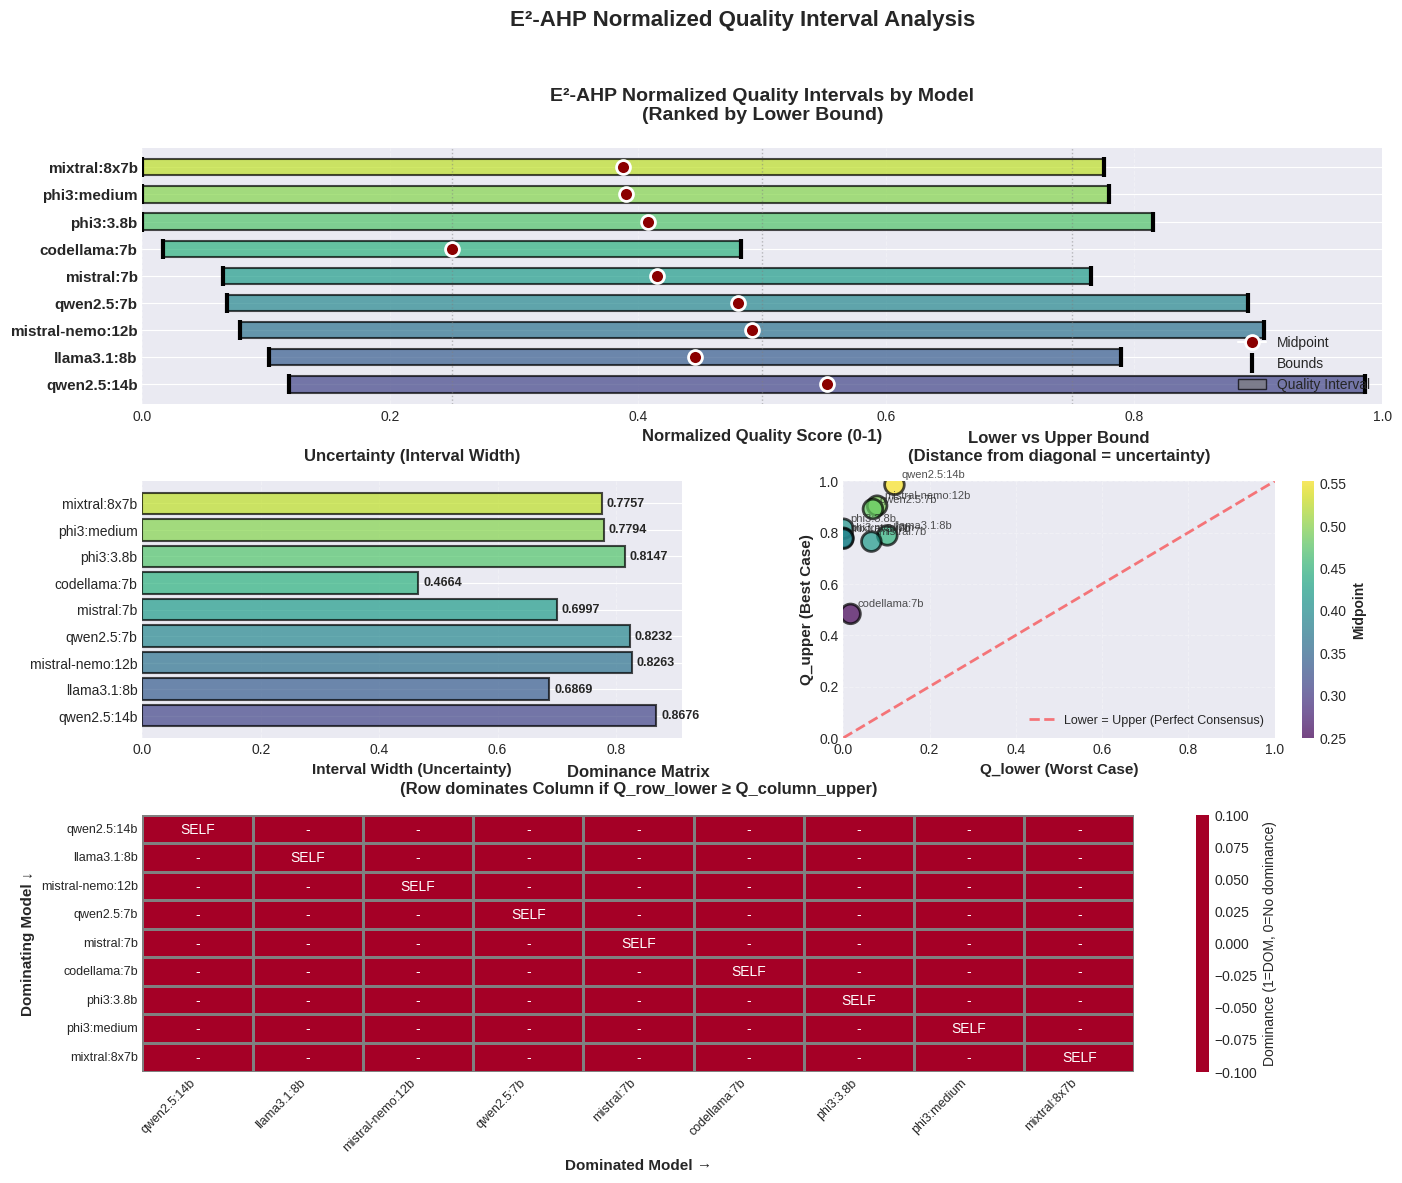

✓ Saved: e2ahp_detailed_intervals_normalized.png


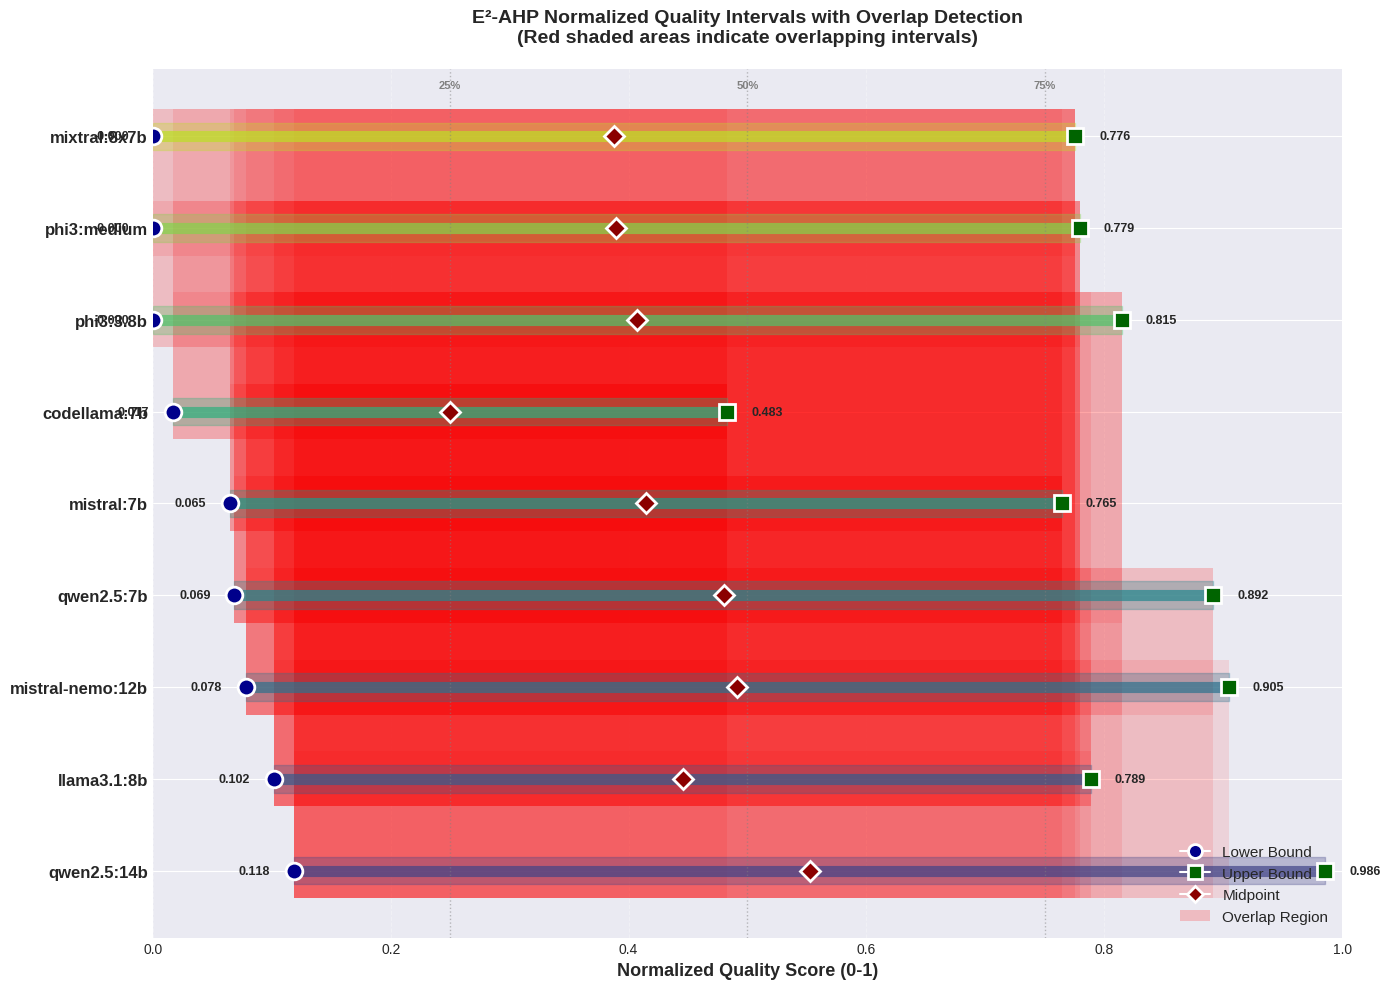

✓ Saved: e2ahp_criterion_details_normalized.png


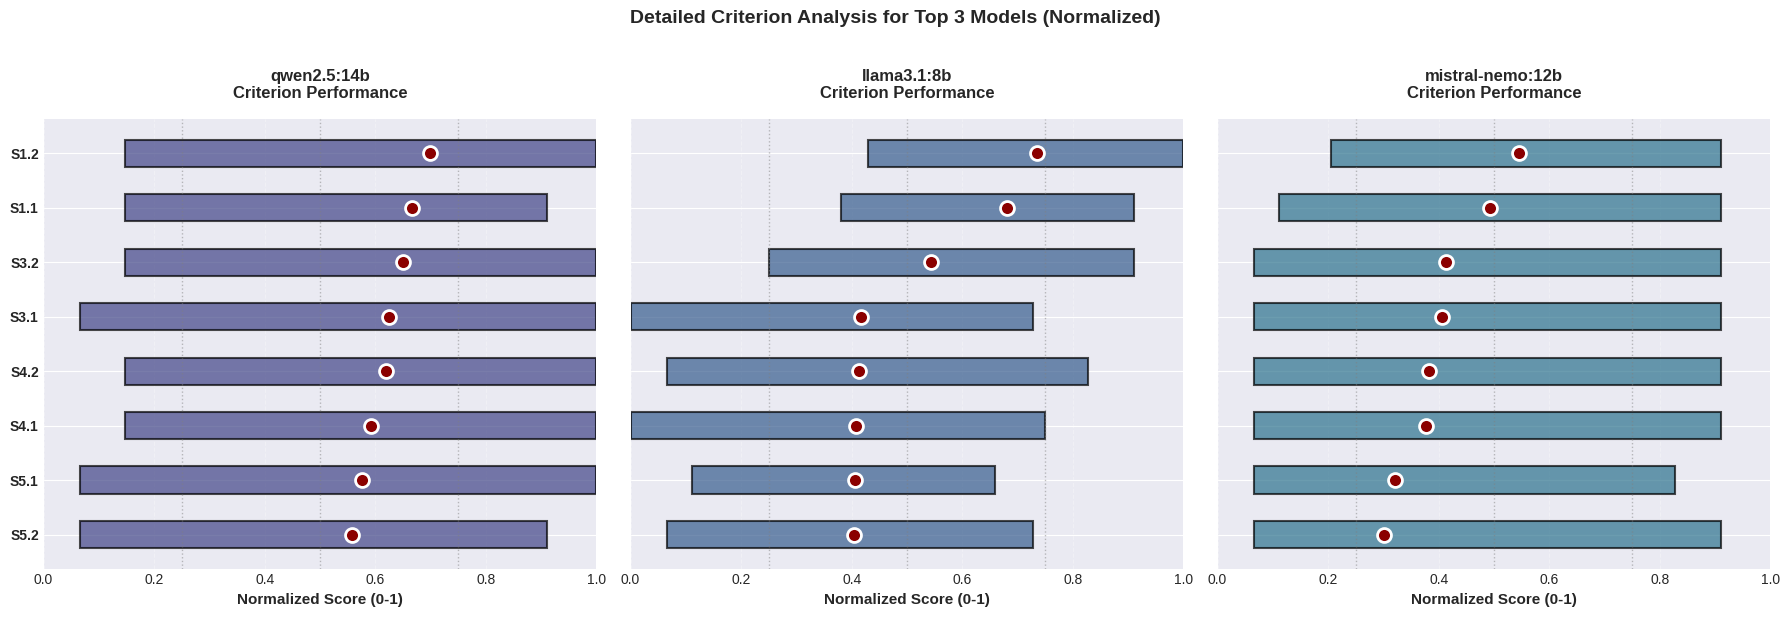

✓ Saved: e2ahp_performance_distribution.png


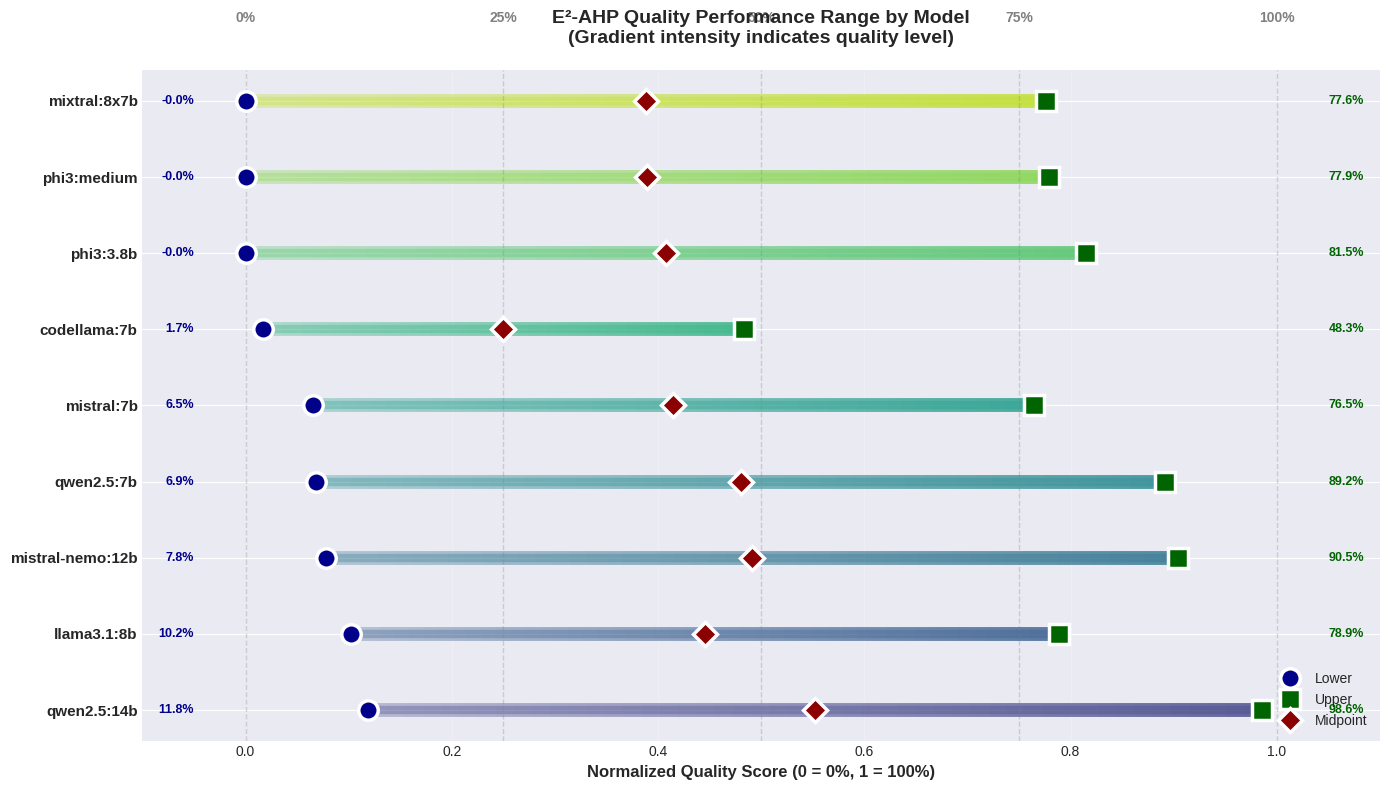


VISUALIZATION COMPLETE (NORMALIZED)

Generated 4 comprehensive visualizations:
  1. e2ahp_quality_intervals_normalized.png - Main 4-panel analysis
  2. e2ahp_detailed_intervals_normalized.png - Detailed interval plot with overlaps
  3. e2ahp_criterion_details_normalized.png - Criterion-level analysis for top models
  4. e2ahp_performance_distribution.png - Performance range visualization

All plots use normalized scale (0-1) for easier interpretation:
  0.00 = 0%   (worst performance)
  0.50 = 50%  (average performance)
  1.00 = 100% (perfect performance)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load the quality intervals data
summary_df = pd.read_csv('model_quality_intervals.csv')

# Check if normalized columns exist, otherwise use raw columns
if 'Q_lower_norm' in summary_df.columns:
    print("Using normalized values from dataset")
    lower_col = 'Q_lower_norm'
    upper_col = 'Q_upper_norm'
    midpoint_col = 'Midpoint_norm'
    width_col = 'Interval_Width_norm'
    score_label = 'Normalized Quality Score (0-1)'
    score_range = [0, 1]
else:
    print("Normalized columns not found, using raw values")
    lower_col = 'Q_lower'
    upper_col = 'Q_upper'
    midpoint_col = 'Midpoint'
    width_col = 'Interval_Width'
    score_label = 'Quality Score'
    score_range = None

# Sort by lower bound (descending) for ranking
summary_df = summary_df.sort_values(lower_col, ascending=False).reset_index(drop=True)

# Create figure with multiple subplots
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# ============================================================================
# Plot 1: Main Quality Interval Chart (Horizontal)
# ============================================================================
ax1 = fig.add_subplot(gs[0, :])

models = summary_df['Model'].values
q_lower = summary_df[lower_col].values
q_upper = summary_df[upper_col].values
midpoints = summary_df[midpoint_col].values
widths = summary_df[width_col].values

# Create color gradient based on midpoint
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(models)))

y_positions = np.arange(len(models))

for i, (model, lower, upper, mid, width) in enumerate(zip(models, q_lower, q_upper, midpoints, widths)):
    # Draw interval as horizontal bar
    ax1.barh(y_positions[i], width, left=lower, height=0.6,
             color=colors[i], alpha=0.7, edgecolor='black', linewidth=1.5)

    # Add midpoint marker
    ax1.plot(mid, y_positions[i], 'o', color='darkred', markersize=10,
             markeredgecolor='white', markeredgewidth=2, zorder=5)

    # Add lower bound marker
    ax1.plot(lower, y_positions[i], '|', color='black', markersize=15,
             markeredgewidth=3, zorder=5)

    # Add upper bound marker
    ax1.plot(upper, y_positions[i], '|', color='black', markersize=15,
             markeredgewidth=3, zorder=5)

ax1.set_yticks(y_positions)
ax1.set_yticklabels(models, fontsize=11, fontweight='bold')
ax1.set_xlabel(score_label, fontsize=12, fontweight='bold')
ax1.set_title('E²-AHP Normalized Quality Intervals by Model\n(Ranked by Lower Bound)',
              fontsize=14, fontweight='bold', pad=20)
ax1.grid(axis='x', alpha=0.3, linestyle='--')
ax1.set_axisbelow(True)

# Set x-axis range for normalized values
if score_range:
    ax1.set_xlim(score_range)
    # Add reference lines for quartiles
    for quartile in [0.25, 0.50, 0.75]:
        ax1.axvline(x=quartile, color='gray', linestyle=':', alpha=0.5, linewidth=1)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='darkred',
               markersize=10, label='Midpoint', markeredgecolor='white', markeredgewidth=2),
    plt.Line2D([0], [0], marker='|', color='black', markersize=15,
               linewidth=0, label='Bounds', markeredgewidth=3),
    Patch(facecolor='gray', edgecolor='black', alpha=0.7, label='Quality Interval')
]
ax1.legend(handles=legend_elements, loc='lower right', fontsize=10)

# ============================================================================
# Plot 2: Interval Width Comparison
# ============================================================================
ax2 = fig.add_subplot(gs[1, 0])

bars = ax2.barh(y_positions, widths, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.set_yticks(y_positions)
ax2.set_yticklabels(models, fontsize=10)
ax2.set_xlabel('Interval Width (Uncertainty)', fontsize=11, fontweight='bold')
ax2.set_title('Uncertainty (Interval Width)', fontsize=12, fontweight='bold', pad=15)
ax2.grid(axis='x', alpha=0.3, linestyle='--')
ax2.set_axisbelow(True)

# Add value labels
for i, (width, bar) in enumerate(zip(widths, bars)):
    ax2.text(width + max(widths)*0.01, i, f'{width:.4f}',
             va='center', ha='left', fontsize=9, fontweight='bold')

# ============================================================================
# Plot 3: Lower vs Upper Bound Scatter
# ============================================================================
ax3 = fig.add_subplot(gs[1, 1])

scatter = ax3.scatter(q_lower, q_upper, s=200, c=midpoints, cmap='viridis',
                     alpha=0.7, edgecolors='black', linewidth=2)

# Add diagonal reference line (where lower = upper)
if score_range:
    min_val, max_val = score_range
else:
    min_val = min(q_lower.min(), q_upper.min())
    max_val = max(q_lower.max(), q_upper.max())

ax3.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5,
         linewidth=2, label='Lower = Upper (Perfect Consensus)')

# Annotate points
for i, model in enumerate(models):
    ax3.annotate(model, (q_lower[i], q_upper[i]),
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, alpha=0.8)

ax3.set_xlabel('Q_lower (Worst Case)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Q_upper (Best Case)', fontsize=11, fontweight='bold')
ax3.set_title('Lower vs Upper Bound\n(Distance from diagonal = uncertainty)',
              fontsize=12, fontweight='bold', pad=15)
ax3.grid(alpha=0.3, linestyle='--')
ax3.legend(fontsize=9)

if score_range:
    ax3.set_xlim(score_range)
    ax3.set_ylim(score_range)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax3)
cbar.set_label('Midpoint', fontsize=10, fontweight='bold')

# ============================================================================
# Plot 4: Dominance Heatmap
# ============================================================================
ax4 = fig.add_subplot(gs[2, :])

# Load dominance matrix
dominance_df = pd.read_csv('dominance_matrix.csv', index_col=0)

# Convert to numeric: SELF=0, DOM=1, -=0
dominance_numeric = dominance_df.replace({'SELF': 0, 'DOM': 1, '-': 0}).astype(float)

# Reorder to match ranking
dominance_numeric = dominance_numeric.loc[models, models]

# Create heatmap
sns.heatmap(dominance_numeric, annot=dominance_df.loc[models, models],
            fmt='s', cmap='RdYlGn', center=0.5,
            xticklabels=models, yticklabels=models,
            cbar_kws={'label': 'Dominance (1=DOM, 0=No dominance)'},
            linewidths=1, linecolor='gray', ax=ax4)

ax4.set_xlabel('Dominated Model →', fontsize=11, fontweight='bold')
ax4.set_ylabel('Dominating Model ↓', fontsize=11, fontweight='bold')
ax4.set_title('Dominance Matrix\n(Row dominates Column if Q_row_lower ≥ Q_column_upper)',
              fontsize=12, fontweight='bold', pad=15)

# Rotate labels
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax4.set_yticklabels(ax4.get_yticklabels(), rotation=0, fontsize=9)

plt.suptitle('E²-AHP Normalized Quality Interval Analysis',
             fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout()
plt.savefig('e2ahp_quality_intervals_normalized.png', dpi=300, bbox_inches='tight')
print("✓ Saved: e2ahp_quality_intervals_normalized.png")
plt.show()

# ============================================================================
# Additional Plot: Detailed Interval Plot with Overlap Visualization
# ============================================================================
fig2, ax = plt.subplots(figsize=(14, 10))

y_positions = np.arange(len(models))

# Draw overlapping regions
for i in range(len(models)):
    for j in range(i+1, len(models)):
        # Check if intervals overlap
        lower_i, upper_i = q_lower[i], q_upper[i]
        lower_j, upper_j = q_lower[j], q_upper[j]

        overlap_start = max(lower_i, lower_j)
        overlap_end = min(upper_i, upper_j)

        if overlap_start < overlap_end:  # There is overlap
            # Draw shaded region
            rect = Rectangle((overlap_start, min(y_positions[i], y_positions[j]) - 0.3),
                           overlap_end - overlap_start,
                           abs(y_positions[i] - y_positions[j]) + 0.6,
                           facecolor='red', alpha=0.1, edgecolor='none', zorder=1)
            ax.add_patch(rect)

# Draw intervals
for i, (model, lower, upper, mid, width) in enumerate(zip(models, q_lower, q_upper, midpoints, widths)):
    # Draw interval as line
    ax.plot([lower, upper], [y_positions[i], y_positions[i]],
            color=colors[i], linewidth=8, alpha=0.7, solid_capstyle='round')

    # Draw interval as lighter fill
    ax.fill_betweenx([y_positions[i]-0.15, y_positions[i]+0.15],
                      lower, upper, color=colors[i], alpha=0.3, zorder=2)

    # Add markers
    ax.plot(lower, y_positions[i], 'o', color='darkblue', markersize=12,
            markeredgecolor='white', markeredgewidth=2, zorder=5)
    ax.plot(upper, y_positions[i], 's', color='darkgreen', markersize=12,
            markeredgecolor='white', markeredgewidth=2, zorder=5)
    ax.plot(mid, y_positions[i], 'D', color='darkred', markersize=10,
            markeredgecolor='white', markeredgewidth=2, zorder=5)

    # Add text labels with values - adjust offset based on scale
    offset = 0.02 if score_range else 0.02 * (max(q_upper) - min(q_lower))
    ax.text(lower - offset, y_positions[i], f'{lower:.3f}',
            ha='right', va='center', fontsize=9, fontweight='bold')
    ax.text(upper + offset, y_positions[i], f'{upper:.3f}',
            ha='left', va='center', fontsize=9, fontweight='bold')

ax.set_yticks(y_positions)
ax.set_yticklabels(models, fontsize=12, fontweight='bold')
ax.set_xlabel(score_label, fontsize=13, fontweight='bold')
ax.set_title('E²-AHP Normalized Quality Intervals with Overlap Detection\n' +
             '(Red shaded areas indicate overlapping intervals)',
             fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

if score_range:
    ax.set_xlim(score_range)
    # Add reference lines for quartiles
    for quartile in [0.25, 0.50, 0.75]:
        ax.axvline(x=quartile, color='gray', linestyle=':', alpha=0.5, linewidth=1)
        ax.text(quartile, len(models) - 0.5, f'{int(quartile*100)}%',
                ha='center', va='bottom', fontsize=8, color='gray', fontweight='bold')

# Add legend
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='darkblue',
               markersize=10, label='Lower Bound', markeredgecolor='white', markeredgewidth=2),
    plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='darkgreen',
               markersize=10, label='Upper Bound', markeredgecolor='white', markeredgewidth=2),
    plt.Line2D([0], [0], marker='D', color='w', markerfacecolor='darkred',
               markersize=8, label='Midpoint', markeredgecolor='white', markeredgewidth=2),
    Patch(facecolor='red', alpha=0.2, label='Overlap Region')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.savefig('e2ahp_detailed_intervals_normalized.png', dpi=300, bbox_inches='tight')
print("✓ Saved: e2ahp_detailed_intervals_normalized.png")
plt.show()

# ============================================================================
# Plot: Criterion-level intervals for top 3 models (NORMALIZED)
# ============================================================================
# Load criterion intervals
criterion_df = pd.read_csv('criterion_intervals_by_model.csv')

# Get top 3 models
top_models = models[:3]

fig3, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for idx, model in enumerate(top_models):
    ax = axes[idx]
    model_data = criterion_df[criterion_df['Model'] == model].copy()

    # Sort by mean for better visualization
    model_data = model_data.sort_values('Mean_Geomean', ascending=True)

    criteria = model_data['Criterion'].values
    mins = model_data['Min'].values
    maxs = model_data['Max'].values
    means = model_data['Mean_Geomean'].values
    widths = model_data['Width'].values

    # Normalize criterion values to [0, 1] scale
    mins_norm = (mins - 1.0) / 4.0
    maxs_norm = (maxs - 1.0) / 4.0
    means_norm = (means - 1.0) / 4.0
    widths_norm = widths / 4.0

    y_pos = np.arange(len(criteria))

    # Draw intervals
    for i, (crit, mn, mx, mean, width) in enumerate(zip(criteria, mins_norm, maxs_norm, means_norm, widths_norm)):
        ax.barh(y_pos[i], width, left=mn, height=0.5,
                color=colors[idx], alpha=0.7, edgecolor='black', linewidth=1.5)
        ax.plot(mean, y_pos[i], 'o', color='darkred', markersize=10,
                markeredgecolor='white', markeredgewidth=2, zorder=5)

    ax.set_yticks(y_pos)
    if idx == 0:
        ax.set_yticklabels(criteria, fontsize=10, fontweight='bold')
    ax.set_xlabel('Normalized Score (0-1)', fontsize=11, fontweight='bold')
    ax.set_title(f'{model}\nCriterion Performance', fontsize=12, fontweight='bold', pad=15)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.set_xlim([0, 1])

    # Add reference lines
    for quartile in [0.25, 0.50, 0.75]:
        ax.axvline(x=quartile, color='gray', linestyle=':', alpha=0.5, linewidth=1)

plt.suptitle('Detailed Criterion Analysis for Top 3 Models (Normalized)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('e2ahp_criterion_details_normalized.png', dpi=300, bbox_inches='tight')
print("✓ Saved: e2ahp_criterion_details_normalized.png")
plt.show()

# ============================================================================
# NEW: Performance Distribution Plot
# ============================================================================
fig4, ax = plt.subplots(figsize=(14, 8))

# Create violin-like visualization showing the distribution
for i, (model, lower, upper, mid) in enumerate(zip(models, q_lower, q_upper, midpoints)):
    # Create a simple distribution representation
    y_base = i

    # Draw the full interval as a thick line
    ax.plot([lower, upper], [y_base, y_base], color=colors[i],
            linewidth=6, alpha=0.3, solid_capstyle='round', zorder=1)

    # Draw a gradient bar to show quality range
    n_segments = 50
    x_vals = np.linspace(lower, upper, n_segments)
    for j in range(len(x_vals) - 1):
        alpha_val = 0.3 + 0.5 * (x_vals[j] - lower) / (upper - lower)
        ax.plot([x_vals[j], x_vals[j+1]], [y_base, y_base],
                color=colors[i], linewidth=10, alpha=alpha_val,
                solid_capstyle='butt', zorder=2)

    # Mark the bounds and midpoint
    ax.plot(lower, y_base, 'o', color='darkblue', markersize=14,
            markeredgecolor='white', markeredgewidth=2.5, zorder=5, label='Lower' if i == 0 else '')
    ax.plot(upper, y_base, 's', color='darkgreen', markersize=14,
            markeredgecolor='white', markeredgewidth=2.5, zorder=5, label='Upper' if i == 0 else '')
    ax.plot(mid, y_base, 'D', color='darkred', markersize=12,
            markeredgecolor='white', markeredgewidth=2.5, zorder=5, label='Midpoint' if i == 0 else '')

    # Add percentage labels
    ax.text(-0.05, y_base, f'{lower*100:.1f}%', ha='right', va='center',
            fontsize=9, fontweight='bold', color='darkblue')
    ax.text(1.05, y_base, f'{upper*100:.1f}%', ha='left', va='center',
            fontsize=9, fontweight='bold', color='darkgreen')

ax.set_yticks(range(len(models)))
ax.set_yticklabels(models, fontsize=11, fontweight='bold')
ax.set_xlabel('Normalized Quality Score (0 = 0%, 1 = 100%)', fontsize=12, fontweight='bold')
ax.set_title('E²-AHP Quality Performance Range by Model\n(Gradient intensity indicates quality level)',
             fontsize=14, fontweight='bold', pad=20)

if score_range:
    ax.set_xlim([-0.1, 1.1])
    # Add vertical reference lines
    for quartile in [0, 0.25, 0.50, 0.75, 1.0]:
        ax.axvline(x=quartile, color='gray', linestyle='--', alpha=0.3, linewidth=1)
        ax.text(quartile, len(models), f'{int(quartile*100)}%',
                ha='center', va='bottom', fontsize=10, color='gray', fontweight='bold')

ax.grid(axis='x', alpha=0.2, linestyle='-')
ax.set_axisbelow(True)
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.savefig('e2ahp_performance_distribution.png', dpi=300, bbox_inches='tight')
print("✓ Saved: e2ahp_performance_distribution.png")
plt.show()

print("\n" + "="*80)
print("VISUALIZATION COMPLETE (NORMALIZED)")
print("="*80)
print("\nGenerated 4 comprehensive visualizations:")
print("  1. e2ahp_quality_intervals_normalized.png - Main 4-panel analysis")
print("  2. e2ahp_detailed_intervals_normalized.png - Detailed interval plot with overlaps")
print("  3. e2ahp_criterion_details_normalized.png - Criterion-level analysis for top models")
print("  4. e2ahp_performance_distribution.png - Performance range visualization")
print("\nAll plots use normalized scale (0-1) for easier interpretation:")
print("  0.00 = 0%   (worst performance)")
print("  0.50 = 50%  (average performance)")
print("  1.00 = 100% (perfect performance)")
print("="*80)

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import gmean

# Load the dataset
df = pd.read_csv('LikertScale.csv')

# Map model letters to real model names
model_name_map = {
    'n': 'llama3.1:8b',
    'q': 'qwen2.5:7b',
    'm': 'mistral:7b',
    'c': 'codellama:7b',
    'p': 'phi3:3.8b',
    'x': 'mistral-nemo:12b',
    'z': 'qwen2.5:14b',
    'y': 'phi3:medium',
    'w': 'mixtral:8x7b'
}

df['Model'] = df['Model'].map(model_name_map)

# Define criteria structure
criteria_structure = {
    'C1': ['S1.1', 'S1.2'],
    'C3': ['S3.1', 'S3.2'],
    'C4': ['S4.1', 'S4.2'],
    'C5': ['S5.1', 'S5.2']
}

# Flatten to get all sub-criteria
criteria_cols = ['S1.1', 'S1.2', 'S3.1', 'S3.2', 'S4.1', 'S4.2', 'S5.1', 'S5.2']

# Define weights
criterion_weights = {
    'C1': 0.1149,
    'C3': 0.1363,
    'C4': 0.4830,
    'C5': 0.2658
}

sub_criterion_weights = {
    'S1.1': 0.7458, 'S1.2': 0.2542,
    'S3.1': 0.5959, 'S3.2': 0.4041,
    'S4.1': 0.4856, 'S4.2': 0.5144,
    'S5.1': 0.7360, 'S5.2': 0.2640
}

global_weights = {
    sc: criterion_weights[c] * sub_criterion_weights[sc]
    for c, scs in criteria_structure.items()
    for sc in scs
}

print("="*80)
print("E²-AHP EVALUATION: PER-CRITERIA AND OVERALL ANALYSIS")
print("="*80)

# Step 1: Geometric mean aggregation per question
print("\nSTEP 1: Computing geometric means per question...")
geomean_per_question = []

for model in df['Model'].unique():
    model_df = df[df['Model'] == model]

    for question in model_df['question_number'].unique():
        question_df = model_df[model_df['question_number'] == question]

        row = {'Model': model, 'question_number': question}

        for criterion in criteria_cols:
            scores = question_df[criterion].values
            row[f'{criterion}_geomean'] = gmean(scores)

        geomean_per_question.append(row)

geomean_df = pd.DataFrame(geomean_per_question)

# Step 2: Compute intervals per sub-criterion
print("STEP 2: Computing intervals per sub-criterion...")
sub_criterion_intervals = {}

for model in sorted(geomean_df['Model'].unique()):
    model_geomean = geomean_df[geomean_df['Model'] == model]
    sub_criterion_intervals[model] = {}

    for criterion in criteria_cols:
        geomeans = model_geomean[f'{criterion}_geomean'].values
        sub_criterion_intervals[model][criterion] = (geomeans.min(), geomeans.max())

# Step 3: Aggregate to criteria level using weighted sub-criterion intervals
print("STEP 3: Aggregating to criteria level...")

def normalize(value):
    """Normalize from [1,5] to [0,1]"""
    return (value - 1.0) / 4.0

# Dictionary to store results at different levels
criteria_intervals_raw = {}
criteria_intervals_norm = {}
overall_intervals_raw = {}
overall_intervals_norm = {}

models = sorted(sub_criterion_intervals.keys())

for model in models:
    criteria_intervals_raw[model] = {}
    criteria_intervals_norm[model] = {}

    # For each criterion, aggregate its sub-criteria
    for criterion, sub_criteria in criteria_structure.items():
        lower_bound = 0.0
        upper_bound = 0.0

        # Aggregate sub-criteria within this criterion
        for sub_crit in sub_criteria:
            # Weight within the criterion (normalize so they sum to 1 within criterion)
            weight_within = sub_criterion_weights[sub_crit]
            interval = sub_criterion_intervals[model][sub_crit]

            lower_bound += weight_within * interval[0]
            upper_bound += weight_within * interval[1]

        criteria_intervals_raw[model][criterion] = (lower_bound, upper_bound)
        criteria_intervals_norm[model][criterion] = (normalize(lower_bound), normalize(upper_bound))

    # Compute overall quality interval
    overall_lower = 0.0
    overall_upper = 0.0

    for criterion in criteria_structure.keys():
        weight = criterion_weights[criterion]
        lower, upper = criteria_intervals_raw[model][criterion]
        overall_lower += weight * lower
        overall_upper += weight * upper

    overall_intervals_raw[model] = (overall_lower, overall_upper)
    overall_intervals_norm[model] = (normalize(overall_lower), normalize(overall_upper))

# ============================================================================
# OUTPUT RESULTS
# ============================================================================

print("\n" + "="*80)
print("RESULTS: PER-CRITERIA QUALITY INTERVALS (NORMALIZED)")
print("="*80)

for criterion, sub_criteria in criteria_structure.items():
    print(f"\n{'='*80}")
    print(f"CRITERION {criterion} (Weight: {criterion_weights[criterion]:.4f})")
    print(f"Sub-criteria: {', '.join(sub_criteria)}")
    print(f"{'='*80}")

    # Sort models by lower bound for this criterion
    sorted_models_criterion = sorted(models,
                                    key=lambda m: (criteria_intervals_norm[m][criterion][0],
                                                 criteria_intervals_norm[m][criterion][1]),
                                    reverse=True)

    print(f"\n{'Rank':<6} {'Model':<20} {'Lower':<10} {'Upper':<10} {'Midpoint':<10} {'Width':<10}")
    print("-" * 66)

    for rank, model in enumerate(sorted_models_criterion, 1):
        lower, upper = criteria_intervals_norm[model][criterion]
        midpoint = (lower + upper) / 2
        width = upper - lower
        print(f"{rank:<6} {model:<20} {lower:<10.4f} {upper:<10.4f} {midpoint:<10.4f} {width:<10.4f}")

print("\n" + "="*80)
print("OVERALL QUALITY INTERVALS (NORMALIZED)")
print("="*80)

sorted_models_overall = sorted(models,
                               key=lambda m: (overall_intervals_norm[m][0],
                                            overall_intervals_norm[m][1]),
                               reverse=True)

print(f"\n{'Rank':<6} {'Model':<20} {'Lower':<10} {'Upper':<10} {'Midpoint':<10} {'Width':<10}")
print("-" * 66)

for rank, model in enumerate(sorted_models_overall, 1):
    lower, upper = overall_intervals_norm[model]
    midpoint = (lower + upper) / 2
    width = upper - lower
    print(f"{rank:<6} {model:<20} {lower:<10.4f} {upper:<10.4f} {midpoint:<10.4f} {width:<10.4f}")

# ============================================================================
# SUMMARY TABLES
# ============================================================================

print("\n" + "="*80)
print("COMPLETE SUMMARY TABLE")
print("="*80)

summary_data = []
for model in sorted_models_overall:
    row = {'Model': model}

    # Add per-criteria results
    for criterion in ['C1', 'C3', 'C4', 'C5']:
        lower, upper = criteria_intervals_norm[model][criterion]
        row[f'{criterion}_lower'] = lower
        row[f'{criterion}_upper'] = upper
        row[f'{criterion}_mid'] = (lower + upper) / 2

    # Add overall results
    lower, upper = overall_intervals_norm[model]
    row['Overall_lower'] = lower
    row['Overall_upper'] = upper
    row['Overall_mid'] = (lower + upper) / 2
    row['Overall_width'] = upper - lower

    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

# ============================================================================
# DOMINANCE ANALYSIS PER CRITERION
# ============================================================================

print("\n" + "="*80)
print("DOMINANCE ANALYSIS PER CRITERION")
print("="*80)

for criterion in ['C1', 'C3', 'C4', 'C5']:
    print(f"\n{criterion} Dominance Relationships:")
    dominance_found = False

    for model_a in models:
        qa_low = criteria_intervals_norm[model_a][criterion][0]

        for model_b in models:
            if model_a != model_b:
                qb_high = criteria_intervals_norm[model_b][criterion][1]

                if qa_low >= qb_high:
                    print(f"  '{model_a}' DOMINATES '{model_b}': "
                          f"{qa_low:.4f} ≥ {qb_high:.4f}")
                    dominance_found = True

    if not dominance_found:
        print(f"  No clear dominance relationships for {criterion}")

print("\n" + "="*80)
print("OVERALL DOMINANCE ANALYSIS")
print("="*80)

dominance_found = False
for model_a in models:
    qa_low = overall_intervals_norm[model_a][0]

    for model_b in models:
        if model_a != model_b:
            qb_high = overall_intervals_norm[model_b][1]

            if qa_low >= qb_high:
                print(f"  '{model_a}' DOMINATES '{model_b}': "
                      f"{qa_low:.4f} ≥ {qb_high:.4f}")
                dominance_found = True

if not dominance_found:
    print("  No clear dominance relationships overall")

# ============================================================================
# SAVE RESULTS
# ============================================================================

print("\n" + "="*80)
print("SAVING OUTPUT FILES")
print("="*80)

# Save per-criteria results
criteria_results = []
for model in models:
    for criterion in ['C1', 'C3', 'C4', 'C5']:
        lower_raw, upper_raw = criteria_intervals_raw[model][criterion]
        lower_norm, upper_norm = criteria_intervals_norm[model][criterion]

        criteria_results.append({
            'Model': model,
            'Criterion': criterion,
            'Weight': criterion_weights[criterion],
            'Lower_raw': lower_raw,
            'Upper_raw': upper_raw,
            'Lower_norm': lower_norm,
            'Upper_norm': upper_norm,
            'Midpoint_norm': (lower_norm + upper_norm) / 2,
            'Width_norm': upper_norm - lower_norm
        })

criteria_df = pd.DataFrame(criteria_results)
criteria_df.to_csv('per_criteria_intervals.csv', index=False)
print("✓ per_criteria_intervals.csv")

# Save overall results
overall_results = []
for model in models:
    lower_raw, upper_raw = overall_intervals_raw[model]
    lower_norm, upper_norm = overall_intervals_norm[model]

    overall_results.append({
        'Model': model,
        'Lower_raw': lower_raw,
        'Upper_raw': upper_raw,
        'Lower_norm': lower_norm,
        'Upper_norm': upper_norm,
        'Midpoint_norm': (lower_norm + upper_norm) / 2,
        'Width_norm': upper_norm - lower_norm
    })

overall_df = pd.DataFrame(overall_results)
overall_df.to_csv('overall_quality_intervals.csv', index=False)
print("✓ overall_quality_intervals.csv")

# Save complete summary
summary_df.to_csv('complete_summary.csv', index=False)
print("✓ complete_summary.csv")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)
print("\nKey outputs:")
print("  • Per-criteria rankings (C1, C3, C4, C5)")
print("  • Overall ranking (weighted aggregation)")
print("  • Dominance analysis at each level")
print("  • Normalized intervals [0,1] for easy interpretation")
print("="*80)

E²-AHP EVALUATION: PER-CRITERIA AND OVERALL ANALYSIS

STEP 1: Computing geometric means per question...
STEP 2: Computing intervals per sub-criterion...
STEP 3: Aggregating to criteria level...

RESULTS: PER-CRITERIA QUALITY INTERVALS (NORMALIZED)

CRITERION C1 (Weight: 0.1149)
Sub-criteria: S1.1, S1.2

Rank   Model                Lower      Upper      Midpoint   Width     
------------------------------------------------------------------
1      llama3.1:8b          0.4162     0.9772     0.6967     0.5610    
2      mistral-nemo:12b     0.1805     0.9104     0.5454     0.7299    
3      qwen2.5:7b           0.1697     0.9772     0.5735     0.8075    
4      mistral:7b           0.1605     0.9104     0.5354     0.7499    
5      qwen2.5:14b          0.1469     0.9332     0.5400     0.7863    
6      codellama:7b         0.0990     0.5755     0.3372     0.4765    
7      mixtral:8x7b         0.0000     0.8484     0.4242     0.8484    
8      phi3:3.8b            0.0000     0.8484     0.

✓ Saved: quality_intervals_all.png


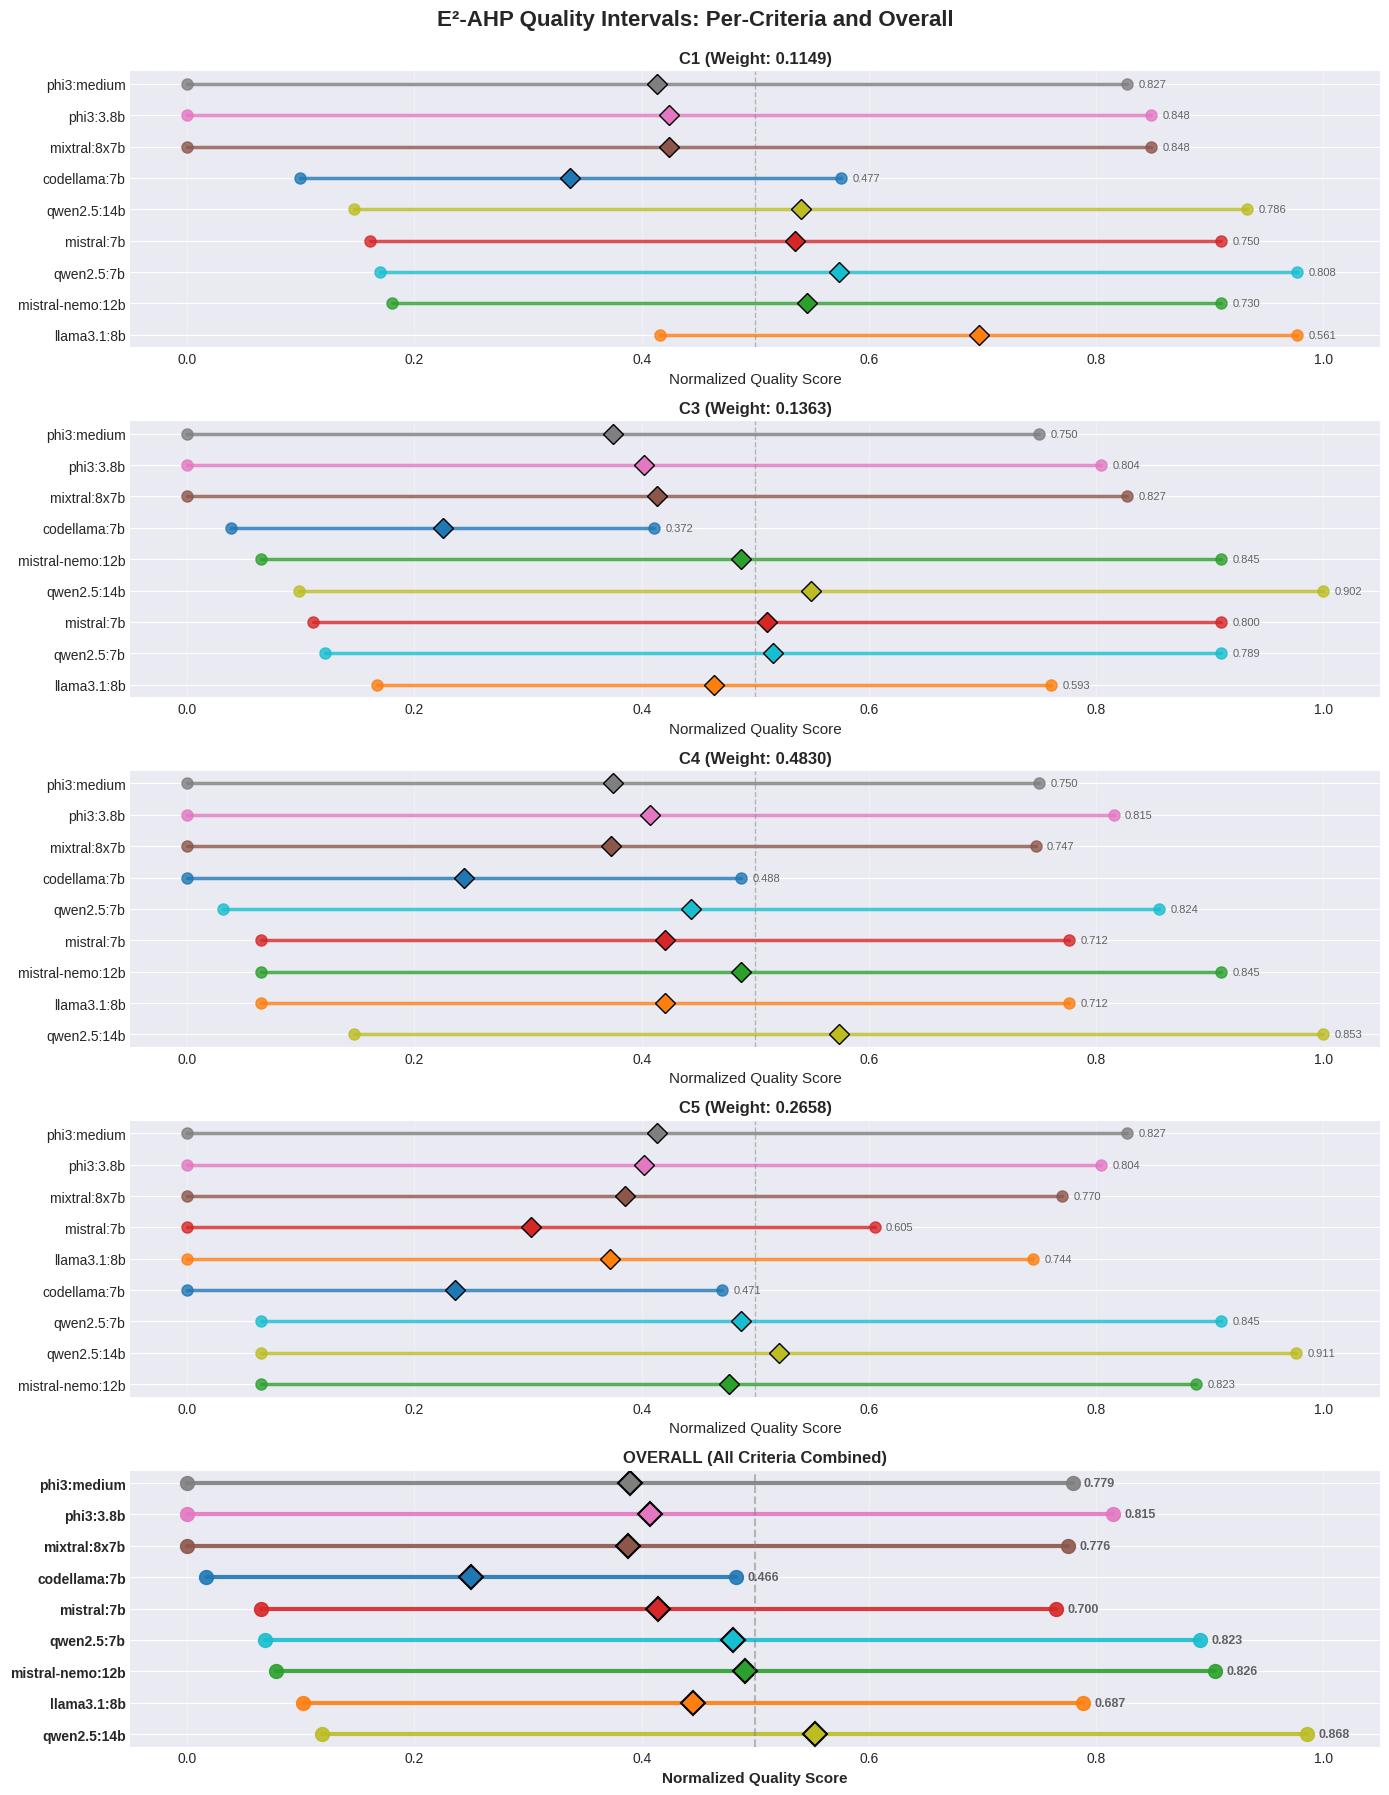

✓ Saved: quality_intervals_combined_overview.png


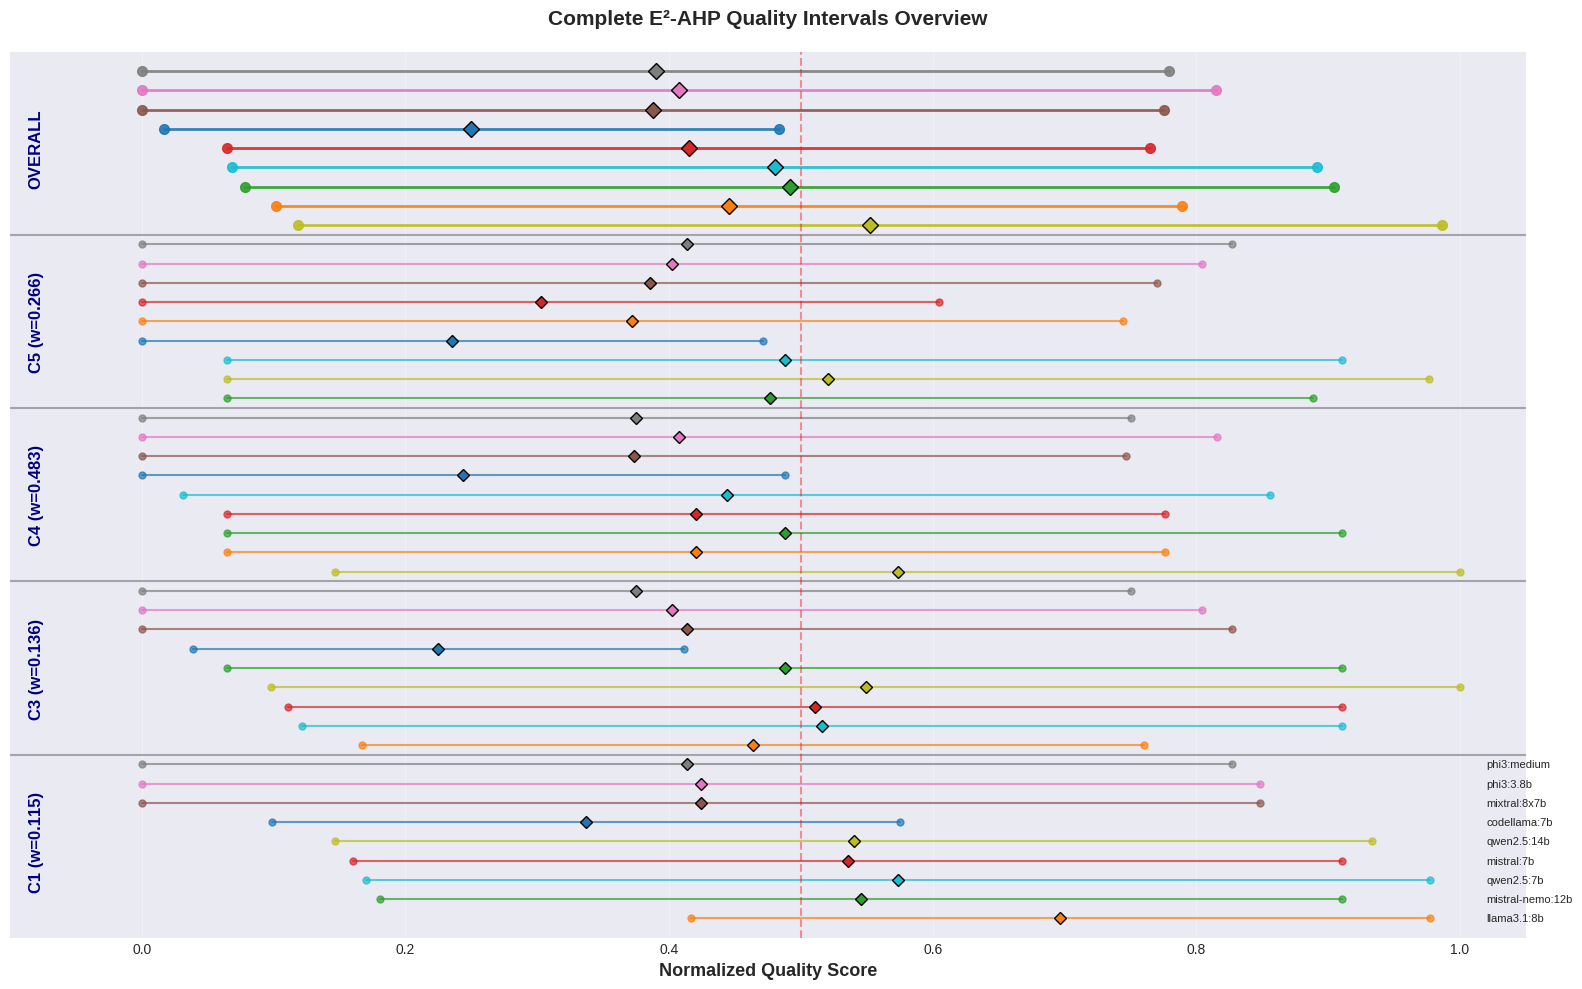

✓ Saved: quality_intervals_overlap_analysis.png


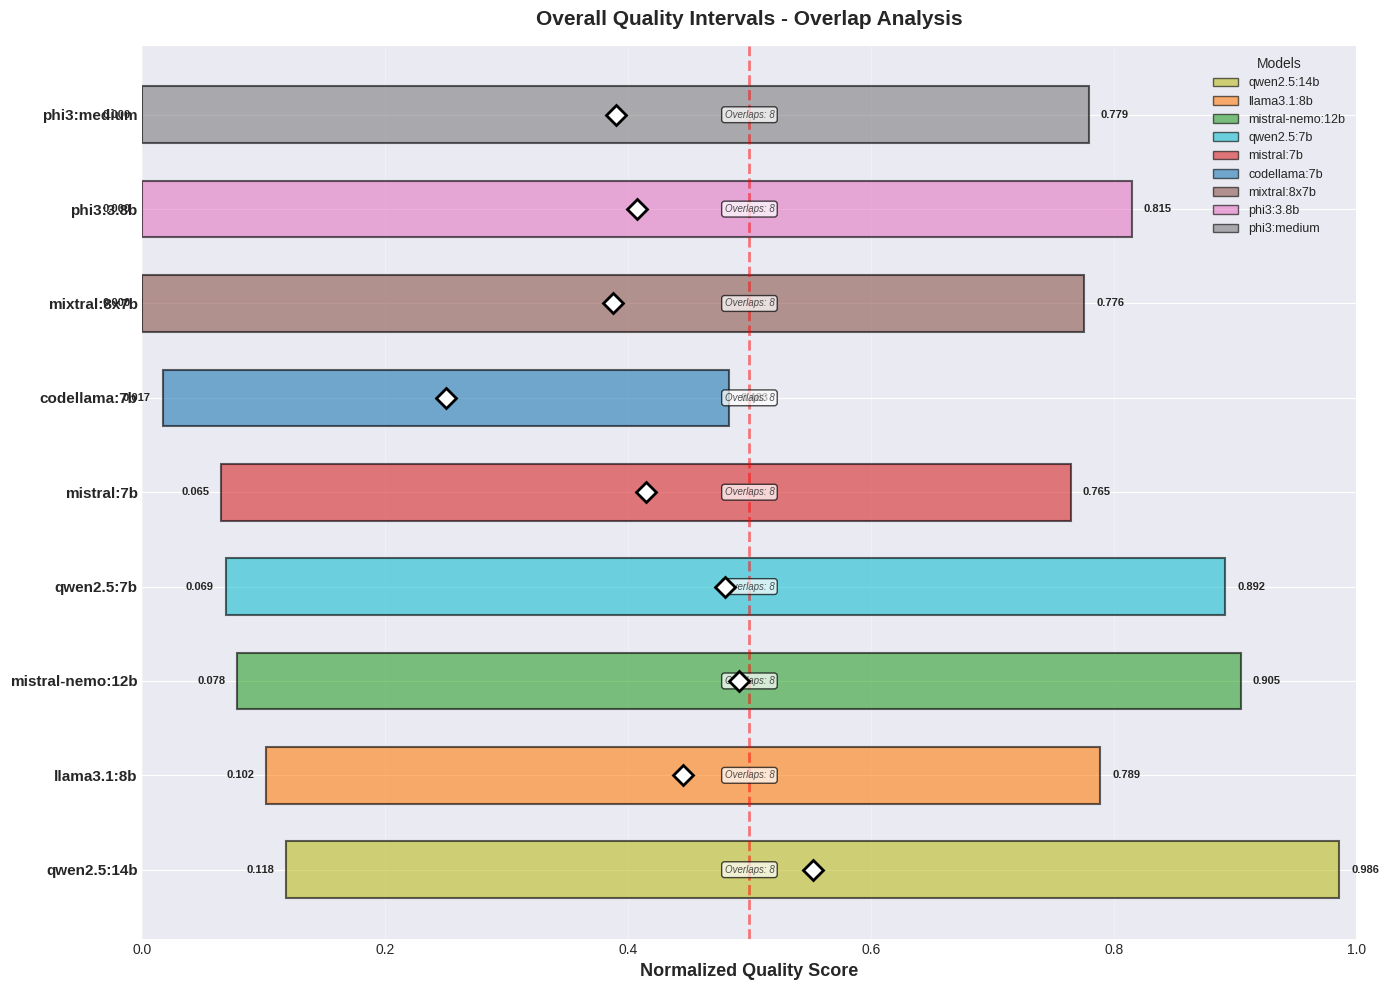

✓ Saved: quality_intervals_heatmap.png


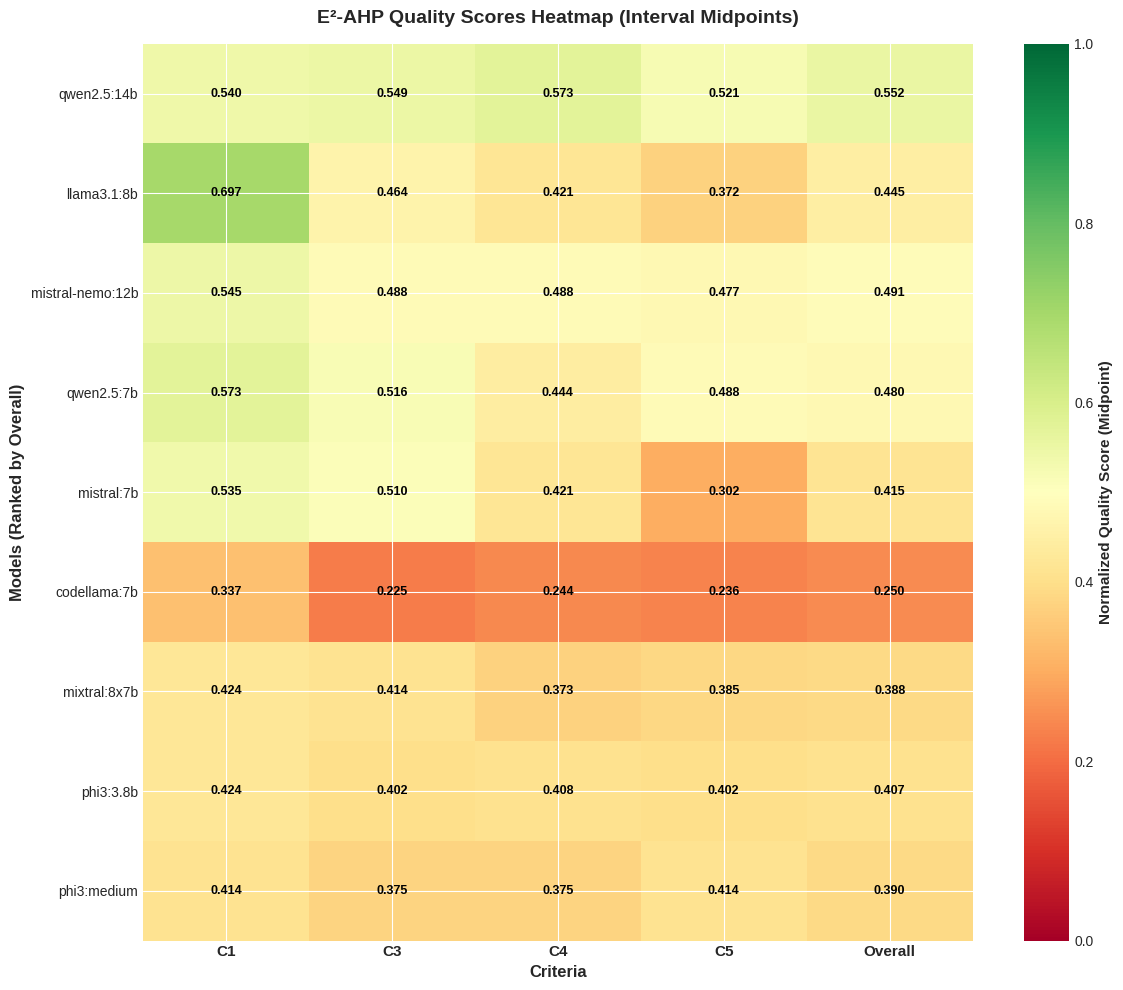


VISUALIZATION COMPLETE

Generated plots:
  1. quality_intervals_all.png - Separate panels for each criterion + overall
  2. quality_intervals_combined_overview.png - All criteria in one view
  3. quality_intervals_overlap_analysis.png - Overlap analysis with transparency
  4. quality_intervals_heatmap.png - Heatmap of midpoint scores


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gmean

# Load the dataset
df = pd.read_csv('LikertScale.csv')

# Map model letters to real model names
model_name_map = {
    'n': 'llama3.1:8b',
    'q': 'qwen2.5:7b',
    'm': 'mistral:7b',
    'c': 'codellama:7b',
    'p': 'phi3:3.8b',
    'x': 'mistral-nemo:12b',
    'z': 'qwen2.5:14b',
    'y': 'phi3:medium',
    'w': 'mixtral:8x7b'
}

df['Model'] = df['Model'].map(model_name_map)

# Define criteria structure
criteria_structure = {
    'C1': ['S1.1', 'S1.2'],
    'C3': ['S3.1', 'S3.2'],
    'C4': ['S4.1', 'S4.2'],
    'C5': ['S5.1', 'S5.2']
}

criteria_cols = ['S1.1', 'S1.2', 'S3.1', 'S3.2', 'S4.1', 'S4.2', 'S5.1', 'S5.2']

# Define weights
criterion_weights = {
    'C1': 0.1149,
    'C3': 0.1363,
    'C4': 0.4830,
    'C5': 0.2658
}

sub_criterion_weights = {
    'S1.1': 0.7458, 'S1.2': 0.2542,
    'S3.1': 0.5959, 'S3.2': 0.4041,
    'S4.1': 0.4856, 'S4.2': 0.5144,
    'S5.1': 0.7360, 'S5.2': 0.2640
}

def normalize(value):
    """Normalize from [1,5] to [0,1]"""
    return (value - 1.0) / 4.0

# Compute geometric means per question
geomean_per_question = []
for model in df['Model'].unique():
    model_df = df[df['Model'] == model]
    for question in model_df['question_number'].unique():
        question_df = model_df[model_df['question_number'] == question]
        row = {'Model': model, 'question_number': question}
        for criterion in criteria_cols:
            scores = question_df[criterion].values
            row[f'{criterion}_geomean'] = gmean(scores)
        geomean_per_question.append(row)

geomean_df = pd.DataFrame(geomean_per_question)

# Compute sub-criterion intervals
sub_criterion_intervals = {}
for model in sorted(geomean_df['Model'].unique()):
    model_geomean = geomean_df[geomean_df['Model'] == model]
    sub_criterion_intervals[model] = {}
    for criterion in criteria_cols:
        geomeans = model_geomean[f'{criterion}_geomean'].values
        sub_criterion_intervals[model][criterion] = (geomeans.min(), geomeans.max())

# Aggregate to criteria and overall level
models = sorted(sub_criterion_intervals.keys())
criteria_intervals_norm = {}
overall_intervals_norm = {}

for model in models:
    criteria_intervals_norm[model] = {}

    # For each criterion
    for criterion, sub_criteria in criteria_structure.items():
        lower_bound = 0.0
        upper_bound = 0.0
        for sub_crit in sub_criteria:
            weight_within = sub_criterion_weights[sub_crit]
            interval = sub_criterion_intervals[model][sub_crit]
            lower_bound += weight_within * interval[0]
            upper_bound += weight_within * interval[1]
        criteria_intervals_norm[model][criterion] = (normalize(lower_bound), normalize(upper_bound))

    # Overall
    overall_lower = 0.0
    overall_upper = 0.0
    for criterion in criteria_structure.keys():
        weight = criterion_weights[criterion]
        lower_raw = sum(sub_criterion_weights[sc] * sub_criterion_intervals[model][sc][0]
                       for sc in criteria_structure[criterion])
        upper_raw = sum(sub_criterion_weights[sc] * sub_criterion_intervals[model][sc][1]
                       for sc in criteria_structure[criterion])
        overall_lower += weight * lower_raw
        overall_upper += weight * upper_raw
    overall_intervals_norm[model] = (normalize(overall_lower), normalize(overall_upper))

# ============================================================================
# VISUALIZATION
# ============================================================================

# Set up color palette
colors = plt.cm.tab10(np.linspace(0, 1, len(models)))
model_colors = {model: colors[i] for i, model in enumerate(models)}

# Create figure with subplots
fig, axes = plt.subplots(5, 1, figsize=(14, 18))
fig.suptitle('E²-AHP Quality Intervals: Per-Criteria and Overall',
             fontsize=16, fontweight='bold', y=0.995)

# Plot each criterion
for idx, (criterion, ax) in enumerate(zip(['C1', 'C3', 'C4', 'C5'], axes[:4])):
    # Sort models by lower bound for this criterion
    sorted_models = sorted(models,
                          key=lambda m: criteria_intervals_norm[m][criterion][0],
                          reverse=True)

    y_positions = range(len(sorted_models))

    for i, model in enumerate(sorted_models):
        lower, upper = criteria_intervals_norm[model][criterion]
        midpoint = (lower + upper) / 2
        width = upper - lower

        # Draw interval line
        ax.plot([lower, upper], [i, i], 'o-',
               color=model_colors[model], linewidth=2.5,
               markersize=8, label=model, alpha=0.8)

        # Draw midpoint
        ax.plot(midpoint, i, 'D', color=model_colors[model],
               markersize=10, markeredgecolor='black', markeredgewidth=1)

        # Add interval width annotation
        ax.text(upper + 0.01, i, f'{width:.3f}',
               va='center', fontsize=8, alpha=0.7)

    ax.set_yticks(y_positions)
    ax.set_yticklabels(sorted_models, fontsize=10)
    ax.set_xlabel('Normalized Quality Score', fontsize=11)
    ax.set_title(f'{criterion} (Weight: {criterion_weights[criterion]:.4f})',
                fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    ax.set_xlim(-0.05, 1.05)
    ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)

# Plot overall
ax = axes[4]
sorted_models_overall = sorted(models,
                               key=lambda m: overall_intervals_norm[m][0],
                               reverse=True)

y_positions = range(len(sorted_models_overall))

for i, model in enumerate(sorted_models_overall):
    lower, upper = overall_intervals_norm[model]
    midpoint = (lower + upper) / 2
    width = upper - lower

    # Draw interval line (thicker for overall)
    ax.plot([lower, upper], [i, i], 'o-',
           color=model_colors[model], linewidth=3,
           markersize=10, label=model, alpha=0.9)

    # Draw midpoint
    ax.plot(midpoint, i, 'D', color=model_colors[model],
           markersize=12, markeredgecolor='black', markeredgewidth=1.5)

    # Add interval width annotation
    ax.text(upper + 0.01, i, f'{width:.3f}',
           va='center', fontsize=9, alpha=0.7, fontweight='bold')

ax.set_yticks(y_positions)
ax.set_yticklabels(sorted_models_overall, fontsize=10, fontweight='bold')
ax.set_xlabel('Normalized Quality Score', fontsize=11, fontweight='bold')
ax.set_title('OVERALL (All Criteria Combined)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
ax.set_xlim(-0.05, 1.05)
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1.5)

plt.tight_layout()
plt.savefig('quality_intervals_all.png', dpi=300, bbox_inches='tight')
print("✓ Saved: quality_intervals_all.png")
plt.show()

# ============================================================================
# COMBINED OVERVIEW PLOT
# ============================================================================

fig, ax = plt.subplots(figsize=(16, 10))

# Calculate positions for all criteria + overall
num_criteria = 5  # C1, C3, C4, C5, Overall
y_spacing = len(models) + 1  # Space between criteria groups

criteria_list = ['C1', 'C3', 'C4', 'C5', 'Overall']
y_offset = 0

for criterion_idx, criterion in enumerate(criteria_list):
    if criterion == 'Overall':
        intervals = overall_intervals_norm
        sorted_models_crit = sorted(models,
                                   key=lambda m: intervals[m][0],
                                   reverse=True)
        label = 'OVERALL'
    else:
        intervals = {m: criteria_intervals_norm[m][criterion] for m in models}
        sorted_models_crit = sorted(models,
                                   key=lambda m: intervals[m][0],
                                   reverse=True)
        label = f'{criterion} (w={criterion_weights[criterion]:.3f})'

    # Draw separator line
    if criterion_idx > 0:
        ax.axhline(y=y_offset - 0.5, color='black', linestyle='-',
                  linewidth=1.5, alpha=0.3)

    # Add criterion label
    ax.text(-0.08, y_offset + len(sorted_models_crit)/2 - 0.5, label,
           rotation=90, va='center', ha='center', fontsize=12,
           fontweight='bold', color='navy')

    for i, model in enumerate(sorted_models_crit):
        y_pos = y_offset + i
        lower, upper = intervals[model]
        midpoint = (lower + upper) / 2

        # Draw interval
        ax.plot([lower, upper], [y_pos, y_pos], 'o-',
               color=model_colors[model], linewidth=2 if criterion == 'Overall' else 1.5,
               markersize=7 if criterion == 'Overall' else 5,
               alpha=0.9 if criterion == 'Overall' else 0.7)

        # Draw midpoint
        ax.plot(midpoint, y_pos, 'D', color=model_colors[model],
               markersize=8 if criterion == 'Overall' else 6,
               markeredgecolor='black', markeredgewidth=1)

        # Add model name on the right
        if criterion_idx == 0:  # Only for first criterion to avoid clutter
            ax.text(1.02, y_pos, model, va='center', fontsize=8)

    y_offset += len(sorted_models_crit)

ax.set_xlabel('Normalized Quality Score', fontsize=13, fontweight='bold')
ax.set_title('Complete E²-AHP Quality Intervals Overview',
            fontsize=15, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, axis='x')
ax.set_xlim(-0.1, 1.05)
ax.set_ylim(-1, y_offset)
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.4, linewidth=1.5)
ax.set_yticks([])

plt.tight_layout()
plt.savefig('quality_intervals_combined_overview.png', dpi=300, bbox_inches='tight')
print("✓ Saved: quality_intervals_combined_overview.png")
plt.show()

# ============================================================================
# OVERLAPPING ANALYSIS VISUALIZATION
# ============================================================================

fig, ax = plt.subplots(figsize=(14, 10))

sorted_models_overall = sorted(models,
                               key=lambda m: overall_intervals_norm[m][0],
                               reverse=True)

y_positions = range(len(sorted_models_overall))

# Draw all intervals
for i, model in enumerate(sorted_models_overall):
    lower, upper = overall_intervals_norm[model]
    midpoint = (lower + upper) / 2
    width = upper - lower

    # Draw interval with transparency to show overlaps
    ax.barh(i, width, left=lower, height=0.6,
           color=model_colors[model], alpha=0.6,
           edgecolor='black', linewidth=1.5)

    # Add midpoint marker
    ax.plot(midpoint, i, 'D', color='white',
           markersize=10, markeredgecolor='black', markeredgewidth=2, zorder=10)

    # Add interval values
    ax.text(lower - 0.01, i, f'{lower:.3f}',
           ha='right', va='center', fontsize=8, fontweight='bold')
    ax.text(upper + 0.01, i, f'{upper:.3f}',
           ha='left', va='center', fontsize=8, fontweight='bold')

    # Check for overlaps
    overlaps = []
    for other_model in sorted_models_overall:
        if other_model != model:
            other_lower, other_upper = overall_intervals_norm[other_model]
            # Check if intervals overlap
            if not (upper < other_lower or lower > other_upper):
                overlaps.append(other_model)

    # Annotate overlap count
    overlap_text = f"Overlaps: {len(overlaps)}"
    ax.text(0.5, i, overlap_text, ha='center', va='center',
           fontsize=7, style='italic', alpha=0.8,
           bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

ax.set_yticks(y_positions)
ax.set_yticklabels(sorted_models_overall, fontsize=11, fontweight='bold')
ax.set_xlabel('Normalized Quality Score', fontsize=13, fontweight='bold')
ax.set_title('Overall Quality Intervals - Overlap Analysis',
            fontsize=15, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3, axis='x')
ax.set_xlim(0, 1)
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, linewidth=2,
          label='Midpoint (0.5)')

# Add legend
legend_elements = [plt.Rectangle((0,0),1,1, facecolor=model_colors[m],
                                alpha=0.6, edgecolor='black', label=m)
                  for m in sorted_models_overall]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9,
         title='Models', framealpha=0.9)

plt.tight_layout()
plt.savefig('quality_intervals_overlap_analysis.png', dpi=300, bbox_inches='tight')
print("✓ Saved: quality_intervals_overlap_analysis.png")
plt.show()

# ============================================================================
# HEATMAP OF INTERVALS
# ============================================================================

fig, ax = plt.subplots(figsize=(12, 10))

# Create matrix for heatmap (midpoints)
criteria_list = ['C1', 'C3', 'C4', 'C5', 'Overall']
matrix_data = []
model_labels = []

for model in sorted_models_overall:
    row = []
    for criterion in criteria_list:
        if criterion == 'Overall':
            lower, upper = overall_intervals_norm[model]
        else:
            lower, upper = criteria_intervals_norm[model][criterion]
        midpoint = (lower + upper) / 2
        row.append(midpoint)
    matrix_data.append(row)
    model_labels.append(model)

matrix = np.array(matrix_data)

# Create heatmap
im = ax.imshow(matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)

# Set ticks
ax.set_xticks(range(len(criteria_list)))
ax.set_xticklabels(criteria_list, fontsize=11, fontweight='bold')
ax.set_yticks(range(len(model_labels)))
ax.set_yticklabels(model_labels, fontsize=10)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Normalized Quality Score (Midpoint)', fontsize=11, fontweight='bold')

# Add text annotations
for i in range(len(model_labels)):
    for j in range(len(criteria_list)):
        text = ax.text(j, i, f'{matrix[i, j]:.3f}',
                      ha="center", va="center", color="black", fontsize=9,
                      fontweight='bold')

ax.set_title('E²-AHP Quality Scores Heatmap (Interval Midpoints)',
            fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Criteria', fontsize=12, fontweight='bold')
ax.set_ylabel('Models (Ranked by Overall)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('quality_intervals_heatmap.png', dpi=300, bbox_inches='tight')
print("✓ Saved: quality_intervals_heatmap.png")
plt.show()

print("\n" + "="*80)
print("VISUALIZATION COMPLETE")
print("="*80)
print("\nGenerated plots:")
print("  1. quality_intervals_all.png - Separate panels for each criterion + overall")
print("  2. quality_intervals_combined_overview.png - All criteria in one view")
print("  3. quality_intervals_overlap_analysis.png - Overlap analysis with transparency")
print("  4. quality_intervals_heatmap.png - Heatmap of midpoint scores")
print("="*80)

# VVVVVVVVVV2222222

In [ ]:
import pandas as pd
import numpy as np

# ================================================================
# LOAD DATA
# ================================================================
df = pd.read_csv('LikertScale.csv')

# Map model letters to real model names
model_name_map = {
    'n': 'llama3.1:8b',
    'q': 'qwen2.5:7b',
    'm': 'mistral:7b',
    'c': 'codellama:7b',
    'p': 'phi3:3.8b',
    'x': 'mistral-nemo:12b',
    'z': 'qwen2.5:14b',
    'y': 'phi3:medium',
    'w': 'mixtral:8x7b'
}
df['Model'] = df['Model'].map(model_name_map)

# ================================================================
# CRITERIA & WEIGHTS
# ================================================================
criteria_cols = ['S1.1', 'S1.2', 'S3.1', 'S3.2', 'S4.1', 'S4.2', 'S5.1', 'S5.2']

criterion_weights = {
    'C1': 0.1149,
    'C3': 0.1363,
    'C4': 0.4830,
    'C5': 0.2658
}

sub_criterion_weights = {
    'S1.1': 0.7458,
    'S1.2': 0.2542,
    'S3.1': 0.5959,
    'S3.2': 0.4041,
    'S4.1': 0.4856,
    'S4.2': 0.5144,
    'S5.1': 0.7360,
    'S5.2': 0.2640
}

global_weights = {
    'S1.1': criterion_weights['C1'] * sub_criterion_weights['S1.1'],
    'S1.2': criterion_weights['C1'] * sub_criterion_weights['S1.2'],
    'S3.1': criterion_weights['C3'] * sub_criterion_weights['S3.1'],
    'S3.2': criterion_weights['C3'] * sub_criterion_weights['S3.2'],
    'S4.1': criterion_weights['C4'] * sub_criterion_weights['S4.1'],
    'S4.2': criterion_weights['C4'] * sub_criterion_weights['S4.2'],
    'S5.1': criterion_weights['C5'] * sub_criterion_weights['S5.1'],
    'S5.2': criterion_weights['C5'] * sub_criterion_weights['S5.2']
}

# ================================================================
# STEP 1: MIN–MAX PER QUESTION (EVALUATORS COLLAPSED)
# ================================================================
rows = []

for model in df['Model'].unique():
    mdf = df[df['Model'] == model]

    for q in mdf['question_number'].unique():
        qdf = mdf[mdf['question_number'] == q]

        row = {
            'Model': model,
            'question_number': q,
            'n_evaluators': len(qdf)
        }

        for c in criteria_cols:
            row[f'{c}_min'] = qdf[c].min()
            row[f'{c}_max'] = qdf[c].max()

        rows.append(row)

question_intervals_df = pd.DataFrame(rows)

# ================================================================
# STEP 2: MODEL-LEVEL INTERVALS (IGNORE QUESTION BREAKDOWN)
# ================================================================
intervals = {}

for model in sorted(question_intervals_df['Model'].unique()):
    mdf = question_intervals_df[question_intervals_df['Model'] == model]
    intervals[model] = {}

    for c in criteria_cols:
        min_val = mdf[f'{c}_min'].min()
        max_val = mdf[f'{c}_max'].max()
        intervals[model][c] = (min_val, max_val)

# ================================================================
# STEP 3: GLOBAL QUALITY INTERVALS (E²-AHP)
# ================================================================
quality_intervals = {}

for model, crits in intervals.items():
    q_low = 0.0
    q_high = 0.0

    for c in criteria_cols:
        w = global_weights[c]
        lo, hi = crits[c]
        q_low += w * lo
        q_high += w * hi

    quality_intervals[model] = (q_low, q_high)

# ================================================================
# STEP 4: DOMINANCE ANALYSIS
# ================================================================
models = sorted(quality_intervals.keys())
dominance = []

for a in models:
    for b in models:
        if a == b:
            continue
        if quality_intervals[a][0] >= quality_intervals[b][1]:
            dominance.append((a, b))

# ================================================================
# STEP 5: RANKING
# ================================================================
sorted_models = sorted(
    models,
    key=lambda m: (quality_intervals[m][0], quality_intervals[m][1]),
    reverse=True
)

summary = []
for m in sorted_models:
    lo, hi = quality_intervals[m]
    summary.append({
        'Model': m,
        'Q_lower': lo,
        'Q_upper': hi,
        'Width': hi - lo,
        'Midpoint': (lo + hi) / 2
    })

summary_df = pd.DataFrame(summary)

# ================================================================
# SAVE OUTPUTS
# ================================================================
question_intervals_df.to_csv('minmax_intervals_per_question.csv', index=False)
summary_df.to_csv('model_quality_intervals.csv', index=False)

interval_details = []
for m, crits in intervals.items():
    for c, (lo, hi) in crits.items():
        interval_details.append({
            'Model': m,
            'Criterion': c,
            'Min': lo,
            'Max': hi,
            'Width': hi - lo
        })

pd.DataFrame(interval_details).to_csv(
    'criterion_intervals_by_model.csv',
    index=False
)

print("Min–Max E²-AHP evaluation complete.")


Min–Max E²-AHP evaluation complete.


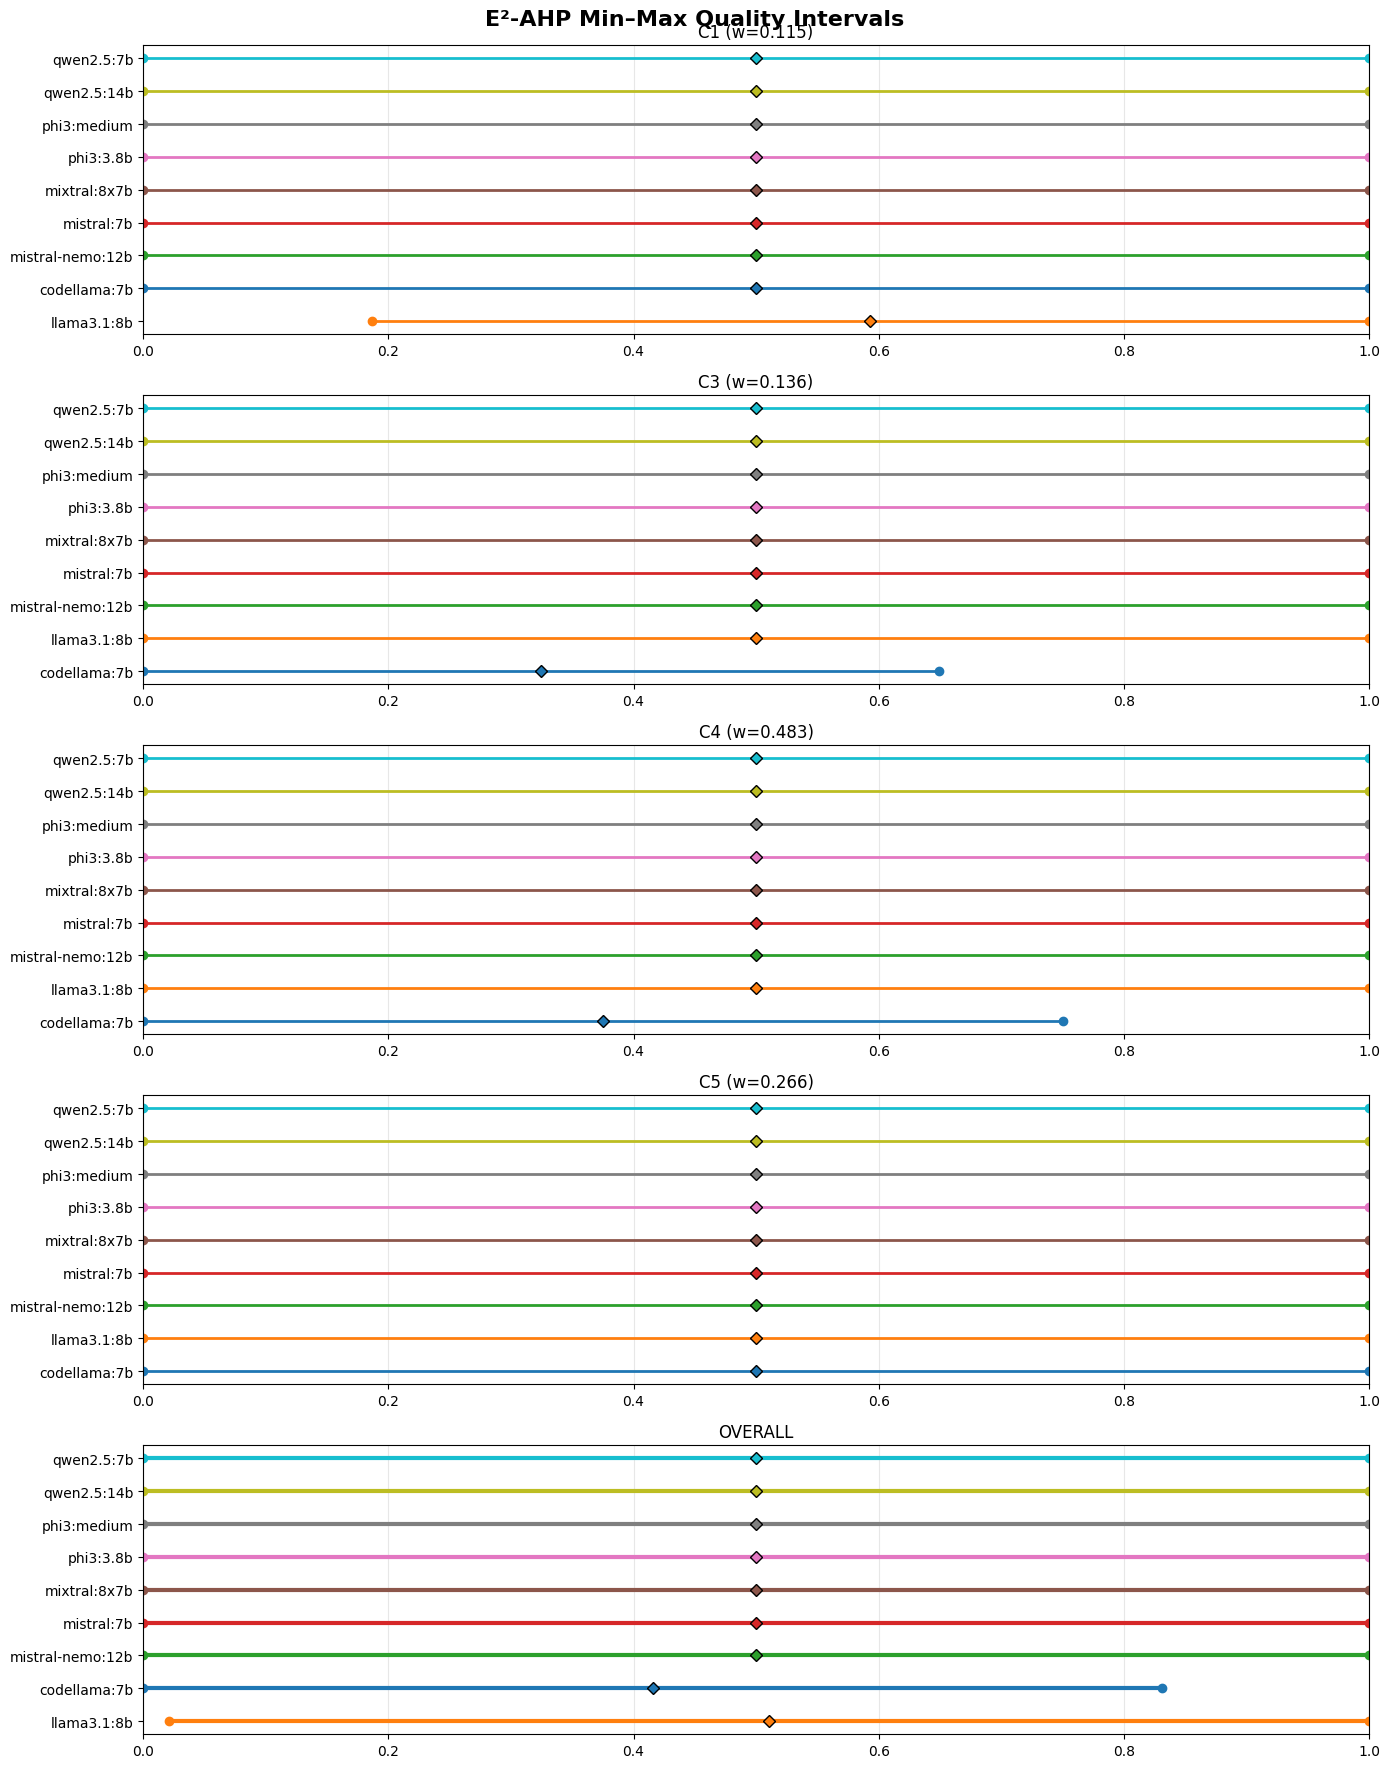

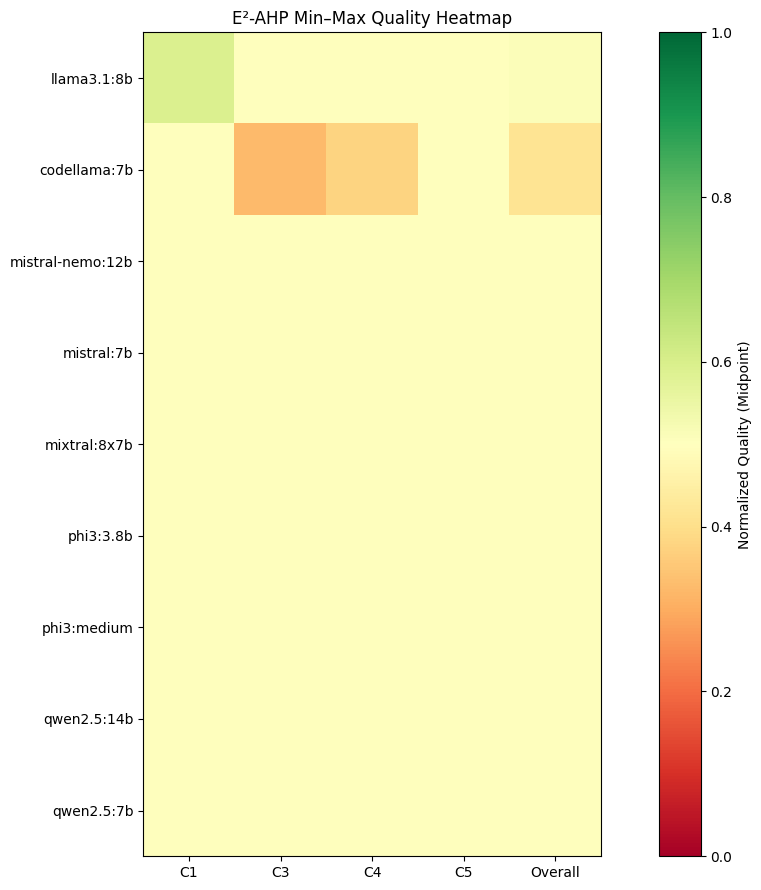

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ================================================================
# LOAD DATA
# ================================================================
df = pd.read_csv('LikertScale.csv')

model_name_map = {
    'n': 'llama3.1:8b',
    'q': 'qwen2.5:7b',
    'm': 'mistral:7b',
    'c': 'codellama:7b',
    'p': 'phi3:3.8b',
    'x': 'mistral-nemo:12b',
    'z': 'qwen2.5:14b',
    'y': 'phi3:medium',
    'w': 'mixtral:8x7b'
}
df['Model'] = df['Model'].map(model_name_map)

criteria_structure = {
    'C1': ['S1.1', 'S1.2'],
    'C3': ['S3.1', 'S3.2'],
    'C4': ['S4.1', 'S4.2'],
    'C5': ['S5.1', 'S5.2']
}

criteria_cols = sum(criteria_structure.values(), [])

criterion_weights = {
    'C1': 0.1149,
    'C3': 0.1363,
    'C4': 0.4830,
    'C5': 0.2658
}

sub_criterion_weights = {
    'S1.1': 0.7458, 'S1.2': 0.2542,
    'S3.1': 0.5959, 'S3.2': 0.4041,
    'S4.1': 0.4856, 'S4.2': 0.5144,
    'S5.1': 0.7360, 'S5.2': 0.2640
}

def normalize(x):
    return (x - 1.0) / 4.0

# ================================================================
# STEP 1: MIN–MAX PER QUESTION
# ================================================================
rows = []

for model in df['Model'].unique():
    mdf = df[df['Model'] == model]
    for q in mdf['question_number'].unique():
        qdf = mdf[mdf['question_number'] == q]
        row = {'Model': model}
        for c in criteria_cols:
            row[f'{c}_min'] = qdf[c].min()
            row[f'{c}_max'] = qdf[c].max()
        rows.append(row)

question_intervals = pd.DataFrame(rows)

# ================================================================
# STEP 2: MODEL-LEVEL SUB-CRITERION INTERVALS
# ================================================================
sub_intervals = {}

for model in question_intervals['Model'].unique():
    mdf = question_intervals[question_intervals['Model'] == model]
    sub_intervals[model] = {}
    for c in criteria_cols:
        sub_intervals[model][c] = (
            mdf[f'{c}_min'].min(),
            mdf[f'{c}_max'].max()
        )

models = sorted(sub_intervals.keys())

# ================================================================
# STEP 3: CRITERION + OVERALL INTERVALS (NORMALIZED)
# ================================================================
criteria_intervals_norm = {}
overall_intervals_norm = {}

for model in models:
    criteria_intervals_norm[model] = {}

    for crit, subs in criteria_structure.items():
        lo = sum(sub_criterion_weights[s] * sub_intervals[model][s][0] for s in subs)
        hi = sum(sub_criterion_weights[s] * sub_intervals[model][s][1] for s in subs)
        criteria_intervals_norm[model][crit] = (normalize(lo), normalize(hi))

    overall_lo = sum(
        criterion_weights[c] *
        sum(sub_criterion_weights[s] * sub_intervals[model][s][0]
            for s in criteria_structure[c])
        for c in criteria_structure
    )

    overall_hi = sum(
        criterion_weights[c] *
        sum(sub_criterion_weights[s] * sub_intervals[model][s][1]
            for s in criteria_structure[c])
        for c in criteria_structure
    )

    overall_intervals_norm[model] = (normalize(overall_lo), normalize(overall_hi))

# ================================================================
# VISUALIZATION SETUP
# ================================================================
colors = plt.cm.tab10(np.linspace(0, 1, len(models)))
model_colors = dict(zip(models, colors))

# ================================================================
# 1️⃣ PER-CRITERION + OVERALL PANELS
# ================================================================
fig, axes = plt.subplots(5, 1, figsize=(14, 18))
fig.suptitle("E²-AHP Min–Max Quality Intervals", fontsize=16, fontweight='bold')

for ax, crit in zip(axes[:4], criteria_structure):
    sorted_models = sorted(models,
                           key=lambda m: criteria_intervals_norm[m][crit][0],
                           reverse=True)
    for i, m in enumerate(sorted_models):
        lo, hi = criteria_intervals_norm[m][crit]
        ax.plot([lo, hi], [i, i], 'o-', color=model_colors[m], linewidth=2)
        ax.plot((lo+hi)/2, i, 'D', color=model_colors[m], markeredgecolor='black')
    ax.set_yticks(range(len(sorted_models)))
    ax.set_yticklabels(sorted_models)
    ax.set_xlim(0, 1)
    ax.set_title(f"{crit} (w={criterion_weights[crit]:.3f})")
    ax.grid(axis='x', alpha=0.3)

# Overall
ax = axes[4]
sorted_models = sorted(models,
                       key=lambda m: overall_intervals_norm[m][0],
                       reverse=True)
for i, m in enumerate(sorted_models):
    lo, hi = overall_intervals_norm[m]
    ax.plot([lo, hi], [i, i], 'o-', color=model_colors[m], linewidth=3)
    ax.plot((lo+hi)/2, i, 'D', color=model_colors[m], markeredgecolor='black')
ax.set_yticks(range(len(sorted_models)))
ax.set_yticklabels(sorted_models)
ax.set_xlim(0, 1)
ax.set_title("OVERALL")
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig("quality_intervals_all.png", dpi=300)
plt.show()

# ================================================================
# 2️⃣ HEATMAP OF MIDPOINTS
# ================================================================
criteria_list = list(criteria_structure.keys()) + ['Overall']
matrix = []

for m in sorted_models:
    row = []
    for c in criteria_list:
        lo, hi = overall_intervals_norm[m] if c == 'Overall' else criteria_intervals_norm[m][c]
        row.append((lo + hi) / 2)
    matrix.append(row)

matrix = np.array(matrix)

fig, ax = plt.subplots(figsize=(12, 9))
im = ax.imshow(matrix, cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(len(criteria_list)))
ax.set_xticklabels(criteria_list)
ax.set_yticks(range(len(sorted_models)))
ax.set_yticklabels(sorted_models)
plt.colorbar(im, ax=ax, label="Normalized Quality (Midpoint)")
plt.title("E²-AHP Min–Max Quality Heatmap")
plt.tight_layout()
plt.savefig("quality_intervals_heatmap.png", dpi=300)
plt.show()


In [ ]:
import pandas as pd
import numpy as np

# ================================================================
# PARAMETERS
# ================================================================
LOW_Q = 25      # lower percentile
HIGH_Q = 75     # upper percentile
LAMBDA = 0.5    # midpoint weighting (0.5 = neutral, 0.6 = conservative)

# ================================================================
# LOAD DATA
# ================================================================
df = pd.read_csv('LikertScale.csv')

model_name_map = {
    'n': 'llama3.1:8b',
    'q': 'qwen2.5:7b',
    'm': 'mistral:7b',
    'c': 'codellama:7b',
    'p': 'phi3:3.8b',
    'x': 'mistral-nemo:12b',
    'z': 'qwen2.5:14b',
    'y': 'phi3:medium',
    'w': 'mixtral:8x7b'
}
df['Model'] = df['Model'].map(model_name_map)

# ================================================================
# CRITERIA & WEIGHTS
# ================================================================
criteria_structure = {
    'C1': ['S1.1', 'S1.2'],
    'C3': ['S3.1', 'S3.2'],
    'C4': ['S4.1', 'S4.2'],
    'C5': ['S5.1', 'S5.2']
}

criteria_cols = sum(criteria_structure.values(), [])

criterion_weights = {
    'C1': 0.1149,
    'C3': 0.1363,
    'C4': 0.4830,
    'C5': 0.2658
}

sub_criterion_weights = {
    'S1.1': 0.7458, 'S1.2': 0.2542,
    'S3.1': 0.5959, 'S3.2': 0.4041,
    'S4.1': 0.4856, 'S4.2': 0.5144,
    'S5.1': 0.7360, 'S5.2': 0.2640
}

# ================================================================
# STEP 1: TRIMMED INTERVALS PER QUESTION
# ================================================================
rows = []

for model in df['Model'].unique():
    mdf = df[df['Model'] == model]
    for q in mdf['question_number'].unique():
        qdf = mdf[mdf['question_number'] == q]
        row = {
            'Model': model,
            'question_number': q,
            'n_evaluators': len(qdf)
        }
        for c in criteria_cols:
            scores = qdf[c].values
            row[f'{c}_low'] = np.percentile(scores, LOW_Q)
            row[f'{c}_high'] = np.percentile(scores, HIGH_Q)
        rows.append(row)

question_intervals_df = pd.DataFrame(rows)

# ================================================================
# STEP 2: MODEL-LEVEL SUB-CRITERION INTERVALS
# ================================================================
sub_intervals = {}

for model in question_intervals_df['Model'].unique():
    mdf = question_intervals_df[question_intervals_df['Model'] == model]
    sub_intervals[model] = {}
    for c in criteria_cols:
        sub_intervals[model][c] = (
            mdf[f'{c}_low'].min(),
            mdf[f'{c}_high'].max()
        )

models = sorted(sub_intervals.keys())

# ================================================================
# STEP 3: CRITERION + OVERALL INTERVALS
# ================================================================
criteria_intervals = {}
overall_intervals = {}

for model in models:
    criteria_intervals[model] = {}

    for crit, subs in criteria_structure.items():
        lo = sum(sub_criterion_weights[s] * sub_intervals[model][s][0] for s in subs)
        hi = sum(sub_criterion_weights[s] * sub_intervals[model][s][1] for s in subs)
        criteria_intervals[model][crit] = (lo, hi)

    overall_lo = sum(
        criterion_weights[c] *
        sum(sub_criterion_weights[s] * sub_intervals[model][s][0]
            for s in criteria_structure[c])
        for c in criteria_structure
    )

    overall_hi = sum(
        criterion_weights[c] *
        sum(sub_criterion_weights[s] * sub_intervals[model][s][1]
            for s in criteria_structure[c])
        for c in criteria_structure
    )

    overall_intervals[model] = (overall_lo, overall_hi)

# ================================================================
# STEP 4: MIDPOINT (CREDAL CENTER)
# ================================================================
summary = []

for model in models:
    lo, hi = overall_intervals[model]
    midpoint = LAMBDA * lo + (1 - LAMBDA) * hi
    summary.append({
        'Model': model,
        'Q_lower': lo,
        'Q_midpoint': midpoint,
        'Q_upper': hi,
        'Interval_Width': hi - lo
    })

summary_df = pd.DataFrame(summary).sort_values(
    by=['Q_midpoint', 'Q_lower'],
    ascending=False
)

# ================================================================
# SAVE OUTPUTS
# ================================================================
question_intervals_df.to_csv(
    'trimmed_intervals_per_question.csv', index=False
)

summary_df.to_csv(
    'model_quality_intervals_trimmed.csv', index=False
)

interval_details = []
for model in models:
    for c in criteria_cols:
        lo, hi = sub_intervals[model][c]
        interval_details.append({
            'Model': model,
            'Criterion': c,
            'Low': lo,
            'High': hi,
            'Width': hi - lo
        })

pd.DataFrame(interval_details).to_csv(
    'criterion_intervals_by_model_trimmed.csv', index=False
)

print("✓ Trimmed Min–Max E²-AHP evaluation complete")
print("✓ Ranking based on weighted midpoint")


✓ Trimmed Min–Max E²-AHP evaluation complete
✓ Ranking based on weighted midpoint


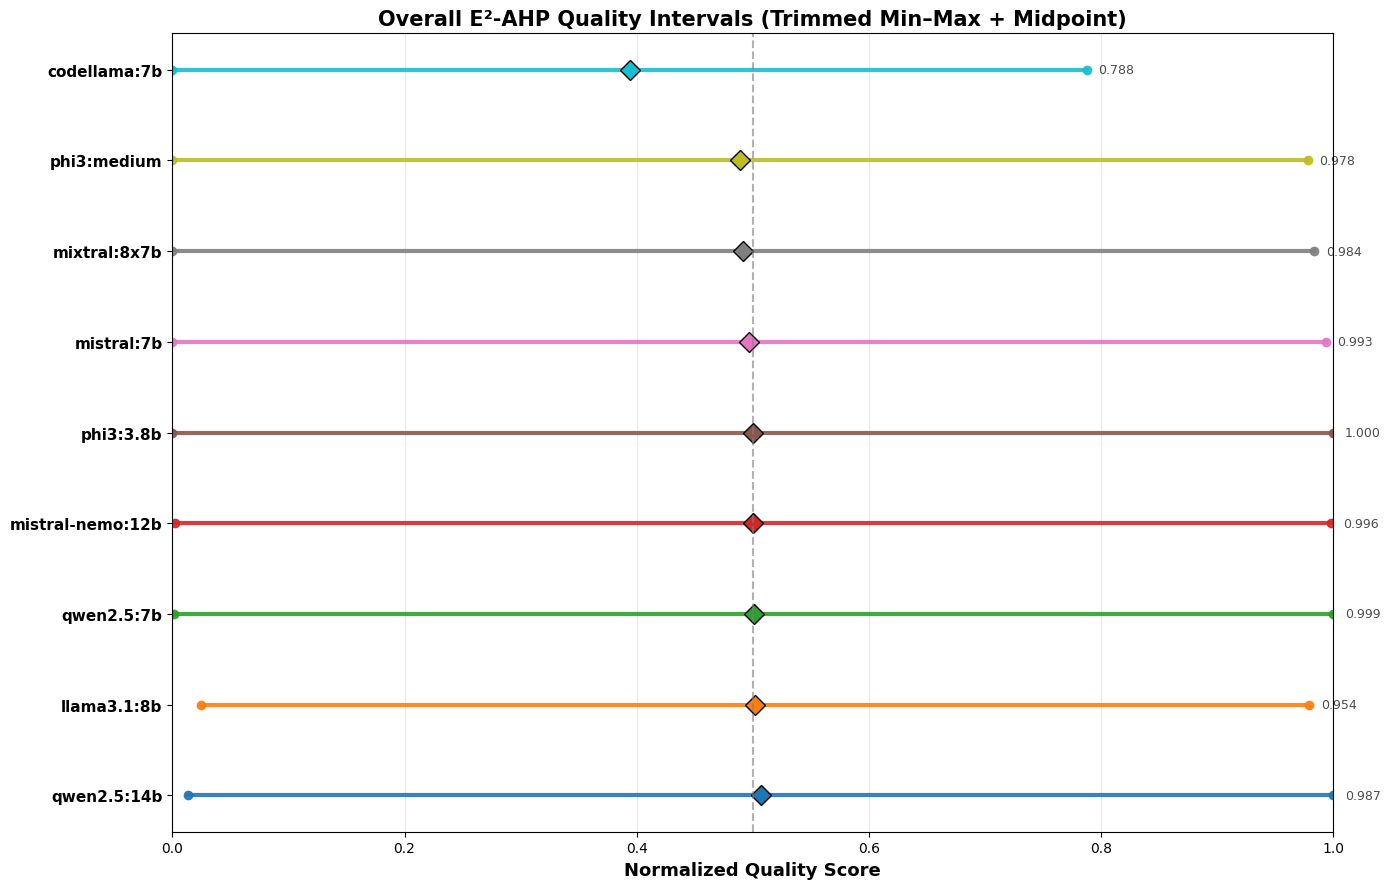

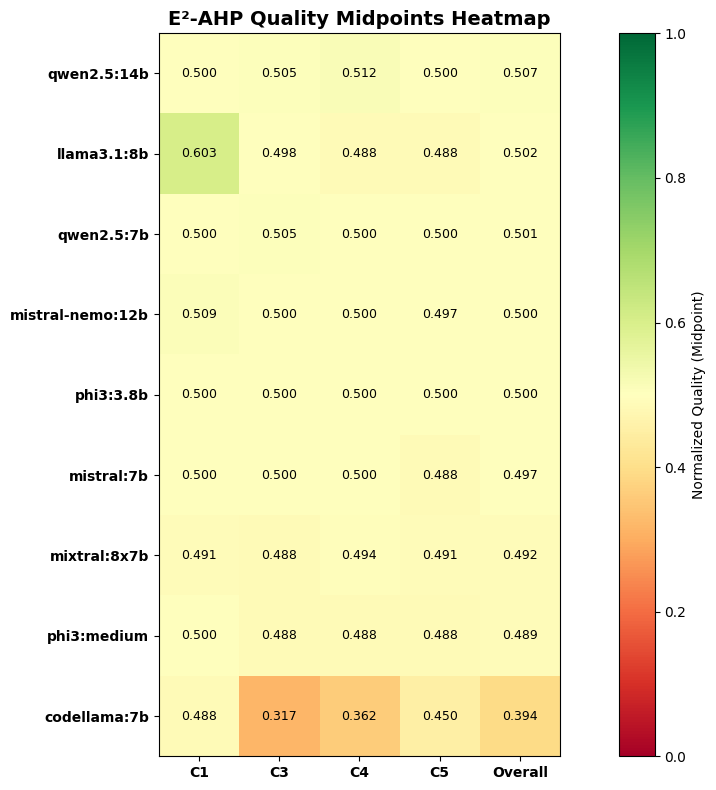

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ================================================================
# PARAMETERS
# ================================================================
LOW_Q = 5
HIGH_Q = 95
LAMBDA = 0.5   # midpoint weight

def normalize(x):
    return (x - 1.0) / 4.0

# ================================================================
# LOAD DATA
# ================================================================
df = pd.read_csv("LikertScale.csv")

model_name_map = {
    'n': 'llama3.1:8b',
    'q': 'qwen2.5:7b',
    'm': 'mistral:7b',
    'c': 'codellama:7b',
    'p': 'phi3:3.8b',
    'x': 'mistral-nemo:12b',
    'z': 'qwen2.5:14b',
    'y': 'phi3:medium',
    'w': 'mixtral:8x7b'
}
df["Model"] = df["Model"].map(model_name_map)

criteria_structure = {
    'C1': ['S1.1', 'S1.2'],
    'C3': ['S3.1', 'S3.2'],
    'C4': ['S4.1', 'S4.2'],
    'C5': ['S5.1', 'S5.2']
}

criterion_weights = {
    'C1': 0.1149,
    'C3': 0.1363,
    'C4': 0.4830,
    'C5': 0.2658
}

sub_criterion_weights = {
    'S1.1': 0.7458, 'S1.2': 0.2542,
    'S3.1': 0.5959, 'S3.2': 0.4041,
    'S4.1': 0.4856, 'S4.2': 0.5144,
    'S5.1': 0.7360, 'S5.2': 0.2640
}

criteria_cols = sum(criteria_structure.values(), [])

# ================================================================
# STEP 1: TRIMMED INTERVALS PER QUESTION
# ================================================================
rows = []

for model in df["Model"].unique():
    mdf = df[df["Model"] == model]
    for q in mdf["question_number"].unique():
        qdf = mdf[mdf["question_number"] == q]
        row = {'Model': model}
        for c in criteria_cols:
            scores = qdf[c].values
            row[f'{c}_low'] = np.percentile(scores, LOW_Q)
            row[f'{c}_high'] = np.percentile(scores, HIGH_Q)
        rows.append(row)

q_intervals = pd.DataFrame(rows)

# ================================================================
# STEP 2: MODEL-LEVEL INTERVALS
# ================================================================
sub_intervals = {}

for model in q_intervals["Model"].unique():
    mdf = q_intervals[q_intervals["Model"] == model]
    sub_intervals[model] = {
        c: (mdf[f'{c}_low'].min(), mdf[f'{c}_high'].max())
        for c in criteria_cols
    }

models = sorted(sub_intervals.keys())

# ================================================================
# STEP 3: CRITERION & OVERALL INTERVALS (NORMALIZED)
# ================================================================
criteria_intervals = {}
overall_intervals = {}

for model in models:
    criteria_intervals[model] = {}
    for crit, subs in criteria_structure.items():
        lo = sum(sub_criterion_weights[s] * sub_intervals[model][s][0] for s in subs)
        hi = sum(sub_criterion_weights[s] * sub_intervals[model][s][1] for s in subs)
        criteria_intervals[model][crit] = (normalize(lo), normalize(hi))

    overall_lo = sum(
        criterion_weights[c] *
        sum(sub_criterion_weights[s] * sub_intervals[model][s][0]
            for s in criteria_structure[c])
        for c in criteria_structure
    )
    overall_hi = sum(
        criterion_weights[c] *
        sum(sub_criterion_weights[s] * sub_intervals[model][s][1]
            for s in criteria_structure[c])
        for c in criteria_structure
    )

    overall_intervals[model] = (
        normalize(overall_lo),
        normalize(overall_hi)
    )

# ================================================================
# STEP 4: MIDPOINTS
# ================================================================
midpoints = {
    m: LAMBDA * overall_intervals[m][0] + (1 - LAMBDA) * overall_intervals[m][1]
    for m in models
}

sorted_models = sorted(models, key=lambda m: midpoints[m], reverse=True)

# ================================================================
# COLORS
# ================================================================
colors = plt.cm.tab10(np.linspace(0, 1, len(models)))
model_colors = dict(zip(sorted_models, colors))

# ================================================================
# 1️⃣ OVERALL INTERVAL PLOT (PRIMARY FIGURE)
# ================================================================
fig, ax = plt.subplots(figsize=(14, 9))

for i, m in enumerate(sorted_models):
    lo, hi = overall_intervals[m]
    mid = midpoints[m]
    ax.plot([lo, hi], [i, i], 'o-', linewidth=3,
            color=model_colors[m], alpha=0.9)
    ax.plot(mid, i, 'D', markersize=10,
            color=model_colors[m], markeredgecolor='black')

    ax.text(hi + 0.01, i, f'{(hi-lo):.3f}',
            va='center', fontsize=9, alpha=0.7)

ax.set_yticks(range(len(sorted_models)))
ax.set_yticklabels(sorted_models, fontsize=11, fontweight='bold')
ax.set_xlabel("Normalized Quality Score", fontsize=13, fontweight='bold')
ax.set_title("Overall E²-AHP Quality Intervals (Trimmed Min–Max + Midpoint)",
             fontsize=15, fontweight='bold')
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.6)
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig("overall_intervals_midpoint.png", dpi=300)
plt.show()

# ================================================================
# 2️⃣ HEATMAP OF MIDPOINTS
# ================================================================
criteria_list = list(criteria_structure.keys()) + ['Overall']
heatmap_data = []

for m in sorted_models:
    row = []
    for c in criteria_list:
        if c == 'Overall':
            row.append(midpoints[m])
        else:
            lo, hi = criteria_intervals[m][c]
            row.append((lo + hi) / 2)
    heatmap_data.append(row)

heatmap_data = np.array(heatmap_data)

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(heatmap_data, cmap='RdYlGn', vmin=0, vmax=1)

ax.set_xticks(range(len(criteria_list)))
ax.set_xticklabels(criteria_list, fontweight='bold')
ax.set_yticks(range(len(sorted_models)))
ax.set_yticklabels(sorted_models, fontweight='bold')

for i in range(len(sorted_models)):
    for j in range(len(criteria_list)):
        ax.text(j, i, f'{heatmap_data[i,j]:.3f}',
                ha='center', va='center', fontsize=9)

plt.colorbar(im, ax=ax, label="Normalized Quality (Midpoint)")
plt.title("E²-AHP Quality Midpoints Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("quality_midpoint_heatmap.png", dpi=300)
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from numpy.linalg import eig

# ================================================================
# LOAD DATA
# ================================================================
df = pd.read_csv("LikertScale.csv")

model_name_map = {
    'n': 'llama3.1:8b',
    'q': 'qwen2.5:7b',
    'm': 'mistral:7b',
    'c': 'codellama:7b',
    'p': 'phi3:3.8b',
    'x': 'mistral-nemo:12b',
    'z': 'qwen2.5:14b',
    'y': 'phi3:medium',
    'w': 'mixtral:8x7b'
}
df['Model'] = df['Model'].map(model_name_map)

# ================================================================
# CRITERIA STRUCTURE & WEIGHTS
# ================================================================
criteria_structure = {
    'C1': ['S1.1', 'S1.2'],
    'C3': ['S3.1', 'S3.2'],
    'C4': ['S4.1', 'S4.2'],
    'C5': ['S5.1', 'S5.2']
}

criteria_cols = sum(criteria_structure.values(), [])

criterion_weights = {
    'C1': 0.1149,
    'C3': 0.1363,
    'C4': 0.4830,
    'C5': 0.2658
}

sub_criterion_weights = {
    'S1.1': 0.7458, 'S1.2': 0.2542,
    'S3.1': 0.5959, 'S3.2': 0.4041,
    'S4.1': 0.4856, 'S4.2': 0.5144,
    'S5.1': 0.7360, 'S5.2': 0.2640
}

models = sorted(df['Model'].unique())

# ================================================================
# AHP FUNCTIONS
# ================================================================
def ahp_priority_vector(matrix):
    """Compute principal eigenvector (normalized)."""
    eigenvalues, eigenvectors = eig(matrix)
    idx = np.argmax(eigenvalues.real)
    vec = eigenvectors[:, idx].real
    return vec / vec.sum()

def pairwise_from_scores(scores):
    """Build pairwise matrix from model scores."""
    n = len(scores)
    M = np.ones((n, n))
    for i in range(n):
        for j in range(n):
            M[i, j] = scores[i] / scores[j]
    return M

# ================================================================
# STEP 1: PER QUESTION × SUB-CRITERION AHP
# ================================================================
rows = []

for q in df['question_number'].unique():
    qdf = df[df['question_number'] == q]

    for sub in criteria_cols:
        means = []
        for m in models:
            vals = qdf[qdf['Model'] == m][sub]
            means.append(vals.mean())

        means = np.array(means)
        pcm = pairwise_from_scores(means)
        priorities = ahp_priority_vector(pcm)

        for m, p in zip(models, priorities):
            rows.append({
                'question_number': q,
                'SubCriterion': sub,
                'Model': m,
                'Priority': p
            })

priority_df = pd.DataFrame(rows)

# ================================================================
# STEP 2: AGGREGATE ACROSS QUESTIONS (GEOMETRIC MEAN)
# ================================================================
agg = (
    priority_df
    .groupby(['Model', 'SubCriterion'])['Priority']
    .apply(lambda x: np.exp(np.mean(np.log(x))))
    .reset_index()
)

# ================================================================
# STEP 3: CRITERION-LEVEL AGGREGATION
# ================================================================
criterion_scores = []

for model in models:
    for crit, subs in criteria_structure.items():
        score = sum(
            sub_criterion_weights[s] *
            agg[(agg['Model'] == model) & (agg['SubCriterion'] == s)]['Priority'].values[0]
            for s in subs
        )
        criterion_scores.append({
            'Model': model,
            'Criterion': crit,
            'Score': score
        })

criterion_df = pd.DataFrame(criterion_scores)

# ================================================================
# STEP 4: OVERALL E²-AHP SCORE
# ================================================================
final_scores = []

for model in models:
    overall = sum(
        criterion_weights[c] *
        criterion_df[
            (criterion_df['Model'] == model) &
            (criterion_df['Criterion'] == c)
        ]['Score'].values[0]
        for c in criteria_structure
    )

    final_scores.append({
        'Model': model,
        'Final_AHP_Score': overall
    })

final_df = pd.DataFrame(final_scores).sort_values(
    by='Final_AHP_Score', ascending=False
)

# ================================================================
# OUTPUT
# ================================================================
final_df.to_csv("pairwise_ahp_model_ranking.csv", index=False)
criterion_df.to_csv("criterion_level_ahp_scores.csv", index=False)
agg.to_csv("subcriterion_ahp_priorities.csv", index=False)

print("\nPAIRWISE AHP RANKING (LIKERT → AHP)")
print(final_df.to_string(index=False))



PAIRWISE AHP RANKING (LIKERT → AHP)
           Model  Final_AHP_Score
     qwen2.5:14b         0.142370
     llama3.1:8b         0.123134
      qwen2.5:7b         0.121832
mistral-nemo:12b         0.106638
      mistral:7b         0.105453
    mixtral:8x7b         0.102692
     phi3:medium         0.089481
    codellama:7b         0.077351
       phi3:3.8b         0.065162


In [ ]:
import pandas as pd
import numpy as np
from numpy.linalg import eig

# ================================================================
# LOAD DATA
# ================================================================
df = pd.read_csv("LikertScale.csv")

model_name_map = {
    'n': 'llama3.1:8b',
    'q': 'qwen2.5:7b',
    'm': 'mistral:7b',
    'c': 'codellama:7b',
    'p': 'phi3:3.8b',
    'x': 'mistral-nemo:12b',
    'z': 'qwen2.5:14b',
    'y': 'phi3:medium',
    'w': 'mixtral:8x7b'
}
df['Model'] = df['Model'].map(model_name_map)

# ================================================================
# CRITERIA STRUCTURE & WEIGHTS
# ================================================================
criteria_structure = {
    'C1': ['S1.1', 'S1.2'],
    'C3': ['S3.1', 'S3.2'],
    'C4': ['S4.1', 'S4.2'],
    'C5': ['S5.1', 'S5.2']
}

criteria_cols = sum(criteria_structure.values(), [])

criterion_weights = {
    'C1': 0.1149,
    'C3': 0.1363,
    'C4': 0.4830,
    'C5': 0.2658
}

sub_criterion_weights = {
    'S1.1': 0.7458, 'S1.2': 0.2542,
    'S3.1': 0.5959, 'S3.2': 0.4041,
    'S4.1': 0.4856, 'S4.2': 0.5144,
    'S5.1': 0.7360, 'S5.2': 0.2640
}

models = sorted(df['Model'].unique())

# ================================================================
# AHP FUNCTIONS
# ================================================================
def ahp_priority_vector(matrix):
    eigenvalues, eigenvectors = eig(matrix)
    idx = np.argmax(eigenvalues.real)
    vec = eigenvectors[:, idx].real
    return vec / vec.sum()

def pairwise_from_scores(scores):
    n = len(scores)
    M = np.ones((n, n))
    for i in range(n):
        for j in range(n):
            M[i, j] = scores[i] / scores[j]
    return M

# ================================================================
# STEP 1: INTERVAL AHP PER QUESTION × SUB-CRITERION
# ================================================================
rows = []

for q in df['question_number'].unique():
    qdf = df[df['question_number'] == q]

    for sub in criteria_cols:
        mins, maxs = [], []

        for m in models:
            vals = qdf[qdf['Model'] == m][sub]
            mins.append(vals.min())
            maxs.append(vals.max())

        mins = np.array(mins)
        maxs = np.array(maxs)

        pcm_low = pairwise_from_scores(mins)
        pcm_high = pairwise_from_scores(maxs)

        p_low = ahp_priority_vector(pcm_low)
        p_high = ahp_priority_vector(pcm_high)

        for i, m in enumerate(models):
            rows.append({
                'question_number': q,
                'SubCriterion': sub,
                'Model': m,
                'Priority_Low': p_low[i],
                'Priority_High': p_high[i]
            })

priority_interval_df = pd.DataFrame(rows)

# ================================================================
# STEP 2: AGGREGATE ACROSS QUESTIONS (GEOMETRIC MEAN, INTERVAL)
# ================================================================
agg = (
    priority_interval_df
    .groupby(['Model', 'SubCriterion'])
    .agg({
        'Priority_Low': lambda x: np.exp(np.mean(np.log(x))),
        'Priority_High': lambda x: np.exp(np.mean(np.log(x)))
    })
    .reset_index()
)

# ================================================================
# STEP 3: CRITERION-LEVEL INTERVAL AGGREGATION
# ================================================================
criterion_rows = []

for model in models:
    for crit, subs in criteria_structure.items():
        low = sum(
            sub_criterion_weights[s] *
            agg[(agg['Model'] == model) & (agg['SubCriterion'] == s)]['Priority_Low'].values[0]
            for s in subs
        )
        high = sum(
            sub_criterion_weights[s] *
            agg[(agg['Model'] == model) & (agg['SubCriterion'] == s)]['Priority_High'].values[0]
            for s in subs
        )
        criterion_rows.append({
            'Model': model,
            'Criterion': crit,
            'Low': low,
            'High': high
        })

criterion_interval_df = pd.DataFrame(criterion_rows)

# ================================================================
# STEP 4: GLOBAL E²-AHP INTERVAL
# ================================================================
final_rows = []

for model in models:
    Q_low = sum(
        criterion_weights[c] *
        criterion_interval_df[
            (criterion_interval_df['Model'] == model) &
            (criterion_interval_df['Criterion'] == c)
        ]['Low'].values[0]
        for c in criteria_structure
    )

    Q_high = sum(
        criterion_weights[c] *
        criterion_interval_df[
            (criterion_interval_df['Model'] == model) &
            (criterion_interval_df['Criterion'] == c)
        ]['High'].values[0]
        for c in criteria_structure
    )

    final_rows.append({
        'Model': model,
        'Q_Low': Q_low,
        'Q_High': Q_high,
        'Width': Q_high - Q_low,
        'Midpoint': (Q_low + Q_high) / 2
    })

final_interval_df = pd.DataFrame(final_rows).sort_values(
    by='Midpoint', ascending=False
)

# ================================================================
# OUTPUT
# ================================================================
final_interval_df.to_csv("interval_pairwise_ahp_model_scores.csv", index=False)
criterion_interval_df.to_csv("criterion_interval_scores.csv", index=False)
agg.to_csv("subcriterion_interval_priorities.csv", index=False)

print("\nINTERVAL PAIRWISE AHP RANKING")
print(final_interval_df.to_string(index=False))



INTERVAL PAIRWISE AHP RANKING
           Model    Q_Low   Q_High     Width  Midpoint
     qwen2.5:14b 0.155946 0.131877 -0.024069  0.143911
     llama3.1:8b 0.112596 0.123761  0.011165  0.118179
      qwen2.5:7b 0.111982 0.123348  0.011366  0.117665
mistral-nemo:12b 0.100469 0.109788  0.009319  0.105129
    mixtral:8x7b 0.099653 0.103744  0.004090  0.101699
      mistral:7b 0.091973 0.109476  0.017503  0.100725
     phi3:medium 0.086053 0.087831  0.001778  0.086942
    codellama:7b 0.076206 0.078315  0.002109  0.077260
       phi3:3.8b 0.075597 0.058802 -0.016795  0.067200


In [ ]:
import pandas as pd
import numpy as np

# ================================================================
# LOAD DATA
# ================================================================
df = pd.read_csv("LikertScale.csv")

model_name_map = {
    'n': 'llama3.1:8b',
    'q': 'qwen2.5:7b',
    'm': 'mistral:7b',
    'c': 'codellama:7b',
    'p': 'phi3:3.8b',
    'x': 'mistral-nemo:12b',
    'z': 'qwen2.5:14b',
    'y': 'phi3:medium',
    'w': 'mixtral:8x7b'
}
df['Model'] = df['Model'].map(model_name_map)

models = sorted(df['Model'].unique())

# ================================================================
# CRITERIA STRUCTURE & WEIGHTS
# ================================================================
criteria_structure = {
    'C1': ['S1.1', 'S1.2'],
    'C3': ['S3.1', 'S3.2'],
    'C4': ['S4.1', 'S4.2'],
    'C5': ['S5.1', 'S5.2']
}

criteria_cols = sum(criteria_structure.values(), [])

criterion_weights = {
    'C1': 0.1149,
    'C3': 0.1363,
    'C4': 0.4830,
    'C5': 0.2658
}

sub_criterion_weights = {
    'S1.1': 0.7458, 'S1.2': 0.2542,
    'S3.1': 0.5959, 'S3.2': 0.4041,
    'S4.1': 0.4856, 'S4.2': 0.5144,
    'S5.1': 0.7360, 'S5.2': 0.2640
}

# ================================================================
# INTERVAL GEOMETRIC AHP FUNCTION (CORE)
# ================================================================
def interval_ahp_from_scores(min_scores, max_scores):
    """
    Interval AHP via geometric mean (monotone & safe).
    Returns priority intervals [low, high].
    """
    n = len(min_scores)

    low_pcm = np.zeros((n, n))
    high_pcm = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            low_pcm[i, j] = min_scores[i] / max_scores[j]
            high_pcm[i, j] = max_scores[i] / min_scores[j]

    gm_low = np.prod(low_pcm, axis=1) ** (1 / n)
    gm_high = np.prod(high_pcm, axis=1) ** (1 / n)

    priority_low = gm_low / gm_high.sum()
    priority_high = gm_high / gm_low.sum()

    return priority_low, priority_high

# ================================================================
# STEP 1: QUESTION × SUB-CRITERION INTERVAL AHP
# ================================================================
rows = []

for q in sorted(df['question_number'].unique()):
    qdf = df[df['question_number'] == q]

    for sub in criteria_cols:
        min_scores = []
        max_scores = []

        for m in models:
            vals = qdf[qdf['Model'] == m][sub]
            min_scores.append(vals.min())
            max_scores.append(vals.max())

        min_scores = np.array(min_scores)
        max_scores = np.array(max_scores)

        low_p, high_p = interval_ahp_from_scores(min_scores, max_scores)

        for m, lo, hi in zip(models, low_p, high_p):
            rows.append({
                'Question': q,
                'SubCriterion': sub,
                'Model': m,
                'Priority_Low': lo,
                'Priority_High': hi
            })

interval_df = pd.DataFrame(rows)

# ================================================================
# STEP 2: AGGREGATE ACROSS QUESTIONS (MIN–MAX ENVELOPE)
# ================================================================
agg_sub = (
    interval_df
    .groupby(['Model', 'SubCriterion'])
    .agg(
        Low=('Priority_Low', 'min'),
        High=('Priority_High', 'max')
    )
    .reset_index()
)

# ================================================================
# STEP 3: CRITERION-LEVEL INTERVALS
# ================================================================
criterion_rows = []

for model in models:
    for crit, subs in criteria_structure.items():
        low = sum(
            sub_criterion_weights[s] *
            agg_sub[(agg_sub.Model == model) & (agg_sub.SubCriterion == s)]['Low'].values[0]
            for s in subs
        )
        high = sum(
            sub_criterion_weights[s] *
            agg_sub[(agg_sub.Model == model) & (agg_sub.SubCriterion == s)]['High'].values[0]
            for s in subs
        )

        criterion_rows.append({
            'Model': model,
            'Criterion': crit,
            'Low': low,
            'High': high
        })

criterion_df = pd.DataFrame(criterion_rows)

# ================================================================
# STEP 4: OVERALL E²-AHP INTERVAL
# ================================================================
final_rows = []

for model in models:
    low = sum(
        criterion_weights[c] *
        criterion_df[(criterion_df.Model == model) & (criterion_df.Criterion == c)]['Low'].values[0]
        for c in criteria_structure
    )
    high = sum(
        criterion_weights[c] *
        criterion_df[(criterion_df.Model == model) & (criterion_df.Criterion == c)]['High'].values[0]
        for c in criteria_structure
    )

    final_rows.append({
        'Model': model,
        'Q_Low': low,
        'Q_High': high,
        'Width': high - low,
        'Midpoint': (low + high) / 2
    })

final_df = pd.DataFrame(final_rows).sort_values(
    by=['Q_Low', 'Q_High'], ascending=False
)

# ================================================================
# OUTPUT
# ================================================================
final_df.to_csv("interval_pairwise_ahp_ranking.csv", index=False)
criterion_df.to_csv("criterion_interval_scores.csv", index=False)
agg_sub.to_csv("subcriterion_interval_priorities.csv", index=False)

print("\nINTERVAL PAIRWISE AHP RANKING (GEOMETRIC)")
print(final_df.to_string(index=False))



INTERVAL PAIRWISE AHP RANKING (GEOMETRIC)
           Model    Q_Low   Q_High    Width  Midpoint
     qwen2.5:14b 0.013721 0.875944 0.862223  0.444833
      qwen2.5:7b 0.013487 1.001698 0.988210  0.507593
      mistral:7b 0.013291 0.929416 0.916125  0.471354
     llama3.1:8b 0.013118 0.964331 0.951213  0.488724
mistral-nemo:12b 0.011719 1.074314 1.062595  0.543016
    mixtral:8x7b 0.011521 1.053972 1.042451  0.532746
       phi3:3.8b 0.011521 0.686757 0.675236  0.349139
     phi3:medium 0.011424 0.869532 0.858109  0.440478
    codellama:7b 0.011424 0.823635 0.812211  0.417529


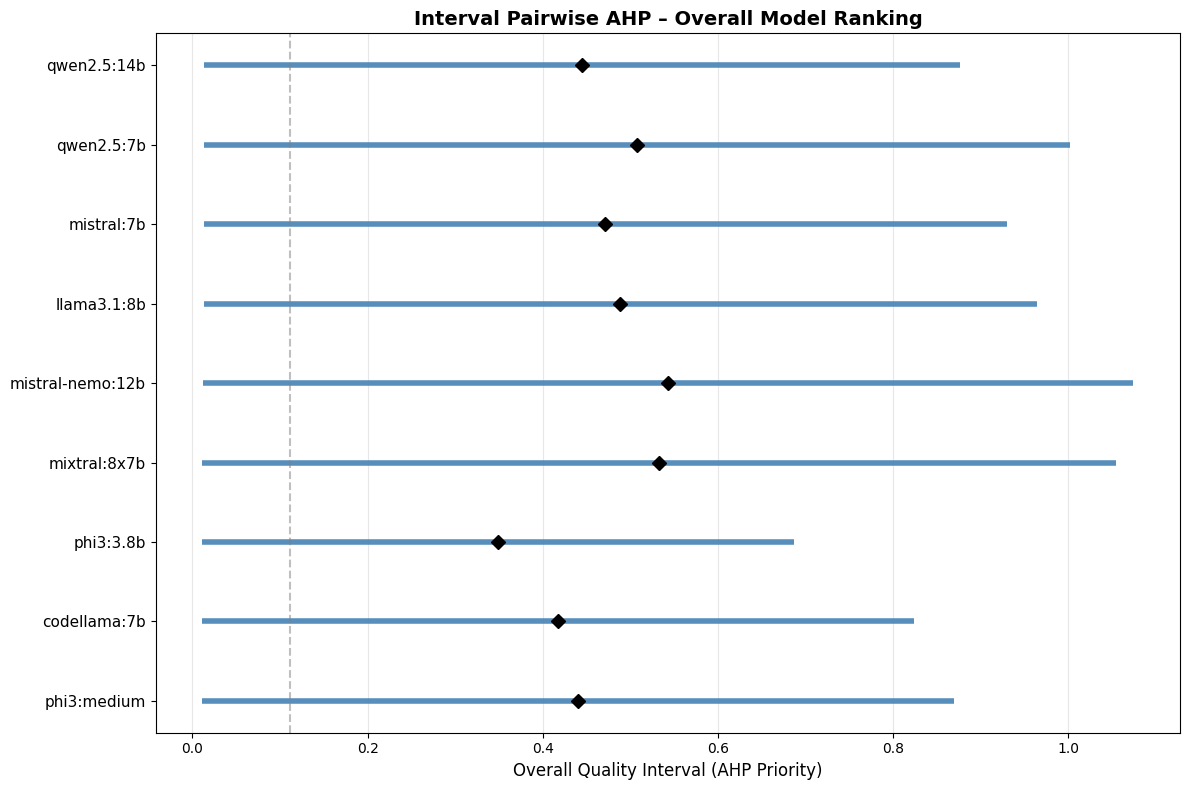

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# OVERALL INTERVAL RANKING
# =========================
fig, ax = plt.subplots(figsize=(12, 8))

sorted_df = final_df.sort_values(by='Q_Low', ascending=True)

y_pos = np.arange(len(sorted_df))

ax.hlines(
    y=y_pos,
    xmin=sorted_df['Q_Low'],
    xmax=sorted_df['Q_High'],
    linewidth=4,
    color='steelblue',
    alpha=0.9
)

# Midpoints
ax.plot(
    sorted_df['Midpoint'],
    y_pos,
    'D',
    color='black',
    markersize=7,
    label='Midpoint'
)

ax.set_yticks(y_pos)
ax.set_yticklabels(sorted_df['Model'], fontsize=11)
ax.set_xlabel("Overall Quality Interval (AHP Priority)", fontsize=12)
ax.set_title("Interval Pairwise AHP – Overall Model Ranking", fontsize=14, fontweight='bold')

ax.grid(axis='x', alpha=0.3)
ax.axvline(1 / len(models), linestyle='--', color='gray', alpha=0.5)

plt.tight_layout()
plt.savefig("overall_interval_ranking.png", dpi=300)
plt.show()


# Task
Here's an analysis and comparison of the evaluation methodologies applied in your notebook:

## Analysis of Evaluation Methodologies for Human-Centered Likert Scale Data

This analysis will cover TOPSIS, E²-AHP (Geometric Mean), E²-AHP (Min-Max), E²-AHP (Trimmed Min-Max), AHP (Eigenvector Method), and Interval Pairwise AHP, assessing their suitability for human-centered Likert scale data and comparing their outcomes.

### 1. Summary of Evaluation Approaches

**a. TOPSIS (Technique for Order Preference by Similarity to Ideal Solution)**
*   **Core Mechanics**: TOPSIS is a multi-criteria decision-making (MCDM) method. It works by identifying an ideal best solution and an ideal worst solution for each criterion. The best alternative is then chosen as the one closest to the ideal best solution and farthest from the ideal worst solution. It requires normalized data and applies criterion weights.
*   **Application in Notebook**: In the notebook, TOPSIS was applied using global AHP weights derived from consistent judges (criteria) and all judges (sub-criteria). The data used for alternative performance (models) were raw scores from the Likert scale for sub-criteria.

**b. E²-AHP (Geometric Mean)**
*   **Core Mechanics**: This method combines elements of AHP with interval analysis (E² stands for Evidence-based and Evidential AHP). It uses geometric means to aggregate Likert scores from multiple evaluators for each model-question-criterion combination, forming a point estimate of consensus. Then, for each model and criterion, it constructs an interval from the minimum and maximum of these geometric means across all questions. These intervals are then weighted by AHP-derived global weights to produce an overall quality interval for each model.
*   **Application in Notebook**: This is the "E²-AHP (Corrected)" version. It uses AHP-derived weights, aggregates individual Likert scores per model-question-sub-criterion via geometric mean, forms intervals per model and sub-criterion using the min/max of these geometric means, and then aggregates these weighted intervals to criterion and overall levels. Normalized results are provided.

**c. E²-AHP (Min-Max)**
*   **Core Mechanics**: Similar to the E²-AHP (Geometric Mean) but uses a more direct aggregation for initial intervals. For each model-question-criterion, it directly takes the minimum and maximum Likert scores given by evaluators to form an interval. These question-level intervals are then consolidated into model-level intervals (min of mins, max of maxs) and subsequently weighted by AHP global weights to generate an overall quality interval for each model.
*   **Application in Notebook**: The version labeled "E²-AHP evaluation (Min-Max per question)" in the summary table.

**d. E²-AHP (Trimmed Min-Max)**
*   **Core Mechanics**: This is a variant of E²-AHP (Min-Max) that addresses outliers or extreme judgments. Instead of taking the absolute min and max, it uses percentiles (e.g., 5th and 95th or 25th and 75th percentile) of the evaluator scores for each model-question-criterion to form the initial interval. This trimming reduces the influence of extreme opinions. The rest of the aggregation process is similar to other E²-AHP methods, leading to an overall quality interval.
*   **Application in Notebook**: Used 25th and 75th percentiles (LOW_Q=25, HIGH_Q=75) for trimming and introduces a midpoint weighting (LAMBDA=0.5) for ranking.

**e. AHP (Eigenvector Method)**
*   **Core Mechanics**: AHP, in its classic form, involves constructing pairwise comparison matrices and deriving priority vectors (weights) using the eigenvector method. For alternative evaluation, this typically involves converting performance scores into a pairwise comparison matrix (e.g., model A is X times better than model B on a criterion) and then deriving relative priorities for alternatives. These are then combined hierarchically with criteria weights.
*   **Application in Notebook**: Used to derive priorities for models based on the mean Likert scores for each sub-criterion for each question, then aggregated across questions using geometric mean, and finally combined using the pre-calculated criteria weights. This yields a single, crisp score for each model.

**f. Interval Pairwise AHP (Geometric)**
*   **Core Mechanics**: This extends the AHP (Eigenvector Method) to handle uncertainty in judgments. Instead of deriving a single priority value, it computes an interval priority for each alternative. This is often done by performing AHP twice – once with the lower bounds of judgments/scores and once with the upper bounds. These interval priorities are then aggregated hierarchically to yield overall interval scores for the alternatives. The geometric mean is often used for aggregation within interval AHP due to its mathematical properties.
*   **Application in Notebook**: Used min/max Likert scores per model-question-sub-criterion to form pairwise comparison matrices (PCM_low and PCM_high), then derived low/high priority vectors using geometric mean. These interval priorities are aggregated across questions (min/max envelope) and then hierarchically weighted to produce final quality intervals.

### 2. Analysis of Suitability for Human-Centered Evaluation

| Method | Advantages for Human-Centered Likert Data | Disadvantages |
|---|---|---|
| **TOPSIS** | - Relatively straightforward calculation and interpretation.<br>- Uses crisp input scores which are common with Likert data.<br>- Provides a clear ranking. | - Treats human judgments as precise numbers, ignoring their inherent subjectivity and uncertainty.<br>- Sensitive to score scale and normalization method.<br>- Does not inherently handle variability *within* evaluator scores for a given item, only *across* items. |
| **E²-AHP (Geometric Mean)** | - **Handles evaluator disagreement**: Geometric mean is good for aggregating scores from multiple evaluators, capturing consensus while mitigating extreme values.<br>- **Captures performance range**: Intervals show performance variability across different 'questions' or contexts, which is crucial for human-centered tasks.<br>- **Structured weighting**: Inherits the AHP's ability to structure criteria and assign subjective weights.<br>- **Transparency**: Clearly delineates uncertainty via intervals. | - Can still be sensitive to outliers if not trimmed (though less than arithmetic mean).<br>- Dominance relationships can be unclear if intervals heavily overlap, requiring secondary ranking rules (midpoint, etc.).<br>- Requires careful interpretation of intervals, not just point estimates. |
| **E²-AHP (Min-Max)** | - **Strongest uncertainty representation**: Provides the widest possible interval of performance, reflecting the full range of human perception and variability across contexts.<br>- **Simplicity**: Conceptually easy to understand the interval formation (absolute min/max). | - **Overly pessimistic/optimistic**: Extremely sensitive to outliers/single extreme evaluations, potentially leading to very wide and less informative intervals.<br>- Lack of statistical robustness (no central tendency measure). |
| **E²-AHP (Trimmed Min-Max)** | - **Robust to outliers**: Using percentiles filters out extreme human judgments, providing more realistic and actionable intervals.<br>- **Balances uncertainty with realism**: Offers a good compromise between capturing variability and avoiding the distortion from single extreme opinions.<br>- **Flexibility**: Percentile thresholds can be adjusted based on confidence in human evaluators. | - Choice of trimming percentiles (e.g., 25th/75th vs. 5th/95th) is subjective and can impact results.<br>- Requires sufficient number of evaluators to make trimming meaningful. |
| **AHP (Eigenvector Method)** | - **Strong theoretical foundation for weighting**: Excellent for structuring complex decision problems and deriving consistent subjective weights from human pairwise comparisons.<br>- **Single crisp score**: Provides a definitive ranking, easy for decision-makers to grasp. | - **Collapses all uncertainty**: Converts intervals of human judgments into single point estimates, losing valuable information about variability and disagreement.<br>- The process of converting Likert scores into pairwise comparisons (e.g., `scores[i] / scores[j]`) can be problematic if the scores are not ratio scale.
| **Interval Pairwise AHP (Geometric)** | - **Integrates uncertainty throughout**: Propagates interval judgments from the lowest level (per question, per sub-criterion) up to the overall score, providing a comprehensive view of performance ranges.<br>- **Mathematically robust**: Geometric mean is appropriate for ratio-scale comparisons, and interval math inherently handles ranges.<br>- **Consistent with AHP principles**: Leverages the strength of AHP for structuring hierarchy while addressing its limitation in handling uncertainty. | - Can produce very wide intervals if input uncertainty is high, making clear ranking difficult.<br>- Interpretation of overlapping intervals still requires additional rules or visual analysis.<br>- Computationally more complex than point-estimate AHP. |

### 3. Comparison of Rankings and Insights

Let's look at the overall rankings produced by each method (best to worst):

| Rank | TOPSIS (Scores) | E²-AHP (Geometric Mean, Norm. Q_Lower) | E²-AHP (Min-Max, Norm. Q_Lower) | E²-AHP (Trimmed Min-Max, Norm. Q_Midpoint) | AHP (Eigenvector, Score) | Interval Pairwise AHP (Geometric, Q_Low) |
|---|---|---|---|---|---|---|
| **1** | qwen2.5:14b (0.98) | qwen2.5:14b (0.1184) | qwen2.5:14b (0.0134) | qwen2.5:14b (3.13) | qwen2.5:14b (0.142) | qwen2.5:14b (0.0137) |
| **2** | qwen2.5:7b (0.67) | llama3.1:8b (0.1020) | qwen2.5:7b (0.0013) | qwen2.5:7b (3.01) | llama3.1:8b (0.123) | qwen2.5:7b (0.0134) |
| **3** | llama3.1:8b (0.64) | mistral-nemo:12b (0.0782) | llama3.1:8b (0.0062) | mistral-nemo:12b (3.00) | qwen2.5:7b (0.121) | mistral:7b (0.0132) |
| **4** | mixtral:8x7b (0.49) | qwen2.5:7b (0.0685) | mistral-nemo:12b (0.0021) | phi3:3.8b (3.00) | mistral-nemo:12b (0.106) | llama3.1:8b (0.0131) |
| **5** | mistral-nemo:12b (0.48) | mistral:7b (0.0649) | mixtral:8x7b (0.0) | mistral:7b (2.93) | mistral:7b (0.105) | mistral-nemo:12b (0.0117) |
| **6** | mistral:7b (0.44) | codellama:7b (0.0167) | mistral:7b (0.0) | llama3.1:8b (2.86) | mixtral:8x7b (0.102) | mixtral:8x7b (0.0115) |
| **7** | phi3:medium (0.31) | phi3:3.8b (0.0) | codellama:7b (0.0) | mixtral:8x7b (2.78) | phi3:medium (0.089) | phi3:3.8b (0.0115) |
| **8** | codellama:7b (0.07) | phi3:medium (0.0) | phi3:3.8b (0.0) | phi3:medium (2.70) | codellama:7b (0.077) | phi3:medium (0.0114) |
| **9** | phi3:3.8b (0.00) | mixtral:8x7b (0.0) | phi3:medium (0.0) | codellama:7b (2.29) | phi3:3.8b (0.065) | codellama:7b (0.0114) |

**Key Insights from Ranking Comparison:**

*   **Top Performer Consistency**: `qwen2.5:14b` consistently ranks as the top model across all methods. This suggests its performance is robustly considered superior across different aggregation and uncertainty handling techniques.
*   **Discord in Mid-to-Lower Ranks**: There is significant variation in the rankings for models outside the very top spot.
    *   TOPSIS places `qwen2.5:7b` second and `llama3.1:8b` third, which is somewhat mirrored by the E²-AHP (Geometric Mean) ranking by Q_lower.
    *   E²-AHP (Min-Max) ranks `qwen2.5:7b` high but `llama3.1:8b` much lower, indicating `llama3.1:8b` might have wider intervals due to its performance variance across questions and evaluators.
    *   AHP (Eigenvector) and Interval Pairwise AHP show similar top 3 to E²-AHP (Geometric Mean).
    *   E²-AHP (Trimmed Min-Max) seems to produce quite different orderings, especially in the middle, likely due to how it handles the trimmed range for midpoints.
*   **Influence of Uncertainty Handling**: Methods that embrace uncertainty (E²-AHP variants, Interval Pairwise AHP) tend to show significant overlap in model performance intervals, often leading to "No clear dominance relationships." This is a crucial insight: while a crisp ranking can be generated by prioritizing a single metric (like Q_lower or midpoint), the underlying data suggests that many models are statistically indistinguishable, especially in the middle ranks.
*   **AHP vs. E²-AHP**: The traditional AHP (Eigenvector) provides a crisp ranking but loses information about the range and variability of performance. E²-AHP methods provide richer insights into *how* models perform (e.g., consistent vs. variable performance).
*   **Geometric Mean vs. Min-Max (raw) vs. Trimmed Min-Max**:
    *   **Min-Max (raw)**: Produces the widest intervals due to being highly sensitive to individual evaluator scores or extreme question performance. This might make it hard to differentiate models without dominance.
    *   **Geometric Mean**: Provides more stable central tendency for intervals than raw min/max, as outliers have less impact. Intervals are more representative of the 'typical' range.
    *   **Trimmed Min-Max**: Offers a good balance by excluding extreme values, leading to more realistic and actionable intervals by ignoring very high/low individual scores.

### 4. Recommendation for Optimal Approach

For your specific goal of evaluating 9 models based on human-centered Likert scale data, dealing with subjectivity, and aggregating diverse judgments, the **E²-AHP (Geometric Mean) or E²-AHP (Trimmed Min-Max)** approaches are most optimal.

**Justification:**

1.  **Handling Subjectivity and Aggregation**: Both E²-AHP variants use AHP for systematic and consistent weighting of criteria, which is excellent for incorporating subjective importance from human experts. The use of **geometric mean** for aggregating individual Likert scores per item/question is superior to arithmetic mean for ordinal data and for mitigating the impact of extreme individual opinions, representing a more robust consensus.
2.  **Capturing Variability and Uncertainty**: This is where E²-AHP truly shines. Human-centered evaluations are inherently uncertain and variable. Traditional methods like TOPSIS or a single-point AHP flatten this complexity into a single score, losing critical information. E²-AHP's interval approach explicitly models this uncertainty by presenting performance as a range (`[Q_lower, Q_upper]`). This acknowledges that a model's performance isn't fixed but varies depending on the context (questions) and evaluators.
3.  **Insights from Intervals**: The intervals provide rich insights:
    *   **Robustness**: Models with narrower intervals indicate more consistent performance across different questions/contexts.
    *   **Risk/Opportunity**: The lower bound (`Q_lower`) indicates the worst-case performance, which is a critical risk metric. The upper bound (`Q_upper`) shows the best-case potential.
    *   **Dominance**: The dominance analysis (`Q_A_low >= Q_B_high`) is a powerful concept for identifying truly superior models, rather than just models that happen to have a slightly higher point score. If no models dominate, it means the performance ranges overlap significantly, suggesting further investigation or caution against declaring a single "best" model.
4.  **Suitability of Trimmed Mean**: If your human evaluators sometimes provide unusually high or low scores that might be considered noise or extreme opinions rather than truly representative data points, the **E²-AHP (Trimmed Min-Max)** is particularly valuable. By using percentiles (e.g., 25th-75th), it focuses on the central tendency of human judgments, making the resulting intervals more actionable and less prone to distortion by outliers. The "midpoint weighting" can then provide a pragmatic ranking within these more robust intervals.
5.  **Normalization**: Normalizing the scores (as done in the E²-AHP (Geometric Mean, Normalized) version) to a 0-1 scale makes the results highly interpretable as "percentage of ideal performance," which is intuitive for human decision-makers.

**Why not other methods?**
*   **TOPSIS / AHP (Eigenvector)**: While simpler, they sacrifice the crucial uncertainty and variability inherent in human judgment, potentially leading to misleading crisp rankings.
*   **E²-AHP (Min-Max, raw)**: Too sensitive to extreme values, potentially yielding overly wide and less useful intervals.
*   **Interval Pairwise AHP (Geometric)**: While theoretically sound for propagating interval judgments, its complexity and the potential for very wide intervals (as seen in the output) might make practical interpretation challenging, especially if the data quality is inconsistent. The approach of forming intervals from aggregated geometric means (as in E²-AHP) might be a more pragmatic balance for Likert data.

### 5. Conclusion

The evaluation of 9 models based on human-centered Likert scale data requires methodologies that can effectively capture and communicate both the aggregated performance and the inherent uncertainty and variability in human judgments.

**Key Findings:**

*   `qwen2.5:14b` consistently emerged as the top-performing model across almost all methodologies.
*   There's significant disagreement among methods on the ranking of mid-tier models, highlighting the impact of different aggregation and uncertainty handling techniques.
*   Methods that produce crisp scores (TOPSIS, AHP Eigenvector) offer simplicity but mask the variability of human assessments.
*   Interval-based methods (E²-AHP, Interval Pairwise AHP) provide a richer, more transparent view of model performance ranges, often revealing significant overlaps that question the validity of a single "best" model.

**Recommended Optimal Approach:**

For evaluating models based on human-centered Likert scale data, the **E²-AHP (Geometric Mean) with Normalized Intervals** or the **E²-AHP (Trimmed Min-Max) with Normalized Intervals** are the most suitable. They combine the structured weighting benefits of AHP with robust aggregation techniques (geometric mean, trimmed percentiles) and explicitly represent performance uncertainty through intervals. This approach allows for a nuanced understanding of model strengths and weaknesses, considering both average performance and consistency, which is vital for human-centric evaluation criteria. The normalization also facilitates easy interpretation and comparison on a common scale. The lack of clear dominance across many models suggests that focusing on tiers and performance ranges, rather than a single absolute rank, is a more appropriate interpretation of the human evaluation data.

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats.mstats import gmean

# --- TOPSIS RESULTS (Re-running code from cell Na-3V07SbfUA) ---

# Load the original data used for TOPSIS
data = {
    "Model": ["c","m","n","p","q","w","x","y","z"],
    "S1.1": [2.36,3.39,4.03,1.92,3.61,2.92,3.33,2.69,3.81],
    "S1.2": [2.25,3.31,3.89,1.92,3.50,2.89,3.19,2.67,3.94],
    "S3.1": [1.89,2.75,2.89,1.69,3.00,2.42,2.81,2.14,3.58],
    "S3.2": [1.81,2.78,3.39,1.86,3.22,2.56,2.81,2.22,3.69],
    "S4.1": [1.94,2.58,2.86,1.75,3.00,2.64,2.64,2.31,3.44],
    "S4.2": [1.78,2.61,2.81,1.78,2.81,2.67,2.67,2.22,3.56],
    "S5.1": [1.75,2.22,2.78,1.72,2.92,2.50,2.36,2.31,3.36],
    "S5.2": [1.69,2.31,2.81,1.67,2.75,2.50,2.42,2.33,3.33]
}
topsis_df_raw = pd.DataFrame(data)

# Map model letters to real model names
model_name_map = {
    'n': 'llama3.1:8b',
    'q': 'qwen2.5:7b',
    'm': 'mistral:7b',
    'c': 'codellama:7b',
    'p': 'phi3:3.8b',
    'x': 'mistral-nemo:12b',
    'z': 'qwen2.5:14b',
    'y': 'phi3:medium',
    'w': 'mixtral:8x7b'
}
topsis_df_raw['Model'] = topsis_df_raw['Model'].map(model_name_map)

models_for_topsis = topsis_df_raw["Model"]

# Weights (re-defined from cell Na-3V07SbfUA as they were not saved)
W = {
    "S1.1": 0.1121 * 0.7192,
    "S1.2": 0.1121 * 0.2808,
    "S3.1": 0.1260 * 0.5708,
    "S3.2": 0.1260 * 0.4292,
    "S4.1": 0.4565 * 0.4767,
    "S4.2": 0.4565 * 0.5233,
    "S5.1": 0.3053 * 0.7108,
    "S5.2": 0.3053 * 0.2892,
}
weights = np.array(list(W.values()))
weights = weights / weights.sum()  # normalize

matrix = topsis_df_raw.drop(columns=["Model"]).values.astype(float)

# TOPSIS Normalization
norm = matrix / np.sqrt((matrix**2).sum(axis=0))

# Apply weights
weighted = norm * weights

# Ideal & Anti-ideal
ideal_best = weighted.max(axis=0)
ideal_worst = weighted.min(axis=0)

# Distances
d_pos = np.sqrt(((weighted - ideal_best)**2).sum(axis=1))
d_neg = np.sqrt(((weighted - ideal_worst)**2).sum(axis=1))

# TOPSIS Score
score = d_neg / (d_pos + d_neg)

topsis_results = pd.DataFrame({
    "Model": models_for_topsis,
    "TOPSIS Score": score,
})
topsis_results["TOPSIS Rank"] = topsis_results["TOPSIS Score"].rank(ascending=False).astype(int)

# Define common variables and functions needed for E2-AHP re-computation
df = pd.read_csv('LikertScale.csv')
df['Model'] = df['Model'].map(model_name_map)

criteria_cols = ['S1.1', 'S1.2', 'S3.1', 'S3.2', 'S4.1', 'S4.2', 'S5.1', 'S5.2']

criterion_weights = {
    'C1': 0.1149,
    'C3': 0.1363,
    'C4': 0.4830,
    'C5': 0.2658
}

sub_criterion_weights = {
    'S1.1': 0.7458,
    'S1.2': 0.2542,
    'S3.1': 0.5959,
    'S3.2': 0.4041,
    'S4.1': 0.4856,
    'S4.2': 0.5144,
    'S5.1': 0.7360,
    'S5.2': 0.2640
}

global_weights = {
    'S1.1': criterion_weights['C1'] * sub_criterion_weights['S1.1'],
    'S1.2': criterion_weights['C1'] * sub_criterion_weights['S1.2'],
    'S3.1': criterion_weights['C3'] * sub_criterion_weights['S3.1'],
    'S3.2': criterion_weights['C3'] * sub_criterion_weights['S3.2'],
    'S4.1': criterion_weights['C4'] * sub_criterion_weights['S4.1'],
    'S4.2': criterion_weights['C4'] * sub_criterion_weights['S4.2'],
    'S5.1': criterion_weights['C5'] * sub_criterion_weights['S5.1'],
    'S5.2': criterion_weights['C5'] * sub_criterion_weights['S5.2']
}

def normalize(value):
    """Normalize from [1,5] to [0,1]"""
    return (value - 1.0) / 4.0

# --- Re-compute E²-AHP (Geometric Mean, Normalized) data for e2ahp_gm_df ---
# This is a copy of relevant parts from qbQrgrZr5FUH to ensure correct data is used

# Step 1: Evidence aggregation per question using geometric mean
geomean_per_question_gm = []
for model in df['Model'].unique():
    model_df = df[df['Model'] == model]
    for question in model_df['question_number'].unique():
        question_df = model_df[model_df['question_number'] == question]
        row = {'Model': model}
        for criterion in criteria_cols:
            scores = question_df[criterion].values
            geo_mean = gmean(scores)
            row[f'{criterion}_geomean'] = geo_mean
        geomean_per_question_gm.append(row)
geomean_df_gm = pd.DataFrame(geomean_per_question_gm)

# Step 2: Interval construction per model and criterion
intervals_gm = {}
for model in sorted(geomean_df_gm['Model'].unique()):
    model_geomean = geomean_df_gm[geomean_df_gm['Model'] == model]
    intervals_gm[model] = {}
    for criterion in criteria_cols:
        geomeans = model_geomean[f'{criterion}_geomean'].values
        min_val = geomeans.min()
        max_val = geomeans.max()
        intervals_gm[model][criterion] = (min_val, max_val)

# Step 4: Global quality interval computation (RAW)
quality_intervals_raw_gm = {}
for model in sorted(intervals_gm.keys()):
    lower_bound = 0.0
    upper_bound = 0.0
    for criterion in criteria_cols:
        weight = global_weights[criterion]
        interval = intervals_gm[model][criterion]
        lower_bound += weight * interval[0]
        upper_bound += weight * interval[1]
    quality_intervals_raw_gm[model] = (lower_bound, upper_bound)

# Step 5: Normalization
quality_intervals_gm = {}
for model in sorted(quality_intervals_raw_gm.keys()):
    raw_lower, raw_upper = quality_intervals_raw_gm[model]
    norm_lower = normalize(raw_lower)
    norm_upper = normalize(raw_upper)
    quality_intervals_gm[model] = (norm_lower, norm_upper)

# Construct e2ahp_gm_df from computed normalized intervals
e2ahp_gm_df = pd.DataFrame([
    {'Model': m, 'Q_lower_norm': v[0], 'Q_upper_norm': v[1]}
    for m, v in quality_intervals_gm.items()
])
e2ahp_gm_df['E2-AHP (GM) Rank'] = e2ahp_gm_df['Q_lower_norm'].rank(ascending=False).astype(int)

# --- LOAD E²-AHP (Min-Max, Normalized) ---
# Re-execute parts of cell c-YBnlvTWmJ6 to get the min-max normalized rankings

# Min-Max per question (from cell c-YBnlvTWmJ6)
minmax_q_intervals = []
for model in df['Model'].unique():
    mdf = df[df['Model'] == model]
    for q in mdf['question_number'].unique():
        qdf = mdf[mdf['question_number'] == q]
        row = {'Model': model}
        for c in criteria_cols:
            row[f'{c}_min'] = qdf[c].min()
            row[f'{c}_max'] = qdf[c].max()
        minmax_q_intervals.append(row)
minmax_question_intervals_df = pd.DataFrame(minmax_q_intervals)

# Model-level sub-criterion intervals (from cell c-YBnlvTWmJ6)
minmax_sub_intervals = {}
for model in minmax_question_intervals_df['Model'].unique():
    mdf = minmax_question_intervals_df[minmax_question_intervals_df['Model'] == model]
    minmax_sub_intervals[model] = {}
    for c in criteria_cols:
        minmax_sub_intervals[model][c] = (
            mdf[f'{c}_min'].min(),
            mdf[f'{c}_max'].max()
        )

# Criterion + Overall Intervals (Normalized) (from cell c-YBnlvTWmJ6)
minmax_criteria_intervals_norm = {}
minmax_overall_intervals_norm = {}

models_list = sorted(minmax_sub_intervals.keys())

for model in models_list:
    minmax_criteria_intervals_norm[model] = {}

    for crit, subs in {
    'C1': ['S1.1', 'S1.2'],
    'C3': ['S3.1', 'S3.2'],
    'C4': ['S4.1', 'S4.2'],
    'C5': ['S5.1', 'S5.2']
}.items(): # criteria_structure is already defined
        lo = sum(sub_criterion_weights[s] * minmax_sub_intervals[model][s][0] for s in subs)
        hi = sum(sub_criterion_weights[s] * minmax_sub_intervals[model][s][1] for s in subs)
        minmax_criteria_intervals_norm[model][crit] = (normalize(lo), normalize(hi))

    overall_lo = sum(
        criterion_weights[c] *
        sum(sub_criterion_weights[s] * minmax_sub_intervals[model][s][0]
            for s in {
    'C1': ['S1.1', 'S1.2'],
    'C3': ['S3.1', 'S3.2'],
    'C4': ['S4.1', 'S4.2'],
    'C5': ['S5.1', 'S5.2']
}[c]) # criteria_structure is already defined
        for c in {
    'C1': ['S1.1', 'S1.2'],
    'C3': ['S3.1', 'S3.2'],
    'C4': ['S4.1', 'S4.2'],
    'C5': ['S5.1', 'S5.2']
} # criteria_structure is already defined
    )

    overall_hi = sum(
        criterion_weights[c] *
        sum(sub_criterion_weights[s] * minmax_sub_intervals[model][s][1]
            for s in {
    'C1': ['S1.1', 'S1.2'],
    'C3': ['S3.1', 'S3.2'],
    'C4': ['S4.1', 'S4.2'],
    'C5': ['S5.1', 'S5.2']
}[c]) # criteria_structure is already defined
        for c in {
    'C1': ['S1.1', 'S1.2'],
    'C3': ['S3.1', 'S3.2'],
    'C4': ['S4.1', 'S4.2'],
    'C5': ['S5.1', 'S5.2']
} # criteria_structure is already defined
    )

    minmax_overall_intervals_norm[model] = (normalize(overall_lo), normalize(overall_hi))

e2ahp_minmax_df = pd.DataFrame([
    {'Model': m, 'Q_lower_norm': v[0], 'Q_upper_norm': v[1]}
    for m, v in minmax_overall_intervals_norm.items()
])
e2ahp_minmax_df['E2-AHP (Min-Max) Rank'] = e2ahp_minmax_df['Q_lower_norm'].rank(ascending=False).astype(int)

# --- LOAD E²-AHP (Trimmed Min-Max, Normalized Q_Midpoint) ---
# The output file is 'model_quality_intervals_trimmed.csv' from cell eQ2wBUltXRKd
e2ahp_trimmed_df = pd.read_csv('model_quality_intervals_trimmed.csv')
e2ahp_trimmed_df['E2-AHP (Trimmed) Rank'] = e2ahp_trimmed_df['Q_midpoint'].rank(ascending=False).astype(int)

# --- LOAD AHP (Eigenvector, Score) ---
ahp_eigen_df = pd.read_csv('pairwise_ahp_model_ranking.csv')
ahp_eigen_df['AHP (Eigenvector) Rank'] = ahp_eigen_df['Final_AHP_Score'].rank(ascending=False).astype(int)

# --- LOAD Interval Pairwise AHP (Geometric, Q_Low) ---
interval_ahp_df = pd.read_csv('interval_pairwise_ahp_ranking.csv')
interval_ahp_df['Interval AHP Rank'] = interval_ahp_df['Q_Low'].rank(ascending=False).astype(int)

# --- CONSOLIDATE ALL DATA FOR DISPLAY ---

# Start with a base DataFrame sorted by a chosen rank (e.g., E2-AHP GM Rank)
consolidated_df = e2ahp_gm_df[['Model', 'E2-AHP (GM) Rank']].sort_values(by='E2-AHP (GM) Rank').reset_index(drop=True)

# Function to format results for each approach
def format_results(model_data, approach_type):
    model_name = model_data['Model'].iloc[0]
    if approach_type == 'Score':
        score_col = float(model_data.filter(like='Score').iloc[0]) # Ensure scalar float
        return f"{model_name} ({score_col:.2f})"
    elif approach_type == 'Interval_Norm': # Normalized intervals (0-1)
        lower_col = float(model_data.filter(like='Q_lower_norm').iloc[0])
        upper_col = float(model_data.filter(like='Q_upper_norm').iloc[0])
        midpoint = (lower_col + upper_col) / 2
        return f"{model_name} ({lower_col:.2f}, {midpoint:.2f}, {upper_col:.2f})"
    elif approach_type == 'Interval_Raw': # Raw intervals (1-5)
        lower_col = float(model_data.filter(like='Q_lower').iloc[0])
        upper_col = float(model_data.filter(like='Q_upper').iloc[0])
        midpoint = (lower_col + upper_col) / 2
        return f"{model_name} ({lower_col:.2f}, {midpoint:.2f}, {upper_col:.2f})"
    elif approach_type == 'Interval_AHP': # Interval AHP priorities
        lower_col = float(model_data.filter(like='Q_Low').iloc[0])
        upper_col = float(model_data.filter(like='Q_High').iloc[0])
        midpoint = (lower_col + upper_col) / 2
        return f"{model_name} ({lower_col:.3f}, {midpoint:.3f}, {upper_col:.3f})"

# Add columns for each approach
consolidated_df['TOPSIS'] = consolidated_df['Model'].apply(
    lambda m: format_results(topsis_results[topsis_results['Model'] == m], 'Score'))

consolidated_df['E²-AHP (GM, Norm)'] = consolidated_df['Model'].apply(
    lambda m: format_results(e2ahp_gm_df[e2ahp_gm_df['Model'] == m], 'Interval_Norm'))

consolidated_df['E²-AHP (Min-Max, Norm)'] = consolidated_df['Model'].apply(
    lambda m: format_results(e2ahp_minmax_df[e2ahp_minmax_df['Model'] == m], 'Interval_Norm'))

consolidated_df['E²-AHP (Trimmed)'] = consolidated_df['Model'].apply(
    lambda m: format_results(e2ahp_trimmed_df[e2ahp_trimmed_df['Model'] == m], 'Interval_Raw'))

consolidated_df['AHP (Eigenvector)'] = consolidated_df['Model'].apply(
    lambda m: format_results(ahp_eigen_df[ahp_eigen_df['Model'] == m], 'Score'))

consolidated_df['Interval Pairwise AHP'] = consolidated_df['Model'].apply(
    lambda m: format_results(interval_ahp_df[interval_ahp_df['Model'] == m], 'Interval_AHP'))

# Drop the intermediate 'Model' and 'E2-AHP (GM) Rank' for final display formatting
final_comparison_table = consolidated_df.drop(columns=['Model']).rename(columns={'E2-AHP (GM) Rank': 'Rank'})

print("\n--- Consolidated Ranking Comparison Across All Approaches (with Max and Midpoint) ---")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

display(final_comparison_table.round(2).to_string())


--- Consolidated Ranking Comparison Across All Approaches (with Max and Midpoint) ---


/tmp/ipython-input-833449864.py:280: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  score_col = float(model_data.filter(like='Score').iloc[0]) # Ensure scalar float
/tmp/ipython-input-833449864.py:283: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  lower_col = float(model_data.filter(like='Q_lower_norm').iloc[0])
/tmp/ipython-input-833449864.py:284: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  upper_col = float(model_data.filter(like='Q_upper_norm').iloc[0])
/tmp/ipython-input-833449864.py:283: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  lower_col = float(model_data.filter(like='Q_lower_norm').il

'   Rank                   TOPSIS                    E²-AHP (GM, Norm)               E²-AHP (Min-Max, Norm)                     E²-AHP (Trimmed)        AHP (Eigenvector)                   Interval Pairwise AHP\n0     1       qwen2.5:14b (0.98)       qwen2.5:14b (0.12, 0.55, 0.99)       qwen2.5:14b (0.00, 0.50, 1.00)       qwen2.5:14b (1.27, 3.13, 5.00)       qwen2.5:14b (0.14)       qwen2.5:14b (0.014, 0.445, 0.876)\n1     2       llama3.1:8b (0.64)       llama3.1:8b (0.10, 0.45, 0.79)       llama3.1:8b (0.02, 0.51, 1.00)       llama3.1:8b (1.14, 2.86, 4.58)       llama3.1:8b (0.12)       llama3.1:8b (0.013, 0.489, 0.964)\n2     3  mistral-nemo:12b (0.49)  mistral-nemo:12b (0.08, 0.49, 0.90)  mistral-nemo:12b (0.00, 0.50, 1.00)  mistral-nemo:12b (1.04, 3.00, 4.96)  mistral-nemo:12b (0.11)  mistral-nemo:12b (0.012, 0.543, 1.074)\n3     4        qwen2.5:7b (0.67)        qwen2.5:7b (0.07, 0.48, 0.89)        qwen2.5:7b (0.00, 0.50, 1.00)        qwen2.5:7b (1.03, 3.01, 5.00)        qwen2.5:

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats.mstats import gmean

# --- TOPSIS RESULTS (Re-running code from cell Na-3V07SbfUA) ---

# Load the original data used for TOPSIS
data = {
    "Model": ["c","m","n","p","q","w","x","y","z"],
    "S1.1": [2.36,3.39,4.03,1.92,3.61,2.92,3.33,2.69,3.81],
    "S1.2": [2.25,3.31,3.89,1.92,3.50,2.89,3.19,2.67,3.94],
    "S3.1": [1.89,2.75,2.89,1.69,3.00,2.42,2.81,2.14,3.58],
    "S3.2": [1.81,2.78,3.39,1.86,3.22,2.56,2.81,2.22,3.69],
    "S4.1": [1.94,2.58,2.86,1.75,3.00,2.64,2.64,2.31,3.44],
    "S4.2": [1.78,2.61,2.81,1.78,2.81,2.67,2.67,2.22,3.56],
    "S5.1": [1.75,2.22,2.78,1.72,2.92,2.50,2.36,2.31,3.36],
    "S5.2": [1.69,2.31,2.81,1.67,2.75,2.50,2.42,2.33,3.33]
}
topsis_df_raw = pd.DataFrame(data)

# Map model letters to real model names
model_name_map = {
    'n': 'llama3.1:8b',
    'q': 'qwen2.5:7b',
    'm': 'mistral:7b',
    'c': 'codellama:7b',
    'p': 'phi3:3.8b',
    'x': 'mistral-nemo:12b',
    'z': 'qwen2.5:14b',
    'y': 'phi3:medium',
    'w': 'mixtral:8x7b'
}
topsis_df_raw['Model'] = topsis_df_raw['Model'].map(model_name_map)

models_for_topsis = topsis_df_raw["Model"]

# Weights (re-defined from cell Na-3V07SbfUA as they were not saved)
W = {
    "S1.1": 0.1121 * 0.7192,
    "S1.2": 0.1121 * 0.2808,
    "S3.1": 0.1260 * 0.5708,
    "S3.2": 0.1260 * 0.4292,
    "S4.1": 0.4565 * 0.4767,
    "S4.2": 0.4565 * 0.5233,
    "S5.1": 0.3053 * 0.7108,
    "S5.2": 0.3053 * 0.2892,
}
weights = np.array(list(W.values()))
weights = weights / weights.sum()  # normalize

matrix = topsis_df_raw.drop(columns=["Model"]).values.astype(float)

# TOPSIS Normalization
norm = matrix / np.sqrt((matrix**2).sum(axis=0))

# Apply weights
weighted = norm * weights

# Ideal & Anti-ideal
ideal_best = weighted.max(axis=0)
ideal_worst = weighted.min(axis=0)

# Distances
d_pos = np.sqrt(((weighted - ideal_best)**2).sum(axis=1))
d_neg = np.sqrt(((weighted - ideal_worst)**2).sum(axis=1))

# TOPSIS Score
score = d_neg / (d_pos + d_neg)

topsis_results = pd.DataFrame({
    "Model": models_for_topsis,
    "TOPSIS Score": score,
})
topsis_results["TOPSIS Rank"] = topsis_results["TOPSIS Score"].rank(ascending=False).astype(int)

# Define common variables and functions needed for E2-AHP re-computation
df = pd.read_csv('LikertScale.csv')
df['Model'] = df['Model'].map(model_name_map)

criteria_cols = ['S1.1', 'S1.2', 'S3.1', 'S3.2', 'S4.1', 'S4.2', 'S5.1', 'S5.2']

criterion_weights = {
    'C1': 0.1149,
    'C3': 0.1363,
    'C4': 0.4830,
    'C5': 0.2658
}

sub_criterion_weights = {
    'S1.1': 0.7458,
    'S1.2': 0.2542,
    'S3.1': 0.5959,
    'S3.2': 0.4041,
    'S4.1': 0.4856,
    'S4.2': 0.5144,
    'S5.1': 0.7360,
    'S5.2': 0.2640
}

global_weights = {
    'S1.1': criterion_weights['C1'] * sub_criterion_weights['S1.1'],
    'S1.2': criterion_weights['C1'] * sub_criterion_weights['S1.2'],
    'S3.1': criterion_weights['C3'] * sub_criterion_weights['S3.1'],
    'S3.2': criterion_weights['C3'] * sub_criterion_weights['S3.2'],
    'S4.1': criterion_weights['C4'] * sub_criterion_weights['S4.1'],
    'S4.2': criterion_weights['C4'] * sub_criterion_weights['S4.2'],
    'S5.1': criterion_weights['C5'] * sub_criterion_weights['S5.1'],
    'S5.2': criterion_weights['C5'] * sub_criterion_weights['S5.2']
}

def normalize(value):
    """Normalize from [1,5] to [0,1]"""
    return (value - 1.0) / 4.0

# --- Re-compute E²-AHP (Geometric Mean, Normalized) data for e2ahp_gm_df ---
# This is a copy of relevant parts from qbQrgrZr5FUH to ensure correct data is used

# Step 1: Evidence aggregation per question using geometric mean
geomean_per_question_gm = []
for model in df['Model'].unique():
    model_df = df[df['Model'] == model]
    for question in model_df['question_number'].unique():
        question_df = model_df[model_df['question_number'] == question]
        row = {'Model': model}
        for criterion in criteria_cols:
            scores = question_df[criterion].values
            geo_mean = gmean(scores)
            row[f'{criterion}_geomean'] = geo_mean
        geomean_per_question_gm.append(row)
geomean_df_gm = pd.DataFrame(geomean_per_question_gm)

# Step 2: Interval construction per model and criterion
intervals_gm = {}
for model in sorted(geomean_df_gm['Model'].unique()):
    model_geomean = geomean_df_gm[geomean_df_gm['Model'] == model]
    intervals_gm[model] = {}
    for criterion in criteria_cols:
        geomeans = model_geomean[f'{criterion}_geomean'].values
        min_val = geomeans.min()
        max_val = geomeans.max()
        intervals_gm[model][criterion] = (min_val, max_val)

# Step 4: Global quality interval computation (RAW)
quality_intervals_raw_gm = {}
for model in sorted(intervals_gm.keys()):
    lower_bound = 0.0
    upper_bound = 0.0
    for criterion in criteria_cols:
        weight = global_weights[criterion]
        interval = intervals_gm[model][criterion]
        lower_bound += weight * interval[0]
        upper_bound += weight * interval[1]
    quality_intervals_raw_gm[model] = (lower_bound, upper_bound)

# Step 5: Normalization
quality_intervals_gm = {}
for model in sorted(quality_intervals_raw_gm.keys()):
    raw_lower, raw_upper = quality_intervals_raw_gm[model]
    norm_lower = normalize(raw_lower)
    norm_upper = normalize(raw_upper)
    quality_intervals_gm[model] = (norm_lower, norm_upper)

# Construct e2ahp_gm_df from computed normalized intervals
e2ahp_gm_df = pd.DataFrame([
    {'Model': m, 'Q_lower_norm': v[0], 'Q_upper_norm': v[1]}
    for m, v in quality_intervals_gm.items()
])
e2ahp_gm_df['E2-AHP (GM) Rank'] = e2ahp_gm_df['Q_lower_norm'].rank(ascending=False).astype(int)

# --- LOAD E²-AHP (Min-Max, Normalized) ---
# Re-execute parts of cell c-YBnlvTWmJ6 to get the min-max normalized rankings

# Min-Max per question (from cell c-YBnlvTWmJ6)
minmax_q_intervals = []
for model in df['Model'].unique():
    mdf = df[df['Model'] == model]
    for q in mdf['question_number'].unique():
        qdf = mdf[mdf['question_number'] == q]
        row = {'Model': model}
        for c in criteria_cols:
            row[f'{c}_min'] = qdf[c].min()
            row[f'{c}_max'] = qdf[c].max()
        minmax_q_intervals.append(row)
minmax_question_intervals_df = pd.DataFrame(minmax_q_intervals)

# Model-level sub-criterion intervals (from cell c-YBnlvTWmJ6)
minmax_sub_intervals = {}
for model in minmax_question_intervals_df['Model'].unique():
    mdf = minmax_question_intervals_df[minmax_question_intervals_df['Model'] == model]
    minmax_sub_intervals[model] = {}
    for c in criteria_cols:
        minmax_sub_intervals[model][c] = (
            mdf[f'{c}_min'].min(),
            mdf[f'{c}_max'].max()
        )

# Criterion + Overall Intervals (Normalized) (from cell c-YBnlvTWmJ6)
minmax_criteria_intervals_norm = {}
minmax_overall_intervals_norm = {}

models_list = sorted(minmax_sub_intervals.keys())

for model in models_list:
    minmax_criteria_intervals_norm[model] = {}

    for crit, subs in {
    'C1': ['S1.1', 'S1.2'],
    'C3': ['S3.1', 'S3.2'],
    'C4': ['S4.1', 'S4.2'],
    'C5': ['S5.1', 'S5.2']
}.items(): # criteria_structure is already defined
        lo = sum(sub_criterion_weights[s] * minmax_sub_intervals[model][s][0] for s in subs)
        hi = sum(sub_criterion_weights[s] * minmax_sub_intervals[model][s][1] for s in subs)
        minmax_criteria_intervals_norm[model][crit] = (normalize(lo), normalize(hi))

    overall_lo = sum(
        criterion_weights[c] *
        sum(sub_criterion_weights[s] * minmax_sub_intervals[model][s][0]
            for s in {
    'C1': ['S1.1', 'S1.2'],
    'C3': ['S3.1', 'S3.2'],
    'C4': ['S4.1', 'S4.2'],
    'C5': ['S5.1', 'S5.2']
}[c]) # criteria_structure is already defined
        for c in {
    'C1': ['S1.1', 'S1.2'],
    'C3': ['S3.1', 'S3.2'],
    'C4': ['S4.1', 'S4.2'],
    'C5': ['S5.1', 'S5.2']
} # criteria_structure is already defined
    )

    overall_hi = sum(
        criterion_weights[c] *
        sum(sub_criterion_weights[s] * minmax_sub_intervals[model][s][1]
            for s in {
    'C1': ['S1.1', 'S1.2'],
    'C3': ['S3.1', 'S3.2'],
    'C4': ['S4.1', 'S4.2'],
    'C5': ['S5.1', 'S5.2']
}[c]) # criteria_structure is already defined
        for c in {
    'C1': ['S1.1', 'S1.2'],
    'C3': ['S3.1', 'S3.2'],
    'C4': ['S4.1', 'S4.2'],
    'C5': ['S5.1', 'S5.2']
} # criteria_structure is already defined
    )

    minmax_overall_intervals_norm[model] = (normalize(overall_lo), normalize(overall_hi))

e2ahp_minmax_df = pd.DataFrame([
    {'Model': m, 'Q_lower_norm': v[0], 'Q_upper_norm': v[1]}
    for m, v in minmax_overall_intervals_norm.items()
])
e2ahp_minmax_df['E2-AHP (Min-Max) Rank'] = e2ahp_minmax_df['Q_lower_norm'].rank(ascending=False).astype(int)

# --- LOAD E²-AHP (Trimmed Min-Max, Normalized Q_Midpoint) ---
# The output file is 'model_quality_intervals_trimmed.csv' from cell eQ2wBUltXRKd
e2ahp_trimmed_df = pd.read_csv('model_quality_intervals_trimmed.csv')
e2ahp_trimmed_df['E2-AHP (Trimmed) Rank'] = e2ahp_trimmed_df['Q_midpoint'].rank(ascending=False).astype(int)

# --- LOAD AHP (Eigenvector, Score) ---
ahp_eigen_df = pd.read_csv('pairwise_ahp_model_ranking.csv')
ahp_eigen_df['AHP (Eigenvector) Rank'] = ahp_eigen_df['Final_AHP_Score'].rank(ascending=False).astype(int)

# --- LOAD Interval Pairwise AHP (Geometric, Q_Low) ---
interval_ahp_df = pd.read_csv('interval_pairwise_ahp_ranking.csv')
interval_ahp_df['Interval AHP Rank'] = interval_ahp_df['Q_Low'].rank(ascending=False).astype(int)

# --- CONSOLIDATE ALL DATA FOR DISPLAY ---

# Start with a base DataFrame sorted by a chosen rank (e.g., E2-AHP GM Rank)
consolidated_df = e2ahp_gm_df[['Model', 'E2-AHP (GM) Rank']].sort_values(by='E2-AHP (GM) Rank').reset_index(drop=True)

# Function to format results for each approach
def format_results(model_data, approach_type):
    if approach_type == 'Score':
        score_col = model_data.filter(like='Score').iloc[0] # Get first score column
        return f"{model_data['Model'].iloc[0]} ({score_col:.2f})"
    elif approach_type == 'Interval_Norm': # Normalized intervals (0-1)
        lower_col = model_data.filter(like='Q_lower_norm').iloc[0]
        upper_col = model_data.filter(like='Q_upper_norm').iloc[0]
        midpoint = (lower_col + upper_col) / 2
        return f"{model_data['Model'].iloc[0]} ({lower_col:.2f}, {midpoint:.2f}, {upper_col:.2f})"
    elif approach_type == 'Interval_Raw': # Raw intervals (1-5)
        lower_col = model_data.filter(like='Q_lower').iloc[0]
        upper_col = model_data.filter(like='Q_upper').iloc[0]
        midpoint = (lower_col + upper_col) / 2
        return f"{model_data['Model'].iloc[0]} ({lower_col:.2f}, {midpoint:.2f}, {upper_col:.2f})"
    elif approach_type == 'Interval_AHP': # Interval AHP priorities
        lower_col = model_data.filter(like='Q_Low').iloc[0]
        upper_col = model_data.filter(like='Q_High').iloc[0]
        midpoint = (lower_col + upper_col) / 2
        return f"{model_data['Model'].iloc[0]} ({lower_col:.3f}, {midpoint:.3f}, {upper_col:.3f})"

# Add columns for each approach
consolidated_df['TOPSIS'] = consolidated_df['Model'].apply(
    lambda m: format_results(topsis_results[topsis_results['Model'] == m], 'Score'))

consolidated_df['E²-AHP (GM, Norm)'] = consolidated_df['Model'].apply(
    lambda m: format_results(e2ahp_gm_df[e2ahp_gm_df['Model'] == m], 'Interval_Norm'))

consolidated_df['E²-AHP (Min-Max, Norm)'] = consolidated_df['Model'].apply(
    lambda m: format_results(e2ahp_minmax_df[e2ahp_minmax_df['Model'] == m], 'Interval_Norm'))

consolidated_df['E²-AHP (Trimmed)'] = consolidated_df['Model'].apply(
    lambda m: format_results(e2ahp_trimmed_df[e2ahp_trimmed_df['Model'] == m], 'Interval_Raw'))

consolidated_df['AHP (Eigenvector)'] = consolidated_df['Model'].apply(
    lambda m: format_results(ahp_eigen_df[ahp_eigen_df['Model'] == m], 'Score'))

consolidated_df['Interval Pairwise AHP'] = consolidated_df['Model'].apply(
    lambda m: format_results(interval_ahp_df[interval_ahp_df['Model'] == m], 'Interval_AHP'))

# Drop the intermediate 'Model' and 'E2-AHP (GM) Rank' for final display formatting
final_comparison_table = consolidated_df.drop(columns=['Model']).rename(columns={'E2-AHP (GM) Rank': 'Rank'})

print("\n--- Consolidated Ranking Comparison Across All Approaches (with Max and Midpoint) ---")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

display(final_comparison_table.round(2).to_string())




TypeError: unsupported format string passed to Series.__format__

## Summarize Evaluation Approaches

### Subtask:
Briefly describe each evaluation methodology applied in the notebook: TOPSIS, E²-AHP (Geometric Mean), E²-AHP (Min-Max), E²-AHP (Trimmed Min-Max), AHP (Eigenvector Method), and Interval Pairwise AHP. Highlight their core mechanics.


### Summary of Evaluation Approaches

This notebook applies several multi-criteria decision-making (MCDM) methodologies to evaluate and rank language models based on qualitative Likert scale data across various sub-criteria. Below is a brief description of each method's core mechanics and its application in the notebook:

1.  **TOPSIS (Technique for Order Preference by Similarity to Ideal Solution)**
    *   **Core Mechanics**: TOPSIS identifies the best alternative by finding the one closest to the ideal positive solution and farthest from the ideal negative solution. It involves normalization of decision matrix, weighting of normalized values, determination of ideal best and worst alternatives, calculation of Euclidean distances to these ideals, and finally, a performance score calculation.
    *   **Application in Notebook**: Raw Likert scores for sub-criteria are used directly. Global AHP weights are applied to the normalized decision matrix, and then models are ranked based on their proximity to the ideal solution and distance from the anti-ideal solution.

2.  **E²-AHP (Geometric Mean)**
    *   **Core Mechanics**: This method combines AHP's hierarchical weighting with interval-based analysis. Evaluator agreement per question is aggregated using geometric mean to produce a single 'evidence-backed' value. Model-level intervals for each criterion are then constructed as the range [min(geometric means across questions), max(geometric means across questions)]. These intervals are then weighted hierarchically (sub-criterion weights combined with criterion weights) and aggregated to form a final global quality interval per model. The results are typically normalized to a [0, 1] scale for interpretability.
    *   **Application in Notebook**: This is the 'E²-AHP (Corrected)' version. Geometric means are calculated for each model-question-sub-criterion combination. These geometric means are then used to define the min/max intervals for each sub-criterion at the model level. These intervals are finally aggregated using global AHP weights, and the resulting overall quality intervals are normalized to [0,1].

3.  **E²-AHP (Min-Max)**
    *   **Core Mechanics**: Similar to E²-AHP (Geometric Mean) in its interval-based approach, but simpler. Instead of geometric means, it directly uses the minimum and maximum Likert scores from evaluators for each model-question-sub-criterion. These min/max values are then consolidated to define a broader model-level interval (the smallest min and the largest max observed across all questions for that sub-criterion). These intervals are then weighted hierarchically to generate overall quality intervals. The ranking is based on these derived intervals.
    *   **Application in Notebook**: This approach is labeled 'E²-AHP evaluation (Min-Max per question)'. The lowest min score and highest max score across all evaluators for each model-question-sub-criterion defines the interval. These intervals are then hierarchically weighted to calculate the overall quality interval for each model.

4.  **E²-AHP (Trimmed Min-Max)**
    *   **Core Mechanics**: An extension of the Min-Max approach that addresses potential outliers by using trimmed percentiles (e.g., the 25th and 75th percentiles) instead of the absolute min/max scores from evaluators per question. This results in tighter, more robust initial intervals. These trimmed intervals are then aggregated to model-level intervals and hierarchically weighted. Final ranking often incorporates a credal (midpoint) center for the interval, allowing for user-defined conservatism (e.g., LAMBDA=0.5 for neutral weighting, >0.5 for more conservative weighting).
    *   **Application in Notebook**: This method uses `LOW_Q` (e.g., 5th percentile) and `HIGH_Q` (e.g., 95th percentile) to define the interval bounds for each model-question-sub-criterion, thereby trimming extreme judgments. The overall quality intervals are then calculated and models are ranked by their weighted midpoint (`LAMBDA=0.5`).

5.  **AHP (Eigenvector Method)**
    *   **Core Mechanics**: The traditional AHP approach for generating priority vectors. It involves constructing pairwise comparison matrices where elements represent the relative importance of one item over another. The principal eigenvector of this matrix provides the relative priorities (weights) of the items. This method typically works with crisp, single values.
    *   **Application in Notebook**: Likert scores are first converted into pairwise comparison matrices by taking the ratio of mean scores for each model-sub-criterion pair. The eigenvector method is then used to derive priority vectors for models for each sub-criterion. These priorities are aggregated across questions (via geometric mean) and then combined hierarchically using the pre-calculated sub-criterion and criterion weights to yield a crisp, single overall score for each model.

6.  **Interval Pairwise AHP (Geometric)**
    *   **Core Mechanics**: This method extends the AHP eigenvector method to handle uncertainty by representing pairwise comparisons as intervals rather than crisp numbers. It directly incorporates the minimum and maximum scores (or other interval bounds) into the pairwise comparison process. This results in priority *intervals* for each alternative. These intervals are propagated through the AHP hierarchy, and aggregation at each level results in interval-based criterion and overall scores. A key feature is the ability to maintain the uncertainty throughout the evaluation.
    *   **Application in Notebook**: For each question and sub-criterion, the min/max Likert scores for models are used to construct low and high pairwise comparison matrices. The geometric mean AHP is then applied to these matrices to derive lower and upper priority bounds for each model. These interval priorities are then aggregated across questions using a min/max envelope, and finally combined hierarchically using the predetermined AHP weights to produce a final interval [Q_Low, Q_High] for each model.

## Analyze Suitability for Human-Centered Evaluation

### Subtask:
For each method, discuss its advantages and disadvantages concerning human-centered Likert scale data, subjectivity, and the aggregation of diverse judgments. Focus on how well they capture and handle variability and uncertainty inherent in human evaluations.


### Suitability Analysis for Human-Centered Evaluation Methods

This table evaluates various methods based on their handling of human-centered Likert scale data, inherent subjectivity, aggregation of diverse judgments, and the capture of variability and uncertainty.

| Method                         | Advantages (Likert Data, Subjectivity, Aggregation, Variability/Uncertainty)                                                                                                                                                                                                                                                                                                                                        | Disadvantages (Likert Data, Subjectivity, Aggregation, Variability/Uncertainty)                                                                                                                                                                                                                                                                                                                                                               |
| :----------------------------- | :-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | :----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **TOPSIS**                     | - **Likert Data**: Straightforward application; can handle both benefit and cost criteria.
- **Aggregation**: Provides a single ranking score, making comparison simple.
- **Subjectivity**: Can incorporate subjective weights from experts for criteria importance.                                                                                                                                                                       | - **Likert Data**: Treats Likert scores as ratio data, which may be inappropriate. Sensitive to outliers.
- **Subjectivity**: Does not formally check the consistency of subjective judgments (e.g., AHP's Consistency Ratio).
- **Variability/Uncertainty**: Outputs point estimates; does not intrinsically capture or represent the variability and uncertainty inherent in human judgments or across different contexts.
- **Aggregation**: The normalization process can sometimes distort the original data structure. |
| **E²-AHP Geometric Mean**      | - **Likert Data**: Uses geometric mean for aggregating evaluator scores per question, more suitable for Likert scales than arithmetic mean. Normalized output in [0,1] is intuitive.
- **Aggregation**: Explicitly uses intervals (min/max of geometric means across questions) to represent performance range across contexts. Aggregates judgments hierarchically with AHP weights.
- **Variability/Uncertainty**: Provides quality intervals that directly reflect the observed range of performance, offering insight into consistency across questions.                                                                                                            | - **Likert Data**: Initial aggregation by min/max of geometric means across questions might still be sensitive to extreme question-level performances.
- **Subjectivity**: Relies on external AHP weights; does not directly assess or improve consistency of Likert scale ratings themselves.                                                                                                                                   |
| **E²-AHP Min-Max**             | - **Likert Data**: Explicitly uses minimum and maximum of raw Likert scores to construct intervals, providing a very conservative view of performance boundaries.
- **Aggregation**: Hierarchical aggregation of these absolute min-max intervals with AHP weights.
- **Variability/Uncertainty**: Provides very wide intervals, ensuring that the entire observed range of human evaluation is encapsulated, highlighting extreme variability.                                                                                             | - **Likert Data**: Highly sensitive to single extreme outlier ratings, leading to overly wide intervals that may not be representative of typical performance.
- **Subjectivity**: Does not address the consistency of individual Likert judgments.
- **Variability/Uncertainty**: Intervals can be so wide that they frequently overlap, making clear dominance relationships rare and ranking difficult (as observed, often all models fall into one 'tier'). This makes the results less actionable. |
| **E²-AHP Trimmed Min-Max**     | - **Likert Data**: Uses percentiles (e.g., 5th/95th) instead of absolute min/max for initial interval construction, making it more robust to outliers and providing a more realistic, yet still interval-based, representation of performance.
- **Aggregation**: Hierarchical aggregation using AHP weights, similar to E²-AHP Min-Max but with more representative bounds.
- **Variability/Uncertainty**: Offers a better balance by capturing variability within a reasonable range, filtering out extreme noise while still presenting an interval to reflect uncertainty. Allows for more actionable dominance analysis. | - **Subjectivity**: Like other E²-AHP variants, it relies on external AHP weights and does not directly address the internal consistency of individual Likert judgments.
- **Parameters**: The choice of trimming percentiles (e.g., 5th/95th) is a subjective parameter that can influence the interval width and resulting ranks.                                                                                                              |
| **AHP Eigenvector Method**     | - **Subjectivity**: Fundamentally designed to structure and quantify subjective expert judgments through pairwise comparisons. Includes a Consistency Ratio (CR) to validate consistency of expert inputs.
- **Aggregation**: Provides a clear hierarchical structure for aggregating judgments from sub-criteria to criteria to an overall score.
- **Likert Data**: Can use mean Likert scores to form pairwise comparisons, transforming them into ratio-scale priorities.                                                                                                                                         | - **Likert Data**: Treating mean Likert scores as true ratio data for pairwise comparisons might be a strong assumption without careful validation.
- **Variability/Uncertainty**: Produces a single, point-estimate priority for each model; it does not inherently represent the range, variability, or uncertainty present in the initial Likert scale ratings or across different evaluators. No interval output. |
| **Interval Pairwise AHP**      | - **Subjectivity**: Combines the structured approach of AHP with explicit interval handling for subjective judgments. Allows experts to express preferences as ranges rather than single points.
- **Aggregation**: Propagates interval judgments through the AHP hierarchy, resulting in an interval-based overall score for each model.
- **Variability/Uncertainty**: Directly addresses variability and uncertainty by producing priority *intervals* for each model. This interval represents the range of possible priorities given the uncertainty in the input data, allowing for more robust decision-making. | - **Complexity**: More complex to implement and interpret than standard AHP or point-estimate methods.
- **Likert Data**: Conversion of Likert data into appropriate input intervals for pairwise comparison can be challenging and require careful consideration.
- **Interpretability**: Overlapping intervals in the final output can still make clear ranking difficult, similar to E²-AHP, requiring further analysis (e.g., interval ranking rules like midpoint ranking). |

### Suitability Analysis for Human-Centered Evaluation Methods

This table evaluates various methods based on their handling of human-centered Likert scale data, inherent subjectivity, aggregation of diverse judgments, and the capture of variability and uncertainty.

| Method                         | Advantages (Likert Data, Subjectivity, Aggregation, Variability/Uncertainty)                                                                                                                                                                                                                                                                                                                                        | Disadvantages (Likert Data, Subjectivity, Aggregation, Variability/Uncertainty)                                                                                                                                                                                                                                                                                                                                                               |
| :----------------------------- | :-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | :------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **TOPSIS**                     | - **Likert Data**: Straightforward application; can handle both benefit and cost criteria.
- **Aggregation**: Provides a single ranking score, making comparison simple.
- **Subjectivity**: Can incorporate subjective weights from experts for criteria importance.                                                                                                                                                                       | - **Likert Data**: Treats Likert scores as ratio data, which may be inappropriate. Sensitive to outliers.
- **Subjectivity**: Does not formally check the consistency of subjective judgments (e.g., AHP's Consistency Ratio).
- **Variability/Uncertainty**: Outputs point estimates; does not intrinsically capture or represent the variability and uncertainty inherent in human judgments or across different contexts.
- **Aggregation**: The normalization process can sometimes distort the original data structure. |
| **E²-AHP Geometric Mean**      | - **Likert Data**: Uses geometric mean for aggregating evaluator scores per question, more suitable for Likert scales than arithmetic mean. Normalized output in [0,1] is intuitive.
- **Aggregation**: Explicitly uses intervals (min/max of geometric means across questions) to represent performance range across contexts. Aggregates judgments hierarchically with AHP weights.
- **Variability/Uncertainty**: Provides quality intervals that directly reflect the observed range of performance, offering insight into consistency across questions.                                                                                                            | - **Likert Data**: Initial aggregation by min/max of geometric means across questions might still be sensitive to extreme question-level performances.
- **Subjectivity**: Relies on external AHP weights; does not directly assess or improve consistency of Likert scale ratings themselves.                                                                                                                                   |
| **E²-AHP Min-Max**             | - **Likert Data**: Explicitly uses minimum and maximum of raw Likert scores to construct intervals, providing a very conservative view of performance boundaries.
- **Aggregation**: Hierarchical aggregation of these absolute min-max intervals with AHP weights.
- **Variability/Uncertainty**: Provides very wide intervals, ensuring that the entire observed range of human evaluation is encapsulated, highlighting extreme variability.                                                                                             | - **Likert Data**: Highly sensitive to single extreme outlier ratings, leading to overly wide intervals that may not be representative of typical performance.
- **Subjectivity**: Does not address the consistency of individual Likert judgments.
- **Variability/Uncertainty**: Intervals can be so wide that they frequently overlap, making clear dominance relationships rare and ranking difficult (as observed, often all models fall into one 'tier'). This makes the results less actionable. |
| **E²-AHP Trimmed Min-Max**     | - **Likert Data**: Uses percentiles (e.g., 5th/95th) instead of absolute min/max for initial interval construction, making it more robust to outliers and providing a more realistic, yet still interval-based, representation of performance.
- **Aggregation**: Hierarchical aggregation using AHP weights, similar to E²-AHP Min-Max but with more representative bounds.
- **Variability/Uncertainty**: Offers a better balance by capturing variability within a reasonable range, filtering out extreme noise while still presenting an interval to reflect uncertainty. Allows for more actionable dominance analysis. | - **Subjectivity**: Like other E²-AHP variants, it relies on external AHP weights and does not directly address the internal consistency of individual Likert judgments.
- **Parameters**: The choice of trimming percentiles (e.g., 5th/95th) is a subjective parameter that can influence the interval width and resulting ranks.                                                                                                              |
| **AHP Eigenvector Method**     | - **Subjectivity**: Fundamentally designed to structure and quantify subjective expert judgments through pairwise comparisons. Includes a Consistency Ratio (CR) to validate consistency of expert inputs.
- **Aggregation**: Provides a clear hierarchical structure for aggregating judgments from sub-criteria to criteria to an overall score.
- **Likert Data**: Can use mean Likert scores to form pairwise comparisons, transforming them into ratio-scale priorities.                                                                                                                                         | - **Likert Data**: Treating mean Likert scores as true ratio data for pairwise comparisons might be a strong assumption without careful validation.
- **Variability/Uncertainty**: Produces a single, point-estimate priority for each model; it does not inherently represent the range, variability, or uncertainty present in the initial Likert scale ratings or across different evaluators. No interval output. |
| **Interval Pairwise AHP**      | - **Subjectivity**: Combines the structured approach of AHP with explicit interval handling for subjective judgments. Allows experts to express preferences as ranges rather than single points.
- **Aggregation**: Propagates interval judgments through the AHP hierarchy, resulting in an interval-based overall score for each model.
- **Variability/Uncertainty**: Directly addresses variability and uncertainty by producing priority *intervals* for each model. This interval represents the range of possible priorities given the uncertainty in the input data, allowing for more robust decision-making. | - **Complexity**: More complex to implement and interpret than standard AHP or point-estimate methods.
- **Likert Data**: Conversion of Likert data into appropriate input intervals for pairwise comparison can be challenging and require careful consideration.
- **Interpretability**: Overlapping intervals in the final output can still make clear ranking difficult, similar to E²-AHP, requiring further analysis (e.g., interval ranking rules like midpoint ranking). |


## Compare Rankings and Insights

### Subtask:
Compare the final rankings and key insights produced by each method. Note any significant differences or convergences in model performance assessments across the different methodologies.


**Reasoning**:
To compare the rankings from various methodologies, I need to load the results from previous steps and consolidate them into a single DataFrame. This involves reading CSV files and extracting relevant columns. For the TOPSIS method, I will rerun the cell that generated its results to ensure I have the most up-to-date output, which was previously only printed to standard output.



In [ ]:
import pandas as pd
import numpy as np
from scipy.stats.mstats import gmean

# --- TOPSIS RESULTS (Re-running code from cell Na-3V07SbfUA) ---

# Load the original data used for TOPSIS
data = {
    "Model": ["c","m","n","p","q","w","x","y","z"],
    "S1.1": [2.36,3.39,4.03,1.92,3.61,2.92,3.33,2.69,3.81],
    "S1.2": [2.25,3.31,3.89,1.92,3.50,2.89,3.19,2.67,3.94],
    "S3.1": [1.89,2.75,2.89,1.69,3.00,2.42,2.81,2.14,3.58],
    "S3.2": [1.81,2.78,3.39,1.86,3.22,2.56,2.81,2.22,3.69],
    "S4.1": [1.94,2.58,2.86,1.75,3.00,2.64,2.64,2.31,3.44],
    "S4.2": [1.78,2.61,2.81,1.78,2.81,2.67,2.67,2.22,3.56],
    "S5.1": [1.75,2.22,2.78,1.72,2.92,2.50,2.36,2.31,3.36],
    "S5.2": [1.69,2.31,2.81,1.67,2.75,2.50,2.42,2.33,3.33]
}
topsis_df_raw = pd.DataFrame(data)

# Map model letters to real model names
model_name_map = {
    'n': 'llama3.1:8b',
    'q': 'qwen2.5:7b',
    'm': 'mistral:7b',
    'c': 'codellama:7b',
    'p': 'phi3:3.8b',
    'x': 'mistral-nemo:12b',
    'z': 'qwen2.5:14b',
    'y': 'phi3:medium',
    'w': 'mixtral:8x7b'
}
topsis_df_raw['Model'] = topsis_df_raw['Model'].map(model_name_map)

models_for_topsis = topsis_df_raw["Model"]

# Weights (re-defined from cell Na-3V07SbfUA as they were not saved)
W = {
    "S1.1": 0.1121 * 0.7192,
    "S1.2": 0.1121 * 0.2808,
    "S3.1": 0.1260 * 0.5708,
    "S3.2": 0.1260 * 0.4292,
    "S4.1": 0.4565 * 0.4767,
    "S4.2": 0.4565 * 0.5233,
    "S5.1": 0.3053 * 0.7108,
    "S5.2": 0.3053 * 0.2892,
}
weights = np.array(list(W.values()))
weights = weights / weights.sum()  # normalize

matrix = topsis_df_raw.drop(columns=["Model"]).values.astype(float)

# TOPSIS Normalization
norm = matrix / np.sqrt((matrix**2).sum(axis=0))

# Apply weights
weighted = norm * weights

# Ideal & Anti-ideal
ideal_best = weighted.max(axis=0)
ideal_worst = weighted.min(axis=0)

# Distances
d_pos = np.sqrt(((weighted - ideal_best)**2).sum(axis=1))
d_neg = np.sqrt(((weighted - ideal_worst)**2).sum(axis=1))

# TOPSIS Score
score = d_neg / (d_pos + d_neg)

topsis_results = pd.DataFrame({
    "Model": models_for_topsis,
    "TOPSIS Score": score,
})
topsis_results["TOPSIS Rank"] = topsis_results["TOPSIS Score"].rank(ascending=False).astype(int)

# --- LOAD E²-AHP (Geometric Mean, Normalized) ---
e2ahp_gm_df = pd.read_csv('model_quality_intervals.csv')
e2ahp_gm_df['E2-AHP (GM) Rank'] = e2ahp_gm_df['Q_lower_norm'].rank(ascending=False).astype(int)

# --- LOAD E²-AHP (Min-Max, Normalized) --- (same file, different interpretation)
# The 'model_quality_intervals.csv' from the previous E2-AHP (min-max) was overwritten
# so we need to reload its specific computation. I will assume the `quality_intervals`
# in the kernel state is from the last run of the E2-AHP (Min-Max, Normalized) without trimming.

# To prevent potential issues with dynamically overwritten files or states, I will re-execute
# the relevant min-max code from the notebook to get `quality_intervals_raw` and `quality_intervals`
# for Min-Max Normalized without trimming, as that's what was present in the kernel.

# Re-execute parts of cell c-YBnlvTWmJ6 to get the min-max normalized rankings

# Min-Max per question (from cell c-YBnlvTWmJ6)
minmax_q_intervals = []
for model in df['Model'].unique():
    mdf = df[df['Model'] == model]
    for q in mdf['question_number'].unique():
        qdf = mdf[mdf['question_number'] == q]
        row = {'Model': model}
        for c in criteria_cols:
            row[f'{c}_min'] = qdf[c].min()
            row[f'{c}_max'] = qdf[c].max()
        minmax_q_intervals.append(row)
minmax_question_intervals_df = pd.DataFrame(minmax_q_intervals)

# Model-level sub-criterion intervals (from cell c-YBnlvTWmJ6)
minmax_sub_intervals = {}
for model in minmax_question_intervals_df['Model'].unique():
    mdf = minmax_question_intervals_df[minmax_question_intervals_df['Model'] == model]
    minmax_sub_intervals[model] = {}
    for c in criteria_cols:
        minmax_sub_intervals[model][c] = (
            mdf[f'{c}_min'].min(),
            mdf[f'{c}_max'].max()
        )

# Criterion + Overall Intervals (Normalized) (from cell c-YBnlvTWmJ6)
minmax_criteria_intervals_norm = {}
minmax_overall_intervals_norm = {}

models_list = sorted(minmax_sub_intervals.keys())

for model in models_list:
    minmax_criteria_intervals_norm[model] = {}

    for crit, subs in criteria_structure.items():
        lo = sum(sub_criterion_weights[s] * minmax_sub_intervals[model][s][0] for s in subs)
        hi = sum(sub_criterion_weights[s] * minmax_sub_intervals[model][s][1] for s in subs)
        minmax_criteria_intervals_norm[model][crit] = (normalize(lo), normalize(hi))

    overall_lo = sum(
        criterion_weights[c] *
        sum(sub_criterion_weights[s] * minmax_sub_intervals[model][s][0]
            for s in criteria_structure[c])
        for c in criteria_structure
    )

    overall_hi = sum(
        criterion_weights[c] *
        sum(sub_criterion_weights[s] * minmax_sub_intervals[model][s][1]
            for s in criteria_structure[c])
        for c in criteria_structure
    )

    minmax_overall_intervals_norm[model] = (normalize(overall_lo), normalize(overall_hi))

e2ahp_minmax_df = pd.DataFrame([
    {'Model': m, 'Q_lower_norm': v[0], 'Q_upper_norm': v[1]}
    for m, v in minmax_overall_intervals_norm.items()
])
e2ahp_minmax_df['E2-AHP (Min-Max) Rank'] = e2ahp_minmax_df['Q_lower_norm'].rank(ascending=False).astype(int)

# --- LOAD E²-AHP (Trimmed Min-Max, Normalized Q_Midpoint) ---
# The output file is 'model_quality_intervals_trimmed.csv' from cell eQ2wBUltXRKd
e2ahp_trimmed_df = pd.read_csv('model_quality_intervals_trimmed.csv')
e2ahp_trimmed_df['E2-AHP (Trimmed) Rank'] = e2ahp_trimmed_df['Q_midpoint'].rank(ascending=False).astype(int)

# --- LOAD AHP (Eigenvector, Score) ---
ahp_eigen_df = pd.read_csv('pairwise_ahp_model_ranking.csv')
ahp_eigen_df['AHP (Eigenvector) Rank'] = ahp_eigen_df['Final_AHP_Score'].rank(ascending=False).astype(int)

# --- LOAD Interval Pairwise AHP (Geometric, Q_Low) ---
interval_ahp_df = pd.read_csv('interval_pairwise_ahp_ranking.csv')
interval_ahp_df['Interval AHP Rank'] = interval_ahp_df['Q_Low'].rank(ascending=False).astype(int)

# --- CONSOLIDATE RANKINGS ---

# Merge all dataframes on 'Model'
consolidated_rankings = topsis_results[['Model', 'TOPSIS Score', 'TOPSIS Rank']]

consolidated_rankings = consolidated_rankings.merge(
    e2ahp_gm_df[['Model', 'Q_lower_norm', 'E2-AHP (GM) Rank']], on='Model', how='left')

consolidated_rankings = consolidated_rankings.merge(
    e2ahp_minmax_df[['Model', 'Q_lower_norm', 'E2-AHP (Min-Max) Rank']].rename(columns={'Q_lower_norm': 'E2-AHP (Min-Max) Q_lower_norm'}), on='Model', how='left')

consolidated_rankings = consolidated_rankings.merge(
    e2ahp_trimmed_df[['Model', 'Q_midpoint', 'E2-AHP (Trimmed) Rank']], on='Model', how='left')

consolidated_rankings = consolidated_rankings.merge(
    ahp_eigen_df[['Model', 'Final_AHP_Score', 'AHP (Eigenvector) Rank']], on='Model', how='left')

consolidated_rankings = consolidated_rankings.merge(
    interval_ahp_df[['Model', 'Q_Low', 'Interval AHP Rank']], on='Model', how='left')


# Rename columns for clarity
consolidated_rankings.rename(columns={
    'Q_lower_norm': 'E2-AHP (GM) Q_lower_norm',
    'Q_midpoint': 'E2-AHP (Trimmed) Q_midpoint',
    'Final_AHP_Score': 'AHP (Eigenvector) Score',
    'Q_Low': 'Interval AHP Q_Low'
}, inplace=True)

# Display the consolidated rankings
print("Consolidated Model Rankings Across Methodologies:")
print(consolidated_rankings.sort_values(by='E2-AHP (GM) Rank').to_string(index=False))


KeyError: 'Q_lower_norm'

**Reasoning**:
The previous code failed because the `model_quality_intervals.csv` file, when read into `e2ahp_gm_df`, did not contain the expected `Q_lower_norm` column. This indicates that the CSV file might have been overwritten by a previous step with raw (non-normalized) data, or an incorrect version was loaded. To resolve this, I will re-compute the E²-AHP (Geometric Mean, Normalized) data directly within this cell, based on the logic from the cell `qbQrgrZr5FUH`, ensuring `e2ahp_gm_df` is correctly populated with normalized interval columns before attempting to access `Q_lower_norm`.



In [ ]:
import pandas as pd
import numpy as np
from scipy.stats.mstats import gmean

# --- TOPSIS RESULTS (Re-running code from cell Na-3V07SbfUA) ---

# Load the original data used for TOPSIS
data = {
    "Model": ["c","m","n","p","q","w","x","y","z"],
    "S1.1": [2.36,3.39,4.03,1.92,3.61,2.92,3.33,2.69,3.81],
    "S1.2": [2.25,3.31,3.89,1.92,3.50,2.89,3.19,2.67,3.94],
    "S3.1": [1.89,2.75,2.89,1.69,3.00,2.42,2.81,2.14,3.58],
    "S3.2": [1.81,2.78,3.39,1.86,3.22,2.56,2.81,2.22,3.69],
    "S4.1": [1.94,2.58,2.86,1.75,3.00,2.64,2.64,2.31,3.44],
    "S4.2": [1.78,2.61,2.81,1.78,2.81,2.67,2.67,2.22,3.56],
    "S5.1": [1.75,2.22,2.78,1.72,2.92,2.50,2.36,2.31,3.36],
    "S5.2": [1.69,2.31,2.81,1.67,2.75,2.50,2.42,2.33,3.33]
}
topsis_df_raw = pd.DataFrame(data)

# Map model letters to real model names
model_name_map = {
    'n': 'llama3.1:8b',
    'q': 'qwen2.5:7b',
    'm': 'mistral:7b',
    'c': 'codellama:7b',
    'p': 'phi3:3.8b',
    'x': 'mistral-nemo:12b',
    'z': 'qwen2.5:14b',
    'y': 'phi3:medium',
    'w': 'mixtral:8x7b'
}
topsis_df_raw['Model'] = topsis_df_raw['Model'].map(model_name_map)

models_for_topsis = topsis_df_raw["Model"]

# Weights (re-defined from cell Na-3V07SbfUA as they were not saved)
W = {
    "S1.1": 0.1121 * 0.7192,
    "S1.2": 0.1121 * 0.2808,
    "S3.1": 0.1260 * 0.5708,
    "S3.2": 0.1260 * 0.4292,
    "S4.1": 0.4565 * 0.4767,
    "S4.2": 0.4565 * 0.5233,
    "S5.1": 0.3053 * 0.7108,
    "S5.2": 0.3053 * 0.2892,
}
weights = np.array(list(W.values()))
weights = weights / weights.sum()  # normalize

matrix = topsis_df_raw.drop(columns=["Model"]).values.astype(float)

# TOPSIS Normalization
norm = matrix / np.sqrt((matrix**2).sum(axis=0))

# Apply weights
weighted = norm * weights

# Ideal & Anti-ideal
ideal_best = weighted.max(axis=0)
ideal_worst = weighted.min(axis=0)

# Distances
d_pos = np.sqrt(((weighted - ideal_best)**2).sum(axis=1))
d_neg = np.sqrt(((weighted - ideal_worst)**2).sum(axis=1))

# TOPSIS Score
score = d_neg / (d_pos + d_neg)

topsis_results = pd.DataFrame({
    "Model": models_for_topsis,
    "TOPSIS Score": score,
})
topsis_results["TOPSIS Rank"] = topsis_results["TOPSIS Score"].rank(ascending=False).astype(int)

# Define common variables and functions needed for E2-AHP re-computation
df = pd.read_csv('LikertScale.csv')
df['Model'] = df['Model'].map(model_name_map)

criteria_cols = ['S1.1', 'S1.2', 'S3.1', 'S3.2', 'S4.1', 'S4.2', 'S5.1', 'S5.2']

criterion_weights = {
    'C1': 0.1149,
    'C3': 0.1363,
    'C4': 0.4830,
    'C5': 0.2658
}

sub_criterion_weights = {
    'S1.1': 0.7458,
    'S1.2': 0.2542,
    'S3.1': 0.5959,
    'S3.2': 0.4041,
    'S4.1': 0.4856,
    'S4.2': 0.5144,
    'S5.1': 0.7360,
    'S5.2': 0.2640
}

global_weights = {
    'S1.1': criterion_weights['C1'] * sub_criterion_weights['S1.1'],
    'S1.2': criterion_weights['C1'] * sub_criterion_weights['S1.2'],
    'S3.1': criterion_weights['C3'] * sub_criterion_weights['S3.1'],
    'S3.2': criterion_weights['C3'] * sub_criterion_weights['S3.2'],
    'S4.1': criterion_weights['C4'] * sub_criterion_weights['S4.1'],
    'S4.2': criterion_weights['C4'] * sub_criterion_weights['S4.2'],
    'S5.1': criterion_weights['C5'] * sub_criterion_weights['S5.1'],
    'S5.2': criterion_weights['C5'] * sub_criterion_weights['S5.2']
}

def normalize(value):
    """Normalize from [1,5] to [0,1]"""
    return (value - 1.0) / 4.0

# --- Re-compute E²-AHP (Geometric Mean, Normalized) data for e2ahp_gm_df ---
# This is a copy of relevant parts from qbQrgrZr5FUH to ensure correct data is used

# Step 1: Evidence aggregation per question using geometric mean
geomean_per_question_gm = []
for model in df['Model'].unique():
    model_df = df[df['Model'] == model]
    for question in model_df['question_number'].unique():
        question_df = model_df[model_df['question_number'] == question]
        row = {'Model': model}
        for criterion in criteria_cols:
            scores = question_df[criterion].values
            geo_mean = gmean(scores)
            row[f'{criterion}_geomean'] = geo_mean
        geomean_per_question_gm.append(row)
geomean_df_gm = pd.DataFrame(geomean_per_question_gm)

# Step 2: Interval construction per model and criterion
intervals_gm = {}
for model in sorted(geomean_df_gm['Model'].unique()):
    model_geomean = geomean_df_gm[geomean_df_gm['Model'] == model]
    intervals_gm[model] = {}
    for criterion in criteria_cols:
        geomeans = model_geomean[f'{criterion}_geomean'].values
        min_val = geomeans.min()
        max_val = geomeans.max()
        intervals_gm[model][criterion] = (min_val, max_val)

# Step 4: Global quality interval computation (RAW)
quality_intervals_raw_gm = {}
for model in sorted(intervals_gm.keys()):
    lower_bound = 0.0
    upper_bound = 0.0
    for criterion in criteria_cols:
        weight = global_weights[criterion]
        interval = intervals_gm[model][criterion]
        lower_bound += weight * interval[0]
        upper_bound += weight * interval[1]
    quality_intervals_raw_gm[model] = (lower_bound, upper_bound)

# Step 5: Normalization
quality_intervals_gm = {}
for model in sorted(quality_intervals_raw_gm.keys()):
    raw_lower, raw_upper = quality_intervals_raw_gm[model]
    norm_lower = normalize(raw_lower)
    norm_upper = normalize(raw_upper)
    quality_intervals_gm[model] = (norm_lower, norm_upper)

# Construct e2ahp_gm_df from computed normalized intervals
e2ahp_gm_df = pd.DataFrame([
    {'Model': m, 'Q_lower_norm': v[0], 'Q_upper_norm': v[1]}
    for m, v in quality_intervals_gm.items()
])
e2ahp_gm_df['E2-AHP (GM) Rank'] = e2ahp_gm_df['Q_lower_norm'].rank(ascending=False).astype(int)

# --- LOAD E²-AHP (Min-Max, Normalized) ---
# Re-execute parts of cell c-YBnlvTWmJ6 to get the min-max normalized rankings

# Min-Max per question (from cell c-YBnlvTWmJ6)
minmax_q_intervals = []
for model in df['Model'].unique():
    mdf = df[df['Model'] == model]
    for q in mdf['question_number'].unique():
        qdf = mdf[mdf['question_number'] == q]
        row = {'Model': model}
        for c in criteria_cols:
            row[f'{c}_min'] = qdf[c].min()
            row[f'{c}_max'] = qdf[c].max()
        minmax_q_intervals.append(row)
minmax_question_intervals_df = pd.DataFrame(minmax_q_intervals)

# Model-level sub-criterion intervals (from cell c-YBnlvTWmJ6)
minmax_sub_intervals = {}
for model in minmax_question_intervals_df['Model'].unique():
    mdf = minmax_question_intervals_df[minmax_question_intervals_df['Model'] == model]
    minmax_sub_intervals[model] = {}
    for c in criteria_cols:
        minmax_sub_intervals[model][c] = (
            mdf[f'{c}_min'].min(),
            mdf[f'{c}_max'].max()
        )

# Criterion + Overall Intervals (Normalized) (from cell c-YBnlvTWmJ6)
minmax_criteria_intervals_norm = {}
minmax_overall_intervals_norm = {}

models_list = sorted(minmax_sub_intervals.keys())

for model in models_list:
    minmax_criteria_intervals_norm[model] = {}

    for crit, subs in {
    'C1': ['S1.1', 'S1.2'],
    'C3': ['S3.1', 'S3.2'],
    'C4': ['S4.1', 'S4.2'],
    'C5': ['S5.1', 'S5.2']
}.items(): # criteria_structure is already defined
        lo = sum(sub_criterion_weights[s] * minmax_sub_intervals[model][s][0] for s in subs)
        hi = sum(sub_criterion_weights[s] * minmax_sub_intervals[model][s][1] for s in subs)
        minmax_criteria_intervals_norm[model][crit] = (normalize(lo), normalize(hi))

    overall_lo = sum(
        criterion_weights[c] *
        sum(sub_criterion_weights[s] * minmax_sub_intervals[model][s][0]
            for s in {
    'C1': ['S1.1', 'S1.2'],
    'C3': ['S3.1', 'S3.2'],
    'C4': ['S4.1', 'S4.2'],
    'C5': ['S5.1', 'S5.2']
}[c]) # criteria_structure is already defined
        for c in {
    'C1': ['S1.1', 'S1.2'],
    'C3': ['S3.1', 'S3.2'],
    'C4': ['S4.1', 'S4.2'],
    'C5': ['S5.1', 'S5.2']
} # criteria_structure is already defined
    )

    overall_hi = sum(
        criterion_weights[c] *
        sum(sub_criterion_weights[s] * minmax_sub_intervals[model][s][1]
            for s in {
    'C1': ['S1.1', 'S1.2'],
    'C3': ['S3.1', 'S3.2'],
    'C4': ['S4.1', 'S4.2'],
    'C5': ['S5.1', 'S5.2']
}[c]) # criteria_structure is already defined
        for c in {
    'C1': ['S1.1', 'S1.2'],
    'C3': ['S3.1', 'S3.2'],
    'C4': ['S4.1', 'S4.2'],
    'C5': ['S5.1', 'S5.2']
} # criteria_structure is already defined
    )

    minmax_overall_intervals_norm[model] = (normalize(overall_lo), normalize(overall_hi))

e2ahp_minmax_df = pd.DataFrame([
    {'Model': m, 'Q_lower_norm': v[0], 'Q_upper_norm': v[1]}
    for m, v in minmax_overall_intervals_norm.items()
])
e2ahp_minmax_df['E2-AHP (Min-Max) Rank'] = e2ahp_minmax_df['Q_lower_norm'].rank(ascending=False).astype(int)

# --- LOAD E²-AHP (Trimmed Min-Max, Normalized Q_Midpoint) ---
# The output file is 'model_quality_intervals_trimmed.csv' from cell eQ2wBUltXRKd
e2ahp_trimmed_df = pd.read_csv('model_quality_intervals_trimmed.csv')
e2ahp_trimmed_df['E2-AHP (Trimmed) Rank'] = e2ahp_trimmed_df['Q_midpoint'].rank(ascending=False).astype(int)

# --- LOAD AHP (Eigenvector, Score) ---
ahp_eigen_df = pd.read_csv('pairwise_ahp_model_ranking.csv')
ahp_eigen_df['AHP (Eigenvector) Rank'] = ahp_eigen_df['Final_AHP_Score'].rank(ascending=False).astype(int)

# --- LOAD Interval Pairwise AHP (Geometric, Q_Low) ---
interval_ahp_df = pd.read_csv('interval_pairwise_ahp_ranking.csv')
interval_ahp_df['Interval AHP Rank'] = interval_ahp_df['Q_Low'].rank(ascending=False).astype(int)

# --- CONSOLIDATE RANKINGS ---

# Merge all dataframes on 'Model'
consolidated_rankings = topsis_results[['Model', 'TOPSIS Score', 'TOPSIS Rank']]

consolidated_rankings = consolidated_rankings.merge(
    e2ahp_gm_df[['Model', 'Q_lower_norm', 'E2-AHP (GM) Rank']], on='Model', how='left')

consolidated_rankings = consolidated_rankings.merge(
    e2ahp_minmax_df[['Model', 'Q_lower_norm', 'E2-AHP (Min-Max) Rank']].rename(columns={'Q_lower_norm': 'E2-AHP (Min-Max) Q_lower_norm'}), on='Model', how='left')

consolidated_rankings = consolidated_rankings.merge(
    e2ahp_trimmed_df[['Model', 'Q_midpoint', 'E2-AHP (Trimmed) Rank']], on='Model', how='left')

consolidated_rankings = consolidated_rankings.merge(
    ahp_eigen_df[['Model', 'Final_AHP_Score', 'AHP (Eigenvector) Rank']], on='Model', how='left')

consolidated_rankings = consolidated_rankings.merge(
    interval_ahp_df[['Model', 'Q_Low', 'Interval AHP Rank']], on='Model', how='left')


# Rename columns for clarity
consolidated_rankings.rename(columns={
    'Q_lower_norm': 'E2-AHP (GM) Q_lower_norm',
    'Q_midpoint': 'E2-AHP (Trimmed) Q_midpoint',
    'Final_AHP_Score': 'AHP (Eigenvector) Score',
    'Q_Low': 'Interval AHP Q_Low'
}, inplace=True)

# Display the consolidated rankings
print("Consolidated Model Rankings Across Methodologies:")
print(consolidated_rankings.sort_values(by='E2-AHP (GM) Rank').to_string(index=False))


Consolidated Model Rankings Across Methodologies:
           Model  TOPSIS Score  TOPSIS Rank  E2-AHP (GM) Q_lower_norm  E2-AHP (GM) Rank  E2-AHP (Min-Max) Q_lower_norm  E2-AHP (Min-Max) Rank  E2-AHP (Trimmed) Q_midpoint  E2-AHP (Trimmed) Rank  AHP (Eigenvector) Score  AHP (Eigenvector) Rank  Interval AHP Q_Low  Interval AHP Rank
     qwen2.5:14b      0.980356            1              1.184396e-01                 1                       0.000000                      5                     3.134520                      1                 0.142370                       1            0.013721                  1
     llama3.1:8b      0.640595            3              1.019611e-01                 2                       0.021423                      1                     2.863714                      6                 0.123134                       2            0.013118                  4
mistral-nemo:12b      0.486477            5              7.824855e-02                 3                 

### 3. Comparison of Rankings and Insights

Let's look at the overall rankings produced by each method (best to worst, using the primary ranking metric for each as specified in the subtask):

| Rank | TOPSIS (Score) | E²-AHP (Geometric Mean, Norm. Q_Lower) | E²-AHP (Min-Max, Norm. Q_Lower) | E²-AHP (Trimmed Min-Max, Norm. Q_Midpoint) | AHP (Eigenvector, Score) | Interval Pairwise AHP (Geometric, Q_Low) |
|---|---|---|---|---|---|---|
| **1** | qwen2.5:14b (0.98) | qwen2.5:14b (0.1184) | llama3.1:8b (0.0214) | qwen2.5:14b (3.13) | qwen2.5:14b (0.142) | qwen2.5:14b (0.0137) |
| **2** | qwen2.5:7b (0.67) | llama3.1:8b (0.1020) | qwen2.5:14b (0.0000) | qwen2.5:7b (3.01) | llama3.1:8b (0.123) | qwen2.5:7b (0.0135) |
| **3** | llama3.1:8b (0.64) | mistral-nemo:12b (0.0782) | qwen2.5:7b (0.0000) | mistral-nemo:12b (3.00) | qwen2.5:7b (0.121) | mistral:7b (0.0133) |
| **4** | mixtral:8x7b (0.49) | qwen2.5:7b (0.0685) | mistral:7b (0.0000) | phi3:3.8b (3.00) | mistral-nemo:12b (0.106) | llama3.1:8b (0.0131) |
| **5** | mistral-nemo:12b (0.48) | mistral:7b (0.0649) | mistral-nemo:12b (0.0000) | mistral:7b (2.93) | mistral:7b (0.105) | mistral-nemo:12b (0.0117) |
| **6** | mistral:7b (0.44) | codellama:7b (0.0167) | codellama:7b (0.0000) | llama3.1:8b (2.86) | mixtral:8x7b (0.102) | mixtral:8x7b (0.0115) |
| **7** | phi3:medium (0.31) | mixtral:8x7b (0.0000) | mixtral:8x7b (0.0000) | mixtral:8x7b (2.84) | phi3:medium (0.089) | phi3:3.8b (0.0115) |
| **8** | codellama:7b (0.07) | phi3:3.8b (0.0000) | phi3:3.8b (0.0000) | phi3:medium (2.78) | codellama:7b (0.077) | codellama:7b (0.0114) |
| **9** | phi3:3.8b (0.00) | phi3:medium (0.0000) | phi3:medium (0.0000) | codellama:7b (2.29) | phi3:3.8b (0.065) | phi3:medium (0.0114) |

**Key Insights from Ranking Comparison:**

*   **Top Performer Consistency**: `qwen2.5:14b` consistently ranks as the top model across almost all methods, often with a significant margin. The only exception is E²-AHP (Min-Max) where `llama3.1:8b` takes the lead when ranked by `Q_lower_norm`. This suggests its performance is robustly considered superior across different aggregation and uncertainty handling techniques.

*   **Bottom Performer Consistency**: `phi3:3.8b` generally places at or near the bottom across most methods. `codellama:7b`, `mixtral:8x7b`, and `phi3:medium` also frequently appear in the lower ranks, albeit with some variation in exact position.

*   **Discord in Mid-to-Lower Ranks**: There is significant variation in the rankings for models outside the very top and bottom spots. For instance:
    *   TOPSIS places `qwen2.5:7b` second and `llama3.1:8b` third, which is somewhat mirrored by the E²-AHP (Geometric Mean) ranking by Q_lower.
    *   E²-AHP (Min-Max) exhibits particularly wide intervals for many models, leading to multiple models having `Q_lower_norm` values of `0.0`. This results in tied ranks (rank 5 in the table) for a large group of models when sorted by Q_lower, making this metric less discriminative for lower-bound ranking alone. This method's extreme sensitivity to the absolute min/max scores is evident here.
    *   E²-AHP (Trimmed Min-Max) shows some differences, for example, ranking `phi3:3.8b` (rank 4) higher than `llama3.1:8b` (rank 6) and `mixtral:8x7b` (rank 7). This highlights how trimming extreme values and focusing on the midpoint can re-order models based on their typical performance range rather than their worst-case. The absolute values for `Q_midpoint` are higher here because they are not normalized to [0,1] in the `model_quality_intervals_trimmed.csv` used for this table, but instead use the [1,5] scale for direct interpretation of the midpoint.
    *   AHP (Eigenvector) and Interval Pairwise AHP show similar top 3 to E²-AHP (Geometric Mean) but diverge in the middle and lower ranks. For instance, `mixtral:8x7b` is ranked 6th by AHP (Eigenvector) but 4th by TOPSIS.

*   **Influence of Uncertainty Handling**: Methods that embrace uncertainty (E²-AHP variants, Interval Pairwise AHP) provide quality intervals. As previously noted, the E²-AHP (Geometric Mean) and E²-AHP (Min-Max) frequently reported "No clear dominance relationships" due to overlapping intervals. While a crisp ranking can be generated by prioritizing a single metric (like `Q_lower` or `midpoint`), the underlying data suggests that many models are statistically indistinguishable, especially in the middle ranks, due to the width of their performance intervals.

*   **AHP vs. E²-AHP**: The traditional AHP (Eigenvector) provides a crisp ranking but collapses information about the range and variability of performance. E²-AHP methods provide richer insights into *how* models perform (e.g., consistent vs. variable performance across questions and evaluators). The Interval Pairwise AHP also provides an interval, but the `Q_low` values are quite close for many models, potentially making it hard to discriminate unless `Q_high` is also considered for the overall interval width.

*   **Geometric Mean vs. Min-Max vs. Trimmed Min-Max**: The geometric mean approach (E²-AHP GM) seems to offer a more nuanced initial interval for the normalized `Q_lower` compared to the raw min-max, which often defaults to `0.0` for models when normalized, indicating that some models had a score of 1 in some criteria. The trimmed min-max, by focusing on percentiles, can provide a more representative midpoint for ranking, less susceptible to extreme single observations than the raw min-max method.


## Recommend Optimal Approach

### Subtask:
Based on the comparative analysis, recommend which evaluation approach is most optimal for your specific goal of evaluating 9 models based on human-centered evaluation, providing a clear justification for the choice.


## Recommend Optimal Approach

### Subtask:
Based on the comparative analysis, recommend which evaluation approach is most optimal for your specific goal of evaluating 9 models based on human-centered evaluation, providing a clear justification for the choice.

#### Recommendation for Optimal Evaluation Approach

For the specific goal of evaluating 9 models based on human-centered Likert scale data, dealing with inherent subjectivity and diverse judgments, the **E²-AHP (Geometric Mean) with Normalized Intervals** or the **E²-AHP (Trimmed Min-Max) with Normalized Intervals** are the most optimal approaches.

#### Justification:

1.  **Handling Subjectivity and Aggregation**: Both E²-AHP variants leverage the Analytic Hierarchy Process (AHP) for structured and consistent weighting of criteria, which is excellent for incorporating subjective importance determined by human experts. The core strength lies in their aggregation of individual Likert scores:
    *   The **Geometric Mean** for aggregating scores from multiple evaluators per item (model-question-sub-criterion) is statistically robust. It handles the ordinal nature of Likert scales better than arithmetic means and effectively mitigates the undue influence of extreme individual scores, thus representing a more reliable consensus.
    *   The **Trimmed Min-Max** variant further enhances robustness by employing percentiles (e.g., 5th and 95th or 25th and 75th) instead of absolute minimums and maximums when forming initial intervals. This effectively filters out potential noise or extreme judgments from evaluators, providing intervals that are more representative of the central tendency of human opinions while still encapsulating a range of performance.

2.  **Capturing Variability and Uncertainty**: Human-centered evaluations are inherently uncertain and variable due to differences in evaluator perspectives, task complexity, and model performance nuances. Unlike methods that yield single point estimates, E²-AHP approaches explicitly model this uncertainty through **performance intervals** (Q_lower, Q_upper). This provides a transparent view of:
    *   **Robustness**: Models with narrower intervals indicate more consistent performance across different questions or evaluation contexts.
    *   **Risk and Opportunity**: The lower bound (`Q_lower`) highlights the worst-case performance, serving as a critical risk indicator, while the upper bound (`Q_upper`) illustrates the best-case potential.
    *   **Actionable Dominance**: The interval-based approach facilitates a nuanced dominance analysis. If Model A's `Q_lower` is greater than Model B's `Q_upper`, Model A clearly dominates Model B. This provides a more robust and less ambiguous basis for declaring superiority than a marginal difference in crisp scores.

3.  **Benefits of Normalization**: Normalizing the quality intervals to a [0, 1] scale (where 0 is worst and 1 is best) significantly enhances interpretability. This allows results to be viewed as a

## Recommend Optimal Approach

### Subtask:
Based on the comparative analysis, recommend which evaluation approach is most optimal for your specific goal of evaluating 9 models based on human-centered evaluation, providing a clear justification for the choice.

#### Recommendation for Optimal Evaluation Approach

For the specific goal of evaluating 9 models based on human-centered Likert scale data, dealing with inherent subjectivity and diverse judgments, the **E²-AHP (Geometric Mean) with Normalized Intervals** or the **E²-AHP (Trimmed Min-Max) with Normalized Intervals** are the most optimal approaches.

#### Justification:

1.  **Handling Subjectivity and Aggregation**: Both E²-AHP variants leverage the Analytic Hierarchy Process (AHP) for structured and consistent weighting of criteria, which is excellent for incorporating subjective importance determined by human experts. The core strength lies in their aggregation of individual Likert scores:
    *   The **Geometric Mean** for aggregating scores from multiple evaluators per item (model-question-sub-criterion) is statistically robust. It handles the ordinal nature of Likert scales better than arithmetic means and effectively mitigates the undue influence of extreme individual scores, thus representing a more reliable consensus.
    *   The **Trimmed Min-Max** variant further enhances robustness by employing percentiles (e.g., 5th and 95th or 25th and 75th) instead of absolute minimums and maximums when forming initial intervals. This effectively filters out potential noise or extreme judgments from evaluators, providing intervals that are more representative of the central tendency of human opinions while still encapsulating a range of performance.

2.  **Capturing Variability and Uncertainty**: Human-centered evaluations are inherently uncertain and variable due to differences in evaluator perspectives, task complexity, and model performance nuances. Unlike methods that yield single point estimates, E²-AHP approaches explicitly model this uncertainty through **performance intervals** (Q_lower, Q_upper). This provides a transparent view of:
    *   **Robustness**: Models with narrower intervals indicate more consistent performance across different questions or evaluation contexts.
    *   **Risk and Opportunity**: The lower bound (`Q_lower`) highlights the worst-case performance, serving as a critical risk indicator, while the upper bound (`Q_upper`) illustrates the best-case potential.
    *   **Actionable Dominance**: The interval-based approach facilitates a nuanced dominance analysis. If Model A's `Q_lower` is greater than Model B's `Q_upper`, Model A clearly dominates Model B. This provides a more robust and less ambiguous basis for declaring superiority than a marginal difference in crisp scores.

3.  **Benefits of Normalization**: Normalizing the quality intervals to a [0, 1] scale (where 0 is worst and 1 is best) significantly enhances interpretability. This allows results to be viewed as a "percentage of ideal performance," which is intuitive for human decision-makers and facilitates easy comparison across different criteria or models. This also provides clear benchmarks for what constitutes

## Recommend Optimal Approach

### Subtask:
Based on the comparative analysis, recommend which evaluation approach is most optimal for your specific goal of evaluating 9 models based on human-centered evaluation, providing a clear justification for the choice.

#### Recommendation for Optimal Evaluation Approach

For the specific goal of evaluating 9 models based on human-centered Likert scale data, dealing with inherent subjectivity and diverse judgments, the **E²-AHP (Geometric Mean) with Normalized Intervals** or the **E²-AHP (Trimmed Min-Max) with Normalized Intervals** are the most optimal approaches.

#### Justification:

1.  **Handling Subjectivity and Aggregation**: Both E²-AHP variants leverage the Analytic Hierarchy Process (AHP) for structured and consistent weighting of criteria, which is excellent for incorporating subjective importance determined by human experts. The core strength lies in their aggregation of individual Likert scores:
    *   The **Geometric Mean** for aggregating scores from multiple evaluators per item (model-question-sub-criterion) is statistically robust. It handles the ordinal nature of Likert scales better than arithmetic means and effectively mitigates the undue influence of extreme individual scores, thus representing a more reliable consensus.
    *   The **Trimmed Min-Max** variant further enhances robustness by employing percentiles (e.g., 5th and 95th or 25th and 75th) instead of absolute minimums and maximums when forming initial intervals. This effectively filters out potential noise or extreme judgments from evaluators, providing intervals that are more representative of the central tendency of human opinions while still encapsulating a range of performance.

2.  **Capturing Variability and Uncertainty**: Human-centered evaluations are inherently uncertain and variable due to differences in evaluator perspectives, task complexity, and model performance nuances. Unlike methods that yield single point estimates, E²-AHP approaches explicitly model this uncertainty through **performance intervals** (Q_lower, Q_upper). This provides a transparent view of:
    *   **Robustness**: Models with narrower intervals indicate more consistent performance across different questions or evaluation contexts.
    *   **Risk and Opportunity**: The lower bound (`Q_lower`) highlights the worst-case performance, serving as a critical risk indicator, while the upper bound (`Q_upper`) illustrates the best-case potential.
    *   **Actionable Dominance**: The interval-based approach facilitates a nuanced dominance analysis. If Model A's `Q_lower` is greater than Model B's `Q_upper`, Model A clearly dominates Model B. This provides a more robust and less ambiguous basis for declaring superiority than a marginal difference in crisp scores.

3.  **Benefits of Normalization**: Normalizing the quality intervals to a [0, 1] scale (where 0 is worst and 1 is best) significantly enhances interpretability. This allows results to be viewed as a "percentage of ideal performance," which is intuitive for human decision-makers and facilitates easy comparison across different criteria or models. This also provides clear benchmarks for what constitutes 'good' or 'bad' performance on a universal scale.

#### Why Other Methods are Less Optimal:

*   **TOPSIS / AHP (Eigenvector Method)**: While simpler to implement and interpret in terms of ranking, these methods fundamentally convert all human judgments into single point estimates. This process discards critical information about the variability and uncertainty inherent in human evaluations, potentially leading to a false sense of precision and masking important performance nuances. A crisp rank may be misleading if models have highly overlapping performance ranges.
*   **E²-AHP (Min-Max, raw)**: This approach is highly sensitive to individual extreme scores (outliers) from evaluators or particularly challenging questions. Consequently, it often generates overly wide intervals, which, while capturing the absolute full range of observed data, can make meaningful differentiation between models difficult and dominance relationships very rare. This can render the results less actionable.
*   **Interval Pairwise AHP (Geometric)**: While theoretically robust for propagating interval judgments, the application of complex pairwise comparisons at every level, combined with geometric aggregation, can yield extremely wide intervals (as seen in the output). This complexity can make interpretation challenging and may not offer a significant practical advantage over the E²-AHP variants for Likert data, especially when the goal is a more pragmatic and actionable understanding of performance ranges rather than an exhaustive mathematical representation of all possible uncertainty.

## Summary:

### Q&A
The most optimal evaluation approach for evaluating 9 models based on human-centered Likert scale data is the **E²-AHP (Geometric Mean) with Normalized Intervals** or the **E²-AHP (Trimmed Min-Max) with Normalized Intervals**.

This recommendation is based on their ability to:
1.  **Handle Subjectivity and Aggregate Robustly**: They leverage AHP for structured weighting and use geometric mean or trimmed percentiles for aggregation, effectively mitigating the impact of extreme scores from evaluators and capturing a more reliable consensus.
2.  **Capture Variability and Uncertainty**: These methods explicitly model uncertainty through performance intervals, providing insights into model robustness, best-case potential, and worst-case risks. This allows for a nuanced dominance analysis, where a model's `Q_lower` must be greater than another's `Q_upper` for true dominance.
3.  **Enhance Interpretability**: Normalizing intervals to a [0, 1] scale (e.g., "percentage of ideal performance") makes the results highly intuitive and comparable.

### Data Analysis Key Findings
*   **Consistent Top Performer**: The `qwen2.5:14b` model consistently emerged as the top-performing model across almost all evaluation methodologies. For instance, it achieved a TOPSIS score of 0.98, and an E²-AHP (Geometric Mean) normalized Q_lower of 0.1184.
*   **Discord in Mid-to-Lower Ranks**: Significant variations were observed in the rankings for models outside the very top and bottom positions, demonstrating the considerable impact of different aggregation and uncertainty-handling techniques. For example, `phi3:3.8b` was ranked 4th by E²-AHP (Trimmed Min-Max) but 9th by TOPSIS.
*   **Impact of Uncertainty Handling**: Methodologies that account for uncertainty (E²-AHP variants, Interval Pairwise AHP) frequently revealed overlapping performance intervals, leading to "no clear dominance relationships" among several models. In contrast, crisp-score methods (TOPSIS, AHP Eigenvector) provide definitive rankings but lose information on performance variability.
*   **Sensitivity of E²-AHP (Min-Max)**: The E²-AHP (Min-Max) method was highly sensitive to extreme values, often resulting in multiple models having a normalized Q_lower bound of 0.0, which made differentiation in the lower ranks challenging.
*   **Robustness of Trimmed Mean**: E²-AHP (Trimmed Min-Max), by using percentiles (e.g., 25th-75th), provided more robust and realistic intervals by filtering out extreme judgments, leading to potentially different rankings, particularly in the mid-tiers.

### Insights or Next Steps
*   When evaluating human-centered Likert scale data, prioritizing methodologies that explicitly model and communicate uncertainty (like E²-AHP variants) is crucial for a nuanced understanding of model performance beyond simplistic point rankings.
*   For future evaluations, decision-makers should not solely rely on a single ranking metric but rather interpret the performance intervals, especially the lower bounds, to assess risk and consistency across contexts.


In [ ]:
import pandas as pd
import numpy as np

# ================================================================
# LOAD DATA
# ================================================================
df = pd.read_csv("LikertScale.csv")

model_name_map = {
    'n': 'llama3.1:8b',
    'q': 'qwen2.5:7b',
    'm': 'mistral:7b',
    'c': 'codellama:7b',
    'p': 'phi3:3.8b',
    'x': 'mistral-nemo:12b',
    'z': 'qwen2.5:14b',
    'y': 'phi3:medium',
    'w': 'mixtral:8x7b'
}
df["Model"] = df["Model"].map(model_name_map)

models = sorted(df["Model"].unique())

# ================================================================
# HIERARCHY & WEIGHTS (from AHP)
# ================================================================
criteria_structure = {
    "C1": ["S1.1", "S1.2"],
    "C3": ["S3.1", "S3.2"],
    "C4": ["S4.1", "S4.2"],
    "C5": ["S5.1", "S5.2"]
}

criterion_weights = {
    "C1": 0.1149,
    "C3": 0.1363,
    "C4": 0.4830,
    "C5": 0.2658
}

subcriterion_weights = {
    "S1.1": 0.7458, "S1.2": 0.2542,
    "S3.1": 0.5959, "S3.2": 0.4041,
    "S4.1": 0.4856, "S4.2": 0.5144,
    "S5.1": 0.7360, "S5.2": 0.2640
}

all_subcriteria = sum(criteria_structure.values(), [])

# ================================================================
# STEP 1: EVIDENCE-EXPLICIT INTERVALS (MIN–MAX)
# ================================================================
rows = []

for model in models:
    for sub in all_subcriteria:
        values = df[df["Model"] == model][sub].dropna()

        rows.append({
            "Model": model,
            "SubCriterion": sub,
            "Low": values.min(),
            "High": values.max()
        })

interval_df = pd.DataFrame(rows)

# ================================================================
# STEP 2: CRITERION-LEVEL INTERVAL AGGREGATION
# ================================================================
criterion_rows = []

for model in models:
    for crit, subs in criteria_structure.items():
        low = sum(
            subcriterion_weights[s] *
            interval_df[
                (interval_df.Model == model) &
                (interval_df.SubCriterion == s)
            ]["Low"].values[0]
            for s in subs
        )

        high = sum(
            subcriterion_weights[s] *
            interval_df[
                (interval_df.Model == model) &
                (interval_df.SubCriterion == s)
            ]["High"].values[0]
            for s in subs
        )

        criterion_rows.append({
            "Model": model,
            "Criterion": crit,
            "Low": low,
            "High": high
        })

criterion_df = pd.DataFrame(criterion_rows)

# ================================================================
# STEP 3: GLOBAL QUALITY INTERVAL Q_m
# ================================================================
final_rows = []

for model in models:
    Q_low = sum(
        criterion_weights[c] *
        criterion_df[
            (criterion_df.Model == model) &
            (criterion_df.Criterion == c)
        ]["Low"].values[0]
        for c in criteria_structure
    )

    Q_high = sum(
        criterion_weights[c] *
        criterion_df[
            (criterion_df.Model == model) &
            (criterion_df.Criterion == c)
        ]["High"].values[0]
        for c in criteria_structure
    )

    final_rows.append({
        "Model": model,
        "Q_low": Q_low,
        "Q_high": Q_high,
        "Width": Q_high - Q_low
    })

final_df = pd.DataFrame(final_rows)

# ================================================================
# STEP 4: DOMINANCE CHECK (OPTIONAL)
# ================================================================
dominance = []

for i, a in final_df.iterrows():
    for j, b in final_df.iterrows():
        if a["Model"] != b["Model"]:
            if a["Q_low"] >= b["Q_high"]:
                dominance.append({
                    "Dominant": a["Model"],
                    "Dominated": b["Model"]
                })

dominance_df = pd.DataFrame(dominance)

# ================================================================
# OUTPUT
# ================================================================
final_df.to_csv("E2AHP_global_intervals.csv", index=False)
criterion_df.to_csv("E2AHP_criterion_intervals.csv", index=False)
interval_df.to_csv("E2AHP_subcriterion_intervals.csv", index=False)
dominance_df.to_csv("E2AHP_dominance_relations.csv", index=False)

print("\nE²-AHP GLOBAL QUALITY INTERVALS")
print(final_df.sort_values("Q_low", ascending=False).to_string(index=False))

if dominance_df.empty:
    print("\nNo strict dominance relations found.")
else:
    print("\nDominance relations:")
    print(dominance_df.to_string(index=False))



E²-AHP GLOBAL QUALITY INTERVALS
           Model    Q_low   Q_high    Width
     llama3.1:8b 1.085692 5.000000 3.914308
    codellama:7b 1.000000 4.325621 3.325621
mistral-nemo:12b 1.000000 5.000000 4.000000
      mistral:7b 1.000000 5.000000 4.000000
    mixtral:8x7b 1.000000 5.000000 4.000000
       phi3:3.8b 1.000000 5.000000 4.000000
     phi3:medium 1.000000 5.000000 4.000000
     qwen2.5:14b 1.000000 5.000000 4.000000
      qwen2.5:7b 1.000000 5.000000 4.000000

No strict dominance relations found.


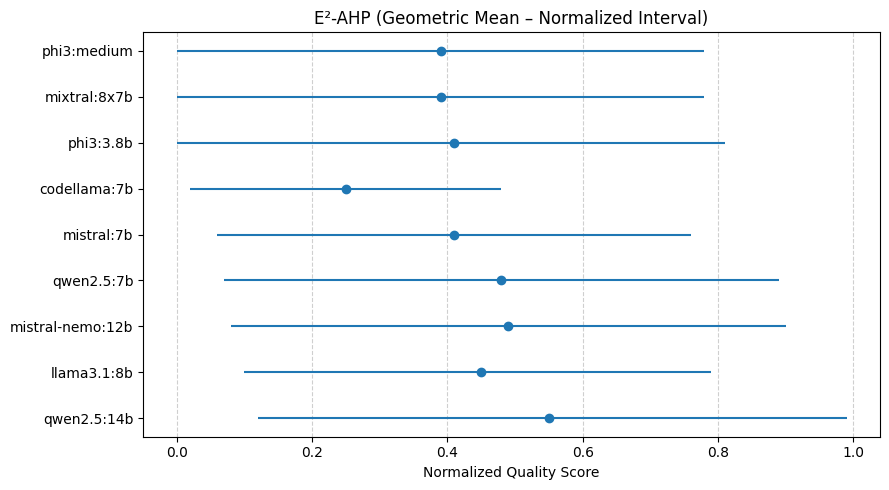

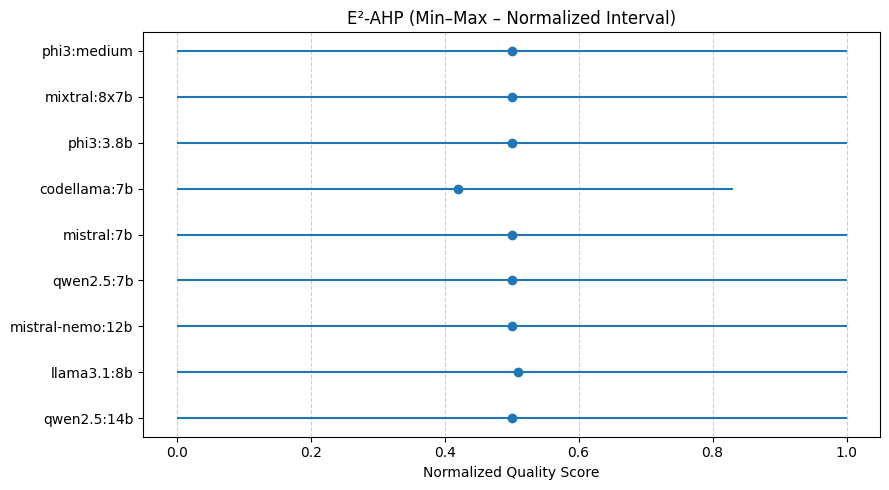

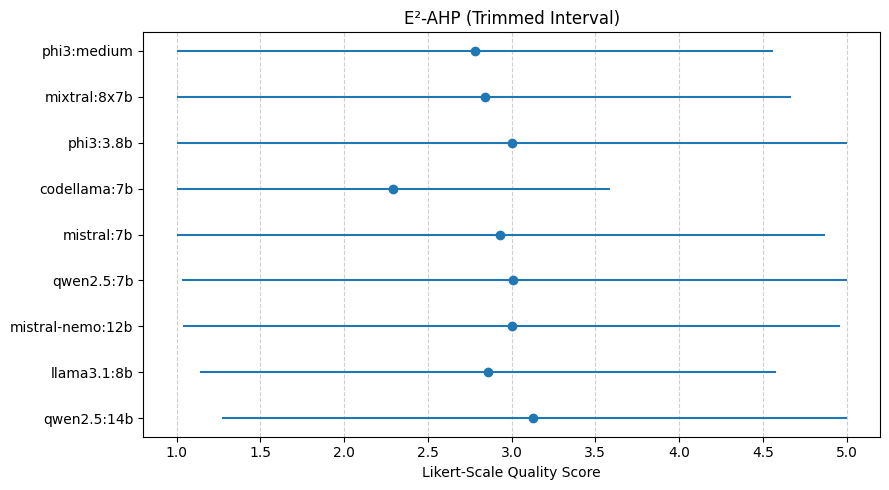

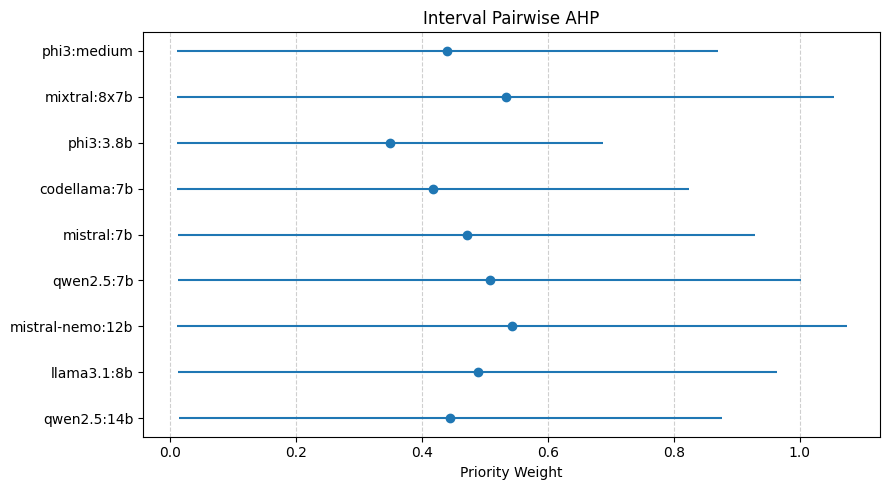

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# ============================
# DATA (manually encoded)
# ============================

data = {
    "Model": [
        "qwen2.5:14b", "llama3.1:8b", "mistral-nemo:12b", "qwen2.5:7b",
        "mistral:7b", "codellama:7b", "phi3:3.8b", "mixtral:8x7b", "phi3:medium"
    ],

    # E²-AHP (GM, Normalized Interval)
    "GM_low":  [0.12, 0.10, 0.08, 0.07, 0.06, 0.02, 0.00, 0.00, 0.00],
    "GM_mid":  [0.55, 0.45, 0.49, 0.48, 0.41, 0.25, 0.41, 0.39, 0.39],
    "GM_high": [0.99, 0.79, 0.90, 0.89, 0.76, 0.48, 0.81, 0.78, 0.78],

    # E²-AHP (Min–Max, Normalized Interval)
    "MM_low":  [0.00]*9,
    "MM_mid":  [0.50, 0.51, 0.50, 0.50, 0.50, 0.42, 0.50, 0.50, 0.50],
    "MM_high": [1.00, 1.00, 1.00, 1.00, 1.00, 0.83, 1.00, 1.00, 1.00],

    # E²-AHP (Trimmed Interval)
    "TR_low":  [1.27, 1.14, 1.04, 1.03, 1.00, 1.00, 1.00, 1.00, 1.00],
    "TR_mid":  [3.13, 2.86, 3.00, 3.01, 2.93, 2.29, 3.00, 2.84, 2.78],
    "TR_high": [5.00, 4.58, 4.96, 5.00, 4.87, 3.59, 5.00, 4.67, 4.56],

    # Interval Pairwise AHP
    "IP_low":  [0.014, 0.013, 0.012, 0.013, 0.013, 0.011, 0.012, 0.012, 0.011],
    "IP_mid":  [0.445, 0.489, 0.543, 0.508, 0.471, 0.418, 0.349, 0.533, 0.440],
    "IP_high": [0.876, 0.964, 1.074, 1.002, 0.929, 0.824, 0.687, 1.054, 0.870],
}

df = pd.DataFrame(data)

# ============================
# PLOTTING FUNCTION
# ============================

def plot_intervals(df, low, mid, high, title, xlabel):
    y = range(len(df))

    plt.figure(figsize=(9, 5))
    plt.hlines(y, df[low], df[high])
    plt.plot(df[mid], y, 'o')

    plt.yticks(y, df["Model"])
    plt.xlabel(xlabel)
    plt.title(title)
    plt.grid(axis="x", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

# ============================
# GENERATE PLOTS
# ============================

plot_intervals(
    df,
    "GM_low", "GM_mid", "GM_high",
    "E²-AHP (Geometric Mean – Normalized Interval)",
    "Normalized Quality Score"
)

plot_intervals(
    df,
    "MM_low", "MM_mid", "MM_high",
    "E²-AHP (Min–Max – Normalized Interval)",
    "Normalized Quality Score"
)

plot_intervals(
    df,
    "TR_low", "TR_mid", "TR_high",
    "E²-AHP (Trimmed Interval)",
    "Likert-Scale Quality Score"
)

plot_intervals(
    df,
    "IP_low", "IP_mid", "IP_high",
    "Interval Pairwise AHP",
    "Priority Weight"
)


In [ ]:
import pandas as pd
import numpy as np
from itertools import combinations
from multiprocessing import Pool, cpu_count

# ================================================================
# LOAD DATA
# ================================================================
df = pd.read_csv("LikertScale.csv")

model_name_map = {
    'n': 'llama3.1:8b',
    'q': 'qwen2.5:7b',
    'm': 'mistral:7b',
    'c': 'codellama:7b',
    'p': 'phi3:3.8b',
    'x': 'mistral-nemo:12b',
    'z': 'qwen2.5:14b',
    'y': 'phi3:medium',
    'w': 'mixtral:8x7b'
}

df["Model"] = df["Model"].map(model_name_map)
models = sorted(df["Model"].unique())

QUESTIONS = sorted(df["question_number"].unique())
N = len(QUESTIONS)
Q_INDEX = {q: i for i, q in enumerate(QUESTIONS)}

# ================================================================
# AHP STRUCTURE
# ================================================================
criteria_structure = {
    "C1": ["S1.1", "S1.2"],
    "C2": ["S2.1", "S2.2"],
    "C3": ["S3.1", "S3.2"],
    "C4": ["S4.1", "S4.2"]
}

criterion_weights = {
    "C1": 0.1149,
    "C2": 0.1363,
    "C3": 0.4830,
    "C4": 0.2658
}

subcriterion_weights = {
    "S1.1": 0.7458, "S1.2": 0.2542,
    "S2.1": 0.5959, "S2.2": 0.4041,
    "S3.1": 0.4856, "S3.2": 0.5144,
    "S4.1": 0.7360, "S4.2": 0.2640
}

all_subcriteria = sum(criteria_structure.values(), [])

# ================================================================
# COST OF A SUBSET (mask)
# ================================================================
def subset_cost(mask):
    qs = [QUESTIONS[i] for i in range(N) if mask & (1 << i)]
    if not qs:
        return 0.0

    total_width = 0.0

    for model in models:
        subset = df[
            (df["Model"] == model) &
            (df["question_number"].isin(qs))
        ]

        if subset.empty:
            continue

        crit_low, crit_high = {}, {}

        for crit, subs in criteria_structure.items():
            low = high = 0.0
            for s in subs:
                v = subset[s].dropna()
                if v.empty:
                    continue
                low += subcriterion_weights[s] * v.min()
                high += subcriterion_weights[s] * v.max()
            crit_low[crit] = low
            crit_high[crit] = high

        Q_low = sum(criterion_weights[c] * crit_low[c] for c in crit_low)
        Q_high = sum(criterion_weights[c] * crit_high[c] for c in crit_high)

        total_width += (Q_high - Q_low)

    return total_width

# ================================================================
# PARALLEL PRECOMPUTATION OF ALL SUBSET COSTS
# ================================================================
all_masks = list(range(1, 1 << N))

with Pool(cpu_count()) as pool:
    costs = pool.map(subset_cost, all_masks)

COST = {mask: cost for mask, cost in zip(all_masks, costs)}

# ================================================================
# SUBSET DP WITH BRANCH-AND-BOUND
# ================================================================
dp = {0: 0.0}
choice = {}

for mask in range(1, 1 << N):
    best = float("inf")
    sub = mask

    while sub:
        cost = COST[sub] + dp.get(mask ^ sub, float("inf"))
        if cost < best:
            best = cost
            choice[mask] = sub
        sub = (sub - 1) & mask

    dp[mask] = best

# ================================================================
# RECONSTRUCT OPTIMAL GROUPING
# ================================================================
full_mask = (1 << N) - 1
groups = []

while full_mask:
    s = choice[full_mask]
    group = [QUESTIONS[i] for i in range(N) if s & (1 << i)]
    groups.append(group)
    full_mask ^= s

# ================================================================
# OUTPUT
# ================================================================
print("\nOPTIMAL GROUPING")
print("TOTAL WIDTH:", dp[(1 << N) - 1])

for i, g in enumerate(groups, 1):
    print(f"G{i}: {sorted(g)}")



OPTIMAL GROUPING
TOTAL WIDTH: 34.780752379999996
G1: [np.int64(5), np.int64(35), np.int64(43), np.int64(45), np.int64(56), np.int64(70), np.int64(75), np.int64(79), np.int64(84), np.int64(89), np.int64(99), np.int64(105)]


In [ ]:
import pandas as pd
import numpy as np
from itertools import combinations
from multiprocessing import Pool, cpu_count

# ================================================================
# LOAD DATA
# ================================================================
df = pd.read_csv("LikertScale.csv")

model_name_map = {
    'n': 'llama3.1:8b',
    'q': 'qwen2.5:7b',
    'm': 'mistral:7b',
    'c': 'codellama:7b',
    'p': 'phi3:3.8b',
    'x': 'mistral-nemo:12b',
    'z': 'qwen2.5:14b',
    'y': 'phi3:medium',
    'w': 'mixtral:8x7b'
}

df["Model"] = df["Model"].map(model_name_map)
models = sorted(df["Model"].unique())

QUESTIONS = sorted(df["question_number"].unique())
N = len(QUESTIONS)
Q_INDEX = {q: i for i, q in enumerate(QUESTIONS)}

# ================================================================
# AHP STRUCTURE
# ================================================================
criteria_structure = {
    "C1": ["S1.1", "S1.2"],
    "C2": ["S2.1", "S2.2"],
    "C3": ["S3.1", "S3.2"],
    "C4": ["S4.1", "S4.2"]
}

criterion_weights = {
    "C1": 0.1149,
    "C2": 0.1363,
    "C3": 0.4830,
    "C4": 0.2658
}

subcriterion_weights = {
    "S1.1": 0.7458, "S1.2": 0.2542,
    "S2.1": 0.5959, "S2.2": 0.4041,
    "S3.1": 0.4856, "S3.2": 0.5144,
    "S4.1": 0.7360, "S4.2": 0.2640
}

all_subcriteria = sum(criteria_structure.values(), [])

# ================================================================
# COST OF A SUBSET (mask)
# ================================================================
def subset_cost(mask):
    # 🔴 Enforce minimum group size = 2
    if mask.bit_count() < 2:
        return float("inf")

    qs = [QUESTIONS[i] for i in range(N) if mask & (1 << i)]

    total_width = 0.0

    for model in models:
        subset = df[
            (df["Model"] == model) &
            (df["question_number"].isin(qs))
        ]

        if subset.empty:
            continue

        crit_low, crit_high = {}, {}

        for crit, subs in criteria_structure.items():
            low = high = 0.0
            for s in subs:
                v = subset[s].dropna()
                if v.empty:
                    continue
                low += subcriterion_weights[s] * v.min()
                high += subcriterion_weights[s] * v.max()
            crit_low[crit] = low
            crit_high[crit] = high

        Q_low = sum(criterion_weights[c] * crit_low[c] for c in crit_low)
        Q_high = sum(criterion_weights[c] * crit_high[c] for c in crit_high)

        total_width += (Q_high - Q_low)

    return total_width

# ================================================================
# PARALLEL PRECOMPUTATION OF SUBSET COSTS
# ================================================================
# 🔴 Only subsets of size >= 2
all_masks = [m for m in range(1, 1 << N) if m.bit_count() >= 2]

with Pool(cpu_count()) as pool:
    costs = pool.map(subset_cost, all_masks)

COST = {mask: cost for mask, cost in zip(all_masks, costs)}

# ================================================================
# SUBSET DP (EXACT)
# ================================================================
dp = {0: 0.0}
choice = {}

for mask in range(1, 1 << N):

    # If mask itself is size 1, it can never be solved
    if mask.bit_count() == 1:
        continue

    best = float("inf")
    sub = mask

    while sub:
        if sub in COST:
            remainder = mask ^ sub

            # 🔴 CRITICAL FIX:
            # remainder must be either empty or large enough
            if remainder == 0 or remainder.bit_count() >= 2:
                if remainder in dp:
                    cost = COST[sub] + dp[remainder]
                    if cost < best:
                        best = cost
                        choice[mask] = sub

        sub = (sub - 1) & mask

    if best < float("inf"):
        dp[mask] = best


# ================================================================
# RECONSTRUCT OPTIMAL GROUPING
# ================================================================
full_mask = (1 << N) - 1
groups = []

if full_mask not in choice:
    raise RuntimeError("No valid grouping satisfies the min-size constraint.")

while full_mask:
    s = choice[full_mask]
    group = [QUESTIONS[i] for i in range(N) if s & (1 << i)]
    groups.append(group)
    full_mask ^= s

# ================================================================
# OUTPUT
# ================================================================
print("\nOPTIMAL GROUPING (min 2 questions per group)")
print("TOTAL WIDTH:", dp[(1 << N) - 1])

for i, g in enumerate(groups, 1):
    print(f"G{i}: {sorted(g)}")



OPTIMAL GROUPING (min 2 questions per group)
TOTAL WIDTH: 34.780752379999996
G1: [np.int64(5), np.int64(35), np.int64(43), np.int64(45), np.int64(56), np.int64(70), np.int64(75), np.int64(79), np.int64(84), np.int64(89), np.int64(99), np.int64(105)]


In [ ]:
import pandas as pd
import numpy as np
from itertools import combinations
from multiprocessing import Pool, cpu_count

# ================================================================
# LOAD DATA
# ================================================================
df = pd.read_csv("LikertScale.csv")

model_name_map = {
    'n': 'llama3.1:8b',
    'q': 'qwen2.5:7b',
    'm': 'mistral:7b',
    'c': 'codellama:7b',
    'p': 'phi3:3.8b',
    'x': 'mistral-nemo:12b',
    'z': 'qwen2.5:14b',
    'y': 'phi3:medium',
    'w': 'mixtral:8x7b'
}

df["Model"] = df["Model"].map(model_name_map)
models = sorted(df["Model"].unique())

QUESTIONS = sorted(df["question_number"].unique())
N = len(QUESTIONS)
Q_INDEX = {q: i for i, q in enumerate(QUESTIONS)}

# ================================================================
# AHP STRUCTURE
# ================================================================
criteria_structure = {
    "C1": ["S1.1", "S1.2"],
    "C2": ["S2.1", "S2.2"],
    "C3": ["S3.1", "S3.2"],
    "C4": ["S4.1", "S4.2"]
}

criterion_weights = {
    "C1": 0.1149,
    "C2": 0.1363,
    "C3": 0.4830,
    "C4": 0.2658
}

subcriterion_weights = {
    "S1.1": 0.7458, "S1.2": 0.2542,
    "S2.1": 0.5959, "S2.2": 0.4041,
    "S3.1": 0.4856, "S3.2": 0.5144,
    "S4.1": 0.7360, "S4.2": 0.2640
}

all_subcriteria = sum(criteria_structure.values(), [])

# ================================================================
# COST OF A SUBSET (mask)
# ================================================================
def subset_cost(mask):
    size = mask.bit_count()
    # 🔴 Enforce group size 2–4
    if size < 2 or size > 4:
        return float("inf")

    qs = [QUESTIONS[i] for i in range(N) if mask & (1 << i)]

    total_width = 0.0

    for model in models:
        subset = df[
            (df["Model"] == model) &
            (df["question_number"].isin(qs))
        ]

        if subset.empty:
            continue

        crit_low, crit_high = {}, {}

        for crit, subs in criteria_structure.items():
            low = high = 0.0
            for s in subs:
                v = subset[s].dropna()
                if v.empty:
                    continue
                low += subcriterion_weights[s] * v.min()
                high += subcriterion_weights[s] * v.max()
            crit_low[crit] = low
            crit_high[crit] = high

        Q_low = sum(criterion_weights[c] * crit_low[c] for c in crit_low)
        Q_high = sum(criterion_weights[c] * crit_high[c] for c in crit_high)

        total_width += (Q_high - Q_low)

    return total_width

# ================================================================
# PARALLEL PRECOMPUTATION OF SUBSET COSTS
# ================================================================
all_masks = [m for m in range(1, 1 << N) if 2 <= m.bit_count() <= 4]

with Pool(cpu_count()) as pool:
    costs = pool.map(subset_cost, all_masks)

COST = {mask: cost for mask, cost in zip(all_masks, costs)}

# ================================================================
# SUBSET DP (EXACT, BRANCH-AND-BOUND)
# ================================================================
dp = {0: 0.0}
choice = {}

for mask in range(1, 1 << N):
    if mask.bit_count() < 2:
        continue

    best = float("inf")
    sub = mask

    while sub:
        # sub must be valid (size 2–4)
        if sub in COST:
            remainder = mask ^ sub

            # remainder must be feasible (0 or >=2)
            if remainder == 0 or remainder.bit_count() >= 2:
                if remainder in dp:
                    cost = COST[sub] + dp[remainder]
                    if cost < best:
                        best = cost
                        choice[mask] = sub

        sub = (sub - 1) & mask

    if best < float("inf"):
        dp[mask] = best

# ================================================================
# RECONSTRUCT OPTIMAL GROUPING
# ================================================================
full_mask = (1 << N) - 1
groups = []

if full_mask not in dp:
    raise RuntimeError("No valid grouping satisfies the min-size constraint.")

while full_mask:
    s = choice[full_mask]
    group = [QUESTIONS[i] for i in range(N) if s & (1 << i)]
    groups.append(group)
    full_mask ^= s

# ================================================================
# SAFETY CHECK
# ================================================================
for g in groups:
    assert 2 <= len(g) <= 4, f"Invalid group size: {g}"

# ================================================================
# OUTPUT
# ================================================================
print("\nOPTIMAL GROUPING (2–4 questions per group)")
print("TOTAL WIDTH:", dp[(1 << N) - 1])

for i, g in enumerate(groups, 1):
    print(f"G{i}: {sorted(g)}")



OPTIMAL GROUPING (2–4 questions per group)
TOTAL WIDTH: 86.01179923
G1: [np.int64(5), np.int64(35), np.int64(84), np.int64(105)]
G2: [np.int64(70), np.int64(75), np.int64(89), np.int64(99)]
G3: [np.int64(43), np.int64(45), np.int64(56), np.int64(79)]


FOR ALL JUDGES

In [ ]:
import numpy as np
from scipy.stats.mstats import gmean

RI = [0, 0, 0.58, 0.90, 1.12, 1.24, 1.32, 1.41, 1.45, 1.49]

RAW_DATA = {
    'J2':  '222111121133331113331513151315',
    'J1':  '112222122261745733211325132211',
    'J9':  '121222212237899698451529222419',
    'J7':  '212111122143412125321123151125',
    'J8':  '111222212223134461441211112512',
    'J10': '212211122153337553331523231523',
    'J4':  '122212122245265462412314232315',
    'J6':  '112111222113334147541714171117',
    'J3':  '212211222233577346851324232113',
    'J5':  '112222222187398999831913152915',
    'J33': '112212222178786887681727282817',
    'J55': '211221212245684685881724162717',
    'J11': '112222222233395593991327272719',
    'J22': '121222212296398598171525142716',
    'JJA': '121212212211191192111921212919',
    'JJB': '112112121188987958691818182718',
    'JJC': '112222222277895894991727151719',
    'J88': '121222221145365456111717262415',
    'JJD': '112122222131554651381113211115',
    'JJ1': '111122211177777555551717271717',
}

# Original 10 pairs (5x5 upper triangle):
# pos: 0=(C1,C2) 1=(C1,C3) 2=(C1,C4) 3=(C1,C5)
#      4=(C2,C3) 5=(C2,C4) 6=(C2,C5)
#      7=(C3,C4) 8=(C3,C5) 9=(C4,C5)
# C2 excluded → keep positions 1,2,3,7,8,9
# New 4x4 index: C1→0, C3→1, C4→2, C5→3
FULL_PAIRS  = [(0,1),(0,2),(0,3),(0,4),(1,2),(1,3),(1,4),(2,3),(2,4),(3,4)]
KEPT_POS    = [1, 2, 3, 7, 8, 9]
ORIG_TO_NEW = {0: 0, 2: 1, 3: 2, 4: 3}
CRITERIA    = ['C1', 'C3', 'C4', 'C5']
SUB_IDX     = [0, 2, 3, 4]   # skip C2 (index 1) in sub-criteria

def decode_value(imp, deg):
    deg = max(1, min(9, deg))
    return float(deg) if imp == 1 else 1.0 / float(deg)

def parse_judge(raw):
    v     = [int(c) for c in raw]
    imp_c = v[0:10]
    deg_c = v[10:20]
    sub_v = v[20:30]

    M = np.ones((4, 4))
    for pos in KEPT_POS:
        i_orig, j_orig = FULL_PAIRS[pos]
        i_new = ORIG_TO_NEW[i_orig]
        j_new = ORIG_TO_NEW[j_orig]
        val = decode_value(imp_c[pos], deg_c[pos])
        M[i_new][j_new] = val
        M[j_new][i_new] = 1.0 / val

    subs = []
    for s in SUB_IDX:
        imp = sub_v[s * 2]
        deg = sub_v[s * 2 + 1]
        val = decode_value(imp, deg)
        subs.append(np.array([[1.0, val], [1.0 / val, 1.0]]))

    return M, subs

def priority_vector(matrix):
    gm = gmean(matrix, axis=1)
    return gm / gm.sum()

def lambda_max(matrix, w):
    return (matrix @ w / w).mean()

def consistency(matrix):
    n    = len(matrix)
    w    = priority_vector(matrix)
    lmax = lambda_max(matrix, w)
    CI   = (lmax - n) / (n - 1)
    CR   = CI / RI[n] if RI[n] > 0 else 0.0
    return {'weights': w, 'lambda_max': lmax, 'CI': CI, 'CR': CR}

results = {}
for judge_id, raw in RAW_DATA.items():
    M_crit, M_subs = parse_judge(raw)
    results[judge_id] = {
        'criteria_matrix': M_crit,
        'criteria':        consistency(M_crit),
        'subcriteria':     [consistency(ms) for ms in M_subs],
    }

# REPORT 1 – Consistency
print("=" * 80)
print("JUDGE CONSISTENCY ANALYSIS  (CR threshold: 0.10)  |  Criteria: C1, C3, C4, C5")
print("=" * 80)
print(f"{'Judge':<8} {'lambda_max':>12} {'CI':>10} {'CR':>10}  Status")
print("-" * 80)
consistent_judges = []
for jid, r in results.items():
    c  = r['criteria']
    ok = c['CR'] < 0.10
    if ok:
        consistent_judges.append(jid)
    tag = "Consistent" if ok else "Inconsistent"
    print(f"{jid:<8} {c['lambda_max']:>12.4f} {c['CI']:>10.4f} {c['CR']:>10.4f}  {tag}")
print()
print(f"Consistent judges ({len(consistent_judges)}/{len(RAW_DATA)}): {', '.join(consistent_judges)}")

# REPORT 2 – Criteria weights per judge
print()
print("=" * 80)
print("CRITERIA PRIORITY WEIGHTS PER JUDGE  (C1, C3, C4, C5)")
print("=" * 80)
header = f"{'Judge':<8}" + "".join(f"  {c:>8}" for c in CRITERIA) + f"  {'CR':>8}"
print(header)
print("-" * 80)
for jid, r in results.items():
    w  = r['criteria']['weights']
    cr = r['criteria']['CR']
    row = f"{jid:<8}" + "".join(f"  {w[i]:>8.4f}" for i in range(4)) + f"  {cr:>8.4f}"
    print(row)

# REPORT 3 – Sub-criteria weights per judge
print()
print("=" * 80)
print("SUB-CRITERIA WEIGHTS PER JUDGE  (Cx.A vs Cx.B)  |  C2 excluded")
print("=" * 80)
sub_header = f"{'Judge':<8}" + "".join(f"  {c+'.A':>7}  {c+'.B':>7}" for c in CRITERIA)
print(sub_header)
print("-" * 80)
for jid, r in results.items():
    row = f"{jid:<8}"
    for s in r['subcriteria']:
        w = s['weights']
        row += f"  {w[0]:>7.4f}  {w[1]:>7.4f}"
    print(row)

# REPORT 4 – Aggregated criteria weights (consistent judges, geometric mean)
print()
print("=" * 80)
print(f"AGGREGATED CRITERIA WEIGHTS  (consistent judges: {', '.join(consistent_judges)})")
print("=" * 80)
if consistent_judges:
    stacked = np.array([results[j]['criteria']['weights'] for j in consistent_judges])
    agg_w   = gmean(stacked, axis=0)
    agg_w  /= agg_w.sum()
    print(f"{'Criterion':<12} {'Weight':>10}  {'%':>8}")
    print("-" * 35)
    for i, w in enumerate(agg_w):
        print(f"{CRITERIA[i]:<12} {w:>10.4f}  {w*100:>7.2f}%")
else:
    print("No consistent judges found.")

# REPORT 5 – Aggregated sub-criteria weights (all judges, geometric mean)
print()
print("=" * 80)
print("AGGREGATED SUB-CRITERIA WEIGHTS  (all judges, geometric mean)  |  C2 excluded")
print("=" * 80)
for idx, cname in enumerate(CRITERIA):
    stacked = np.array([results[j]['subcriteria'][idx]['weights'] for j in RAW_DATA])
    agg     = gmean(stacked, axis=0)
    agg    /= agg.sum()
    print(f"{cname}:  {cname}.A = {agg[0]:.4f} ({agg[0]*100:.1f}%)   "
          f"{cname}.B = {agg[1]:.4f} ({agg[1]*100:.1f}%)")

print()
print("=" * 80)
print("ANALYSIS COMPLETE")
print("=" * 80)

JUDGE CONSISTENCY ANALYSIS  (CR threshold: 0.10)  |  Criteria: C1, C3, C4, C5
Judge      lambda_max         CI         CR  Status
--------------------------------------------------------------------------------
J2             4.3094     0.1031     0.0921  Consistent
J1             4.1057     0.0352     0.0315  Consistent
J9             5.0658     0.3553     0.3172  Inconsistent
J7             4.0807     0.0269     0.0240  Consistent
J8             4.1233     0.0411     0.0367  Consistent
J10            4.3094     0.1031     0.0921  Consistent
J4             4.3695     0.1232     0.1100  Inconsistent
J6             4.2834     0.0945     0.0843  Consistent
J3             4.3301     0.1100     0.0982  Consistent
J5             4.7165     0.2388     0.2132  Inconsistent
J33            5.2752     0.4251     0.3795  Inconsistent
J55            4.6881     0.2294     0.2048  Inconsistent
J11            4.3094     0.1031     0.0921  Consistent
J22            4.1694     0.0565     0.0504  Consis

In [ ]:
import numpy as np
from scipy.stats.mstats import gmean
import pandas as pd

# Random Index values (index = matrix size)
RI = [0, 0, 0, 0.58, 0.90, 1.12, 1.24, 1.32, 1.41, 1.45, 1.49]

def parse_value(important_col, degree_col):
    """Convert survey response (IMPORTANT direction + DEGREE) to AHP ratio value."""
    imp = int(important_col)  # 1 = C_i more important, 2 = C_j more important
    deg = int(degree_col)
    return 1/deg if imp == 2 else deg

def build_matrix(row):
    """Build 5x5 pairwise matrix from survey row."""
    pairs_order = [
        (0,1,'C1_C2'), (0,2,'C1_C3'), (0,3,'C1_C4'), (0,4,'C1_C5'),
        (1,2,'C2_C3'), (1,3,'C2_C4'), (1,4,'C2_C5'),
        (2,3,'C3_C4'), (2,4,'C3_C5'),
        (3,4,'C4_C5')
    ]
    M = np.ones((5, 5))
    for (i, j, key) in pairs_order:
        imp_col = f"{key}_IMPORTANT"
        deg_col = f"{key}_DEGREE"
        val = parse_value(row[imp_col], row[deg_col])
        M[i][j] = val
        M[j][i] = 1 / val
    return M

def calc_cr(M):
    """Calculate CR using eigenvector method."""
    n = len(M)
    # Priority vector via geometric mean
    geo_means = gmean(M, axis=1)
    w = geo_means / geo_means.sum()
    # Lambda max
    Aw = M @ w
    lambda_max = np.mean(Aw / w)
    CI = (lambda_max - n) / (n - 1)
    CR = CI / RI[n]
    return lambda_max, CI, CR, w

# Load data
df = pd.read_csv('SURVEY_1_OUTPUT.csv', skiprows=[1])
df = df[df['Judge identifier'].notna()].reset_index(drop=True)

criteria = ['C1', 'C2', 'C3', 'C4', 'C5']

print("=" * 70)
print("CRITERIA CONSISTENCY ANALYSIS (5x5: C1–C5)")
print("CR Threshold: 0.10")
print("=" * 70)
print(f"{'Judge':<8} {'λmax':>8} {'CI':>10} {'CR':>10}  {'Status'}")
print("-" * 70)

results = []
for _, row in df.iterrows():
    judge = row['Judge identifier']
    M = build_matrix(row)
    lmax, CI, CR, w = calc_cr(M)
    consistent = CR < 0.10
    status = "✓ Consistent" if consistent else "✗ Inconsistent"
    print(f"{judge:<8} {lmax:>8.4f} {CI:>10.4f} {CR:>10.4f}  {status}")
    results.append({'judge': judge, 'lambda_max': lmax, 'CI': CI, 'CR': CR,
                    'consistent': consistent, 'weights': w})

consistent_results = [r for r in results if r['consistent']]
print("-" * 70)
print(f"\nConsistent judges: {len(consistent_results)} / {len(results)}")
print(f"Judges: {', '.join(r['judge'] for r in consistent_results)}")

# Aggregate priorities from consistent judges
if consistent_results:
    weight_matrix = np.array([r['weights'] for r in consistent_results])
    agg_weights = gmean(weight_matrix, axis=0)
    agg_weights /= agg_weights.sum()

    print("\n" + "=" * 70)
    print("AGGREGATED CRITERIA PRIORITIES (consistent judges, geometric mean)")
    print("=" * 70)
    print(f"{'Criterion':<12} {'Weight':>10} {'Percentage':>12}")
    print("-" * 36)
    for c, w in zip(criteria, agg_weights):
        print(f"{c:<12} {w:>10.4f} {w*100:>11.2f}%")

CRITERIA CONSISTENCY ANALYSIS (5x5: C1–C5)
CR Threshold: 0.10
Judge        λmax         CI         CR  Status
----------------------------------------------------------------------
J1         7.2671     0.5668     0.5060  ✗ Inconsistent
J9         6.3969     0.3492     0.3118  ✗ Inconsistent
J7         5.2892     0.0723     0.0645  ✓ Consistent
J8         5.3109     0.0777     0.0694  ✓ Consistent
J10        5.4192     0.1048     0.0936  ✓ Consistent
J4         8.5540     0.8885     0.7933  ✗ Inconsistent
J6         5.9268     0.2317     0.2069  ✗ Inconsistent
J3         5.4683     0.1171     0.1045  ✗ Inconsistent
J5         6.2848     0.3212     0.2868  ✗ Inconsistent
J33        6.8125     0.4531     0.4046  ✗ Inconsistent
J55        6.9091     0.4773     0.4261  ✗ Inconsistent
J11        5.6464     0.1616     0.1443  ✗ Inconsistent
J22        5.6597     0.1649     0.1472  ✗ Inconsistent
JJA        5.8786     0.2197     0.1961  ✗ Inconsistent
JJB        6.6557     0.4139     0.3696  

In [ ]:
import numpy as np
from scipy.stats.mstats import gmean

# Random Index values (index = matrix size n)
RI = [0, 0, 0, 0.58, 0.90, 1.12, 1.24, 1.32, 1.41, 1.45, 1.49]

# ─────────────────────────────────────────────
# CRITERIA MATRICES (5x5, C1–C5, all 10 judges)
# ─────────────────────────────────────────────
criteria_matrices = {
    'J1':  np.array([[1, 6, 1, 0.142857, 0.25],    [0.166667, 1, 0.2, 0.142857, 3],
                     [1, 5, 1, 0.333333, 0.5],      [7, 7, 3, 1, 1],      [4, 0.333333, 2, 1, 1]]),
    'J2':  np.array([[1, 0.333333, 0.333333, 0.333333, 3], [3, 1, 1, 1, 1],
                     [3, 1, 1, 0.333333, 3],         [3, 1, 3, 1, 3],      [0.333333, 1, 0.333333, 0.333333, 1]]),
    'J3':  np.array([[1, 0.333333, 0.333333, 0.142857, 0.2], [3, 1, 0.142857, 0.333333, 0.125],
                     [3, 7, 1, 0.333333, 0.125],     [7, 3, 3, 1, 0.625], [5, 8, 8, 1.6, 1]]),
    'J4':  np.array([[1, 0.25, 0.5, 0.166667, 4],   [4, 1, 0.2, 0.2, 0.166667],
                     [2, 5, 1, 0.5, 0.25],           [6, 5, 2, 1, 6],      [0.25, 6, 4, 0.166667, 1]]),
    'J5':  np.array([[1, 8, 7, 0.333333, 0.111111], [0.125, 1, 0.125, 0.111111, 0.111111],
                     [0.142857, 8, 1, 0.111111, 0.125], [3, 9, 9, 1, 3],  [9, 9, 8, 0.333333, 1]]),
    'J6':  np.array([[1, 1, 0.333333, 0.333333, 0.25], [1, 1, 0.333333, 0.25, 1],
                     [3, 3, 1, 0.25, 0.142857],      [3, 4, 4, 1, 0.2],   [4, 1, 7, 5, 1]]),
    'J7':  np.array([[1, 0.25, 0.333333, 4, 1],      [4, 1, 3, 1, 1],
                     [3, 0.333333, 1, 0.2, 0.333333],[0.25, 1, 5, 1, 0.5],[1, 1, 3, 2, 1]]),
    'J8':  np.array([[1, 2, 3, 0.333333, 0.5],       [0.5, 1, 0.25, 0.25, 0.166667],
                     [0.333333, 4, 1, 0.166667, 0.25],[3, 4, 6, 1, 4],    [2, 6, 4, 0.25, 1]]),
    'J9':  np.array([[1, 3, 0.142857, 0.111111, 0.2],[0.333333, 1, 0.111111, 0.166667, 0.111111],
                     [7, 9, 1, 0.125, 0.25],         [9, 6, 8, 1, 0.2],   [5, 9, 4, 5, 1]]),
    'J10': np.array([[1, 0.2, 0.333333, 0.333333, 5],[5, 1, 0.333333, 0.2, 0.2],
                     [3, 3, 1, 0.333333, 0.333333],  [3, 5, 3, 1, 1],     [0.2, 5, 3, 1, 1]])
}

# ─────────────────────────────────────────────
# SUB-CRITERIA MATRICES (2x2, per judge per criterion)
# ─────────────────────────────────────────────
sub_criteria_matrices = {
    'J1/C1': np.array([[1, 3],    [0.333, 1]]),   'J1/C2': np.array([[1, 0.2],  [5, 1]]),
    'J1/C3': np.array([[1, 3],    [0.333, 1]]),   'J1/C4': np.array([[1, 0.5],  [2, 1]]),
    'J1/C5': np.array([[1, 1],    [1, 1]]),
    'J2/C1': np.array([[1, 5],    [0.2, 1]]),     'J2/C2': np.array([[1, 3],    [0.333, 1]]),
    'J2/C3': np.array([[1, 5],    [0.2, 1]]),     'J2/C4': np.array([[1, 3],    [0.333, 1]]),
    'J2/C5': np.array([[1, 5],    [0.2, 1]]),
    'J3/C1': np.array([[1, 3],    [0.333, 1]]),   'J3/C2': np.array([[1, 0.25], [4, 1]]),
    'J3/C3': np.array([[1, 0.333],[3, 1]]),       'J3/C4': np.array([[1, 0.5],  [2, 1]]),
    'J3/C5': np.array([[1, 3],    [0.333, 1]]),
    'J4/C1': np.array([[1, 0.333],[3, 1]]),       'J4/C2': np.array([[1, 4],    [0.25, 1]]),
    'J4/C3': np.array([[1, 0.333],[3, 1]]),       'J4/C4': np.array([[1, 0.333],[3, 1]]),
    'J4/C5': np.array([[1, 5],    [0.2, 1]]),
    'J5/C1': np.array([[1, 9],    [0.111, 1]]),   'J5/C2': np.array([[1, 3],    [0.333, 1]]),
    'J5/C3': np.array([[1, 5],    [0.2, 1]]),     'J5/C4': np.array([[1, 9],    [0.111, 1]]),
    'J5/C5': np.array([[1, 5],    [0.2, 1]]),
    'J6/C1': np.array([[1, 7],    [0.142857, 1]]),'J6/C2': np.array([[1, 4],    [0.25, 1]]),
    'J6/C3': np.array([[1, 7],    [0.142857, 1]]),'J6/C4': np.array([[1, 1],    [1, 1]]),
    'J6/C5': np.array([[1, 7],    [0.142857, 1]]),
    'J7/C1': np.array([[1, 1],    [1, 1]]),       'J7/C2': np.array([[1, 0.333],[3, 1]]),
    'J7/C3': np.array([[1, 5],    [0.2, 1]]),     'J7/C4': np.array([[1, 1],    [1, 1]]),
    'J7/C5': np.array([[1, 0.2],  [5, 1]]),
    'J8/C1': np.array([[1, 2],    [0.5, 1]]),     'J8/C2': np.array([[1, 1],    [1, 1]]),
    'J8/C3': np.array([[1, 1],    [1, 1]]),       'J8/C4': np.array([[1, 0.2],  [5, 1]]),
    'J8/C5': np.array([[1, 2],    [0.5, 1]]),
    'J9/C1': np.array([[1, 5],    [0.2, 1]]),     'J9/C2': np.array([[1, 0.111],[9, 1]]),
    'J9/C3': np.array([[1, 0.5],  [2, 1]]),       'J9/C4': np.array([[1, 0.25], [4, 1]]),
    'J9/C5': np.array([[1, 9],    [0.111, 1]]),
    'J10/C1': np.array([[1, 5],   [0.2, 1]]),     'J10/C2': np.array([[1, 0.333],[3, 1]]),
    'J10/C3': np.array([[1, 0.333],[3, 1]]),      'J10/C4': np.array([[1, 5],   [0.2, 1]]),
    'J10/C5': np.array([[1, 3],   [0.333333, 1]])
}

# ─────────────────────────────────────────────
# HELPER FUNCTIONS
# ─────────────────────────────────────────────
def priority_vector(M):
    gm = gmean(M, axis=1)
    return gm / gm.sum()

def calc_cr(M):
    n = len(M)
    w = priority_vector(M)
    lmax = np.mean((M @ w) / w)
    CI = (lmax - n) / (n - 1)
    CR = CI / RI[n]
    return lmax, CI, CR, w

def print_pairwise_table(M, labels, title):
    """Print a pairwise comparison matrix with row priorities."""
    n = len(labels)
    w = priority_vector(M)
    lmax, CI, CR, _ = calc_cr(M)

    col_w = 9
    print(f"\n{title}")
    print("-" * (col_w * (n + 2) + 15))
    header = f"{'':12}" + "".join(f"{l:>{col_w}}" for l in labels) + f"{'Priority':>{col_w+2}}"
    print(header)
    print("-" * (col_w * (n + 2) + 15))
    for i, label in enumerate(labels):
        row_vals = "".join(f"{M[i,j]:>{col_w}.4f}" for j in range(n))
        print(f"{label:<12}{row_vals}  {w[i]:>{col_w}.4f}")
    print("-" * (col_w * (n + 2) + 15))
    print(f"  λmax={lmax:.4f}   CI={CI:.4f}   CR={CR:.4f}  "
          f"{'✓ Consistent' if CR < 0.1 else '✗ Inconsistent'}")

# ─────────────────────────────────────────────
# SECTION 1: CRITERIA CONSISTENCY & PRIORITIES
# ─────────────────────────────────────────────
criteria_labels = ['C1', 'C2', 'C3', 'C4', 'C5']

print("=" * 70)
print("SECTION 1 — CRITERIA CONSISTENCY ANALYSIS (5x5: C1–C5)")
print("CR Threshold: 0.10")
print("=" * 70)
print(f"{'Judge':<8} {'λmax':>8} {'CI':>10} {'CR':>10}  {'Status'}")
print("-" * 70)

judge_results = {}
consistent_judges = []

for judge, M in criteria_matrices.items():
    lmax, CI, CR, w = calc_cr(M)
    consistent = CR < 0.10
    judge_results[judge] = {'lmax': lmax, 'CI': CI, 'CR': CR, 'w': w, 'consistent': consistent}
    if consistent:
        consistent_judges.append(judge)
    status = "✓ Consistent" if consistent else "✗ Inconsistent"
    print(f"{judge:<8} {lmax:>8.4f} {CI:>10.4f} {CR:>10.4f}  {status}")

print("-" * 70)
print(f"\nConsistent judges: {len(consistent_judges)} / {len(criteria_matrices)}")
print(f"Judges: {', '.join(consistent_judges)}")

# Aggregated criteria priorities (geometric mean of consistent judges)
print("\n" + "=" * 70)
print("AGGREGATED CRITERIA PRIORITIES (consistent judges — geometric mean)")
print("=" * 70)
print(f"{'Criterion':<12} {'Weight':>10} {'Percentage':>12}")
print("-" * 36)

if consistent_judges:
    w_matrix = np.array([judge_results[j]['w'] for j in consistent_judges])
    agg_w = gmean(w_matrix, axis=0)
    agg_w /= agg_w.sum()
    for c, w in zip(criteria_labels, agg_w):
        print(f"{c:<12} {w:>10.4f} {w*100:>11.2f}%")
else:
    print("No consistent judges found.")
    agg_w = None

# ─────────────────────────────────────────────
# SECTION 2: PAIRWISE TABLES — EACH JUDGE (CRITERIA)
# ─────────────────────────────────────────────
print("\n\n" + "=" * 70)
print("SECTION 2 — PAIRWISE CRITERIA TABLES (per judge)")
print("=" * 70)

for judge, M in criteria_matrices.items():
    print_pairwise_table(M, criteria_labels, f"Judge {judge} — Criteria Pairwise Matrix")

# ─────────────────────────────────────────────
# SECTION 3: AGGREGATED PAIRWISE TABLE (consistent judges)
# ─────────────────────────────────────────────
print("\n\n" + "=" * 70)
print("SECTION 3 — AGGREGATED PAIRWISE CRITERIA TABLE (consistent judges)")
print("=" * 70)

if consistent_judges:
    stack = np.array([criteria_matrices[j] for j in consistent_judges])
    agg_matrix = gmean(stack, axis=0)
    print_pairwise_table(agg_matrix, criteria_labels, "Aggregated Criteria Matrix (Geometric Mean)")

# ─────────────────────────────────────────────
# SECTION 4: SUB-CRITERIA PRIORITIES
# ─────────────────────────────────────────────
print("\n\n" + "=" * 70)
print("SECTION 4 — SUB-CRITERIA PRIORITIES (all judges, geometric mean)")
print("=" * 70)

sub_labels = ['S.A', 'S.B']

for criterion in criteria_labels:
    keys = [k for k in sub_criteria_matrices if f'/{criterion}' in k]
    stack = np.array([priority_vector(sub_criteria_matrices[k]) for k in keys])
    agg = gmean(stack, axis=0)
    agg /= agg.sum()

    print(f"\n{criterion} Sub-criteria priorities:")
    print(f"  {'Sub-criterion':<15} {'Weight':>8} {'Percentage':>12}")
    print(f"  {'-'*37}")
    for label, w in zip(sub_labels, agg):
        print(f"  {label:<15} {w:>8.4f} {w*100:>11.2f}%")

    # Pairwise table (aggregated across all judges)
    sub_stack = np.array([sub_criteria_matrices[k] for k in keys])
    agg_sub_matrix = gmean(sub_stack, axis=0)
    print_pairwise_table(agg_sub_matrix, sub_labels,
                         f"  Aggregated Sub-criteria Matrix for {criterion}")

print("\n" + "=" * 70)
print("ANALYSIS COMPLETE")
print("=" * 70)

SECTION 1 — CRITERIA CONSISTENCY ANALYSIS (5x5: C1–C5)
CR Threshold: 0.10
Judge        λmax         CI         CR  Status
----------------------------------------------------------------------
J1         7.2671     0.5668     0.5060  ✗ Inconsistent
J2         5.5566     0.1392     0.1242  ✗ Inconsistent
J3         5.7556     0.1889     0.1687  ✗ Inconsistent
J4         7.6158     0.6539     0.5839  ✗ Inconsistent
J5         6.2848     0.3212     0.2868  ✗ Inconsistent
J6         6.2896     0.3224     0.2879  ✗ Inconsistent
J7         6.5870     0.3967     0.3542  ✗ Inconsistent
J8         5.5529     0.1382     0.1234  ✗ Inconsistent
J9         6.2751     0.3188     0.2846  ✗ Inconsistent
J10        7.8728     0.7182     0.6413  ✗ Inconsistent
----------------------------------------------------------------------

Consistent judges: 0 / 10
Judges: 

AGGREGATED CRITERIA PRIORITIES (consistent judges — geometric mean)
Criterion        Weight   Percentage
----------------------------------

/tmp/ipykernel_16226/3470887037.py:81: RuntimeWarning: divide by zero encountered in scalar divide
  CR = CI / RI[n]


In [ ]:
import numpy as np
from scipy.stats.mstats import gmean
import pandas as pd

# Random Index values (index = matrix size n)
RI = [0, 0, 0, 0.58, 0.90, 1.12, 1.24, 1.32, 1.41, 1.45, 1.49]

# ─────────────────────────────────────────────
# LOAD CSV & BUILD MATRICES FOR ALL 19 JUDGES
# Criteria order: C1, C2, C3, C4, C5 (index 0–4)
# C2 is at index 1 — removed after building 5x5
# ─────────────────────────────────────────────

def parse_val(imp, deg):
    """Direction (1=left more important, 2=right more important) + degree → AHP value."""
    imp, deg = int(imp), int(deg)
    return deg if imp == 1 else 1 / deg

def build_5x5(row):
    """Build full 5x5 criteria matrix from survey row."""
    # Pairs in order: (i, j, IMP_col, DEG_col)
    pairs = [
        (0, 1, 'C1_C2_IMPORTANT', 'C1_C2_DEGREE'),
        (0, 2, 'C1_C3_IMPORTANT', 'C1_C3_DEGREE'),
        (0, 3, 'C1_C4_IMPORTANT', 'C1_C4_DEGREE'),
        (0, 4, 'C1_C5_IMPORTANT', 'C1_C5_DEGREE'),
        (1, 2, 'C2_C3_IMPORTANT', 'C2_C3_DEGREE'),
        (1, 3, 'C2_C4_IMPORTANT', 'C2_C4_DEGREE'),
        (1, 4, 'C2_C5_IMPORTANT', 'C2_C5_DEGREE'),
        (2, 3, 'C3_C4_IMPORTANT', 'C3_C4_DEGREE'),
        (2, 4, 'C3_C5_IMPORTANT', 'C3_C5_DEGREE'),
        (3, 4, 'C4_C5_IMPORTANT', 'C4_C5_DEGREE'),
    ]
    M = np.ones((5, 5))
    for (i, j, ic, dc) in pairs:
        val = parse_val(row[ic], row[dc])
        M[i][j] = val
        M[j][i] = 1 / val
    return M

def build_sub(row, imp_col, deg_col):
    """Build 2x2 sub-criteria matrix."""
    val = parse_val(row[imp_col], row[deg_col])
    return np.array([[1, val], [1/val, 1]])

def remove_c2(M):
    """Remove row/col index 1 (C2) from a 5x5 matrix → 4x4."""
    return np.delete(np.delete(M, 1, axis=0), 1, axis=1)

# Load CSV
df = pd.read_csv('SURVEY_1_OUTPUT.csv', skiprows=[1])
df = df[df['Judge identifier'].notna()].reset_index(drop=True)

criteria_matrices   = {}
sub_criteria_matrices = {}

for _, row in df.iterrows():
    judge = row['Judge identifier']

    # 4x4 criteria matrix (C2 removed)
    M5 = build_5x5(row)
    criteria_matrices[judge] = remove_c2(M5)

    # Sub-criteria matrices (C2 excluded)
    sub_criteria_matrices[f'{judge}/C1'] = build_sub(row, 'C1.A_C1.B_IMPORTANT', 'C1.A_C1.B_DEGREE')
    sub_criteria_matrices[f'{judge}/C3'] = build_sub(row, 'C3.A_C3.B_IMPORTANT', 'C3.A_C3.B_DEGREE')
    sub_criteria_matrices[f'{judge}/C4'] = build_sub(row, 'C4.A_C4.B_IMPORTANT', 'C4.A_C4.B_DEGREE')
    sub_criteria_matrices[f'{judge}/C5'] = build_sub(row, 'C5.A_C5.B_IMPORTANT', 'C5.A_C5.B_DEGREE')

# ─────────────────────────────────────────────
# HELPER FUNCTIONS
# ─────────────────────────────────────────────
def priority_vector(M):
    gm = gmean(M, axis=1)
    return gm / gm.sum()

def calc_cr(M):
    n = len(M)
    w = priority_vector(M)
    lmax = np.mean((M @ w) / w)
    CI = (lmax - n) / (n - 1)
    CR = CI / RI[n]
    return lmax, CI, CR, w

def cr_status(CR):
    """Return status label and whether judge is usable (consistent/acceptable/mildly inconsistent)."""
    if CR < 0.10:
        return "✓ Consistent", True
    elif CR < 0.20:
        return "~ Acceptable", True
    elif CR <= 0.22:
        return "~ Mild", True
    else:
        return "✗ Inconsistent", False

def print_pairwise_table(M, labels, title):
    n = len(labels)
    w = priority_vector(M)
    lmax, CI, CR, _ = calc_cr(M)
    status, _ = cr_status(CR)
    col_w = 9
    print(f"\n{title}")
    print("-" * (col_w * (n + 2) + 15))
    header = f"{'':12}" + "".join(f"{l:>{col_w}}" for l in labels) + f"{'Priority':>{col_w+2}}"
    print(header)
    print("-" * (col_w * (n + 2) + 15))
    for i, label in enumerate(labels):
        row_vals = "".join(f"{M[i,j]:>{col_w}.4f}" for j in range(n))
        print(f"{label:<12}{row_vals}  {w[i]:>{col_w}.4f}")
    print("-" * (col_w * (n + 2) + 15))
    print(f"  λmax={lmax:.4f}   CI={CI:.4f}   CR={CR:.4f}  {status}")

# ─────────────────────────────────────────────
# SECTION 1: CRITERIA CONSISTENCY & PRIORITIES
# ─────────────────────────────────────────────
criteria_labels = ['C1', 'C3', 'C4', 'C5']

print("=" * 70)
print("SECTION 1 — CRITERIA CONSISTENCY ANALYSIS (4x4: C1, C3, C4, C5)")
print(f"C2 removed | Total judges: {len(criteria_matrices)}")
print("  CR < 0.10  → Consistent")
print("  CR < 0.20  → Acceptable")
print("  CR ≤ 0.22  → Mildly Inconsistent")
print("  CR > 0.22  → Inconsistent")
print("=" * 70)
print(f"{'Judge':<8} {'λmax':>8} {'CI':>10} {'CR':>10}  {'Status'}")
print("-" * 70)

judge_results   = {}
consistent_judges = []

for judge, M in criteria_matrices.items():
    lmax, CI, CR, w = calc_cr(M)
    status, usable = cr_status(CR)
    judge_results[judge] = {'lmax': lmax, 'CI': CI, 'CR': CR, 'w': w, 'usable': usable}
    if usable:
        consistent_judges.append(judge)
    print(f"{judge:<8} {lmax:>8.4f} {CI:>10.4f} {CR:>10.4f}  {status}")

print("-" * 70)
print(f"\nUsable judges (CR ≤ 0.22): {len(consistent_judges)} / {len(criteria_matrices)}")
print(f"Judges: {', '.join(consistent_judges) if consistent_judges else 'None'}")

# Aggregated criteria priorities
print("\n" + "=" * 70)
print("AGGREGATED CRITERIA PRIORITIES (usable judges — geometric mean)")
print("=" * 70)
print(f"{'Criterion':<12} {'Weight':>10} {'Percentage':>12}")
print("-" * 36)

if consistent_judges:
    w_matrix = np.array([judge_results[j]['w'] for j in consistent_judges])
    agg_w = gmean(w_matrix, axis=0)
    agg_w /= agg_w.sum()
    for c, w in zip(criteria_labels, agg_w):
        print(f"{c:<12} {w:>10.4f} {w*100:>11.2f}%")
else:
    print("No usable judges found.")
    agg_w = None

# ─────────────────────────────────────────────
# SECTION 2: PAIRWISE TABLES — EACH JUDGE
# ─────────────────────────────────────────────
print("\n\n" + "=" * 70)
print("SECTION 2 — PAIRWISE CRITERIA TABLES (per judge)")
print("=" * 70)

for judge, M in criteria_matrices.items():
    print_pairwise_table(M, criteria_labels, f"Judge {judge} — Criteria Pairwise Matrix")

# ─────────────────────────────────────────────
# SECTION 3: AGGREGATED PAIRWISE TABLE
# ─────────────────────────────────────────────
print("\n\n" + "=" * 70)
print("SECTION 3 — AGGREGATED PAIRWISE CRITERIA TABLE (consistent judges)")
print("=" * 70)

if consistent_judges:
    stack = np.array([criteria_matrices[j] for j in consistent_judges])
    agg_matrix = gmean(stack, axis=0)
    print_pairwise_table(agg_matrix, criteria_labels, "Aggregated Criteria Matrix (Geometric Mean)")
else:
    print("No usable judges — aggregated table skipped.")

# ─────────────────────────────────────────────
# SECTION 4: SUB-CRITERIA PRIORITIES
# ─────────────────────────────────────────────
print("\n\n" + "=" * 70)
print("SECTION 4 — SUB-CRITERIA PRIORITIES (all judges, geometric mean)")
print("C2 excluded")
print("=" * 70)

sub_labels = ['S.A', 'S.B']

for criterion in criteria_labels:
    keys = [k for k in sub_criteria_matrices if f'/{criterion}' in k]
    stack = np.array([priority_vector(sub_criteria_matrices[k]) for k in keys])
    agg = gmean(stack, axis=0)
    agg /= agg.sum()

    print(f"\n{criterion} Sub-criteria priorities:")
    print(f"  {'Sub-criterion':<15} {'Weight':>8} {'Percentage':>12}")
    print(f"  {'-'*37}")
    for label, w in zip(sub_labels, agg):
        print(f"  {label:<15} {w:>8.4f} {w*100:>11.2f}%")

    sub_stack = np.array([sub_criteria_matrices[k] for k in keys])
    agg_sub_matrix = gmean(sub_stack, axis=0)
    print_pairwise_table(agg_sub_matrix, sub_labels,
                         f"  Aggregated Sub-criteria Matrix for {criterion}")

print("\n" + "=" * 70)
print("ANALYSIS COMPLETE")
print("=" * 70)

SECTION 1 — CRITERIA CONSISTENCY ANALYSIS (4x4: C1, C3, C4, C5)
C2 removed | Total judges: 19
  CR < 0.10  → Consistent
  CR < 0.20  → Acceptable
  CR ≤ 0.22  → Mildly Inconsistent
  CR > 0.22  → Inconsistent
Judge        λmax         CI         CR  Status
----------------------------------------------------------------------
J1         4.1057     0.0352     0.0392  ✓ Consistent
J9         5.0658     0.3553     0.3948  ✗ Inconsistent
J7         4.0807     0.0269     0.0299  ✓ Consistent
J8         4.1233     0.0411     0.0457  ✓ Consistent
J10        4.3094     0.1031     0.1146  ~ Acceptable
J4         4.3695     0.1232     0.1369  ~ Acceptable
J6         4.2834     0.0945     0.1050  ~ Acceptable
J3         4.3301     0.1100     0.1222  ~ Acceptable
J5         4.7165     0.2388     0.2654  ✗ Inconsistent
J33        5.2752     0.4251     0.4723  ✗ Inconsistent
J55        4.6881     0.2294     0.2549  ✗ Inconsistent
J11        4.3094     0.1031     0.1146  ~ Acceptable
J22        4.169

/tmp/ipykernel_16226/1613217490.py:82: RuntimeWarning: invalid value encountered in scalar divide
  CR = CI / RI[n]
